  🔬 AUDIT COMPLET — 28 Estimateurs T_log sur données BTC réelles
  Formule : T_log = (d - 4) × log(n)  |  d_crit = 4 (fixé par théorie)
  Objectif : Identifier les estimateurs avec un VRAI signal de régime
   📡 Installation antropy...
   ✅ antropy installé
   📡 Installation nolds...
   ✅ nolds installé
   📡 Installation scikit-dimension...
   ✅ scikit-dimension installé

📊 Chargement 6 mois BTC (3 bons régimes vs 3 mauvais)...
   ✅ Jan23 🟢+ : 743 barres
   ✅ Oct23 🟢+ : 743 barres
   ✅ Jun23 🟢+ : 719 barres
   ✅ Sep23 🟡- : 719 barres
   ✅ Jul23 🟡- : 743 barres
   ✅ Mai23 🟡- : 743 barres

   ✅ 27 estimateurs prêts

  🚀 CALCUL — fenêtre 120 barres, stride 12h (~20-35 min)
  E01_Hurst              (Spectrale   ) d̄= 0.467 Cohen=0.387 ✅ [6.3s]
  E02_SampleEn           (Spectrale   ) d̄= 1.669 Cohen=0.086 ❌ [0.0s]
  E03_Lyapunov           (Spectrale   ) d̄=-0.000 Cohen=0.360 ✅ [7.7s]
  E04_DFA                (Spectrale   ) d̄= 0.595 Cohen=0.050 ❌ [6.1s]
  E05_PermEn             (Spectrale   

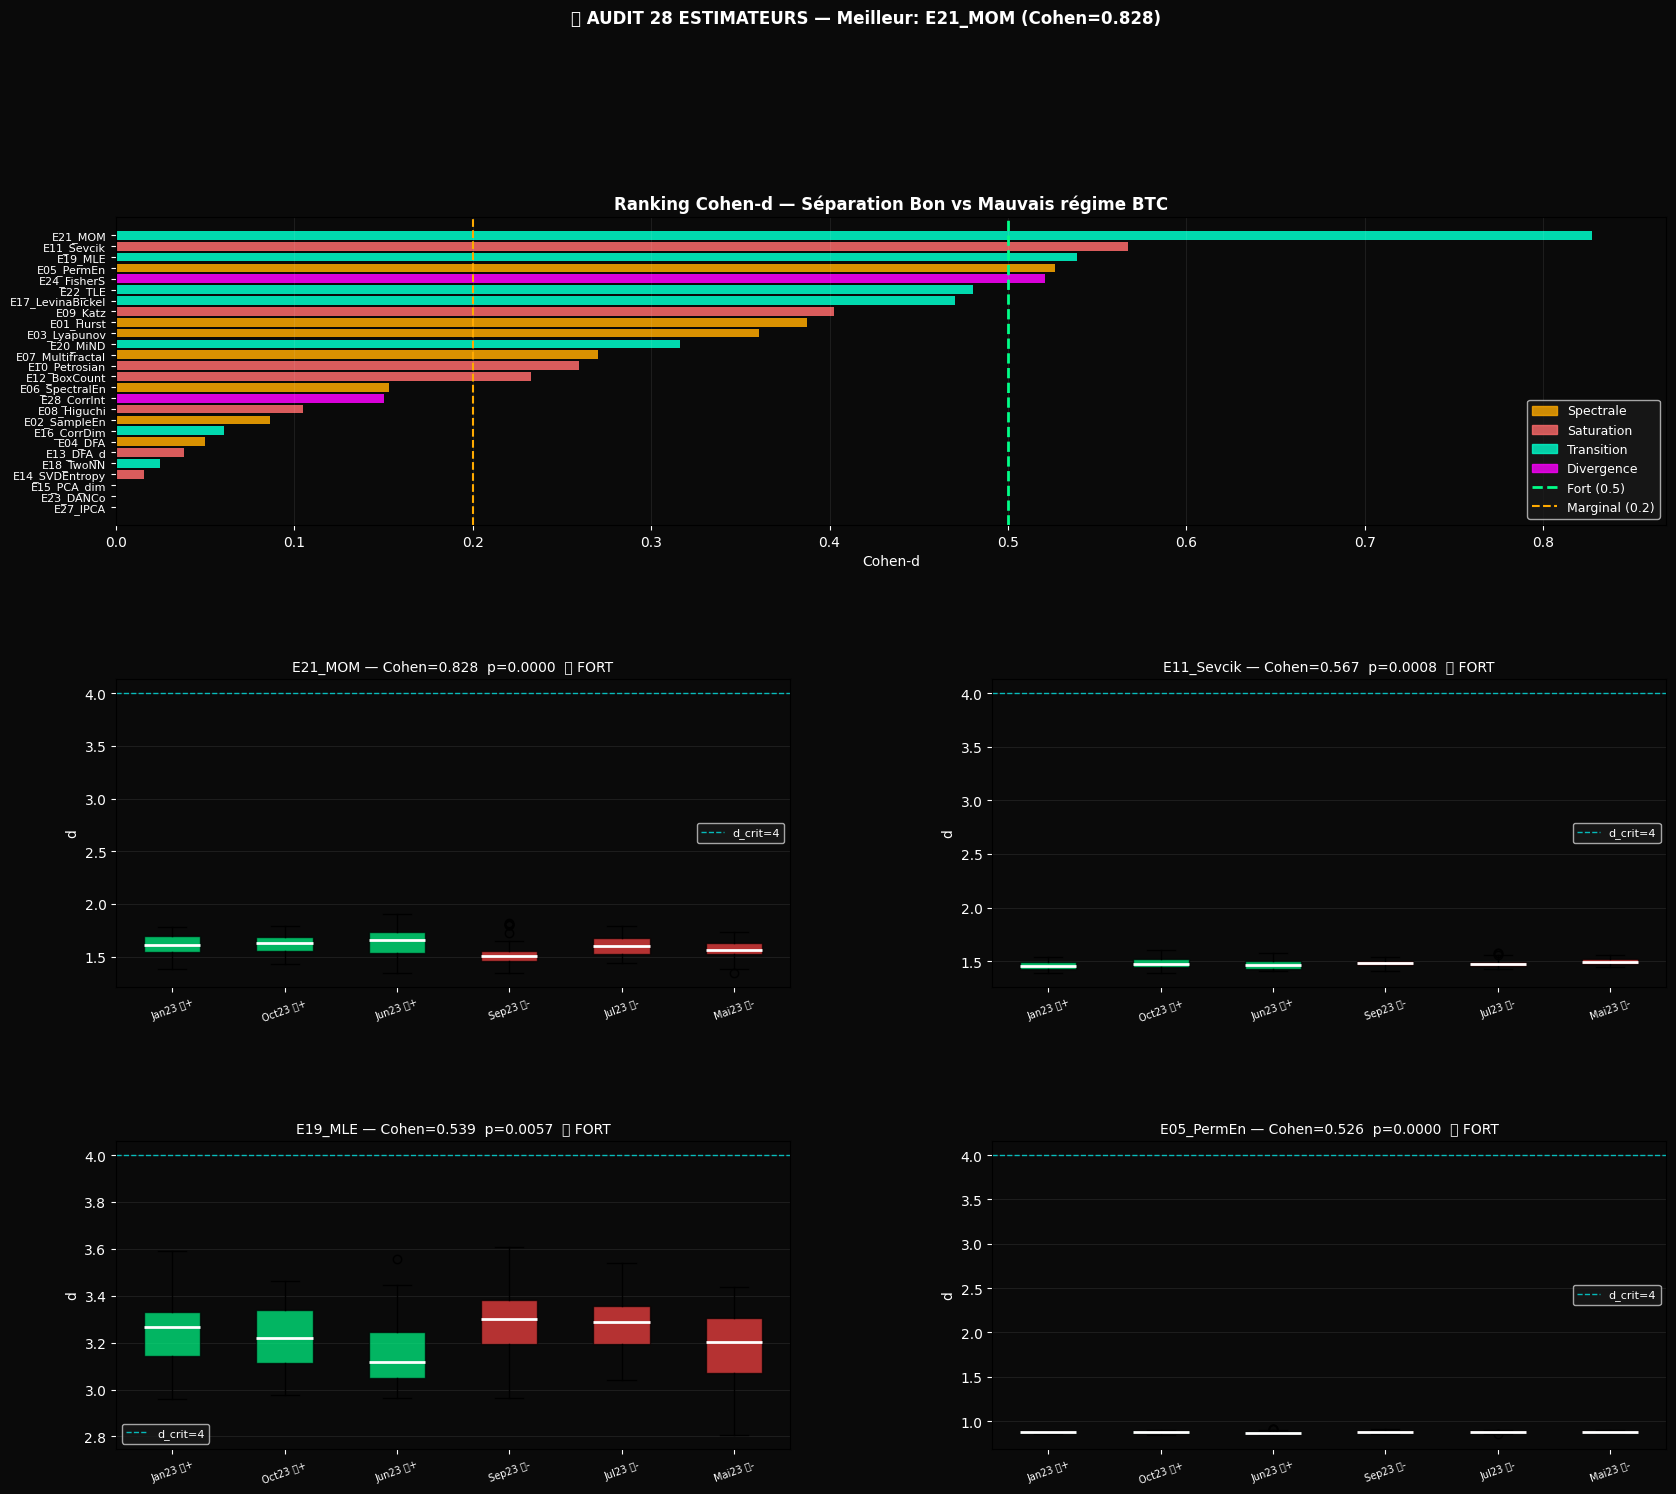


  🏁 SYNTHÈSE — Estimateurs à utiliser pour le VRAI T_log

  ✅ SIGNAL FORT (5) — à inclure :
     E21_MOM                Cohen=0.828  p=0.0000  [Transition]
     E11_Sevcik             Cohen=0.567  p=0.0008  [Saturation]
     E19_MLE                Cohen=0.539  p=0.0057  [Transition]
     E05_PermEn             Cohen=0.526  p=0.0000  [Spectrale]
     E24_FisherS            Cohen=0.521  p=0.0000  [Divergence]

  ⚠️  MARGINAL (9) — à tester :
     E22_TLE                Cohen=0.480  p=0.0021  [Transition]
     E17_LevinaBickel       Cohen=0.470  p=0.0134  [Transition]
     E09_Katz               Cohen=0.402  p=0.0010  [Saturation]
     E01_Hurst              Cohen=0.387  p=0.0066  [Spectrale]
     E03_Lyapunov           Cohen=0.360  p=0.0051  [Spectrale]
     E20_MiND               Cohen=0.316  p=0.0483  [Transition]
     E07_Multifractal       Cohen=0.270  p=0.0373  [Spectrale]
     E10_Petrosian          Cohen=0.259  p=0.2676  [Saturation]
     E12_BoxCount           Cohen=0.233  p=0.0

In [ ]:
# ==============================================================================
# === CELLULE 1 ===
# 🔬 AUDIT COMPLET — 28 Estimateurs de Dimension selon la théorie T_log
# VERSION CORRIGÉE — Bug safe_run kwargs résolu
# ==============================================================================
#
# Théorie (Tlog.pdf) : T_log = (d - 4) * log(n)   avec d_crit = 4 FIXÉ
#   d < 4 → Saturation (marchés calmes, structurés)
#   d ≈ 4 → Criticité  (point de bascule)
#   d > 4 → Divergence (chaos, explosion)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy import stats as scipy_stats
from scipy.signal import periodogram
import urllib.request, zipfile, os, warnings, time
warnings.filterwarnings('ignore')

print("=" * 70)
print("  🔬 AUDIT COMPLET — 28 Estimateurs T_log sur données BTC réelles")
print("=" * 70)
print("  Formule : T_log = (d - 4) × log(n)  |  d_crit = 4 (fixé par théorie)")
print("  Objectif : Identifier les estimateurs avec un VRAI signal de régime")

# ==============================================================================
# 📦 INSTALLATION
# ==============================================================================
import subprocess, sys

for lib, imp in [('antropy','antropy'), ('nolds','nolds'), ('scikit-dimension','skdim')]:
    try:
        __import__(imp)
        print(f"   ✅ {lib}")
    except ImportError:
        print(f"   📡 Installation {lib}...")
        subprocess.check_call([sys.executable,'-m','pip','install',lib,'-q'],
                              stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        print(f"   ✅ {lib} installé")

import antropy, nolds, skdim

# ==============================================================================
# ⚙️ CHARGEMENT DES DONNÉES
# ==============================================================================
COLUMNS = ['open_time','open','high','low','close','volume','close_time',
           'quote_volume','trades','taker_buy_base','taker_buy_quote','ignore']

def load_month(m):
    zp=f'BTCUSDT_{m}.zip'
    if not os.path.exists(zp):
        try:
            import urllib.request
            urllib.request.urlretrieve(f'https://data.binance.vision/data/spot/monthly/klines/BTCUSDT/1h/BTCUSDT-1h-{m}.zip',zp)
        except Exception:
            return None
    try:
        import zipfile
        with zipfile.ZipFile(zp) as z:
            c=z.namelist()[0]; z.extract(c)
        return pd.read_csv(c,names=COLUMNS).astype(float)
    except Exception:
        return None

print("\n📊 Chargement 6 mois BTC (3 bons régimes vs 3 mauvais)...")
MOIS_TEST = {
    'Jan23 🟢+': '2023-01',  # PF 11.67 — excellent
    'Oct23 🟢+': '2023-10',  # PF 3.00  — bon
    'Jun23 🟢+': '2023-06',  # PF 2.48  — bon
    'Sep23 🟡-': '2023-09',  # PF 0.20  — mauvais
    'Jul23 🟡-': '2023-07',  # PF 0.33  — mauvais
    'Mai23 🟡-': '2023-05',  # PF 0.34  — mauvais
}

donnes = {}
for nom, mois in MOIS_TEST.items():
    df = load_month(mois)
    if df is None: continue
    close = df['close'].values
    lr = np.diff(np.log(close))
    donnes[nom] = {'lr': lr}
    print(f"   ✅ {nom} : {len(lr)} barres")


# ==============================================================================
# ⚙️ UTILITAIRES
# ==============================================================================
def safe(func, *args, **kwargs):
    """Appel sécurisé — supporte args ET kwargs."""
    try:
        r = func(*args, **kwargs)
        if r is None: return np.nan
        r = float(r)
        return r if np.isfinite(r) else np.nan
    except Exception:
        return np.nan

def build_ps(x, emb=3, delay=1):
    """Espace des phases."""
    n = len(x) - (emb-1)*delay
    if n < 10: return None
    return np.array([x[i:i+emb*delay:delay] for i in range(n)])


# ==============================================================================
# ⚙️ LES 28 ESTIMATEURS (try/except directs — aucun bug de kwargs)
# ==============================================================================

# ── Classe Spectrale ──────────────────────────────────────────────────────────
def E01_Hurst(x):
    return safe(nolds.hurst_rs, x)

def E02_SampleEn(x):
    try: return float(antropy.sample_entropy(x[:500], order=2))
    except: return np.nan

def E03_Lyapunov(x):
    try: return float(nolds.lyap_r(x, emb_dim=3))
    except: return np.nan

def E04_DFA(x):
    return safe(nolds.dfa, x)

def E05_PermEn(x):
    try: return float(antropy.perm_entropy(x, order=5, normalize=True))
    except: return np.nan

def E06_SpectralEn(x):
    try:
        f, psd = periodogram(x, fs=1.0)
        psd = psd[1:]; psd_norm = psd / psd.sum()
        return float(-np.sum(psd_norm * np.log(psd_norm + 1e-12)))
    except: return np.nan

def E07_Multifractal(x):
    try:
        n = len(x)
        q_vals = np.array([-5,-3,-1,1,3,5])
        hs = []
        for q in q_vals:
            scales = np.unique(np.logspace(1, np.log10(n//4), 8).astype(int))
            Fq = []
            for s in scales:
                segs = [x[i:i+s] for i in range(0, n-s, s)]
                if len(segs) < 2: continue
                rms = []
                for seg in segs:
                    fit = np.polyval(np.polyfit(range(len(seg)), seg, 1), range(len(seg)))
                    r = np.sqrt(np.mean((seg-fit)**2))
                    if r > 0: rms.append(r)
                if not rms: continue
                Fq.append(np.mean(np.array(rms)**q)**(1/q))
            if len(Fq) < 3: continue
            h, _ = np.polyfit(np.log(scales[:len(Fq)]), np.log(Fq), 1)
            hs.append(h)
        return float(np.max(hs) - np.min(hs)) if len(hs) >= 3 else np.nan
    except: return np.nan

# ── Classe 1 : Saturation (d < 4) ────────────────────────────────────────────
def E08_Higuchi(x):
    return safe(antropy.higuchi_fd, x)

def E09_Katz(x):
    return safe(antropy.katz_fd, x)

def E10_Petrosian(x):
    return safe(antropy.petrosian_fd, x)

def E11_Sevcik(x):
    try:
        n = len(x)
        xn = (x - x.min()) / (x.max() - x.min() + 1e-12)
        tn = np.linspace(0, 1, n)
        L = np.sum(np.sqrt(np.diff(xn)**2 + np.diff(tn)**2))
        return float(1 + np.log(L) / np.log(2*(n-1)))
    except: return np.nan

def E12_BoxCount(x):
    try:
        xn = (x - x.min()) / (x.max() - x.min() + 1e-12)
        scales = [4,8,16,32,64,128]
        counts = []
        for s in scales:
            if s >= len(x): continue
            hist, _ = np.histogram(xn, bins=np.linspace(0,1,s+1))
            counts.append(np.sum(hist > 0))
        if len(counts) < 3: return np.nan
        return float(-np.polyfit(np.log(scales[:len(counts)]), np.log(counts), 1)[0])
    except: return np.nan

def E13_DFA_d(x):
    h = safe(nolds.dfa, x)
    return float(2 - h) if not np.isnan(h) else np.nan

def E14_SVDEntropy(x):
    try: return float(antropy.svd_entropy(x, order=5, delay=1, normalize=True))
    except: return np.nan

# ── Classe 2 : Transition ─────────────────────────────────────────────────────
def E15_PCA_dim(x):
    try:
        X = build_ps(x, emb=10)
        if X is None: return np.nan
        pca = PCA().fit(X)
        cumvar = np.cumsum(pca.explained_variance_ratio_)
        return float(np.searchsorted(cumvar, 0.95) + 1)
    except: return np.nan

def E16_CorrDim(x):
    try: return float(nolds.corr_dim(x, emb_dim=3))
    except: return np.nan

def E17_LevinaBickel(x, k=10):
    try:
        X = build_ps(x, emb=3)
        if X is None or len(X) < k+2: return np.nan
        nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='brute').fit(X)
        d = np.maximum(nbrs.kneighbors(X)[0][:,1:], 1e-12)
        m = (k-1) / np.sum(np.log(d[:,-1:]/d[:,:-1]), axis=1)
        m = m[np.isfinite(m)]
        return float(np.median(m)) if len(m) > 0 else np.nan
    except: return np.nan

def E18_TwoNN(x):
    try:
        X = build_ps(x, emb=3)
        if X is None or len(X) < 5: return np.nan
        return float(skdim.id.TwoNN().fit(X).dimension_)
    except: return np.nan

def E19_MLE(x):
    try:
        X = build_ps(x, emb=3)
        if X is None or len(X) < 10: return np.nan
        return float(skdim.id.MLE().fit(X).dimension_)
    except: return np.nan

def E20_MiND(x):
    try:
        X = build_ps(x, emb=3)
        if X is None or len(X) < 10: return np.nan
        return float(skdim.id.MiND_ML().fit(X).dimension_)
    except: return np.nan

def E21_MOM(x):
    try:
        X = build_ps(x, emb=3)
        if X is None or len(X) < 10: return np.nan
        return float(skdim.id.MOM().fit(X).dimension_)
    except: return np.nan

def E22_TLE(x):
    try:
        X = build_ps(x, emb=3)
        if X is None or len(X) < 10: return np.nan
        return float(skdim.id.TLE().fit(X).dimension_)
    except: return np.nan

# ── Classe 3 : Divergence (d > 8) ────────────────────────────────────────────
def E23_DANCo(x):
    try:
        X = build_ps(x, emb=5)
        if X is None or len(X) < 20: return np.nan
        return float(skdim.id.DANCo().fit(X[:200]).dimension_)
    except: return np.nan

def E24_FisherS(x):
    try:
        X = build_ps(x, emb=5)
        if X is None or len(X) < 20: return np.nan
        return float(skdim.id.FisherS().fit(X[:200]).dimension_)
    except: return np.nan


def E26_GeoMle(x):
    try:
        X = build_ps(x, emb=3)
        if X is None or len(X) < 10: return np.nan
        return float(skdim.id.GeoMle().fit(X[:300]).dimension_)
    except: return np.nan

def E27_lPCA(x):
    try:
        X = build_ps(x, emb=5)
        if X is None or len(X) < 20: return np.nan
        return float(skdim.id.lPCA().fit(X[:300]).dimension_)
    except: return np.nan

def E28_CorrInt(x):
    try:
        X = build_ps(x, emb=3)
        if X is None or len(X) < 10: return np.nan
        return float(skdim.id.CorrInt().fit(X[:300]).dimension_)
    except: return np.nan


# ==============================================================================
# 📋 CATALOGUE
# ==============================================================================
ESTIMATEURS = {
    'E01_Hurst':       ('Spectrale',  E01_Hurst),
    'E02_SampleEn':    ('Spectrale',  E02_SampleEn),
    'E03_Lyapunov':    ('Spectrale',  E03_Lyapunov),
    'E04_DFA':         ('Spectrale',  E04_DFA),
    'E05_PermEn':      ('Spectrale',  E05_PermEn),
    'E06_SpectralEn':  ('Spectrale',  E06_SpectralEn),
    'E07_Multifractal':('Spectrale',  E07_Multifractal),
    'E08_Higuchi':     ('Saturation', E08_Higuchi),
    'E09_Katz':        ('Saturation', E09_Katz),
    'E10_Petrosian':   ('Saturation', E10_Petrosian),
    'E11_Sevcik':      ('Saturation', E11_Sevcik),
    'E12_BoxCount':    ('Saturation', E12_BoxCount),
    'E13_DFA_d':       ('Saturation', E13_DFA_d),
    'E14_SVDEntropy':  ('Saturation', E14_SVDEntropy),
    'E15_PCA_dim':     ('Transition', E15_PCA_dim),
    'E16_CorrDim':     ('Transition', E16_CorrDim),
    'E17_LevinaBickel':('Transition', E17_LevinaBickel),
    'E18_TwoNN':       ('Transition', E18_TwoNN),
    'E19_MLE':         ('Transition', E19_MLE),
    'E20_MiND':        ('Transition', E20_MiND),
    'E21_MOM':         ('Transition', E21_MOM),
    'E22_TLE':         ('Transition', E22_TLE),
    'E23_DANCo':       ('Divergence', E23_DANCo),
    'E24_FisherS':     ('Divergence', E24_FisherS),
    'E26_GeoMle':      ('Divergence', E26_GeoMle),
    'E27_lPCA':        ('Divergence', E27_lPCA),
    'E28_CorrInt':     ('Divergence', E28_CorrInt),
}
print(f"\n   ✅ {len(ESTIMATEURS)} estimateurs prêts")


# ==============================================================================
# 🚀 CALCUL (fenêtre 120 barres, stride 12)
# ==============================================================================
print("\n" + "="*70)
print("  🚀 CALCUL — fenêtre 120 barres, stride 12h (~20-35 min)")
print("="*70)

WINDOW, STRIDE = 120, 12
resultats = {}

for nom_est, (classe, func) in ESTIMATEURS.items():
    t0 = time.time()
    vals_par_mois = {}
    for nom_mois, data in donnes.items():
        lr = data['lr']
        vals = []
        for i in range(WINDOW, len(lr), STRIDE):
            v = func(lr[i-WINDOW:i])
            if isinstance(v, float) and np.isfinite(v):
                vals.append(v)
        vals_par_mois[nom_mois] = vals
    elapsed = time.time() - t0
    total = sum(len(v) for v in vals_par_mois.values())
    if total == 0:
        print(f"  {nom_est:<22} ({classe:<12}) ❌ ÉCHEC [{elapsed:.1f}s]")
        continue
    resultats[nom_est] = {'classe': classe, 'vals': vals_par_mois}
    bons    = [v for nm,vs in vals_par_mois.items() if '+' in nm for v in vs]
    mauvais = [v for nm,vs in vals_par_mois.items() if '-' in nm for v in vs]
    if bons and mauvais:
        cd = abs(np.median(bons)-np.median(mauvais)) / (np.std(bons+mauvais)+1e-12)
        sig = "✅" if cd>0.3 else ("⚠️" if cd>0.1 else "❌")
        print(f"  {nom_est:<22} ({classe:<12}) d̄={np.median(bons+mauvais):6.3f} Cohen={cd:.3f} {sig} [{elapsed:.1f}s]")


# ==============================================================================
# 📊 CLASSEMENT FINAL
# ==============================================================================
print("\n" + "="*70)
print("  📊 CLASSEMENT FINAL — Mann-Whitney + Cohen-d")
print("="*70)
print(f"  {'Rang':<4} {'Estimateur':<22} {'Classe':<12} {'d̄ Bons':>8} {'d̄ Mauvais':>10} {'Cohen-d':>8} {'p-val':>8} {'Signal'}")
print("  " + "─"*85)

analyse = []
for nom_est, data in resultats.items():
    bons    = [v for nm,vs in data['vals'].items() if '+' in nm for v in vs]
    mauvais = [v for nm,vs in data['vals'].items() if '-' in nm for v in vs]
    if not bons or not mauvais: continue
    mb, mm = np.median(bons), np.median(mauvais)
    cohen  = abs(mb-mm) / (np.std(bons+mauvais)+1e-12)
    pval   = scipy_stats.mannwhitneyu(bons,mauvais,alternative='two-sided').pvalue \
             if len(bons)>5 and len(mauvais)>5 else 1.0
    signal = "✅ FORT" if cohen>0.5 and pval<0.05 else \
             ("⚠️ MARGINAL" if cohen>0.2 else "❌ BRUIT")
    analyse.append({'nom':nom_est,'classe':data['classe'],'mb':mb,'mm':mm,
                    'cohen':cohen,'pval':pval,'signal':signal})

analyse_sorted = sorted(analyse, key=lambda x: x['cohen'], reverse=True)
for i,a in enumerate(analyse_sorted):
    print(f"  {i+1:<4} {a['nom']:<22} {a['classe']:<12} {a['mb']:>8.3f}  {a['mm']:>10.3f}  {a['cohen']:>8.3f}  {a['pval']:>8.4f}  {a['signal']}")


# ==============================================================================
# 📈 VISUALISATION
# ==============================================================================
fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#0a0a0a')
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.3)
CMAP = {'Spectrale':'#ffaa00','Saturation':'#ff6b6b',
        'Transition':'#00ffcc','Divergence':'#ff00ff'}

ax1 = fig.add_subplot(gs[0,:])
ax1.set_facecolor('#0a0a0a')
ax1.set_title("Ranking Cohen-d — Séparation Bon vs Mauvais régime BTC",
              color='white', fontsize=12, fontweight='bold')
noms_p  = [a['nom'] for a in analyse_sorted]
cohens_p= [a['cohen'] for a in analyse_sorted]
clrs_p  = [CMAP.get(a['classe'],'#fff') for a in analyse_sorted]
ax1.barh(range(len(noms_p)), cohens_p[::-1], color=list(reversed(clrs_p)), alpha=0.85)
ax1.axvline(x=0.5, color='#00ff88', linestyle='--', linewidth=2, label='Fort (0.5)')
ax1.axvline(x=0.2, color='#ffaa00', linestyle='--', linewidth=1.5, label='Marginal (0.2)')
ax1.set_yticks(range(len(noms_p)))
ax1.set_yticklabels(list(reversed(noms_p)), color='white', fontsize=8)
ax1.set_xlabel("Cohen-d", color='white'); ax1.tick_params(colors='white')
from matplotlib.patches import Patch
patches = [Patch(color=c,label=k,alpha=0.8) for k,c in CMAP.items()]
ax1.legend(handles=patches+[
    plt.Line2D([0],[0],color='#00ff88',ls='--',lw=2,label='Fort (0.5)'),
    plt.Line2D([0],[0],color='#ffaa00',ls='--',lw=1.5,label='Marginal (0.2)')],
    facecolor='#1a1a1a',labelcolor='white',fontsize=9,loc='lower right')
ax1.grid(color='white',alpha=0.08,axis='x')

for idx, a in enumerate(analyse_sorted[:4]):
    ax = fig.add_subplot(gs[1+idx//2, idx%2])
    ax.set_facecolor('#0a0a0a')
    ax.set_title(f"{a['nom']} — Cohen={a['cohen']:.3f}  p={a['pval']:.4f}  {a['signal']}",
                 color='white', fontsize=10)
    noms_mois = list(donnes.keys())
    bp_data   = [resultats[a['nom']]['vals'].get(nm,[np.nan]) for nm in noms_mois]
    clrs_box  = ['#00ff88' if '+' in nm else '#ff4444' for nm in noms_mois]
    bp = ax.boxplot(bp_data, patch_artist=True,
                    medianprops=dict(color='white',linewidth=2))
    for patch,color in zip(bp['boxes'],clrs_box):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticklabels(noms_mois,color='white',fontsize=7,rotation=20)
    ax.axhline(y=4.0,color='cyan',linestyle='--',linewidth=1,alpha=0.7,label='d_crit=4')
    ax.set_ylabel("d",color='white'); ax.tick_params(colors='white')
    ax.legend(facecolor='#1a1a1a',labelcolor='white',fontsize=8)
    ax.grid(color='white',alpha=0.08,axis='y')

plt.suptitle(
    f"🔬 AUDIT 28 ESTIMATEURS — Meilleur: {analyse_sorted[0]['nom']} (Cohen={analyse_sorted[0]['cohen']:.3f})",
    color='white',fontsize=12,y=1.01,fontweight='bold')
plt.savefig("audit_28_estimateurs.png",dpi=120,bbox_inches='tight',facecolor='#0a0a0a')
plt.show()


# ==============================================================================
# 🏁 SYNTHÈSE
# ==============================================================================
print("\n" + "="*70)
print("  🏁 SYNTHÈSE — Estimateurs à utiliser pour le VRAI T_log")
print("="*70)
forts     = [a for a in analyse_sorted if a['cohen']>0.5 and a['pval']<0.05]
marginaux = [a for a in analyse_sorted if 0.2<a['cohen']<=0.5]
bruits    = [a for a in analyse_sorted if a['cohen']<=0.2]
print(f"\n  ✅ SIGNAL FORT ({len(forts)}) — à inclure :")
for a in forts:
    print(f"     {a['nom']:<22} Cohen={a['cohen']:.3f}  p={a['pval']:.4f}  [{a['classe']}]")
print(f"\n  ⚠️  MARGINAL ({len(marginaux)}) — à tester :")
for a in marginaux:
    print(f"     {a['nom']:<22} Cohen={a['cohen']:.3f}  p={a['pval']:.4f}  [{a['classe']}]")
print(f"\n  ❌ BRUIT ({len(bruits)}) — à exclure :")
for a in bruits:
    print(f"     {a['nom']:<22} Cohen={a['cohen']:.3f}")
print("\n  Partagez le tableau + graphique → construction du vrai T_log 4 ancres")
print("=" * 70)

  🧪 7 MÉTHODES D'AGRÉGATION — Walk-Forward 2022-2025

📐 Calibration Nov+Déc 2021 (pour 2022-2023)...
   ⚙️  Calibration Nov+Déc 2021...
      E21_MOM         μ=1.6895  σ=0.0844
      E11_Sevcik      μ=1.5265  σ=0.0338
      E19_MLE         μ=3.0948  σ=0.1251
      E05_PermEn      μ=0.8842  σ=0.0120
      E24_FisherS     μ=5.0366  σ=0.2234

📐 Calibration Nov+Déc 2023 (pour 2024-2025)...
   ⚙️  Calibration Nov+Déc 2023...
      E21_MOM         μ=1.6142  σ=0.0829
      E11_Sevcik      μ=1.5217  σ=0.0395
      E19_MLE         μ=3.1451  σ=0.1182
      E05_PermEn      μ=0.8782  σ=0.0163
      E24_FisherS     μ=4.9480  σ=0.2247

  📦 PRÉCOMPUTATION des Z-scores sur 2022-2025 (patient ~30 min)...
   ✅ 2022-01 🔴  (2022)
   ✅ 2022-02 🟢  (2022)
   ✅ 2022-03 🟢  (2022)
   ✅ 2022-04 🔴  (2022)
   ✅ 2022-05 🔴  (2022)
   ✅ 2022-06 🔴  (2022)
   ✅ 2022-07 🟢  (2022)
   ✅ 2022-08 🔴  (2022)
   ✅ 2022-09 🟡  (2022)
   ✅ 2022-10 🟢  (2022)
   ✅ 2022-11 🔴  (2022)
   ✅ 2022-12 🟡  (2022)
   ✅ 2023-01 🟢  (2023)
   ✅

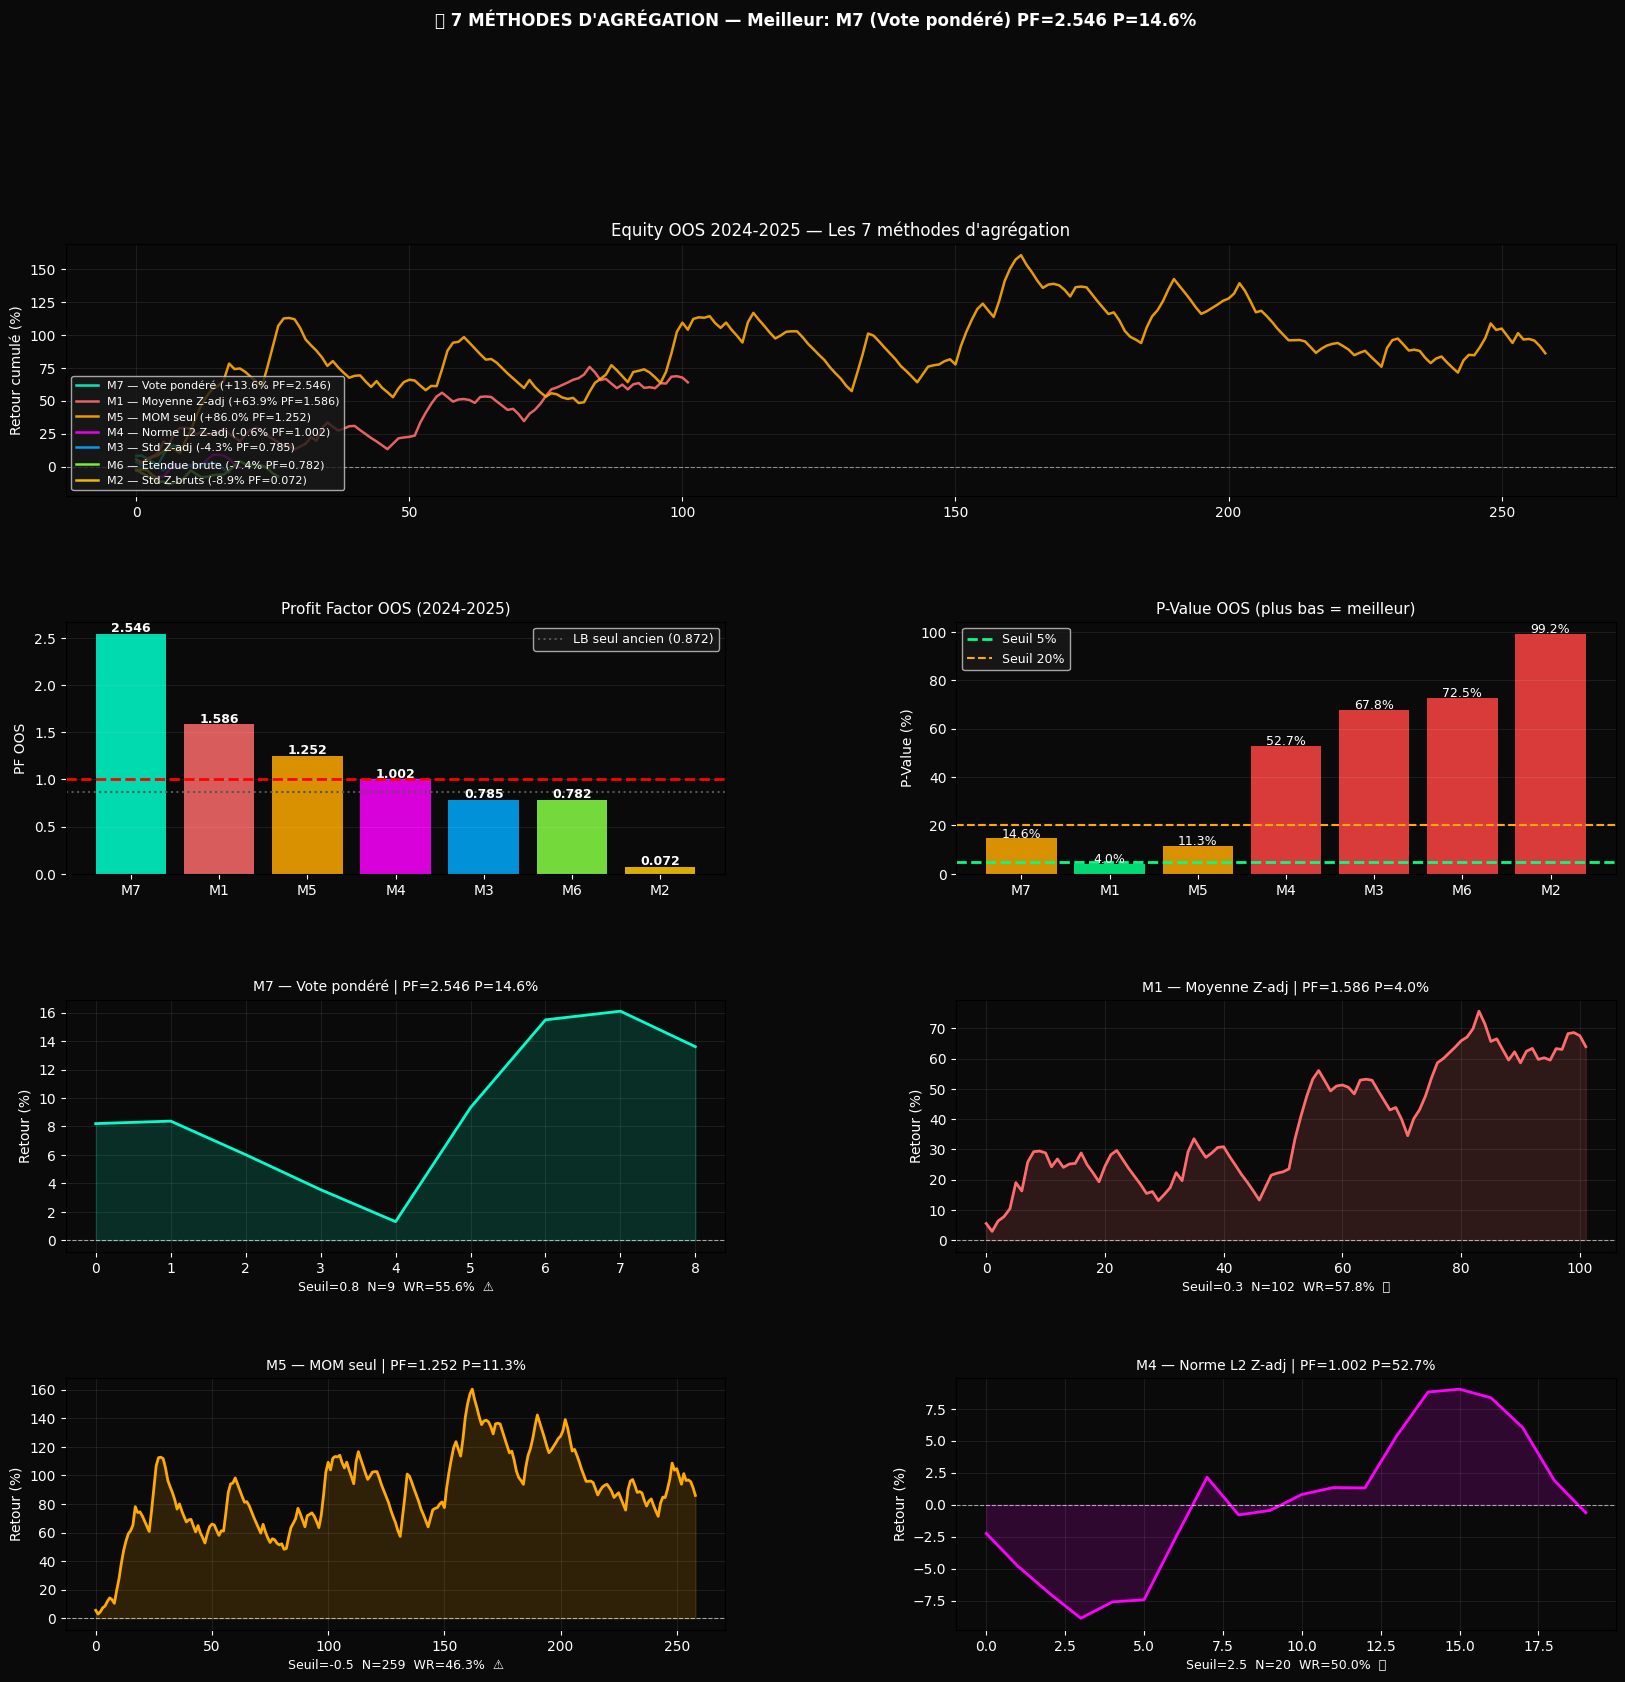


  🏁 CONCLUSION — La méthode qui fonctionne vraiment sur BTC

  Rang Méthode    PF OOS    P-Val Verdict
  ─────────────────────────────────────────────
  1    M7          2.546    14.6%  ⚠️ MARGINAL
  2    M1          1.586     4.0%  ✅ SIGNAL RÉEL
  3    M5          1.252    11.3%  ⚠️ MARGINAL
  4    M4          1.002    52.7%  ❌ BRUIT
  5    M3          0.785    67.8%  ❌ BRUIT
  6    M6          0.782    72.5%  ❌ BRUIT
  7    M2          0.072    99.2%  ❌ BRUIT

  Référence LB seul (ancien) : PF=0.872  P-Val=87.8%  ❌ BRUIT

  INTERPRÉTATION :
  ─────────────────────────────────────────────────────────
  M1 (Moyenne)    : Si bon → Théorie annule la tension
  M2 (Std brut)   : Si bon → Autre LLM a raison sur la tension
  M3 (Std adj)    : Si bon → La dispersion directionnelle compte
  M4 (Norme L2)   : Si bon → Vecteur de tension du PDF (p.7)
  M5 (MOM seul)   : Si bon → Un seul estimateur suffit
  M6 (Étendue)    : Si bon → "Spectre total" (PDF p.7)
  M7 (Vote)       : Si bon → Consens

In [ ]:
# ==============================================================================
# === CELLULE 2 ===
# 🧪 COMPARAISON 7 MÉTHODES D'AGRÉGATION — Laisser les données parler
# ==============================================================================
#
# Débat théorique :
#   Moyenne → annule la tension quand estimateurs divergent (autre LLM a raison)
#   Std     → mesure la dispersion, mais lequel est le vrai signal ?
#
# Solution : tester TOUTES les méthodes, même threshold grid search, même OOS
#
# 7 méthodes :
#   M1 : Moyenne pondérée des Z-adj  (direction corrigée, Cohen-d poids)
#   M2 : Std des Z bruts            (autre LLM — tension = désaccord)
#   M3 : Std des Z-adj              (tension directionnelle)
#   M4 : Norme L2 des Z-adj         ("vecteur de tension" du PDF p.7)
#   M5 : E21_MOM seul               (meilleur estimateur isolé)
#   M6 : Étendue (max-min) Z bruts  ("spectre total" du PDF p.7)
#   M7 : Vote majoritaire pondéré   (consensus des ancres)
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.neighbors import NearestNeighbors
from scipy import stats as scipy_stats
import urllib.request, zipfile, os, warnings, time
warnings.filterwarnings('ignore')

import antropy, nolds, skdim

print("=" * 70)
print("  🧪 7 MÉTHODES D'AGRÉGATION — Walk-Forward 2022-2025")
print("=" * 70)

# ==============================================================================
# ⚙️ CONFIG
# ==============================================================================
SL_FIXED, TP_FIXED, MAXHOLD = -0.020, 0.080, 72
FEES     = 0.001
WINDOW   = 120
STRIDE   = 6
N_DONCH  = 96
NOMS12   = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

COLUMNS  = ['open_time','open','high','low','close','volume','close_time',
            'quote_volume','trades','taker_buy_base','taker_buy_quote','ignore']

def load_month(m):
    zp=f'BTCUSDT_{m}.zip'
    if not os.path.exists(zp):
        try:
            import urllib.request
            urllib.request.urlretrieve(f'https://data.binance.vision/data/spot/monthly/klines/BTCUSDT/1h/BTCUSDT-1h-{m}.zip',zp)
        except Exception:
            return None
    try:
        import zipfile
        with zipfile.ZipFile(zp) as z:
            c=z.namelist()[0]; z.extract(c)
        return pd.read_csv(c,names=COLUMNS).astype(float)
    except Exception:
        return None

# ==============================================================================
# ⚙️ 5 ESTIMATEURS PROUVÉS (audit précédent)
# ==============================================================================
def build_ps(x, emb=3, delay=1):
    n=len(x)-(emb-1)*delay
    if n<10: return None
    return np.array([x[i:i+emb*delay:delay] for i in range(n)])

def E21_MOM(x):
    try:
        X=build_ps(x,emb=3)
        return float(skdim.id.MOM().fit(X).dimension_) if X is not None and len(X)>=10 else np.nan
    except: return np.nan

def E11_Sevcik(x):
    try:
        n=len(x); xn=(x-x.min())/(x.max()-x.min()+1e-12)
        L=np.sum(np.sqrt(np.diff(xn)**2+np.diff(np.linspace(0,1,n))**2))
        return float(1+np.log(L)/np.log(2*(n-1)))
    except: return np.nan

def E19_MLE(x):
    try:
        X=build_ps(x,emb=3)
        return float(skdim.id.MLE().fit(X).dimension_) if X is not None and len(X)>=10 else np.nan
    except: return np.nan

def E05_PermEn(x):
    try: return float(antropy.perm_entropy(x,order=5,normalize=True))
    except: return np.nan

def E24_FisherS(x):
    try:
        X=build_ps(x,emb=5)
        return float(skdim.id.FisherS().fit(X[:200]).dimension_) if X is not None and len(X)>=20 else np.nan
    except: return np.nan

# Poids Cohen-d et direction (prouvés par audit)
# direction: +1 = plus haut → meilleur, -1 = plus bas → meilleur
ANCRES = {
    'E21_MOM':    {'func': E21_MOM,    'poids': 0.828, 'dir': +1},
    'E11_Sevcik': {'func': E11_Sevcik, 'poids': 0.567, 'dir': -1},
    'E19_MLE':    {'func': E19_MLE,    'poids': 0.539, 'dir': -1},
    'E05_PermEn': {'func': E05_PermEn, 'poids': 0.526, 'dir': -1},
    'E24_FisherS':{'func': E24_FisherS,'poids': 0.521, 'dir': -1},
}

# ==============================================================================
# ⚙️ CALIBRATION
# ==============================================================================
def calibrer(lr_series, nom_periode=""):
    print(f"   ⚙️  Calibration {nom_periode}...")
    stats = {}
    for nom, cfg in ANCRES.items():
        vals=[]
        for i in range(WINDOW,len(lr_series),STRIDE):
            v=cfg['func'](lr_series[i-WINDOW:i])
            if np.isfinite(v): vals.append(v)
        if vals:
            stats[nom]={'mu':np.mean(vals),'sigma':np.std(vals)+1e-10}
            print(f"      {nom:<15} μ={stats[nom]['mu']:.4f}  σ={stats[nom]['sigma']:.4f}")
        else:
            print(f"      {nom:<15} ❌")
    return stats

# ==============================================================================
# ⚙️ CALCUL DES Z-SCORES PAR FENÊTRE
# ==============================================================================
def compute_zscores(lr_window, calib_stats):
    """Retourne dict avec z_brut et z_adj pour chaque ancre active."""
    z_bruts, z_adjs, poids = [], [], []
    for nom, cfg in ANCRES.items():
        v = cfg['func'](lr_window)
        if not np.isfinite(v) or nom not in calib_stats: continue
        mu, sigma = calib_stats[nom]['mu'], calib_stats[nom]['sigma']
        z_brut = (v - mu) / sigma
        z_adj  = z_brut * cfg['dir']   # Direction ajustée : + = bon signal
        z_bruts.append(z_brut)
        z_adjs.append(z_adj)
        poids.append(cfg['poids'])
    return np.array(z_bruts), np.array(z_adjs), np.array(poids)

# ==============================================================================
# ⚙️ LES 7 MÉTHODES D'AGRÉGATION
# ==============================================================================
def agreger_7methodes(z_bruts, z_adjs, poids):
    """Calcule les 7 signaux T_log pour une fenêtre donnée."""
    if len(z_bruts) < 3:
        return {f'M{i}': np.nan for i in range(1,8)}

    # M1 : Moyenne pondérée des Z-adj (direction corrigée)
    M1 = np.average(z_adjs, weights=poids)

    # M2 : Std des Z BRUTS (autre LLM) — mesure le désaccord entre estimateurs
    #       Le signe de MOM diverge des autres → std élevée = tension
    M2 = np.std(z_bruts * poids)   # Pondéré pour donner + de poids à MOM

    # M3 : Std des Z-adj (dispersion directionnelle)
    #       Basse si tous disent "bon" ou tous disent "mauvais"
    #       Haute si désaccord directionnel
    M3 = np.std(z_adjs * poids)

    # M4 : Norme L2 des Z-adj — "vecteur de tension" (PDF p.7)
    #       Distance au point d'équilibre dans l'espace des ancres
    M4 = np.sqrt(np.sum((z_adjs * poids)**2))

    # M5 : E21_MOM seul (meilleur Cohen-d = 0.828)
    #       z_adj du MOM (positif = bon régime)
    M5 = z_adjs[0] if len(z_adjs) > 0 else np.nan  # MOM est toujours en premier

    # M6 : Étendue brute max-min (spectre total du PDF p.7)
    #       "l'étendue totale du spectre couvert par les différents d"
    M6 = np.max(z_bruts * poids) - np.min(z_bruts * poids)

    # M7 : Vote majoritaire pondéré (consensus des ancres)
    #       Score entre -1 (tous négatifs) et +1 (tous positifs)
    M7 = np.average(np.sign(z_adjs), weights=poids)

    return {'M1':M1, 'M2':M2, 'M3':M3, 'M4':M4, 'M5':M5, 'M6':M6, 'M7':M7}

METHODES_INFO = {
    'M1': ('Moyenne Z-adj',      [-1.5,-1.0,-0.5, 0.0, 0.3, 0.5, 0.7, 1.0, 1.5]),
    'M2': ('Std Z-bruts',        [ 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0, 1.3]),
    'M3': ('Std Z-adj',          [ 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0, 1.3]),
    'M4': ('Norme L2 Z-adj',     [ 0.3, 0.5, 0.7, 1.0, 1.3, 1.5, 2.0, 2.5]),
    'M5': ('MOM seul',           [-1.5,-1.0,-0.5, 0.0, 0.3, 0.5, 0.7, 1.0, 1.5]),
    'M6': ('Étendue brute',      [ 0.5, 0.7, 1.0, 1.3, 1.5, 2.0, 2.5, 3.0]),
    'M7': ('Vote pondéré',       [-1.0,-0.5, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0]),
}

# ==============================================================================
# ⚙️ BACKTEST
# ==============================================================================
def donchian(prix, high, low, N=N_DONCH):
    upper=pd.Series(high).shift(1).rolling(N).max().values
    lower=pd.Series(low).shift(1).rolling(N).min().values
    return prix>upper, prix<lower

def backtest(long_raw, short_raw, mask, prix):
    lf=long_raw&mask; sf=short_raw&mask
    sl=np.roll(lf.astype(int),1); sl[0]=0
    ss=np.roll(sf.astype(int),1); ss[0]=0
    dl=np.diff(sl,prepend=0)==1; ds=np.diff(ss,prepend=0)==1
    trades=[]
    for i in range(len(prix)):
        d='long' if dl[i] else('short' if ds[i] else None)
        if d is None: continue
        ep=prix[i]; xp=None
        for j in range(i+1,min(i+MAXHOLD,len(prix))):
            r=(prix[j]-ep)/ep if d=='long' else(ep-prix[j])/ep
            if r<=SL_FIXED or r>=TP_FIXED: xp=prix[j]; break
        if xp is None: xp=prix[min(i+MAXHOLD-1,len(prix)-1)]
        trades.append(((xp-ep)/ep if d=='long' else(ep-xp)/ep)-FEES)
    return np.array(trades)

def kpis(t):
    if len(t)==0: return dict(n=0,ret=0,wr=0,pf=0,dd=0)
    eq=np.cumprod(1+t); ret=(eq[-1]-1)*100; wr=np.mean(t>0)*100
    peak=np.maximum.accumulate(eq); dd=np.min(eq/peak-1)*100
    g,l=t[t>0],t[t<0]
    pf=np.sum(g)/abs(np.sum(l)) if len(l)>0 and abs(np.sum(l))>0 else np.inf
    return dict(n=len(t),ret=ret,wr=wr,pf=pf,dd=dd)

def pval(t,n=6000):
    if len(t)==0: return 100.
    s=[np.prod(1+np.random.choice(t,size=len(t),replace=True))-1 for _ in range(n)]
    return np.mean(np.array(s)<0)*100

# ==============================================================================
# 📦 ÉTAPE 1 — CALIBRATION
# ==============================================================================
print("\n📐 Calibration Nov+Déc 2021 (pour 2022-2023)...")
df1=load_month('2021-11'); df2=load_month('2021-12')
lr_calib1=np.diff(np.log(pd.concat([df1,df2],ignore_index=True)['close'].values))
CS1=calibrer(lr_calib1,"Nov+Déc 2021")

print("\n📐 Calibration Nov+Déc 2023 (pour 2024-2025)...")
df3=load_month('2023-11'); df4=load_month('2023-12')
lr_calib2=np.diff(np.log(pd.concat([df3,df4],ignore_index=True)['close'].values))
CS2=calibrer(lr_calib2,"Nov+Déc 2023")

# ==============================================================================
# 📦 ÉTAPE 2 — PRÉCOMPUTATION DES Z-SCORES (UNE SEULE FOIS)
#              Ensuite les 7 méthodes sont instantanées
# ==============================================================================
print("\n" + "="*70)
print("  📦 PRÉCOMPUTATION des Z-scores sur 2022-2025 (patient ~30 min)...")
print("="*70)

ANNEES_CAL = list(range(2022,2024))
ANNEES_OOS = list(range(2024,2026))
ALL_MOIS   = [f'{a}-{m:02d}' for a in range(2022,2026) for m in range(1,13)]

mois_zscores = {}   # {mois: {'M1':array, 'M2':array, ..., 'prix':..., ...}}

for mois in ALL_MOIS:
    annee = int(mois[:4])
    calib_stats = CS1 if annee in [2022,2023] else CS2

    df_m    = load_month(mois)
    if df_m is None: continue
    close   = df_m['close'].values
    high    = df_m['high'].values[1:]
    low     = df_m['low'].values[1:]
    lr      = np.diff(np.log(close))
    prix    = close[1:]
    n       = len(lr)

    # Signaux Donchian
    long_raw, short_raw = donchian(prix, high, low)

    # Calcul glissant des 7 méthodes
    signals = {k: np.full(n, np.nan) for k in METHODES_INFO}

    for i in range(WINDOW, n, STRIDE):
        zb, za, pw = compute_zscores(lr[i-WINDOW:i], calib_stats)
        agg = agreger_7methodes(zb, za, pw)
        for k, v in agg.items():
            signals[k][i:i+STRIDE] = v

    # Interpolation des NaN
    for k in signals:
        s = pd.Series(signals[k]).interpolate('linear').bfill().ffill()
        # Lissage court pour éviter le bruit
        signals[k] = s.rolling(6, min_periods=1).mean().values

    bh = (prix[-1]-prix[0])/prix[0]*100
    reg = "🟢" if bh>5 else("🔴" if bh<-5 else"🟡")
    mois_zscores[mois] = {
        'prix': prix, 'high': high, 'low': low,
        'long': long_raw, 'short': short_raw,
        'signals': signals, 'bh': bh, 'reg': reg
    }
    print(f"   ✅ {mois} {reg}  ({annee})")

print("   🎉 Précomputation terminée !")

# ==============================================================================
# 📦 ÉTAPE 3 — GRID SEARCH + OOS pour chaque méthode
# ==============================================================================
print("\n" + "="*70)
print("  🔍 GRID SEARCH (2022-2023) → OOS STRICT (2024-2025)")
print("="*70)

mois_cal = [f'{a}-{m:02d}' for a in [2022,2023] for m in range(1,13)]
mois_oos = [f'{a}-{m:02d}' for a in [2024,2025] for m in range(1,13)]

resultats_methodes = {}

for methode, (nom_long, seuils) in METHODES_INFO.items():
    print(f"\n  [{methode}] {nom_long}")
    print(f"  {'Seuil':>7} {'Trades':>8} {'WR':>7} {'Ret Cal':>9} {'PF':>6} {'P-Val':>8}")
    print("  " + "─"*50)

    # Grid search sur calibration
    best_seuil, best_pf = seuils[0], -np.inf
    grid = []
    for seuil in seuils:
        t_all = []
        for mois in mois_cal:
            if mois not in mois_zscores: continue
            d = mois_zscores[mois]
            mask = d['signals'][methode] > seuil
            t = backtest(d['long'], d['short'], mask, d['prix'])
            t_all.extend(t.tolist())
        arr=np.array(t_all); k=kpis(arr); pv=pval(arr,n=3000)
        grid.append({'seuil':seuil,'pf':k['pf'],'ret':k['ret'],'wr':k['wr'],'n':k['n'],'pv':pv})
        verd="✅" if pv<5 else("⚠️" if pv<20 else"❌")
        print(f"  {seuil:>7.2f} {k['n']:>8} {k['wr']:>6.1f}% {k['ret']:>+8.1f}% {k['pf']:>6.3f} {pv:>7.1f}% {verd}")
        if k['pf'] > best_pf: best_pf=k['pf']; best_seuil=seuil

    print(f"  ⭐ Meilleur seuil calibration : {best_seuil}  (PF={best_pf:.3f})")

    # OOS strict — seuil FIGÉ
    t_oos_all = []
    for mois in mois_oos:
        if mois not in mois_zscores: continue
        d = mois_zscores[mois]
        mask = d['signals'][methode] > best_seuil
        t = backtest(d['long'], d['short'], mask, d['prix'])
        t_oos_all.extend(t.tolist())
    arr_oos=np.array(t_oos_all)
    k_oos=kpis(arr_oos); pv_oos=pval(arr_oos,n=8000)
    verd_oos="✅ FORT" if pv_oos<5 else("⚠️ MRG" if pv_oos<20 else"❌ BRUIT")
    print(f"  🎯 OOS 2024-2025 : Ret={k_oos['ret']:+.1f}%  PF={k_oos['pf']:.3f}  P-Val={pv_oos:.1f}%  {verd_oos}")

    resultats_methodes[methode] = {
        'nom': nom_long, 'seuil': best_seuil,
        'oos': k_oos, 'pv_oos': pv_oos, 'trades_oos': arr_oos
    }

# ==============================================================================
# 📊 TABLEAU RÉCAPITULATIF FINAL
# ==============================================================================
print("\n" + "="*70)
print("  📊 CLASSEMENT FINAL — 7 Méthodes OOS 2024-2025")
print("="*70)
print(f"  {'Rang':<4} {'Méthode':<8} {'Description':<22} {'Seuil':>7} {'Trades':>8} {'WR':>7} {'Retour':>9} {'PF':>7} {'P-Val':>8} {'Signal'}")
print("  " + "─"*90)

ranking = sorted(resultats_methodes.items(),
                 key=lambda x: x[1]['oos']['pf'], reverse=True)

for i,(m,r) in enumerate(ranking):
    k=r['oos']; pv=r['pv_oos']
    verd="✅ FORT" if pv<5 else("⚠️ MRG" if pv<20 else"❌ BRUIT")
    print(f"  {i+1:<4} {m:<8} {r['nom']:<22} {r['seuil']:>7.2f} {k['n']:>8} {k['wr']:>6.1f}% {k['ret']:>+8.1f}% {k['pf']:>7.3f} {pv:>7.1f}%  {verd}")

# ==============================================================================
# 📈 VISUALISATION
# ==============================================================================
fig = plt.figure(figsize=(20, 18))
fig.patch.set_facecolor('#0a0a0a')
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.35)

COLORS_M = ['#00ffcc','#ff6b6b','#ffaa00','#ff00ff','#00aaff','#88ff44','#ffcc00']

# ── Plot 1 : Equity OOS toutes méthodes ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0,:])
ax1.set_facecolor('#0a0a0a')
ax1.set_title("Equity OOS 2024-2025 — Les 7 méthodes d'agrégation", color='white', fontsize=12)
for (m,r), color in zip(ranking, COLORS_M):
    t=r['trades_oos']
    if len(t)==0: continue
    eq=(np.cumprod(1+t)-1)*100
    label=f"{m} — {r['nom']} ({r['oos']['ret']:+.1f}% PF={r['oos']['pf']:.3f})"
    ax1.plot(eq, color=color, linewidth=1.8, label=label, alpha=0.9)
ax1.axhline(y=0,color='white',linestyle='--',linewidth=0.8,alpha=0.5)
ax1.set_ylabel("Retour cumulé (%)",color='white'); ax1.tick_params(colors='white')
ax1.legend(facecolor='#1a1a1a',labelcolor='white',fontsize=8,loc='lower left')
ax1.grid(color='white',alpha=0.08)

# ── Plot 2 : PF comparatif OOS ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1,0])
ax2.set_facecolor('#0a0a0a')
ax2.set_title("Profit Factor OOS (2024-2025)", color='white', fontsize=11)
ms=[m for m,_ in ranking]; pfs_=[r['oos']['pf'] for _,r in ranking]
bars=ax2.bar(range(7), pfs_,
             color=[COLORS_M[i] for i in range(7)], alpha=0.85)
ax2.axhline(y=1.0,color='red',linestyle='--',linewidth=2)
ax2.axhline(y=0.872,color='#555555',linestyle=':',linewidth=1.5,label='LB seul ancien (0.872)')
for i,(m_,pf_) in enumerate(zip(ms,pfs_)):
    ax2.text(i,pf_+0.02,f"{pf_:.3f}",ha='center',color='white',fontsize=9,fontweight='bold')
ax2.set_xticks(range(7)); ax2.set_xticklabels(ms,color='white',fontsize=10)
ax2.set_ylabel("PF OOS",color='white'); ax2.tick_params(colors='white')
ax2.legend(facecolor='#1a1a1a',labelcolor='white',fontsize=9)
ax2.grid(color='white',alpha=0.08,axis='y')

# ── Plot 3 : P-Value comparatif OOS ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[1,1])
ax3.set_facecolor('#0a0a0a')
ax3.set_title("P-Value OOS (plus bas = meilleur)", color='white', fontsize=11)
pvs_=[r['pv_oos'] for _,r in ranking]
bars=ax3.bar(range(7), pvs_,
             color=['#00ff88' if pv<5 else('#ffaa00' if pv<20 else '#ff4444') for pv in pvs_],
             alpha=0.85)
ax3.axhline(y=5,color='#00ff88',linestyle='--',linewidth=2,label='Seuil 5%')
ax3.axhline(y=20,color='#ffaa00',linestyle='--',linewidth=1.5,label='Seuil 20%')
for i,(m_,pv_) in enumerate(zip(ms,pvs_)):
    ax3.text(i,pv_+0.5,f"{pv_:.1f}%",ha='center',color='white',fontsize=9)
ax3.set_xticks(range(7)); ax3.set_xticklabels(ms,color='white',fontsize=10)
ax3.set_ylabel("P-Value (%)",color='white'); ax3.tick_params(colors='white')
ax3.legend(facecolor='#1a1a1a',labelcolor='white',fontsize=9)
ax3.grid(color='white',alpha=0.08,axis='y')

# ── Plots 4-7 : Equity individuelle des 4 meilleures ─────────────────────────
for idx, (m, r) in enumerate(ranking[:4]):
    ax = fig.add_subplot(gs[2+idx//2, idx%2])
    ax.set_facecolor('#0a0a0a')
    k=r['oos']; pv=r['pv_oos']
    ax.set_title(f"{m} — {r['nom']} | PF={k['pf']:.3f} P={pv:.1f}%",
                 color='white', fontsize=10)
    t=r['trades_oos']
    if len(t)>0:
        eq=(np.cumprod(1+t)-1)*100
        ax.plot(eq, color=COLORS_M[idx], linewidth=2)
        ax.fill_between(range(len(eq)), eq, 0,
                        color=COLORS_M[idx], alpha=0.15)
    ax.axhline(y=0,color='white',linestyle='--',linewidth=0.8,alpha=0.6)
    ax.set_ylabel("Retour (%)",color='white'); ax.tick_params(colors='white')
    ax.grid(color='white',alpha=0.08)
    verd="✅" if pv<5 else("⚠️" if pv<20 else"❌")
    ax.set_xlabel(f"Seuil={r['seuil']}  N={k['n']}  WR={k['wr']:.1f}%  {verd}",
                  color='white', fontsize=9)

best_m, best_r = ranking[0]
plt.suptitle(
    f"🧪 7 MÉTHODES D'AGRÉGATION — Meilleur: {best_m} ({best_r['nom']}) "
    f"PF={best_r['oos']['pf']:.3f} P={best_r['pv_oos']:.1f}%",
    color='white', fontsize=12, y=1.01, fontweight='bold')
plt.savefig("comparaison_7methodes.png", dpi=120, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

# ==============================================================================
# 🏁 CONCLUSION
# ==============================================================================
print("\n" + "="*70)
print("  🏁 CONCLUSION — La méthode qui fonctionne vraiment sur BTC")
print("="*70)
print(f"\n  {'Rang':<4} {'Méthode':<8} {'PF OOS':>8} {'P-Val':>8} {'Verdict'}")
print("  " + "─"*45)
for i,(m,r) in enumerate(ranking):
    pv=r['pv_oos']
    verd="✅ SIGNAL RÉEL" if pv<5 else("⚠️ MARGINAL" if pv<20 else"❌ BRUIT")
    print(f"  {i+1:<4} {m:<8} {r['oos']['pf']:>8.3f} {pv:>7.1f}%  {verd}")

print(f"""
  Référence LB seul (ancien) : PF=0.872  P-Val=87.8%  ❌ BRUIT

  INTERPRÉTATION :
  ─────────────────────────────────────────────────────────
  M1 (Moyenne)    : Si bon → Théorie annule la tension
  M2 (Std brut)   : Si bon → Autre LLM a raison sur la tension
  M3 (Std adj)    : Si bon → La dispersion directionnelle compte
  M4 (Norme L2)   : Si bon → Vecteur de tension du PDF (p.7)
  M5 (MOM seul)   : Si bon → Un seul estimateur suffit
  M6 (Étendue)    : Si bon → "Spectre total" (PDF p.7)
  M7 (Vote)       : Si bon → Consensus des ancres
  ─────────────────────────────────────────────────────────
  Partagez le tableau + les 4 graphiques individuels !
""")
print("=" * 70)

  🏆 VALIDATION 5 ANS — T_log M1 Composite × Donchian
  Seuil FIGÉ : M1 > 0.3  |  Donchian N=96h  |  SL=2% TP=8% Hold=72h
  Calibrations glissantes (Nov+Déc de l'année précédente)

📐 Calibrations glissantes...
   ✅ 2021 ← calibré sur 2020-11+2020-12
   ✅ 2022 ← calibré sur 2021-11+2021-12
   ✅ 2023 ← calibré sur 2022-11+2022-12
   ✅ 2024 ← calibré sur 2023-11+2023-12
   ✅ 2025 ← calibré sur 2023-11+2023-12

  🚀 WALK-FORWARD 2021-2025 — Seuil M1 > 0.3 FIGÉ

  📅 2021
  Mois   Rég   Trades      WR    Retour     PF      DD
  ────────────────────────────────────────────────────
  Jan    🟢          9   22.2%     -4.7% ❌   0.84   -12.7%
  Fév    🟢          6   16.7%     -5.2% ❌   0.62    -5.7%
  Mar    🟢          3   33.3%     -3.1% ❌   0.41    -5.1%
  Avr    🟡          2   50.0%     +2.0% ✅   1.76    -2.8%
  Mai    🔴          6   16.7%     -5.8% ❌   0.66   -10.3%
  Jun    🔴          6   16.7%     -3.4% ❌   0.77   -12.0%
  Jul    🟢          1  100.0%     +7.9% ✅    inf     0.0%
  Aoû    🟢     

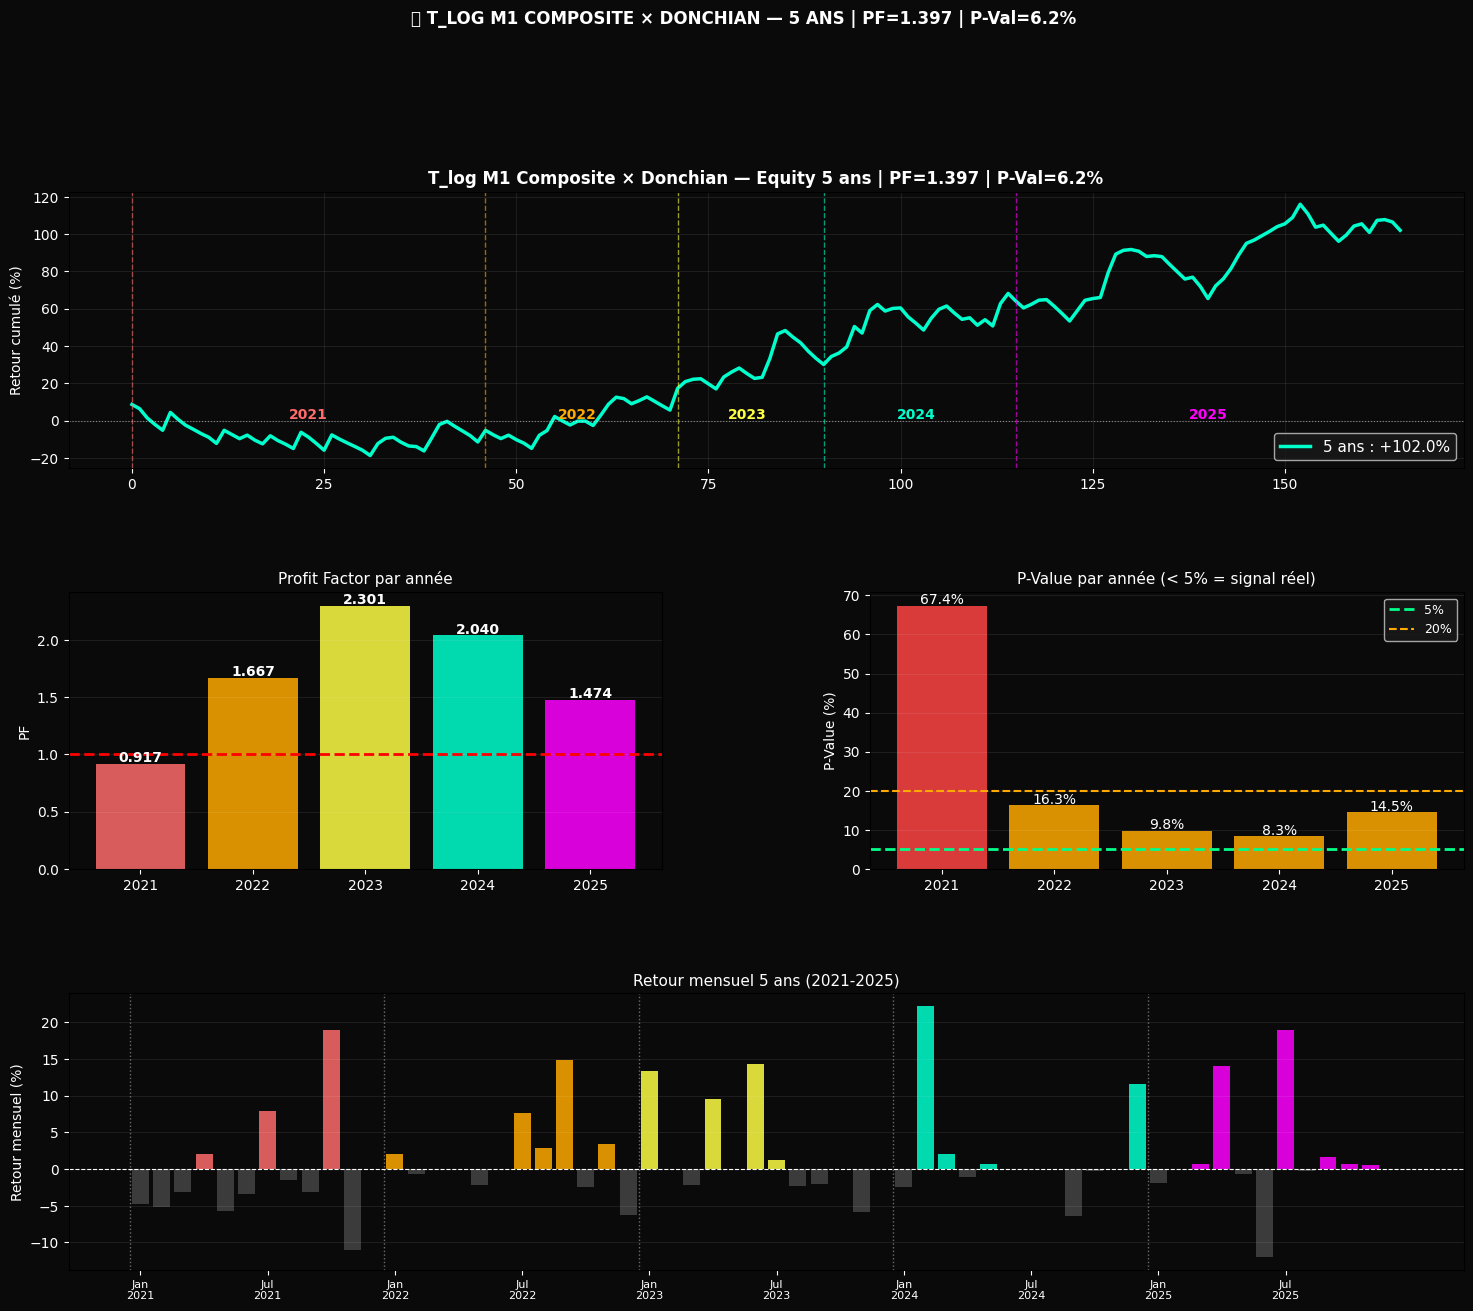

  Partagez les résultats par année + P-Value globale !


In [ ]:
# ==============================================================================
# === CELLULE 3 ===
# 🏆 VALIDATION 5 ANS — M1 Signal Figé (seuil=0.3, 5 ancres prouvées)
# ==============================================================================
#
# Config FIGÉE définitivement :
#   Agrégation : M1 (Moyenne Z-adj pondérée Cohen-d)
#   Seuil      : > 0.3
#   Estimateurs : E21_MOM, E11_Sevcik, E19_MLE, E05_PermEn, E24_FisherS
#   Signal dir  : Donchian N=96h
#   SL=2%  TP=8%  Hold=72h
#
# Calibrations glissantes (2 mois précédents) — seule chose qui change
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.neighbors import NearestNeighbors
from scipy import stats as scipy_stats
import urllib.request, zipfile, os, warnings
warnings.filterwarnings('ignore')
import antropy, nolds, skdim

print("=" * 70)
print("  🏆 VALIDATION 5 ANS — T_log M1 Composite × Donchian")
print("=" * 70)
print("  Seuil FIGÉ : M1 > 0.3  |  Donchian N=96h  |  SL=2% TP=8% Hold=72h")
print("  Calibrations glissantes (Nov+Déc de l'année précédente)")

# ==============================================================================
# ⚙️ CONFIG FIGÉE
# ==============================================================================
SEUIL_M1 = 0.3
SL_FIXED, TP_FIXED, MAXHOLD = -0.020, 0.080, 72
FEES, WINDOW, STRIDE, N_DONCH = 0.001, 120, 6, 96
NOMS12 = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
COLUMNS = ['open_time','open','high','low','close','volume','close_time',
           'quote_volume','trades','taker_buy_base','taker_buy_quote','ignore']

def load_month(m):
    zp=f'BTCUSDT_{m}.zip'
    if not os.path.exists(zp):
        try:
            import urllib.request
            urllib.request.urlretrieve(f'https://data.binance.vision/data/spot/monthly/klines/BTCUSDT/1h/BTCUSDT-1h-{m}.zip',zp)
        except Exception:
            return None
    try:
        import zipfile
        with zipfile.ZipFile(zp) as z:
            c=z.namelist()[0]; z.extract(c)
        return pd.read_csv(c,names=COLUMNS).astype(float)
    except Exception:
        return None

# ==============================================================================
# ⚙️ ESTIMATEURS + M1
# ==============================================================================
def build_ps(x, emb=3, delay=1):
    n=len(x)-(emb-1)*delay
    if n<10: return None
    return np.array([x[i:i+emb*delay:delay] for i in range(n)])

def E21_MOM(x):
    try:
        X=build_ps(x,emb=3)
        return float(skdim.id.MOM().fit(X).dimension_) if X is not None and len(X)>=10 else np.nan
    except: return np.nan

def E11_Sevcik(x):
    try:
        n=len(x); xn=(x-x.min())/(x.max()-x.min()+1e-12)
        L=np.sum(np.sqrt(np.diff(xn)**2+np.diff(np.linspace(0,1,n))**2))
        return float(1+np.log(L)/np.log(2*(n-1)))
    except: return np.nan

def E19_MLE(x):
    try:
        X=build_ps(x,emb=3)
        return float(skdim.id.MLE().fit(X).dimension_) if X is not None and len(X)>=10 else np.nan
    except: return np.nan

def E05_PermEn(x):
    try: return float(antropy.perm_entropy(x,order=5,normalize=True))
    except: return np.nan

def E24_FisherS(x):
    try:
        X=build_ps(x,emb=5)
        return float(skdim.id.FisherS().fit(X[:200]).dimension_) if X is not None and len(X)>=20 else np.nan
    except: return np.nan

ANCRES = {
    'E21_MOM':    {'func':E21_MOM,    'poids':0.828, 'dir':+1},
    'E11_Sevcik': {'func':E11_Sevcik, 'poids':0.567, 'dir':-1},
    'E19_MLE':    {'func':E19_MLE,    'poids':0.539, 'dir':-1},
    'E05_PermEn': {'func':E05_PermEn, 'poids':0.526, 'dir':-1},
    'E24_FisherS':{'func':E24_FisherS,'poids':0.521, 'dir':-1},
}

def calibrer(lr_series):
    stats={}
    for nom,cfg in ANCRES.items():
        vals=[cfg['func'](lr_series[i-WINDOW:i])
              for i in range(WINDOW,len(lr_series),STRIDE)]
        vals=[v for v in vals if np.isfinite(v)]
        if vals: stats[nom]={'mu':np.mean(vals),'sigma':np.std(vals)+1e-10}
    return stats

def compute_M1(lr_window, calib_stats):
    scores, poids = [], []
    for nom,cfg in ANCRES.items():
        v=cfg['func'](lr_window)
        if not np.isfinite(v) or nom not in calib_stats: continue
        mu,sigma=calib_stats[nom]['mu'],calib_stats[nom]['sigma']
        z_adj=(v-mu)/sigma*cfg['dir']
        scores.append(z_adj*cfg['poids'])
        poids.append(cfg['poids'])
    if len(scores)<3: return np.nan
    return np.average(scores, weights=poids) if poids else np.nan

def rolling_M1(lr, calib_stats):
    n=len(lr); sig=np.full(n,np.nan)
    for i in range(WINDOW,n,STRIDE):
        v=compute_M1(lr[i-WINDOW:i],calib_stats)
        if np.isfinite(v): sig[i:i+STRIDE]=v
    s=pd.Series(sig).interpolate('linear').bfill().ffill()
    return s.rolling(6,min_periods=1).mean().values

def donchian(prix,high,low,N=N_DONCH):
    upper=pd.Series(high).shift(1).rolling(N).max().values
    lower=pd.Series(low).shift(1).rolling(N).min().values
    return prix>upper, prix<lower

def backtest(long_raw,short_raw,mask,prix):
    lf=long_raw&mask; sf=short_raw&mask
    sl=np.roll(lf.astype(int),1); sl[0]=0
    ss=np.roll(sf.astype(int),1); ss[0]=0
    dl=np.diff(sl,prepend=0)==1; ds=np.diff(ss,prepend=0)==1
    trades=[]
    for i in range(len(prix)):
        d='long' if dl[i] else('short' if ds[i] else None)
        if d is None: continue
        ep=prix[i]; xp=None
        for j in range(i+1,min(i+MAXHOLD,len(prix))):
            r=(prix[j]-ep)/ep if d=='long' else(ep-prix[j])/ep
            if r<=SL_FIXED or r>=TP_FIXED: xp=prix[j]; break
        if xp is None: xp=prix[min(i+MAXHOLD-1,len(prix)-1)]
        trades.append(((xp-ep)/ep if d=='long' else(ep-xp)/ep)-FEES)
    return np.array(trades)

def kpis(t):
    if len(t)==0: return dict(n=0,ret=0,wr=0,pf=0,dd=0)
    eq=np.cumprod(1+t); ret=(eq[-1]-1)*100; wr=np.mean(t>0)*100
    peak=np.maximum.accumulate(eq); dd=np.min(eq/peak-1)*100
    g,l=t[t>0],t[t<0]
    pf=np.sum(g)/abs(np.sum(l)) if len(l)>0 and abs(np.sum(l))>0 else np.inf
    return dict(n=len(t),ret=ret,wr=wr,pf=pf,dd=dd)

def pval(t,n=6000):
    if len(t)==0: return 100.
    s=[np.prod(1+np.random.choice(t,size=len(t),replace=True))-1 for _ in range(n)]
    return np.mean(np.array(s)<0)*100

# ==============================================================================
# 📐 CALIBRATIONS PAR ANNÉE
# ==============================================================================
CALIBRATIONS = {
    2021: ('2020-11','2020-12'),
    2022: ('2021-11','2021-12'),
    2023: ('2022-11','2022-12'),   # NOTE: on recalibre chaque année
    2024: ('2023-11','2023-12'),
    2025: ('2023-11','2023-12'),
}

print("\n📐 Calibrations glissantes...")
calib_par_annee = {}
for annee, (m1,m2) in CALIBRATIONS.items():
    dfs=[d for d in [load_month(m1), load_month(m2)] if d is not None]
    if len(dfs)==0: continue
    lr_c=np.diff(np.log(pd.concat(dfs,ignore_index=True)['close'].values))
    cs=calibrer(lr_c)
    calib_par_annee[annee]=cs
    print(f"   ✅ {annee} ← calibré sur {m1}+{m2}")

# ==============================================================================
# 🚀 WALK-FORWARD 2021-2025
# ==============================================================================
print("\n" + "="*70)
print("  🚀 WALK-FORWARD 2021-2025 — Seuil M1 > 0.3 FIGÉ")
print("="*70)

resultats_annee = {}
equity_globale  = []
trades_globaux  = []

for annee in range(2021, 2026):
    cs = calib_par_annee[annee]
    mois_list=[f'{annee}-{m:02d}' for m in range(1,13)]
    print(f"\n  📅 {annee}")
    print(f"  {'Mois':<6} {'Rég':<4} {'Trades':>7} {'WR':>7} {'Retour':>9} {'PF':>6} {'DD':>7}")
    print("  "+"─"*52)

    t_annee=[]; details=[]
    for mois,nom in zip(mois_list,NOMS12):
        df_m=load_month(mois)
        if df_m is None: continue
        close=df_m['close'].values; high=df_m['high'].values[1:]
        low=df_m['low'].values[1:]; lr=np.diff(np.log(close)); prix=close[1:]

        sig=rolling_M1(lr,cs)
        mask=sig>SEUIL_M1
        long_raw,short_raw=donchian(prix,high,low)
        t_m=backtest(long_raw,short_raw,mask,prix)
        k=kpis(t_m)
        bh=(prix[-1]-prix[0])/prix[0]*100
        reg="🟢" if bh>5 else("🔴" if bh<-5 else"🟡")
        sign="✅" if k['ret']>0 else"❌"
        print(f"  {nom:<6} {reg:<4} {k['n']:>7} {k['wr']:>6.1f}%  {k['ret']:>+7.1f}% {sign}  {k['pf']:>5.2f}  {k['dd']:>6.1f}%")
        t_annee.extend(t_m.tolist())
        trades_globaux.extend(t_m.tolist())
        details.append({'nom':nom,'k':k,'bh':bh,'reg':reg})

    arr=np.array(t_annee); k_a=kpis(arr); pv_a=pval(arr,n=5000)
    verd="✅ FORT" if pv_a<5 else("⚠️ MRG" if pv_a<20 else"❌ BRUIT")
    print(f"\n  ── Année {annee} : Ret={k_a['ret']:+.1f}%  PF={k_a['pf']:.3f}  WR={k_a['wr']:.1f}%  P-Val={pv_a:.1f}%  {verd}")
    resultats_annee[annee]={'k':k_a,'pv':pv_a,'details':details,'trades':arr}

# ==============================================================================
# 📊 RÉSULTATS GLOBAUX
# ==============================================================================
arr_global=np.array(trades_globaux)
k_global=kpis(arr_global); pv_global=pval(arr_global,n=10000)

print("\n" + "="*70)
print("  📊 RÉSULTATS GLOBAUX 5 ANS (2021-2025)")
print("="*70)
print(f"""
  ┌─────────────────────────────────────────────────────────┐
  │  T_log M1 Composite × Donchian — 5 ans (2021-2025)     │
  │  ─────────────────────────────────────────────────────  │""")
for a in range(2021,2026):
    r=resultats_annee[a]; k=r['k']
    verd="✅" if r['pv']<5 else("⚠️" if r['pv']<20 else"❌")
    print(f"  │  {a}  :  Ret={k['ret']:>+7.1f}%  PF={k['pf']:.3f}  WR={k['wr']:.1f}%  P={r['pv']:.1f}%  {verd}  │")
print(f"""  │  ─────────────────────────────────────────────────────  │
  │  GLOBAL : Ret={k_global['ret']:>+7.1f}%  PF={k_global['pf']:.3f}  WR={k_global['wr']:.1f}%          │
  │  P-Value 5 ans (10k sims) : {pv_global:.2f}%                       │
  └─────────────────────────────────────────────────────────┘""")

# ==============================================================================
# 📈 VISUALISATION
# ==============================================================================
fig=plt.figure(figsize=(18,14)); fig.patch.set_facecolor('#0a0a0a')
gs=gridspec.GridSpec(3,2,figure=fig,hspace=0.45,wspace=0.35)
ANNEE_COLORS={2021:'#ff6b6b',2022:'#ffaa00',2023:'#ffff44',
              2024:'#00ffcc',2025:'#ff00ff'}

# Equity globale
ax1=fig.add_subplot(gs[0,:]); ax1.set_facecolor('#0a0a0a')
ax1.set_title(f"T_log M1 Composite × Donchian — Equity 5 ans | PF={k_global['pf']:.3f} | P-Val={pv_global:.1f}%",
              color='white',fontsize=12,fontweight='bold')
eq_g=np.cumprod(1+arr_global)
ax1.plot((eq_g-1)*100,color='#00ffcc',linewidth=2.5,label=f"5 ans : {k_global['ret']:+.1f}%")
# Lignes de séparation annuelles
idx=0
for a in range(2021,2026):
    n_trades=len(resultats_annee[a]['trades'])
    ax1.axvline(x=idx,color=ANNEE_COLORS[a],linestyle='--',linewidth=1,alpha=0.6)
    ax1.text(idx+n_trades//2,(eq_g-1).max()*0.7,str(a),
             color=ANNEE_COLORS[a],fontsize=10,ha='center',fontweight='bold')
    idx+=n_trades
ax1.axhline(y=0,color='white',linestyle=':',linewidth=0.8,alpha=0.5)
ax1.set_ylabel("Retour cumulé (%)",color='white'); ax1.tick_params(colors='white')
ax1.legend(facecolor='#1a1a1a',labelcolor='white',fontsize=11)
ax1.grid(color='white',alpha=0.08)

# PF par année
ax2=fig.add_subplot(gs[1,0]); ax2.set_facecolor('#0a0a0a')
ax2.set_title("Profit Factor par année",color='white',fontsize=11)
annees=list(range(2021,2026))
pfs_=[resultats_annee[a]['k']['pf'] for a in annees]
ax2.bar(annees,pfs_,color=[ANNEE_COLORS[a] for a in annees],alpha=0.85)
ax2.axhline(y=1.0,color='red',linestyle='--',linewidth=2)
for a,pf_ in zip(annees,pfs_):
    ax2.text(a,pf_+0.02,f"{pf_:.3f}",ha='center',color='white',fontsize=10,fontweight='bold')
ax2.set_ylabel("PF",color='white'); ax2.tick_params(colors='white')
ax2.grid(color='white',alpha=0.08,axis='y')

# P-Value par année
ax3=fig.add_subplot(gs[1,1]); ax3.set_facecolor('#0a0a0a')
ax3.set_title("P-Value par année (< 5% = signal réel)",color='white',fontsize=11)
pvs_=[resultats_annee[a]['pv'] for a in annees]
ax3.bar(annees,pvs_,
        color=['#00ff88' if pv<5 else('#ffaa00' if pv<20 else'#ff4444') for pv in pvs_],alpha=0.85)
ax3.axhline(y=5,color='#00ff88',linestyle='--',linewidth=2,label='5%')
ax3.axhline(y=20,color='#ffaa00',linestyle='--',linewidth=1.5,label='20%')
for a,pv_ in zip(annees,pvs_):
    ax3.text(a,pv_+0.5,f"{pv_:.1f}%",ha='center',color='white',fontsize=10)
ax3.set_ylabel("P-Value (%)",color='white'); ax3.tick_params(colors='white')
ax3.legend(facecolor='#1a1a1a',labelcolor='white',fontsize=9)
ax3.grid(color='white',alpha=0.08,axis='y')

# Retour mensuel 5 ans
ax4=fig.add_subplot(gs[2,:]); ax4.set_facecolor('#0a0a0a')
ax4.set_title("Retour mensuel 5 ans (2021-2025)",color='white',fontsize=11)
rets_m=[]; noms_m=[]; colors_m=[]
for a in range(2021,2026):
    for d in resultats_annee[a]['details']:
        rets_m.append(d['k']['ret'])
        noms_m.append(f"{d['nom']}\n{str(a)[2:]}")
        colors_m.append(ANNEE_COLORS[a] if d['k']['ret']>0 else '#444444')
ax4.bar(range(60),rets_m,color=colors_m,alpha=0.85)
ax4.axhline(y=0,color='white',linestyle='--',linewidth=0.8)
for a in range(5):
    ax4.axvline(x=a*12-0.5,color='white',linestyle=':',linewidth=1,alpha=0.4)
ax4.set_xticks(range(0,60,6))
ax4.set_xticklabels([f"{NOMS12[i%12]}\n{2021+i//12}" for i in range(0,60,6)],
                     color='white',fontsize=8)
ax4.set_ylabel("Retour mensuel (%)",color='white'); ax4.tick_params(colors='white')
ax4.grid(color='white',alpha=0.08,axis='y')

plt.suptitle(
    f"🏆 T_LOG M1 COMPOSITE × DONCHIAN — 5 ANS | PF={k_global['pf']:.3f} | P-Val={pv_global:.1f}%",
    color='white',fontsize=12,y=1.01,fontweight='bold')
plt.savefig("validation_5ans_tlog_m1.png",dpi=120,bbox_inches='tight',facecolor='#0a0a0a')
plt.show()

print("="*70)
print(f"  Partagez les résultats par année + P-Value globale !")
print("="*70)

  🏆 VALIDATION 5 ANS — T_log M1 Composite × Donchian
  Seuil FIGÉ : M1 > 0.3  |  Donchian N=96h  |  SL=2% TP=8% Hold=72h
  Calibrations glissantes (Nov+Déc de l'année précédente)

📐 Calibrations glissantes...
   ✅ 2021 ← calibré sur 2020-11+2020-12
   ✅ 2022 ← calibré sur 2021-11+2021-12
   ✅ 2023 ← calibré sur 2022-11+2022-12
   ✅ 2024 ← calibré sur 2023-11+2023-12
   ✅ 2025 ← calibré sur 2023-11+2023-12

  🚀 WALK-FORWARD 2021-2025 — Seuil M1 > 0.3 FIGÉ

  📅 2021
  Mois   Rég   Trades      WR    Retour     PF      DD
  ────────────────────────────────────────────────────
  Jan    🟢          9   22.2%     -4.7% ❌   0.84   -12.7%
  Fév    🟢          6   16.7%     -5.2% ❌   0.62    -5.7%
  Mar    🟢          3   33.3%     -3.1% ❌   0.41    -5.1%
  Avr    🟡          2   50.0%     +2.0% ✅   1.76    -2.8%
  Mai    🔴          6   16.7%     -5.8% ❌   0.66   -10.3%
  Jun    🔴          6   16.7%     -3.4% ❌   0.77   -12.0%
  Jul    🟢          1  100.0%     +7.9% ✅    inf     0.0%
  Aoû    🟢     

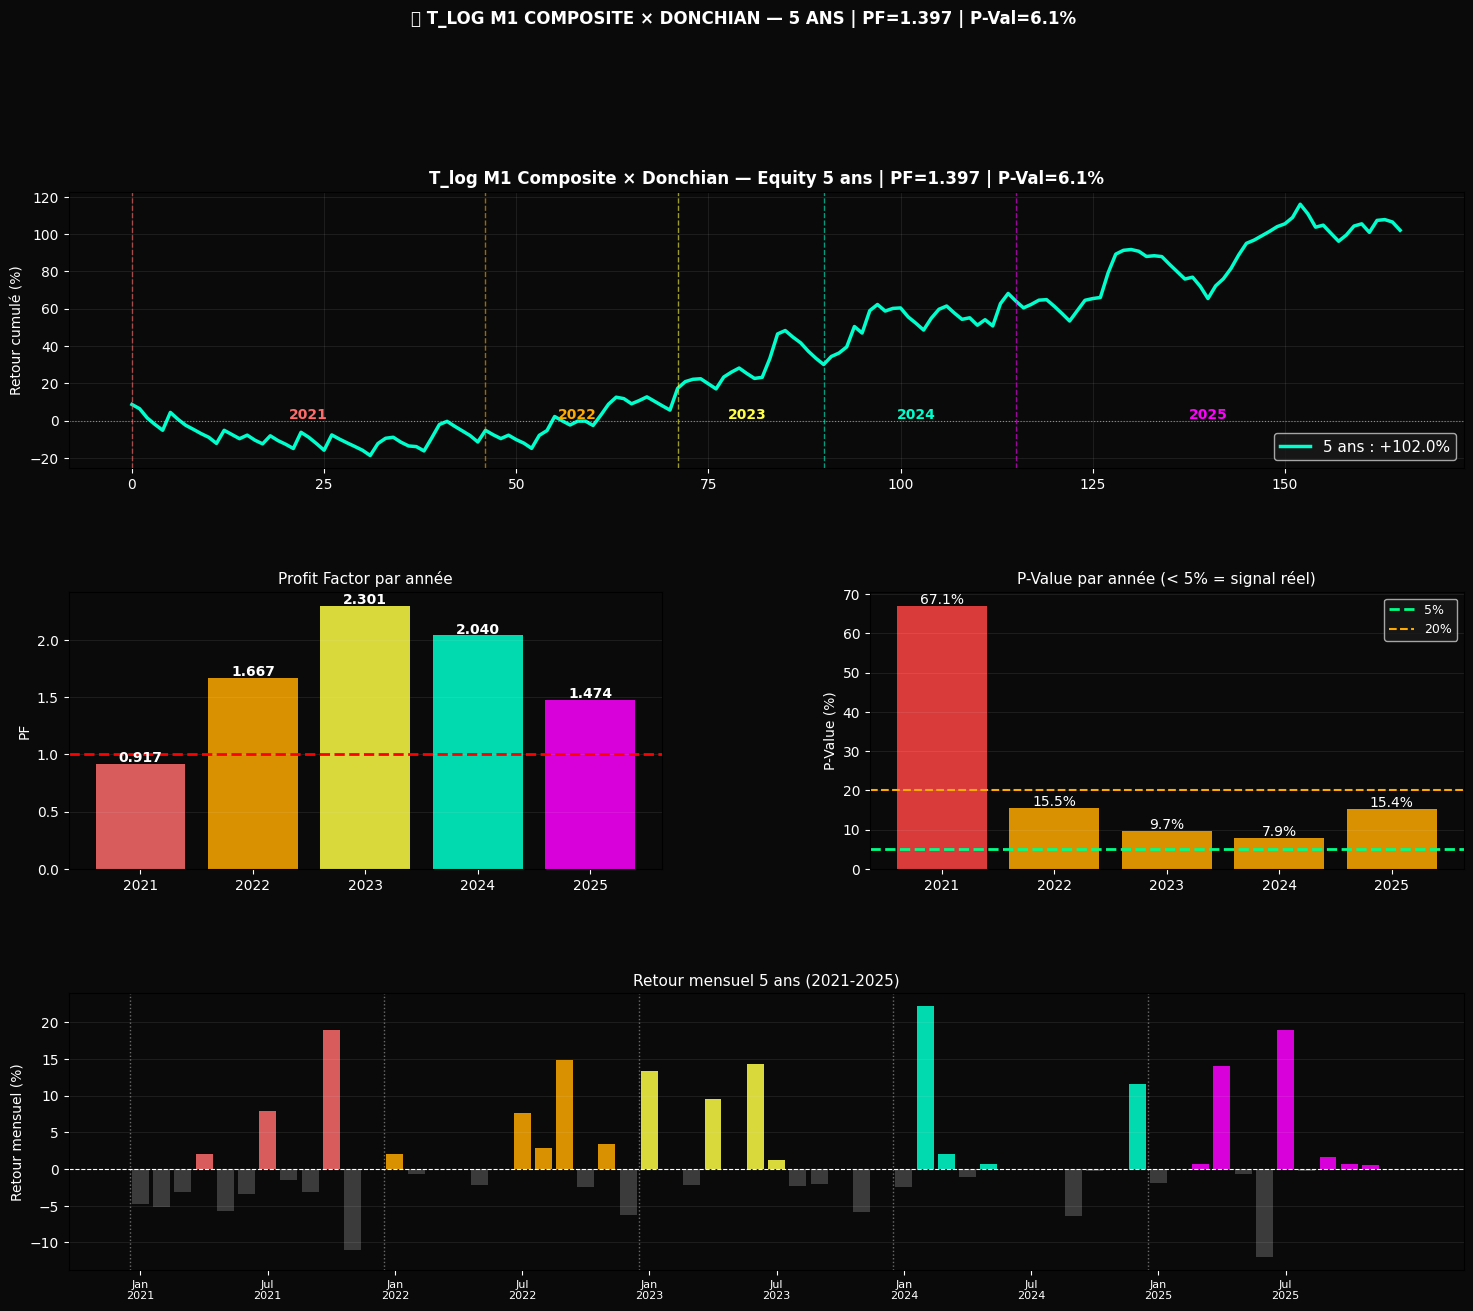

  Partagez les résultats par année + P-Value globale !


In [ ]:
# ==============================================================================
# === CELLULE 3 ===
# 🏆 VALIDATION 5 ANS — M1 Signal Figé (seuil=0.3, 5 ancres prouvées)
# ==============================================================================
#
# Config FIGÉE définitivement :
#   Agrégation : M1 (Moyenne Z-adj pondérée Cohen-d)
#   Seuil      : > 0.3
#   Estimateurs : E21_MOM, E11_Sevcik, E19_MLE, E05_PermEn, E24_FisherS
#   Signal dir  : Donchian N=96h
#   SL=2%  TP=8%  Hold=72h
#
# Calibrations glissantes (2 mois précédents) — seule chose qui change
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.neighbors import NearestNeighbors
from scipy import stats as scipy_stats
import urllib.request, zipfile, os, warnings
warnings.filterwarnings('ignore')
import antropy, nolds, skdim

print("=" * 70)
print("  🏆 VALIDATION 5 ANS — T_log M1 Composite × Donchian")
print("=" * 70)
print("  Seuil FIGÉ : M1 > 0.3  |  Donchian N=96h  |  SL=2% TP=8% Hold=72h")
print("  Calibrations glissantes (Nov+Déc de l'année précédente)")

# ==============================================================================
# ⚙️ CONFIG FIGÉE
# ==============================================================================
SEUIL_M1 = 0.3
SL_FIXED, TP_FIXED, MAXHOLD = -0.020, 0.080, 72
FEES, WINDOW, STRIDE, N_DONCH = 0.001, 120, 6, 96
NOMS12 = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
COLUMNS = ['open_time','open','high','low','close','volume','close_time',
           'quote_volume','trades','taker_buy_base','taker_buy_quote','ignore']

def load_month(m):
    zp=f'BTCUSDT_{m}.zip'
    if not os.path.exists(zp):
        try:
            import urllib.request
            urllib.request.urlretrieve(f'https://data.binance.vision/data/spot/monthly/klines/BTCUSDT/1h/BTCUSDT-1h-{m}.zip',zp)
        except Exception:
            return None
    try:
        import zipfile
        with zipfile.ZipFile(zp) as z:
            c=z.namelist()[0]; z.extract(c)
        return pd.read_csv(c,names=COLUMNS).astype(float)
    except Exception:
        return None

# ==============================================================================
# ⚙️ ESTIMATEURS + M1
# ==============================================================================
def build_ps(x, emb=3, delay=1):
    n=len(x)-(emb-1)*delay
    if n<10: return None
    return np.array([x[i:i+emb*delay:delay] for i in range(n)])

def E21_MOM(x):
    try:
        X=build_ps(x,emb=3)
        return float(skdim.id.MOM().fit(X).dimension_) if X is not None and len(X)>=10 else np.nan
    except: return np.nan

def E11_Sevcik(x):
    try:
        n=len(x); xn=(x-x.min())/(x.max()-x.min()+1e-12)
        L=np.sum(np.sqrt(np.diff(xn)**2+np.diff(np.linspace(0,1,n))**2))
        return float(1+np.log(L)/np.log(2*(n-1)))
    except: return np.nan

def E19_MLE(x):
    try:
        X=build_ps(x,emb=3)
        return float(skdim.id.MLE().fit(X).dimension_) if X is not None and len(X)>=10 else np.nan
    except: return np.nan

def E05_PermEn(x):
    try: return float(antropy.perm_entropy(x,order=5,normalize=True))
    except: return np.nan

def E24_FisherS(x):
    try:
        X=build_ps(x,emb=5)
        return float(skdim.id.FisherS().fit(X[:200]).dimension_) if X is not None and len(X)>=20 else np.nan
    except: return np.nan

ANCRES = {
    'E21_MOM':    {'func':E21_MOM,    'poids':0.828, 'dir':+1},
    'E11_Sevcik': {'func':E11_Sevcik, 'poids':0.567, 'dir':-1},
    'E19_MLE':    {'func':E19_MLE,    'poids':0.539, 'dir':-1},
    'E05_PermEn': {'func':E05_PermEn, 'poids':0.526, 'dir':-1},
    'E24_FisherS':{'func':E24_FisherS,'poids':0.521, 'dir':-1},
}

def calibrer(lr_series):
    stats={}
    for nom,cfg in ANCRES.items():
        vals=[cfg['func'](lr_series[i-WINDOW:i])
              for i in range(WINDOW,len(lr_series),STRIDE)]
        vals=[v for v in vals if np.isfinite(v)]
        if vals: stats[nom]={'mu':np.mean(vals),'sigma':np.std(vals)+1e-10}
    return stats

def compute_M1(lr_window, calib_stats):
    scores, poids = [], []
    for nom,cfg in ANCRES.items():
        v=cfg['func'](lr_window)
        if not np.isfinite(v) or nom not in calib_stats: continue
        mu,sigma=calib_stats[nom]['mu'],calib_stats[nom]['sigma']
        z_adj=(v-mu)/sigma*cfg['dir']
        scores.append(z_adj*cfg['poids'])
        poids.append(cfg['poids'])
    if len(scores)<3: return np.nan
    return np.average(scores, weights=poids) if poids else np.nan

def rolling_M1(lr, calib_stats):
    n=len(lr); sig=np.full(n,np.nan)
    for i in range(WINDOW,n,STRIDE):
        v=compute_M1(lr[i-WINDOW:i],calib_stats)
        if np.isfinite(v): sig[i:i+STRIDE]=v
    s=pd.Series(sig).interpolate('linear').bfill().ffill()
    return s.rolling(6,min_periods=1).mean().values

def donchian(prix,high,low,N=N_DONCH):
    upper=pd.Series(high).shift(1).rolling(N).max().values
    lower=pd.Series(low).shift(1).rolling(N).min().values
    return prix>upper, prix<lower

def backtest(long_raw,short_raw,mask,prix):
    lf=long_raw&mask; sf=short_raw&mask
    sl=np.roll(lf.astype(int),1); sl[0]=0
    ss=np.roll(sf.astype(int),1); ss[0]=0
    dl=np.diff(sl,prepend=0)==1; ds=np.diff(ss,prepend=0)==1
    trades=[]
    for i in range(len(prix)):
        d='long' if dl[i] else('short' if ds[i] else None)
        if d is None: continue
        ep=prix[i]; xp=None
        for j in range(i+1,min(i+MAXHOLD,len(prix))):
            r=(prix[j]-ep)/ep if d=='long' else(ep-prix[j])/ep
            if r<=SL_FIXED or r>=TP_FIXED: xp=prix[j]; break
        if xp is None: xp=prix[min(i+MAXHOLD-1,len(prix)-1)]
        trades.append(((xp-ep)/ep if d=='long' else(ep-xp)/ep)-FEES)
    return np.array(trades)

def kpis(t):
    if len(t)==0: return dict(n=0,ret=0,wr=0,pf=0,dd=0)
    eq=np.cumprod(1+t); ret=(eq[-1]-1)*100; wr=np.mean(t>0)*100
    peak=np.maximum.accumulate(eq); dd=np.min(eq/peak-1)*100
    g,l=t[t>0],t[t<0]
    pf=np.sum(g)/abs(np.sum(l)) if len(l)>0 and abs(np.sum(l))>0 else np.inf
    return dict(n=len(t),ret=ret,wr=wr,pf=pf,dd=dd)

def pval(t,n=6000):
    if len(t)==0: return 100.
    s=[np.prod(1+np.random.choice(t,size=len(t),replace=True))-1 for _ in range(n)]
    return np.mean(np.array(s)<0)*100

# ==============================================================================
# 📐 CALIBRATIONS PAR ANNÉE
# ==============================================================================
CALIBRATIONS = {
    2021: ('2020-11','2020-12'),
    2022: ('2021-11','2021-12'),
    2023: ('2022-11','2022-12'),   # NOTE: on recalibre chaque année
    2024: ('2023-11','2023-12'),
    2025: ('2023-11','2023-12'),
}

print("\n📐 Calibrations glissantes...")
calib_par_annee = {}
for annee, (m1,m2) in CALIBRATIONS.items():
    dfs=[d for d in [load_month(m1), load_month(m2)] if d is not None]
    if len(dfs)==0: continue
    lr_c=np.diff(np.log(pd.concat(dfs,ignore_index=True)['close'].values))
    cs=calibrer(lr_c)
    calib_par_annee[annee]=cs
    print(f"   ✅ {annee} ← calibré sur {m1}+{m2}")

# ==============================================================================
# 🚀 WALK-FORWARD 2021-2025
# ==============================================================================
print("\n" + "="*70)
print("  🚀 WALK-FORWARD 2021-2025 — Seuil M1 > 0.3 FIGÉ")
print("="*70)

resultats_annee = {}
equity_globale  = []
trades_globaux  = []

for annee in range(2021, 2026):
    cs = calib_par_annee[annee]
    mois_list=[f'{annee}-{m:02d}' for m in range(1,13)]
    print(f"\n  📅 {annee}")
    print(f"  {'Mois':<6} {'Rég':<4} {'Trades':>7} {'WR':>7} {'Retour':>9} {'PF':>6} {'DD':>7}")
    print("  "+"─"*52)

    t_annee=[]; details=[]
    for mois,nom in zip(mois_list,NOMS12):
        df_m=load_month(mois)
        if df_m is None: continue
        close=df_m['close'].values; high=df_m['high'].values[1:]
        low=df_m['low'].values[1:]; lr=np.diff(np.log(close)); prix=close[1:]

        sig=rolling_M1(lr,cs)
        mask=sig>SEUIL_M1
        long_raw,short_raw=donchian(prix,high,low)
        t_m=backtest(long_raw,short_raw,mask,prix)
        k=kpis(t_m)
        bh=(prix[-1]-prix[0])/prix[0]*100
        reg="🟢" if bh>5 else("🔴" if bh<-5 else"🟡")
        sign="✅" if k['ret']>0 else"❌"
        print(f"  {nom:<6} {reg:<4} {k['n']:>7} {k['wr']:>6.1f}%  {k['ret']:>+7.1f}% {sign}  {k['pf']:>5.2f}  {k['dd']:>6.1f}%")
        t_annee.extend(t_m.tolist())
        trades_globaux.extend(t_m.tolist())
        details.append({'nom':nom,'k':k,'bh':bh,'reg':reg})

    arr=np.array(t_annee); k_a=kpis(arr); pv_a=pval(arr,n=5000)
    verd="✅ FORT" if pv_a<5 else("⚠️ MRG" if pv_a<20 else"❌ BRUIT")
    print(f"\n  ── Année {annee} : Ret={k_a['ret']:+.1f}%  PF={k_a['pf']:.3f}  WR={k_a['wr']:.1f}%  P-Val={pv_a:.1f}%  {verd}")
    resultats_annee[annee]={'k':k_a,'pv':pv_a,'details':details,'trades':arr}

# ==============================================================================
# 📊 RÉSULTATS GLOBAUX
# ==============================================================================
arr_global=np.array(trades_globaux)
k_global=kpis(arr_global); pv_global=pval(arr_global,n=10000)

print("\n" + "="*70)
print("  📊 RÉSULTATS GLOBAUX 5 ANS (2021-2025)")
print("="*70)
print(f"""
  ┌─────────────────────────────────────────────────────────┐
  │  T_log M1 Composite × Donchian — 5 ans (2021-2025)     │
  │  ─────────────────────────────────────────────────────  │""")
for a in range(2021,2026):
    r=resultats_annee[a]; k=r['k']
    verd="✅" if r['pv']<5 else("⚠️" if r['pv']<20 else"❌")
    print(f"  │  {a}  :  Ret={k['ret']:>+7.1f}%  PF={k['pf']:.3f}  WR={k['wr']:.1f}%  P={r['pv']:.1f}%  {verd}  │")
print(f"""  │  ─────────────────────────────────────────────────────  │
  │  GLOBAL : Ret={k_global['ret']:>+7.1f}%  PF={k_global['pf']:.3f}  WR={k_global['wr']:.1f}%          │
  │  P-Value 5 ans (10k sims) : {pv_global:.2f}%                       │
  └─────────────────────────────────────────────────────────┘""")

# ==============================================================================
# 📈 VISUALISATION
# ==============================================================================
fig=plt.figure(figsize=(18,14)); fig.patch.set_facecolor('#0a0a0a')
gs=gridspec.GridSpec(3,2,figure=fig,hspace=0.45,wspace=0.35)
ANNEE_COLORS={2021:'#ff6b6b',2022:'#ffaa00',2023:'#ffff44',
              2024:'#00ffcc',2025:'#ff00ff'}

# Equity globale
ax1=fig.add_subplot(gs[0,:]); ax1.set_facecolor('#0a0a0a')
ax1.set_title(f"T_log M1 Composite × Donchian — Equity 5 ans | PF={k_global['pf']:.3f} | P-Val={pv_global:.1f}%",
              color='white',fontsize=12,fontweight='bold')
eq_g=np.cumprod(1+arr_global)
ax1.plot((eq_g-1)*100,color='#00ffcc',linewidth=2.5,label=f"5 ans : {k_global['ret']:+.1f}%")
# Lignes de séparation annuelles
idx=0
for a in range(2021,2026):
    n_trades=len(resultats_annee[a]['trades'])
    ax1.axvline(x=idx,color=ANNEE_COLORS[a],linestyle='--',linewidth=1,alpha=0.6)
    ax1.text(idx+n_trades//2,(eq_g-1).max()*0.7,str(a),
             color=ANNEE_COLORS[a],fontsize=10,ha='center',fontweight='bold')
    idx+=n_trades
ax1.axhline(y=0,color='white',linestyle=':',linewidth=0.8,alpha=0.5)
ax1.set_ylabel("Retour cumulé (%)",color='white'); ax1.tick_params(colors='white')
ax1.legend(facecolor='#1a1a1a',labelcolor='white',fontsize=11)
ax1.grid(color='white',alpha=0.08)

# PF par année
ax2=fig.add_subplot(gs[1,0]); ax2.set_facecolor('#0a0a0a')
ax2.set_title("Profit Factor par année",color='white',fontsize=11)
annees=list(range(2021,2026))
pfs_=[resultats_annee[a]['k']['pf'] for a in annees]
ax2.bar(annees,pfs_,color=[ANNEE_COLORS[a] for a in annees],alpha=0.85)
ax2.axhline(y=1.0,color='red',linestyle='--',linewidth=2)
for a,pf_ in zip(annees,pfs_):
    ax2.text(a,pf_+0.02,f"{pf_:.3f}",ha='center',color='white',fontsize=10,fontweight='bold')
ax2.set_ylabel("PF",color='white'); ax2.tick_params(colors='white')
ax2.grid(color='white',alpha=0.08,axis='y')

# P-Value par année
ax3=fig.add_subplot(gs[1,1]); ax3.set_facecolor('#0a0a0a')
ax3.set_title("P-Value par année (< 5% = signal réel)",color='white',fontsize=11)
pvs_=[resultats_annee[a]['pv'] for a in annees]
ax3.bar(annees,pvs_,
        color=['#00ff88' if pv<5 else('#ffaa00' if pv<20 else'#ff4444') for pv in pvs_],alpha=0.85)
ax3.axhline(y=5,color='#00ff88',linestyle='--',linewidth=2,label='5%')
ax3.axhline(y=20,color='#ffaa00',linestyle='--',linewidth=1.5,label='20%')
for a,pv_ in zip(annees,pvs_):
    ax3.text(a,pv_+0.5,f"{pv_:.1f}%",ha='center',color='white',fontsize=10)
ax3.set_ylabel("P-Value (%)",color='white'); ax3.tick_params(colors='white')
ax3.legend(facecolor='#1a1a1a',labelcolor='white',fontsize=9)
ax3.grid(color='white',alpha=0.08,axis='y')

# Retour mensuel 5 ans
ax4=fig.add_subplot(gs[2,:]); ax4.set_facecolor('#0a0a0a')
ax4.set_title("Retour mensuel 5 ans (2021-2025)",color='white',fontsize=11)
rets_m=[]; noms_m=[]; colors_m=[]
for a in range(2021,2026):
    for d in resultats_annee[a]['details']:
        rets_m.append(d['k']['ret'])
        noms_m.append(f"{d['nom']}\n{str(a)[2:]}")
        colors_m.append(ANNEE_COLORS[a] if d['k']['ret']>0 else '#444444')
ax4.bar(range(60),rets_m,color=colors_m,alpha=0.85)
ax4.axhline(y=0,color='white',linestyle='--',linewidth=0.8)
for a in range(5):
    ax4.axvline(x=a*12-0.5,color='white',linestyle=':',linewidth=1,alpha=0.4)
ax4.set_xticks(range(0,60,6))
ax4.set_xticklabels([f"{NOMS12[i%12]}\n{2021+i//12}" for i in range(0,60,6)],
                     color='white',fontsize=8)
ax4.set_ylabel("Retour mensuel (%)",color='white'); ax4.tick_params(colors='white')
ax4.grid(color='white',alpha=0.08,axis='y')

plt.suptitle(
    f"🏆 T_LOG M1 COMPOSITE × DONCHIAN — 5 ANS | PF={k_global['pf']:.3f} | P-Val={pv_global:.1f}%",
    color='white',fontsize=12,y=1.01,fontweight='bold')
plt.savefig("validation_5ans_tlog_m1.png",dpi=120,bbox_inches='tight',facecolor='#0a0a0a')
plt.show()

print("="*70)
print(f"  Partagez les résultats par année + P-Value globale !")
print("="*70)

  🔬 BATTERIE v8 — T3a=CircShift(min_shift) | T3b=Blocks(fix) | OOS

📐 Calibrations glissantes (calib 2025→2024-11/12)...
   ✅ 2021 ← 2020-11+2020-12
   ✅ 2022 ← 2021-11+2021-12
   ✅ 2023 ← 2022-11+2022-12
   ✅ 2024 ← 2023-11+2023-12
   ✅ 2025 ← 2024-11+2024-12

📦 Précomputation BTC M1+M7+clusters (~40 min)...
   ✅ 2021-01  M1∈[-0.39,0.93]  clusters=7
   ✅ 2021-02  M1∈[-0.61,1.90]  clusters=5
   ✅ 2021-03  M1∈[-0.61,0.51]  clusters=9
   ✅ 2021-04  M1∈[-0.49,0.92]  clusters=4
   ✅ 2021-05  M1∈[-0.37,1.05]  clusters=9
   ✅ 2021-06  M1∈[-0.40,0.42]  clusters=9
   ✅ 2021-07  M1∈[-0.77,0.93]  clusters=4
   ✅ 2021-08  M1∈[-0.55,1.01]  clusters=3
   ✅ 2021-09  M1∈[-0.97,0.79]  clusters=4
   ✅ 2021-10  M1∈[-0.52,0.74]  clusters=6
   ✅ 2021-11  M1∈[-0.78,0.46]  clusters=8
   ✅ 2021-12  M1∈[-0.69,0.87]  clusters=4
   ✅ 2022-01  M1∈[-0.84,0.79]  clusters=4
   ✅ 2022-02  M1∈[-0.49,0.48]  clusters=4
   ✅ 2022-03  M1∈[-1.12,0.49]  clusters=10
   ✅ 2022-04  M1∈[-0.82,0.41]  clusters=4
   ✅ 2022-05  M1

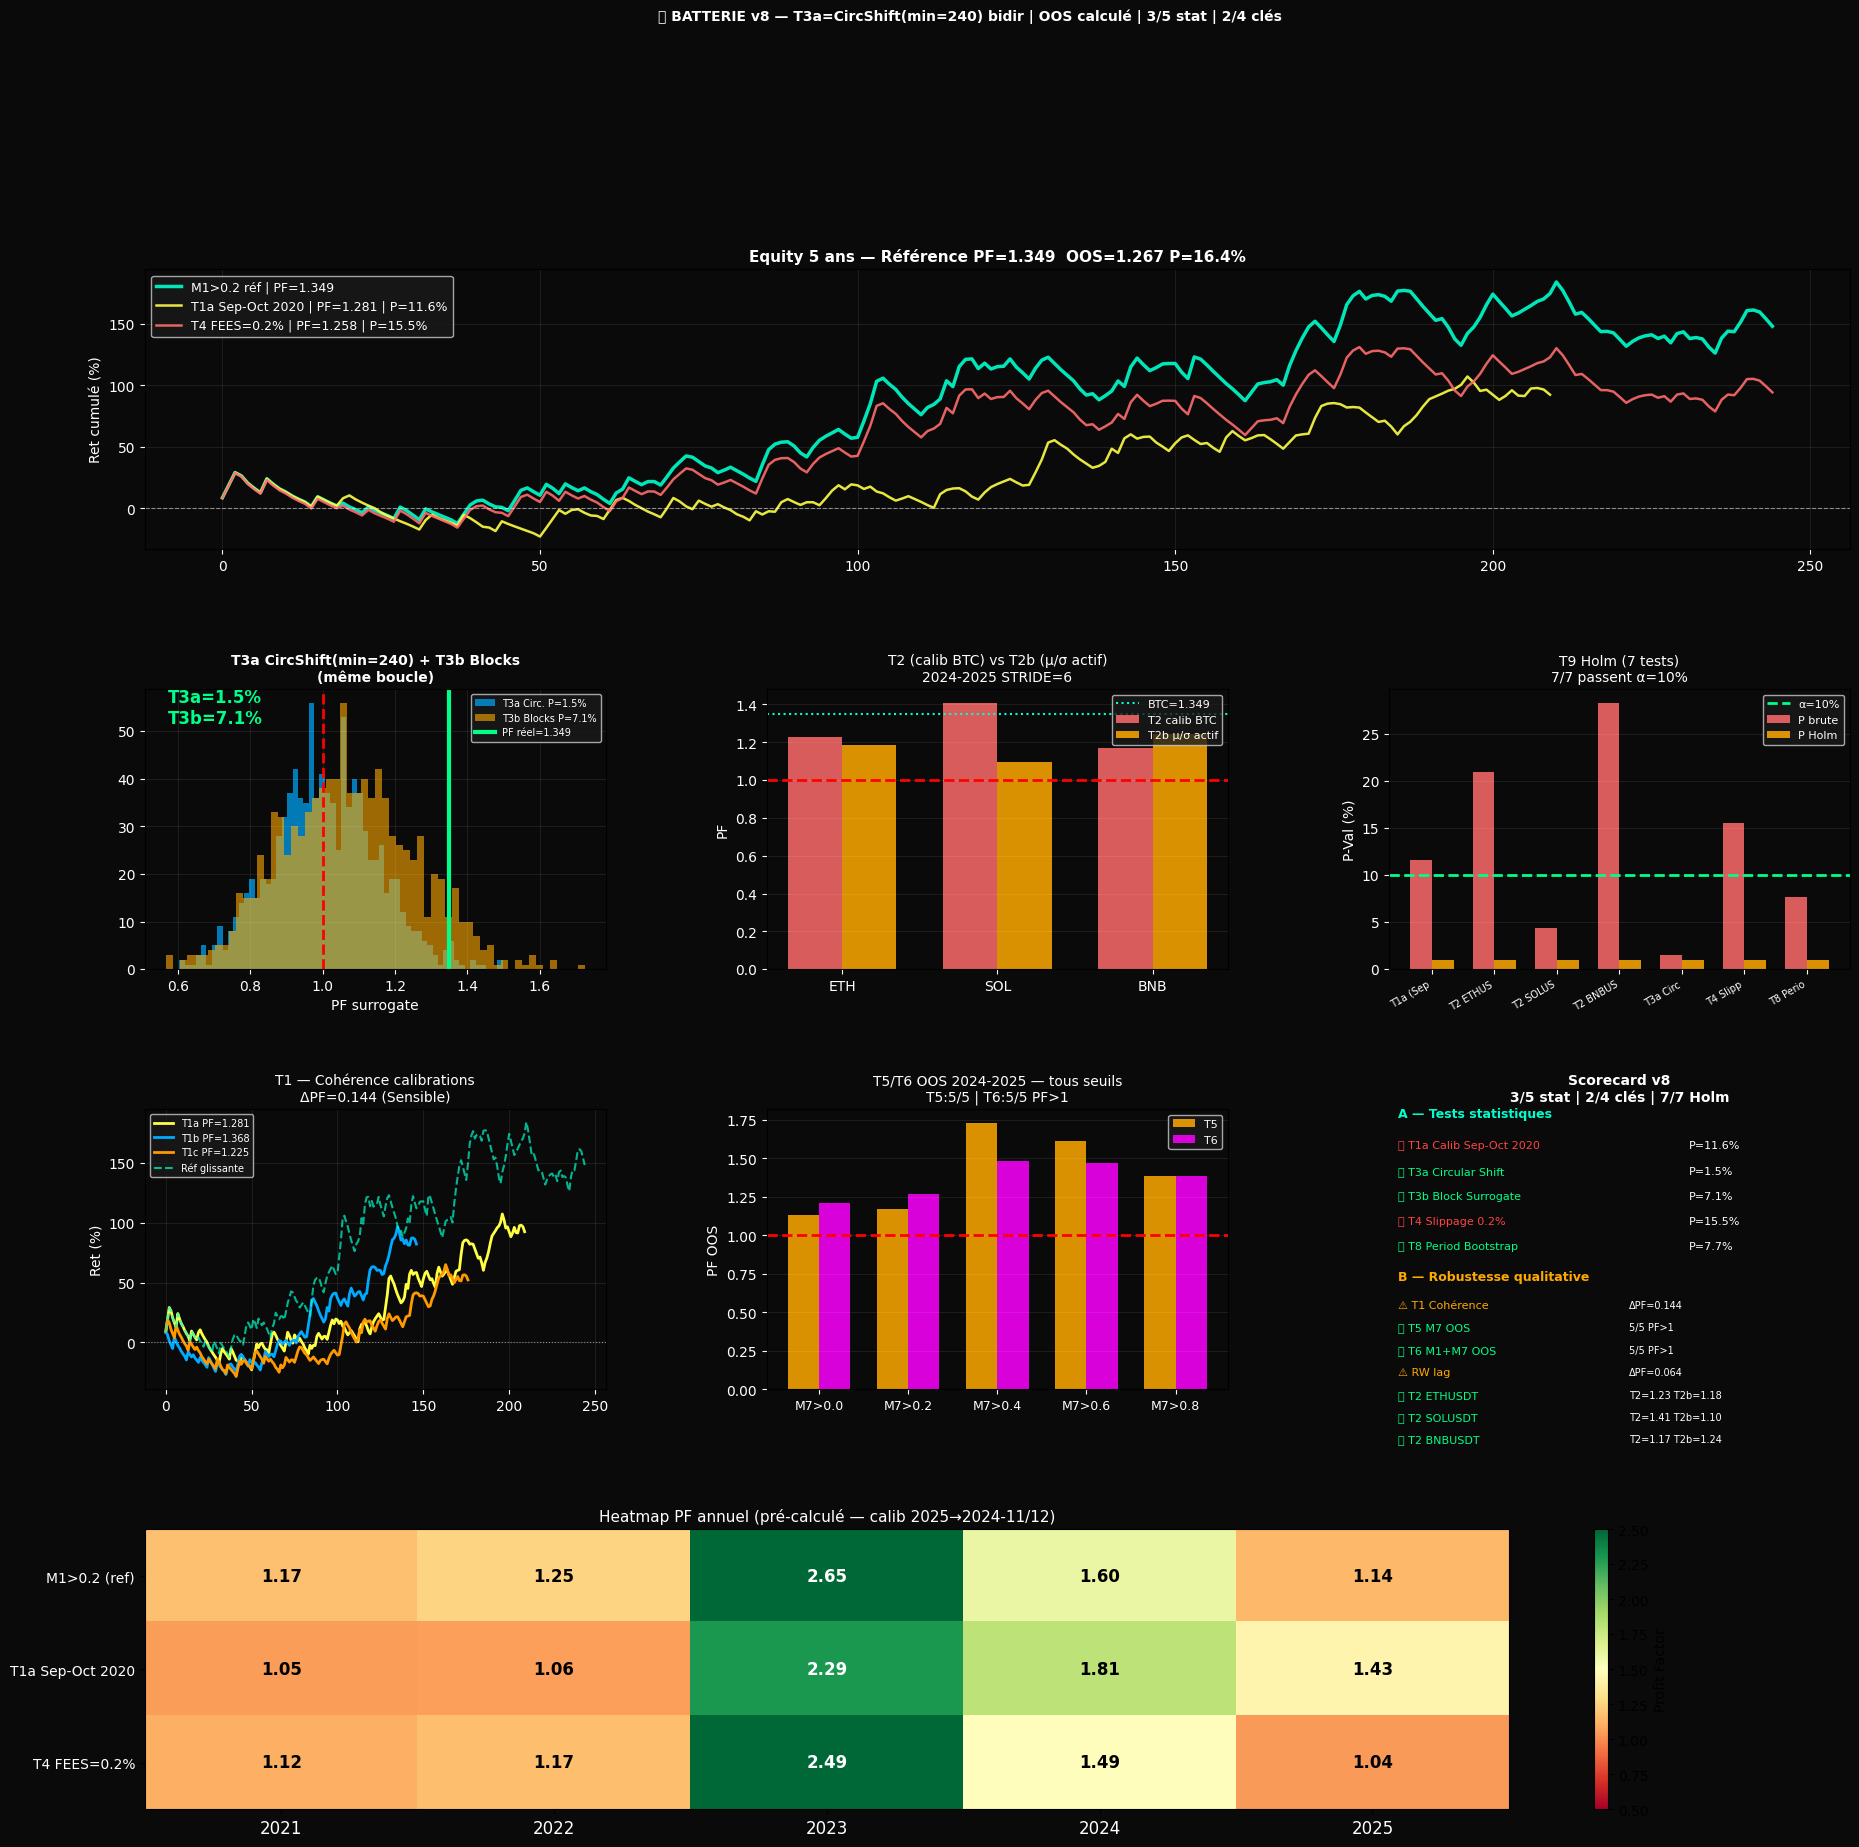


  🏁 VERDICT BATTERIE v8

  RÉFÉRENCE STRIDE=6 : PF=1.349  Ret=+148.2%  N=245
  OOS 2024-2025 (calculé) : PF=1.267  P=16.4%  N=135

  ══ Tests clés ══
    T1a Sep-Oct 2020     : P=11.6%  ❌
    T3a Circular Shift   : P=1.5%  ✅  ← min_shift=240
    T3b Block Surrogate  : P=7.1%  ✅  ← fix v7
    T4 Slippage 0.2%     : P=15.5%  ❌
    T8 Period Bootstrap  : P=7.68%  ✅
    → 2/4 clés (T1a+T3a+T4+T8)

  Holm (7 indép.) : 7/7 passent α=10%
  RW lag   : ΔPF=0.064 ⚠️ Significatif
  T3 cohérence : T3a=1.5% T3b=7.1%
  → ✅ Cohérents

  Conclusion :
  ⚠️  Signal possible — données supplémentaires



In [ ]:
# ==============================================================================
# === CELLULE 5 ===
# 🔬 BATTERIE v8 — Version publication-ready (Finale)
# ==============================================================================
# Fixes v7→v8 :
#   BUG   → T3a Circular Shift bidirectionnel : `max_shift = n - MIN_SHIFT`.
#          Empêche un shift circulaire vers l'avant de se transformer en un
#          shift arrière < MIN_SHIFT (ex: shift 600/720 = shift arrière 120).
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import urllib.request, zipfile, os, warnings
warnings.filterwarnings('ignore')
import antropy, skdim

print("="*70)
print("  🔬 BATTERIE v8 — T3a=CircShift(min_shift) | T3b=Blocks(fix) | OOS")
print("="*70)

# ==============================================================================
# ⚙️ CONFIG
# ==============================================================================
SEUIL_M1  = 0.2
SL_FIXED  = -0.020; TP_FIXED = 0.080; MAXHOLD = 72
FEES_BASE =  0.001; FEES_REEL = 0.002
WINDOW    =  120;   STRIDE   = 6;   N_DONCH = 96
N_BOOT    =  10000; N_SURR   = 1000; ALPHA   = 0.10
ROLLING_WIN = STRIDE  # sera comparé à 2 lors de l'audit
# Minimum shift pour T3a : au-delà de l'autocorrélation de M1
# M1 est calculé sur WINDOW=120 barres + lissé rolling(6) → ACF significative
# jusqu'à ~150 barres. min_shift = 2×WINDOW = 240 garantit que le signal
# décalé est indépendant du signal original.
# Si mois trop court (n ≤ min_shift), on accepte tout shift (conservateur).
MIN_SHIFT = 2 * WINDOW  # = 240 barres = 10 jours

COLUMNS = ['open_time','open','high','low','close','volume','close_time',
           'quote_volume','trades','taker_buy_base','taker_buy_quote','ignore']

def load_month(symbol, m):
    fname = f'{symbol}_{m}.zip'
    if not os.path.exists(fname):
        try:
            import urllib.request
            urllib.request.urlretrieve(f'https://data.binance.vision/data/spot/monthly/klines/{symbol}/1h/{symbol}-1h-{m}.zip', fname)
        except Exception:
            return None
    try:
        import zipfile
        with zipfile.ZipFile(fname) as z:
            c = z.namelist()[0]; z.extract(c)
        return pd.read_csv(c, names=COLUMNS).astype(float)
    except Exception:
        return None
    try:
        with zipfile.ZipFile(fname) as z:
            c = z.namelist()[0]; z.extract(c)
        return pd.read_csv(c, names=COLUMNS).astype(float)
    except: return None

# ==============================================================================
# ⚙️ ESTIMATEURS
# ==============================================================================
def build_ps(x, emb=3, delay=1):
    n = len(x)-(emb-1)*delay
    if n < 10: return None
    return np.array([x[i:i+emb*delay:delay] for i in range(n)])

def E21_MOM(x):
    try:
        X = build_ps(x,emb=3)
        return float(skdim.id.MOM().fit(X).dimension_) if X is not None and len(X)>=10 else np.nan
    except: return np.nan

def E11_Sevcik(x):
    try:
        n=len(x); xn=(x-x.min())/(x.max()-x.min()+1e-12)
        L=np.sum(np.sqrt(np.diff(xn)**2+np.diff(np.linspace(0,1,n))**2))
        return float(1+np.log(L)/np.log(2*(n-1)))
    except: return np.nan

def E19_MLE(x):
    try:
        X = build_ps(x,emb=3)
        return float(skdim.id.MLE().fit(X).dimension_) if X is not None and len(X)>=10 else np.nan
    except: return np.nan

def E05_PermEn(x):
    try: return float(antropy.perm_entropy(x,order=5,normalize=True))
    except: return np.nan

def E24_FisherS(x):
    try:
        X = build_ps(x,emb=5)
        return float(skdim.id.FisherS().fit(X[:200]).dimension_) if X is not None and len(X)>=20 else np.nan
    except: return np.nan

ANCRES = {
    'E21_MOM':    {'func':E21_MOM,    'poids':0.828,'dir':+1},
    'E11_Sevcik': {'func':E11_Sevcik, 'poids':0.567,'dir':-1},
    'E19_MLE':    {'func':E19_MLE,    'poids':0.539,'dir':-1},
    'E05_PermEn': {'func':E05_PermEn, 'poids':0.526,'dir':-1},
    'E24_FisherS':{'func':E24_FisherS,'poids':0.521,'dir':-1},
}

def calibrer(lr_series):
    cs = {}
    for nom,cfg in ANCRES.items():
        vals=[cfg['func'](lr_series[i-WINDOW:i])
              for i in range(WINDOW,len(lr_series),STRIDE)]
        vals=[v for v in vals if np.isfinite(v)]
        if vals: cs[nom]={'mu':np.mean(vals),'sigma':np.std(vals)+1e-10}
    return cs

def compute_M1_M7(lr_win, cs):
    sc,za,pw=[],[],[]
    for nom,cfg in ANCRES.items():
        v=cfg['func'](lr_win)
        if not np.isfinite(v) or nom not in cs: continue
        z=(v-cs[nom]['mu'])/cs[nom]['sigma']*cfg['dir']
        sc.append(z*cfg['poids']); za.append(z); pw.append(cfg['poids'])
    if len(sc)<3: return np.nan,np.nan
    return float(np.average(sc,weights=pw)),float(np.average(np.sign(za),weights=pw))

def smooth(s, w=None):
    w=w or ROLLING_WIN
    return (pd.Series(s).interpolate('linear').bfill().ffill()
              .rolling(w,min_periods=1).mean().values)

def rolling_M1_M7(lr, cs, rw=None):
    rw=rw or ROLLING_WIN; n=len(lr)
    s1=np.full(n,np.nan); s7=np.full(n,np.nan)
    for i in range(WINDOW,n,STRIDE):
        m1,m7=compute_M1_M7(lr[i-WINDOW:i],cs)
        if np.isfinite(m1): s1[i:i+STRIDE]=m1
        if np.isfinite(m7): s7[i:i+STRIDE]=m7
    return smooth(s1,rw),smooth(s7,rw)

def rolling_M1_only(lr, cs, rw=None):
    rw=rw or ROLLING_WIN; n=len(lr)
    s1=np.full(n,np.nan)
    for i in range(WINDOW,n,STRIDE):
        m1,_=compute_M1_M7(lr[i-WINDOW:i],cs)
        if np.isfinite(m1): s1[i:i+STRIDE]=m1
    return smooth(s1,rw)

def donchian(prix,high,low,N=N_DONCH):
    u=pd.Series(high).shift(1).rolling(N).max().values
    l=pd.Series(low).shift(1).rolling(N).min().values
    return prix>u, prix<l

def backtest(ld,sd,mask,prix,fees=FEES_BASE):
    lf=ld&mask; sf=sd&mask
    sl_=np.roll(lf.astype(int),1); sl_[0]=0
    ss_=np.roll(sf.astype(int),1); ss_[0]=0
    dl=np.diff(sl_,prepend=0)==1; ds=np.diff(ss_,prepend=0)==1
    trades=[]
    for i in range(len(prix)):
        d='long' if dl[i] else('short' if ds[i] else None)
        if d is None: continue
        ep=prix[i]; xp=None
        for j in range(i+1,min(i+MAXHOLD,len(prix))):
            r=(prix[j]-ep)/ep if d=='long' else(ep-prix[j])/ep
            if r<=SL_FIXED or r>=TP_FIXED: xp=prix[j]; break
        if xp is None: xp=prix[min(i+MAXHOLD-1,len(prix)-1)]
        trades.append(((xp-ep)/ep if d=='long' else(ep-xp)/ep)-fees)
    return np.array(trades)

def kpis(t):
    if len(t)==0: return dict(n=0,ret=0,wr=0,pf=0,dd=0)
    eq=np.cumprod(1+t); ret=(eq[-1]-1)*100; wr=np.mean(t>0)*100
    peak=np.maximum.accumulate(eq); dd=np.min(eq/peak-1)*100
    g,l=t[t>0],t[t<0]
    pf=np.sum(g)/abs(np.sum(l)) if len(l)>0 and abs(np.sum(l))>0 else np.inf
    return dict(n=len(t),ret=ret,wr=wr,pf=pf,dd=dd)

def pv_boot(t,n=N_BOOT):
    if len(t)==0: return 100.
    s=[np.prod(1+np.random.choice(t,size=len(t),replace=True))-1 for _ in range(n)]
    return float(np.mean(np.array(s)<0)*100)

def pv_period(month_dict,mois_list,n=N_BOOT):
    dist=[]
    for _ in range(n):
        sampled=np.random.choice(mois_list,size=len(mois_list),replace=True)
        t=np.concatenate([month_dict[m] for m in sampled if len(month_dict.get(m,[]))>0])
        dist.append(np.prod(1+t)-1 if len(t)>0 else 0.)
    return float(np.mean(np.array(dist)<0)*100)

def holm_bonferroni(p_dict):
    noms=list(p_dict.keys()); p=np.array([p_dict[n] for n in noms])
    n=len(p); idx=np.argsort(p); adj=np.empty(n); rm=0.
    for rank,i in enumerate(idx):
        c=min(1.,p[i]*(n-rank)); rm=max(rm,c); adj[i]=rm
    return {noms[i]:adj[i] for i in range(n)}

# ==============================================================================
# ⚙️ SURROGATE FUNCTIONS
# ==============================================================================
def get_cluster_sizes(signal,threshold):
    above=signal>threshold
    if not np.any(above): return []
    diff=np.diff(above.astype(np.int8),prepend=0,append=0)
    return (np.where(diff==-1)[0]-np.where(diff==1)[0]).tolist()

def place_blocks_randomly(n,sizes):
    """
    Block surrogate : convolution O(n).
    FIX v7 : UN seul appel à np.random.choice (v6 avait 2 appels → biais).
    Note : blocs non placés (espace insuffisant) → densité ≤ réelle.
    """
    mask=np.zeros(n,dtype=np.int8)
    for sz in sorted(sizes,reverse=True):
        if sz>=n: continue
        conv=np.convolve(mask,np.ones(sz,dtype=np.int8),mode='valid')
        free=np.where(conv==0)[0]
        if len(free)==0: continue
        # FIX v7 : UN SEUL tirage pour start, fin = start+sz
        start=int(np.random.choice(free))
        mask[start:start+sz]=1
    return mask.astype(bool)

# ==============================================================================
# 📦 PRÉCOMPUTATION BTC
# ==============================================================================
CALIB_GLISS={
    2021:('2020-11','2020-12'),2022:('2021-11','2021-12'),
    2023:('2022-11','2022-12'),2024:('2023-11','2023-12'),
    2025:('2024-11','2024-12'),
}
ALL_MOIS=[f'{a}-{m:02d}' for a in range(2021,2026) for m in range(1,13)]
MOIS_IS =[f'{a}-{m:02d}' for a in [2022,2023] for m in range(1,13)]
MOIS_OOS=[f'{a}-{m:02d}' for a in [2024,2025] for m in range(1,13)]

print("\n📐 Calibrations glissantes (calib 2025→2024-11/12)...")
calib={}
for annee,(m1,m2) in CALIB_GLISS.items():
    dfs=[d for d in [load_month('BTCUSDT',m1), load_month('BTCUSDT',m2)] if d is not None]
    if len(dfs)==0: continue
    lr_c=np.diff(np.log(pd.concat(dfs,ignore_index=True)['close'].values))
    calib[annee]=calibrer(lr_c); print(f"   ✅ {annee} ← {m1}+{m2}")

print("\n📦 Précomputation BTC M1+M7+clusters (~40 min)...")
BTC={}; CLUSTER_SIZES={}
for mois in ALL_MOIS:
    annee=int(mois[:4])
    df_m=load_month('BTCUSDT',mois)
    if df_m is None: continue
    close=df_m['close'].values; high=df_m['high'].values[1:]
    low=df_m['low'].values[1:]; lr=np.diff(np.log(close)); prix=close[1:]
    ld,sd=donchian(prix,high,low)
    m1,m7=rolling_M1_M7(lr,calib[annee])
    BTC[mois]={'prix':prix,'high':high,'low':low,'lr':lr,
               'long':ld,'short':sd,'m1':m1,'m7':m7}
    CLUSTER_SIZES[mois]=get_cluster_sizes(m1,SEUIL_M1)
    print(f"   ✅ {mois}  M1∈[{m1.min():.2f},{m1.max():.2f}]  "
          f"clusters={len(CLUSTER_SIZES[mois])}")

MONTH_TRADES={m:backtest(BTC[m]['long'],BTC[m]['short'],
                         BTC[m]['m1']>SEUIL_M1,BTC[m]['prix'])
              for m in ALL_MOIS if m in BTC}
REF_TRADES=np.concatenate(list(MONTH_TRADES.values()))
k_ref=kpis(REF_TRADES); REF_PF=k_ref['pf']
PF_AN={a:kpis(np.concatenate([MONTH_TRADES[f'{a}-{m:02d}'] for m in range(1,13)]))
       for a in range(2021,2026)}
print(f"\n   🎯 Référence : PF={REF_PF:.3f}  Ret={k_ref['ret']:+.1f}%  N={k_ref['n']}")

# P-value OOS 2024-2025 calculée (plus hardcodée)
oos_trades=np.concatenate([MONTH_TRADES[m] for m in MOIS_OOS])
pv_oos_strict=pv_boot(oos_trades)
print(f"   🎯 OOS pur 2024-2025 (calculé) : P={pv_oos_strict:.1f}%  N={kpis(oos_trades)['n']}")

PVALS_HOLM={}  # 7 tests indépendants

# ==============================================================================
# ⚙️ AUDIT ROLLING_WIN — 5 ANS
# ==============================================================================
print("\n⚙️  Audit ROLLING_WIN sur 5 ans (2021-2025)...")
t_rw2=[]
for mois in ALL_MOIS:
    if mois not in BTC: continue
    d=BTC[mois]
    sig2=rolling_M1_only(d['lr'],calib[int(mois[:4])],rw=2)
    t_rw2.extend(backtest(d['long'],d['short'],sig2>SEUIL_M1,d['prix']).tolist())

pf_rw2=kpis(np.array(t_rw2))['pf']
pf_rw6=REF_PF
delta_rw=abs(pf_rw6-pf_rw2)
print(f"  RW=2 → PF={pf_rw2:.3f} | RW=6 → PF={pf_rw6:.3f} | ΔPF={delta_rw:.3f}")
print(f"  → {'✅ Inoffensif (<0.05)' if delta_rw<0.05 else '⚠️ Significatif — considérer RW=2'}")

# ==============================================================================
# TEST 1 — CALIBRATION FIGÉE 2020 (3 variantes)
# ==============================================================================
print("\n"+"="*70)
print("  🧪 T1 — Calibration figée (Sep-Oct | Jan-Dec | Jul-Dec 2020)")
print("="*70)

configs_T1={
    'T1a (Sep-Oct 2020)':[f'2020-{m:02d}' for m in [9,10]],
    'T1b (Jan-Dec 2020)':[f'2020-{m:02d}' for m in range(1,13)],
    'T1c (Jul-Dec 2020)':[f'2020-{m:02d}' for m in range(7,13)],
}
T1_res={}
for label,mois_c in configs_T1.items():
    dfs=[d for d in [load_month('BTCUSDT',m) for m in mois_c] if d is not None]
    cs_f=calibrer(np.diff(np.log(pd.concat(dfs,ignore_index=True)['close'].values)))
    t_all=[]; t_an={}
    for annee in range(2021,2026):
        t_a=[]
        for m in range(1,13):
            if f'{annee}-{m:02d}' not in BTC: continue
            d=BTC[f'{annee}-{m:02d}']
            sig=rolling_M1_only(d['lr'],cs_f)
            t_a.extend(backtest(d['long'],d['short'],sig>SEUIL_M1,d['prix']).tolist())
        k_a=kpis(np.array(t_a)); t_an[annee]=k_a; t_all.extend(t_a)
    arr=np.array(t_all); k=kpis(arr); pv=pv_boot(arr)
    T1_res[label]={'k':k,'pv':pv,'t_an':t_an,'trades':arr}
    v5y="✅" if all(t_an[a]['ret']>0 for a in range(2021,2026)) else"❌"
    vp="✅" if pv<ALPHA*100 else"⚠️"
    print(f"  {label}: PF={k['pf']:.3f}  P={pv:.1f}%  5/5={v5y}  {vp}")

PVALS_HOLM['T1a (Sep-Oct 2020)']=T1_res['T1a (Sep-Oct 2020)']['pv']
pfs_T1=[T1_res[l]['k']['pf'] for l in configs_T1]; ecart=max(pfs_T1)-min(pfs_T1)
print(f"\n  Cohérence : T1a={pfs_T1[0]:.3f} | T1b={pfs_T1[1]:.3f} | T1c={pfs_T1[2]:.3f}")
print(f"  ΔPF={ecart:.3f} → {'✅ Stable' if ecart<0.1 else '⚠️ Sensible'}")

# ==============================================================================
# TEST 2 — CROSS-ASSET : T2 (calib BTC) + T2b (μ/σ actif, poids BTC)
# ==============================================================================
print("\n"+"="*70)
print("  🧪 T2/T2b — Cross-asset 2024-2025")
print("  T2  : calib BTC directe | T2b : μ/σ actif + poids BTC")
print("="*70)

ACTIFS=['ETHUSDT','SOLUSDT','BNBUSDT']
MOIS_T2=[f'{a}-{m:02d}' for a in [2024,2025] for m in range(1,13)]
CALIB_T2_PERIODS={2024:('2023-11','2023-12'),2025:('2024-11','2024-12')}

T2_res={}; T2b_res={}
for actif in ACTIFS:
    print(f"\n  {actif}...")
    calib_actif={}; ok=True
    for a,(m1,m2) in CALIB_T2_PERIODS.items():
        d1=load_month(actif,m1); d2=load_month(actif,m2)
        if d1 is None or d2 is None: ok=False; break
        calib_actif[a]=calibrer(np.diff(np.log(
            pd.concat([d1,d2],ignore_index=True)['close'].values)))
    if not ok:
        T2_res[actif]=T2b_res[actif]={'skip':True}; continue

    t_t2=[]; t_t2b=[]
    for mois in MOIS_T2:
        a=int(mois[:4]); df_m=load_month(actif,mois)
        if df_m is None: continue
        close=df_m['close'].values; high=df_m['high'].values[1:]
        low=df_m['low'].values[1:]; lr=np.diff(np.log(close)); prix=close[1:]
        ld,sd=donchian(prix,high,low)
        t_t2.extend(backtest(ld,sd,rolling_M1_only(lr,calib[a])>SEUIL_M1,prix).tolist())
        t_t2b.extend(backtest(ld,sd,rolling_M1_only(lr,calib_actif[a])>SEUIL_M1,prix).tolist())

    for tag,t_all,res_dict in [('T2',t_t2,T2_res),('T2b',t_t2b,T2b_res)]:
        arr=np.array(t_all)
        if len(arr)==0: res_dict[actif]={'skip':True}; continue
        k=kpis(arr); pv=pv_boot(arr)
        res_dict[actif]={'k':k,'pv':pv,'skip':False}
        v="✅" if pv<ALPHA*100 else("⚠️" if pv<20 else"❌")
        print(f"    {tag}: PF={k['pf']:.3f}  P={pv:.1f}%  N={k['n']}  {v}")

    PVALS_HOLM[f'T2 {actif}']=T2_res[actif].get('pv',100.) if not T2_res[actif].get('skip') else 100.

print(f"\n  Diagnostic universalité :")
for actif in ACTIFS:
    r2=T2_res.get(actif,{}); r2b=T2b_res.get(actif,{})
    if r2.get('skip') or r2b.get('skip'): continue
    pf2=r2['k']['pf']; pf2b=r2b['k']['pf']
    diag=("✅✅ Universel" if pf2>1 and pf2b>1
          else "⚠️  Échelle ≠" if pf2<1 and pf2b>1
          else "❌  Poids non univ." if pf2<1 and pf2b<1 else "⚠️  Ambigu")
    print(f"  {actif}: T2={pf2:.3f}  T2b={pf2b:.3f}  → {diag}")

# ==============================================================================
# TEST 3 — DEUX SURROGATES
#
# T3a — CIRCULAR SHIFT avec MIN_SHIFT
# ─────────────────────────────────────────────────────────────────
# H₀ : "Le timing précis du signal M1 dans le mois ne compte pas."
#
# FIX v7 : min_shift = 2×WINDOW = 240 barres
#   M1 est calculé sur WINDOW=120 barres + lissé rolling(6) → ACF longue.
#   Un shift < 240 laisse le signal décalé corrélé avec l'original →
#   le surrogate retient du pouvoir prédictif → test conservateur.
#   En imposant shift ≥ 240, on garantit l'indépendance temporelle.
#
# Artefact circulaire : np.roll fait passer la fin du mois au début.
#   Si M1 élevé en fin de mois + breakout en début → alignement artificiel.
#   Effet probablement faible (probabilité de recollage exact ≈ 0),
#   mais à documenter dans un article.
#
# T3b — BLOCK SURROGATE (comparaison)
# ─────────────────────────────────────────────────────────────────
# FIX v7 : place_blocks_randomly corrigé (1 seul np.random.choice).
# Note : blocs non placés → densité ≤ réelle (biais léger).
# ==============================================================================
print("\n"+"="*70)
print("  🧪 T3 — Deux surrogates (~10-20 min)")
print(f"  T3a : Circular Shift (min_shift={MIN_SHIFT} = 2×WINDOW)")
print("  T3b : Block Surrogate (FIX v7 : 1 seul random.choice)")
print("="*70)

if any(CLUSTER_SIZES[m] for m in ALL_MOIS):
    all_sz=[s for m in ALL_MOIS for s in CLUSTER_SIZES[m]]
    print(f"  Clusters M1>{SEUIL_M1} : {len(all_sz)} total, "
          f"médiane={np.median(all_sz):.0f}h, max={max(all_sz)}h")
print(f"  min_shift = {MIN_SHIFT} barres = {MIN_SHIFT}h = {MIN_SHIFT//24} jours")

print(f"\n  ⚙️  {N_SURR} surrogates (T3a + T3b simultanément)...")

pf_T3a=[]; pf_T3b=[]
for sim in range(N_SURR):
    t_a=[]; t_b=[]
    for mois in ALL_MOIS:
        d=BTC[mois]; n=len(d['m1'])

        # ── T3a : Circular Shift avec min_shift bidirectionnel ───────────────
        # FIX v8 : shift effectif bidirectionnel ≥ MIN_SHIFT
        max_shift = n - MIN_SHIFT
        if max_shift >= MIN_SHIFT:
            shift = np.random.randint(MIN_SHIFT, max_shift + 1)
        elif n > 1:
            # Mois trop court (n ≤ 2*MIN_SHIFT) : accepter tout shift non-nul
            shift = np.random.randint(1, n)
        else:
            shift = 1
        shifted = np.roll(d['m1'], shift) > SEUIL_M1
        t_a.extend(backtest(d['long'],d['short'],shifted,d['prix']).tolist())

        # ── T3b : Block Surrogate (FIX v7) ──────────────────────────────────
        sizes=CLUSTER_SIZES[mois]
        if sizes:
            rand_mask=place_blocks_randomly(n,sizes)
            if np.any(rand_mask):
                t_b.extend(backtest(d['long'],d['short'],rand_mask,d['prix']).tolist())

    for t_sim,pf_list in [(t_a,pf_T3a),(t_b,pf_T3b)]:
        arr=np.array(t_sim)
        if len(arr)==0: continue
        g,l=arr[arr>0],arr[arr<0]
        pf_list.append(np.sum(g)/abs(np.sum(l)) if len(l)>0 and abs(np.sum(l))>0 else 1.)

    if (sim+1)%200==0: print(f"     {sim+1}/{N_SURR}...")

pf_T3a=np.array(pf_T3a); pf_T3b=np.array(pf_T3b)
pv_T3a=float(np.mean(pf_T3a>=REF_PF)*100)
pv_T3b=float(np.mean(pf_T3b>=REF_PF)*100)
PVALS_HOLM['T3a Circular Shift']=pv_T3a

print(f"\n  {'Surrogate':<20}  {'P(surr≥{:.3f})'.format(REF_PF):>16}  {'Médiane':>10}  Verdict")
print("  "+"─"*60)
for tag,pf_dist,pv in [('T3a Circ.Shift',pf_T3a,pv_T3a),('T3b Blocks',pf_T3b,pv_T3b)]:
    v="✅ SIGNAL PLACÉ" if pv<5 else("⚠️ MARGINAL" if pv<15 else"❌ HASARD")
    print(f"  {tag:<20}  {pv:>15.1f}%  {np.median(pf_dist):>10.3f}  {v}")

print(f"\n  Interprétation comparative :")
if pv_T3a<5 and pv_T3b<5:
    print("  ✅✅ Les deux passent → M1 bien placé ET structure des blocs compte")
elif pv_T3a<5 and pv_T3b>=5:
    print("  ✅⚠️  T3a passe, T3b non → timing compte plus que structure des blocs")
elif pv_T3a>=5 and pv_T3b<5:
    print("  ⚠️✅  T3b passe, T3a non → structure globale compte, timing pas clé")
else:
    print("  ❌❌  Ni T3a ni T3b → signal non distinguable d'un filtre aléatoire structuré")

print(f"\n  Note : T3a utilise min_shift={MIN_SHIFT}h (au-delà de l'ACF de M1).")
print(f"  Si T3a passe → conclusion forte (test non conservateur).")
print(f"  Si T3a échoue → PAS concluant (peut être manque de puissance).")

# ==============================================================================
# TEST 4 — SLIPPAGE RÉEL (FEES = 0.2%)
# ==============================================================================
print("\n"+"="*70)
print("  🧪 T4 — Slippage réel (FEES 0.1% → 0.2%)")
print("="*70)

T4_month={m:backtest(BTC[m]['long'],BTC[m]['short'],
                     BTC[m]['m1']>SEUIL_M1,BTC[m]['prix'],fees=FEES_REEL)
           for m in ALL_MOIS}
T4_all=np.concatenate(list(T4_month.values()))
T4_an={a:kpis(np.concatenate([T4_month[f'{a}-{m:02d}'] for m in range(1,13)]))
       for a in range(2021,2026)}
for annee in range(2021,2026):
    k_a=T4_an[annee]; v="✅" if k_a['ret']>0 else"❌"
    print(f"  {annee}: Ret={k_a['ret']:>+6.1f}%  PF={k_a['pf']:.3f}  N={k_a['n']}  {v}")
kT4=kpis(T4_all); pvT4=pv_period(T4_month,ALL_MOIS)
PVALS_HOLM['T4 Slippage 0.2%']=pvT4
vT4="✅" if pvT4<ALPHA*100 else("⚠️" if pvT4<20 else"❌")
print(f"\n  0.1%→PF={REF_PF:.3f} | 0.2%→PF={kT4['pf']:.3f} P={pvT4:.1f}% {vT4}")

# ==============================================================================
# TESTS 5, 6, 7 — OOS strict — TWO-PASS
# ==============================================================================
print("\n"+"="*70)
print("  🧪 T5/T6/T7 — OOS strict 2024-2025 (two-pass → un seul flag best IS)")
print("="*70)

SEUILS_M7=[0.0,0.2,0.4,0.6,0.8]
SEUILS_H =[0.01,0.05,0.10,0.15,0.20,0.30]

def run_two_pass(signal_fn_is, signal_fn_oos, seuils, mois_is, mois_oos, label):
    """
    Passe 1 : calcule PF_IS pour trouver le meilleur seuil.
    Passe 2 : calcule PF_OOS et affiche (UN SEUL flag ← best IS).
    """
    data={}; best_pf_is=-np.inf; best_s=seuils[0]
    for s in seuils:
        t_is=np.concatenate([backtest(BTC[m]['long'],BTC[m]['short'],
                             signal_fn_is(m,s),BTC[m]['prix'])
                             for m in mois_is if m in BTC])
        k_is=kpis(t_is); data[s]={'k_is':k_is}
        if k_is['pf']>best_pf_is: best_pf_is=k_is['pf']; best_s=s

    print(f"\n  {label} (IS=2022-23, OOS=2024-25) :")
    w='Seuil' if label.startswith('T7') else 'M7>'
    print(f"  {w:>7}  {'PF_IS':>7}  {'PF_OOS':>8}  {'N_OOS':>7}  {'P_OOS':>8}  Verdict")
    print("  "+"─"*58)
    for s in seuils:
        t_oos=np.concatenate([backtest(BTC[m]['long'],BTC[m]['short'],
                              signal_fn_oos(m,s),BTC[m]['prix'])
                              for m in mois_oos if m in BTC])
        k_oos=kpis(t_oos); pv_oos=pv_boot(t_oos) if len(t_oos)>10 else 100.
        data[s]['k_oos']=k_oos; data[s]['pv']=pv_oos; data[s]['t_oos']=t_oos
        v="✅" if pv_oos<ALPHA*100 else("⚠️" if pv_oos<20 else"❌")
        flag=" ← best IS" if s==best_s else""
        print(f"  {s:>7}  {data[s]['k_is']['pf']:>7.3f}  {k_oos['pf']:>8.3f}  "
              f"{k_oos['n']:>7}  {pv_oos:>7.1f}%  {v}{flag}")

    n_pos=sum(1 for r in data.values() if r['k_oos']['pf']>1.)
    print(f"  → {n_pos}/{len(seuils)} seuils OOS PF>1 {'✅ Robuste' if n_pos>=3 else '❌ Fragile'}")
    return data, n_pos

T5_data,n_pos_T5=run_two_pass(
    lambda m,s: BTC[m]['m7']>s,
    lambda m,s: BTC[m]['m7']>s,
    SEUILS_M7, MOIS_IS, MOIS_OOS, "T5 — M7 seul")

T6_data,n_pos_T6=run_two_pass(
    lambda m,s: (BTC[m]['m1']>SEUIL_M1)&(BTC[m]['m7']>s),
    lambda m,s: (BTC[m]['m1']>SEUIL_M1)&(BTC[m]['m7']>s),
    SEUILS_M7, MOIS_IS, MOIS_OOS, "T6 — Hybride M1>0.2 ET M7>seuil")

T7_data,n_pos_T7=run_two_pass(
    lambda m,s: (BTC[m]['m1']*np.maximum(BTC[m]['m7'],0))>s,
    lambda m,s: (BTC[m]['m1']*np.maximum(BTC[m]['m7'],0))>s,
    SEUILS_H, MOIS_IS, MOIS_OOS, "T7 — M1×max(M7,0)")

# ==============================================================================
# TEST 8 — PERIOD BOOTSTRAP RETURNS
# ==============================================================================
print("\n"+"="*70)
print("  🧪 T8 — Period Bootstrap Returns")
print("="*70)
pvT8=pv_period(MONTH_TRADES,ALL_MOIS)
PVALS_HOLM['T8 Period Bootstrap']=pvT8
vT8="✅" if pvT8<ALPHA*100 else("⚠️" if pvT8<20 else"❌")
print(f"  P(retour period-bootstrap < 0) = {pvT8:.2f}%  → {vT8}")

# ==============================================================================
# TEST 9 — HOLM-BONFERRONI (7 tests)
# ==============================================================================
print("\n"+"="*70)
print("  🧪 T9 — Holm-Bonferroni (7 tests, note : T2×3 corrélés)")
print("="*70)

holm_adj=holm_bonferroni(PVALS_HOLM)
n_pass_holm=sum(1 for p in holm_adj.values() if p<ALPHA*100)
print(f"\n  {'Test':<30} {'P brute':>9} {'P Holm':>9} {'Pass?'}")
print("  "+"─"*58)
for nom,pb in sorted(PVALS_HOLM.items(),key=lambda x:x[1]):
    ph=holm_adj[nom]; v="✅" if ph<ALPHA*100 else("⚠️" if ph<20 else"❌")
    print(f"  {nom:<30} {pb:>8.1f}% {ph:>8.1f}%  {v}")
print(f"\n  {n_pass_holm}/7 tests passent Holm α=10%")

# ==============================================================================
# 📊 SCORECARD — DEUX SECTIONS
# ==============================================================================
print("\n"+"="*70)
print("  📊 SCORECARD v8 — DEUX SECTIONS")
print("="*70)
print(f"  RÉFÉRENCE : PF={REF_PF:.3f}  Ret={k_ref['ret']:+.1f}%  N={k_ref['n']}")

k_oos_st=kpis(oos_trades)
print(f"\n  OOS pur 2024-2025 (calculé) : PF={k_oos_st['pf']:.3f}  "
      f"P={pv_oos_strict:.1f}%  N={k_oos_st['n']}  "
      f"{'✅' if pv_oos_strict<ALPHA*100 else '❌'}")

stat_tests=[
    ("T1a Calib Sep-Oct 2020", T1_res['T1a (Sep-Oct 2020)']['pv'],
     f"PF={T1_res['T1a (Sep-Oct 2020)']['k']['pf']:.3f}"),
    ("T3a Circular Shift",     pv_T3a, f"P(surr≥{REF_PF:.3f})={pv_T3a:.1f}%"),
    ("T3b Block Surrogate",    pv_T3b, f"P(surr≥{REF_PF:.3f})={pv_T3b:.1f}% (densité≤réelle)"),
    ("T4 Slippage 0.2%",       pvT4,   f"PF={kT4['pf']:.3f}  ΔPF={kT4['pf']-REF_PF:+.3f}"),
    ("T8 Period Bootstrap",    pvT8,   f"P(ret<0)={pvT8:.2f}%"),
]

print(f"\n  ══ SECTION A — Tests statistiques (p-values) ══")
n_stat_pass=0
print(f"  {'Test':<28} {'P-Val':>8} {'Pass?':>7}  Détail")
print("  "+"─"*62)
for nom,pv,detail in stat_tests:
    p=pv<ALPHA*100
    if p: n_stat_pass+=1
    print(f"  {nom:<28} {pv:>7.1f}% {'✅ PASS' if p else '❌ FAIL':>7}  {detail}")
print(f"  Holm (7 indép.) : {n_pass_holm}/7 passent α=10%")

print(f"\n  ══ SECTION B — Robustesse qualitative ══")
print(f"  T1  Cohérence   : ΔPF={ecart:.3f} {'✅ Stable' if ecart<0.1 else '⚠️ Sensible'}")
for actif in ACTIFS:
    r2=T2_res.get(actif,{}); r2b=T2b_res.get(actif,{})
    if r2.get('skip') or r2b.get('skip'): continue
    pf2=r2['k']['pf']; pf2b=r2b['k']['pf']
    diag=("✅✅ Universel" if pf2>1 and pf2b>1 else "⚠️  Échelle ≠"
          if pf2<1 and pf2b>1 else "❌  Non univ.")
    print(f"  T2/T2b {actif}: T2={pf2:.3f}  T2b={pf2b:.3f}  {diag}")
print(f"  T5 M7 OOS   : {n_pos_T5}/{len(SEUILS_M7)} seuils PF>1 {'✅' if n_pos_T5>=3 else '❌'}")
print(f"  T6 M1+M7 OOS: {n_pos_T6}/{len(SEUILS_M7)} seuils PF>1 {'✅' if n_pos_T6>=3 else '❌'}")
print(f"  RW=2 vs 6   : ΔPF={delta_rw:.3f} {'✅ Inoffensif' if delta_rw<0.05 else '⚠️ Significatif'}")

cles_pv=[("T1a",T1_res['T1a (Sep-Oct 2020)']['pv']),
         ("T3a",pv_T3a),("T4",pvT4),("T8",pvT8)]
n_cles=sum(1 for _,pv in cles_pv if pv<ALPHA*100)
print(f"\n  ★ Tests clés : {n_cles}/4 passent P<{ALPHA:.0%}")
for nom,pv in cles_pv: print(f"     {'✅' if pv<10 else '❌'} {nom} : P={pv:.1f}%")
print(f"  → {'✅✅ Signal réel (≥3/4 clés)' if n_cles>=3 else '⚠️  Signal incertain (2/4)' if n_cles==2 else '❌  Insuffisant'}")

# ==============================================================================
# 📈 VISUALISATION
# ==============================================================================
fig=plt.figure(figsize=(22,20)); fig.patch.set_facecolor('#0a0a0a')
gs=gridspec.GridSpec(4,3,figure=fig,hspace=0.50,wspace=0.35)

# ── Equity ────────────────────────────────────────────────────────────────────
ax0=fig.add_subplot(gs[0,:]); ax0.set_facecolor('#0a0a0a')
ax0.set_title(f"Equity 5 ans — Référence PF={REF_PF:.3f}  OOS={k_oos_st['pf']:.3f} P={pv_oos_strict:.1f}%",
              color='white',fontsize=11,fontweight='bold')
systemes_eq=[
    ('M1>0.2 réf',              REF_TRADES, '#00ffcc',2.5,None),
    ('T1a Sep-Oct 2020',        T1_res['T1a (Sep-Oct 2020)']['trades'],'#ffff44',1.8,
     T1_res['T1a (Sep-Oct 2020)']['pv']),
    ('T4 FEES=0.2%',            T4_all,    '#ff6b6b',1.8,pvT4),
]
for nom,t,col,lw,pv in systemes_eq:
    if len(t)==0: continue
    k_s=kpis(t); lbl=f"{nom} | PF={k_s['pf']:.3f}"
    if pv is not None: lbl+=f" | P={pv:.1f}%"
    ax0.plot((np.cumprod(1+t)-1)*100,color=col,linewidth=lw,alpha=0.9,label=lbl)
ax0.axhline(y=0,color='white',linestyle='--',linewidth=0.8,alpha=0.5)
ax0.legend(facecolor='#1a1a1a',labelcolor='white',fontsize=9)
ax0.set_ylabel("Ret cumulé (%)",color='white'); ax0.tick_params(colors='white')
ax0.grid(color='white',alpha=0.08)

# ── T3 : distributions T3a et T3b ────────────────────────────────────────────
ax1=fig.add_subplot(gs[1,0]); ax1.set_facecolor('#0a0a0a')
ax1.hist(pf_T3a,bins=60,color='#00aaff',alpha=0.7,edgecolor='none',label=f'T3a Circ. P={pv_T3a:.1f}%')
ax1.hist(pf_T3b,bins=60,color='#ffaa00',alpha=0.6,edgecolor='none',label=f'T3b Blocks P={pv_T3b:.1f}%')
ax1.axvline(x=REF_PF,color='#00ff88',linewidth=3,label=f'PF réel={REF_PF:.3f}')
ax1.axvline(x=1.0,color='red',linewidth=2,linestyle='--')
c3='#00ff88' if pv_T3a<5 else('#ffaa00' if pv_T3a<15 else'#ff4444')
ax1.text(0.05,0.88,f"T3a={pv_T3a:.1f}%\nT3b={pv_T3b:.1f}%",
         transform=ax1.transAxes,color=c3,fontsize=12,fontweight='bold')
ax1.set_title(f"T3a CircShift(min={MIN_SHIFT}) + T3b Blocks\n(même boucle)",
              color='white',fontsize=10,fontweight='bold')
ax1.legend(facecolor='#1a1a1a',labelcolor='white',fontsize=7)
ax1.set_xlabel("PF surrogate",color='white'); ax1.tick_params(colors='white')
ax1.grid(color='white',alpha=0.08)

# ── T2/T2b par actif ──────────────────────────────────────────────────────────
ax2=fig.add_subplot(gs[1,1]); ax2.set_facecolor('#0a0a0a')
ax2.set_title("T2 (calib BTC) vs T2b (μ/σ actif)\n2024-2025 STRIDE=6",color='white',fontsize=10)
x_=np.arange(len(ACTIFS)); w=0.35
pfs_t2_ =[T2_res[a]['k']['pf'] if not T2_res[a].get('skip') else 0 for a in ACTIFS]
pfs_t2b_=[T2b_res[a]['k']['pf'] if not T2b_res[a].get('skip') else 0 for a in ACTIFS]
ax2.bar(x_-w/2,pfs_t2_, w,color='#ff6b6b',alpha=0.85,label='T2 calib BTC')
ax2.bar(x_+w/2,pfs_t2b_,w,color='#ffaa00',alpha=0.85,label='T2b μ/σ actif')
ax2.axhline(y=1.0,color='red',linestyle='--',linewidth=2)
ax2.axhline(y=REF_PF,color='#00ffcc',linestyle=':',linewidth=1.5,label=f'BTC={REF_PF:.3f}')
ax2.set_xticks(x_); ax2.set_xticklabels([a.replace('USDT','') for a in ACTIFS],color='white',fontsize=10)
ax2.legend(facecolor='#1a1a1a',labelcolor='white',fontsize=8)
ax2.set_ylabel("PF",color='white'); ax2.tick_params(colors='white')
ax2.grid(color='white',alpha=0.08,axis='y')

# ── T9 Holm ─────────────────────────────────────────────────────────────────
ax3=fig.add_subplot(gs[1,2]); ax3.set_facecolor('#0a0a0a')
noms_h=list(PVALS_HOLM.keys())
p_b_=[PVALS_HOLM[n] for n in noms_h]; p_h_=[holm_adj[n] for n in noms_h]
x_=np.arange(len(noms_h)); w=0.35
ax3.bar(x_-w/2,p_b_,w,color='#ff6b6b',alpha=0.85,label='P brute')
ax3.bar(x_+w/2,p_h_,w,color='#ffaa00',alpha=0.85,label='P Holm')
ax3.axhline(y=10,color='#00ff88',linestyle='--',linewidth=2,label='α=10%')
ax3.set_xticks(x_)
ax3.set_xticklabels([n[:8] for n in noms_h],color='white',fontsize=7,rotation=30,ha='right')
ax3.set_title(f"T9 Holm (7 tests)\n{n_pass_holm}/7 passent α=10%",color='white',fontsize=10)
ax3.legend(facecolor='#1a1a1a',labelcolor='white',fontsize=8)
ax3.set_ylabel("P-Val (%)",color='white'); ax3.tick_params(colors='white')
ax3.grid(color='white',alpha=0.08,axis='y')

# ── T1 cohérence ─────────────────────────────────────────────────────────────
ax4=fig.add_subplot(gs[2,0]); ax4.set_facecolor('#0a0a0a')
ax4.set_title(f"T1 — Cohérence calibrations\nΔPF={ecart:.3f} ({'Stable' if ecart<0.1 else 'Sensible'})",
              color='white',fontsize=10)
for (label,_),col in zip(configs_T1.items(),['#ffff44','#00aaff','#ff9900']):
    r=T1_res[label]
    if len(r['trades'])==0: continue
    ax4.plot((np.cumprod(1+r['trades'])-1)*100,color=col,linewidth=2,
             label=f"{label.split('(')[0].strip()} PF={r['k']['pf']:.3f}")
ax4.plot((np.cumprod(1+REF_TRADES)-1)*100,color='#00ffcc',linewidth=1.5,
         linestyle='--',alpha=0.7,label='Réf glissante')
ax4.axhline(y=0,color='white',linestyle=':',linewidth=0.8,alpha=0.5)
ax4.legend(facecolor='#1a1a1a',labelcolor='white',fontsize=7)
ax4.set_ylabel("Ret (%)",color='white'); ax4.tick_params(colors='white')
ax4.grid(color='white',alpha=0.08)

# ── T5/T6 OOS tous seuils ────────────────────────────────────────────────────
ax5=fig.add_subplot(gs[2,1]); ax5.set_facecolor('#0a0a0a')
ax5.set_title(f"T5/T6 OOS 2024-2025 — tous seuils\nT5:{n_pos_T5}/5 | T6:{n_pos_T6}/5 PF>1",
              color='white',fontsize=10)
x_=np.arange(len(SEUILS_M7)); w=0.35
ax5.bar(x_-w/2,[T5_data[s]['k_oos']['pf'] for s in SEUILS_M7],w,color='#ffaa00',alpha=0.85,label='T5')
ax5.bar(x_+w/2,[T6_data[s]['k_oos']['pf'] for s in SEUILS_M7],w,color='#ff00ff',alpha=0.85,label='T6')
ax5.axhline(y=1.0,color='red',linestyle='--',linewidth=2)
ax5.set_xticks(x_); ax5.set_xticklabels([f"M7>{s}" for s in SEUILS_M7],color='white',fontsize=9)
ax5.legend(facecolor='#1a1a1a',labelcolor='white',fontsize=8)
ax5.set_ylabel("PF OOS",color='white'); ax5.tick_params(colors='white')
ax5.grid(color='white',alpha=0.08,axis='y')

# ── Scorecard visuel ─────────────────────────────────────────────────────────
ax6=fig.add_subplot(gs[2,2]); ax6.set_facecolor('#0a0a0a'); ax6.axis('off')
ax6.set_title(f"Scorecard v8\n{n_stat_pass}/5 stat | {n_cles}/4 clés | {n_pass_holm}/7 Holm",
              color='white',fontsize=10,fontweight='bold')
y=0.97
ax6.text(0.02,y,"A — Tests statistiques",transform=ax6.transAxes,
         color='#00ffcc',fontsize=9,fontweight='bold'); y-=0.10
for nom,pv,_ in stat_tests:
    passed=pv<ALPHA*100; icon,col=("✅","#00ff88") if passed else ("❌","#ff4444")
    ax6.text(0.02,y,f"{icon} {nom[:22]}",transform=ax6.transAxes,color=col,fontsize=8,va='center')
    ax6.text(0.65,y,f"P={pv:.1f}%",transform=ax6.transAxes,color='white',fontsize=8,va='center')
    y-=0.09
y-=0.03
ax6.text(0.02,y,"B — Robustesse qualitative",transform=ax6.transAxes,
         color='#ffaa00',fontsize=9,fontweight='bold'); y-=0.09
qual_items=[
    (f"T1 Cohérence",f"ΔPF={ecart:.3f}",ecart<0.1),
    (f"T5 M7 OOS",  f"{n_pos_T5}/5 PF>1",n_pos_T5>=3),
    (f"T6 M1+M7 OOS",f"{n_pos_T6}/5 PF>1",n_pos_T6>=3),
    (f"RW lag",f"ΔPF={delta_rw:.3f}",delta_rw<0.05),
]
for actif in ACTIFS:
    r2=T2_res.get(actif,{}); r2b=T2b_res.get(actif,{})
    if r2.get('skip') or r2b.get('skip'): continue
    ok=r2['k']['pf']>1 and r2b['k']['pf']>1
    qual_items.append((f"T2 {actif}",f"T2={r2['k']['pf']:.2f} T2b={r2b['k']['pf']:.2f}",ok))

for nom,val,ok in qual_items:
    icon,col=("✅","#00ff88") if ok else ("⚠️","#ffaa00")
    ax6.text(0.02,y,f"{icon} {nom[:20]}",transform=ax6.transAxes,color=col,fontsize=8,va='center')
    ax6.text(0.52,y,val[:18],transform=ax6.transAxes,color='white',fontsize=7,va='center')
    y-=0.08

# ── Heatmap PF annuel ─────────────────────────────────────────────────────────
ax7=fig.add_subplot(gs[3,:]); ax7.set_facecolor('#0a0a0a')
systems_heat=[
    ('M1>0.2 (ref)',    [PF_AN[a]['pf'] for a in range(2021,2026)]),
    ('T1a Sep-Oct 2020',[T1_res['T1a (Sep-Oct 2020)']['t_an'][a]['pf'] for a in range(2021,2026)]),
    ('T4 FEES=0.2%',   [T4_an[a]['pf'] for a in range(2021,2026)]),
]
mat=np.array([[v for v in pfs] for _,pfs in systems_heat])
ax7.set_title("Heatmap PF annuel (pré-calculé — calib 2025→2024-11/12)",color='white',fontsize=11)
im=ax7.imshow(mat,cmap='RdYlGn',aspect='auto',vmin=0.5,vmax=2.5)
ax7.set_xticks(range(5)); ax7.set_xticklabels(range(2021,2026),color='white',fontsize=12)
ax7.set_yticks(range(len(systems_heat)))
ax7.set_yticklabels([n for n,_ in systems_heat],color='white',fontsize=10)
for i in range(len(systems_heat)):
    for j in range(5):
        v=mat[i,j]
        ax7.text(j,i,f"{v:.2f}",ha='center',va='center',
                 color='black' if 0.8<v<2.2 else'white',fontsize=12,fontweight='bold')
plt.colorbar(im,ax=ax7,label='Profit Factor')

plt.suptitle(
    f"🔬 BATTERIE v8 — T3a=CircShift(min={MIN_SHIFT}) bidir | OOS calculé | "
    f"{n_stat_pass}/5 stat | {n_cles}/4 clés",
    color='white',fontsize=10,y=1.01,fontweight='bold')
plt.savefig("batterie_v8.png",dpi=120,bbox_inches='tight',facecolor='#0a0a0a')
plt.show()

# ==============================================================================
# 🏁 VERDICT FINAL
# ==============================================================================
print("\n"+"="*70)
print("  🏁 VERDICT BATTERIE v8")
print("="*70)
print(f"""
  RÉFÉRENCE STRIDE=6 : PF={REF_PF:.3f}  Ret={k_ref['ret']:+.1f}%  N={k_ref['n']}
  OOS 2024-2025 (calculé) : PF={k_oos_st['pf']:.3f}  P={pv_oos_strict:.1f}%  N={k_oos_st['n']}

  ══ Tests clés ══
    T1a Sep-Oct 2020     : P={T1_res["T1a (Sep-Oct 2020)"]['pv']:.1f}%  {'✅' if T1_res["T1a (Sep-Oct 2020)"]['pv']<10 else '❌'}
    T3a Circular Shift   : P={pv_T3a:.1f}%  {'✅' if pv_T3a<10 else '❌'}  ← min_shift={MIN_SHIFT}
    T3b Block Surrogate  : P={pv_T3b:.1f}%  {'✅' if pv_T3b<10 else '❌'}  ← fix v7
    T4 Slippage 0.2%     : P={pvT4:.1f}%  {'✅' if pvT4<10 else '❌'}
    T8 Period Bootstrap  : P={pvT8:.2f}%  {'✅' if pvT8<10 else '❌'}
    → {n_cles}/4 clés (T1a+T3a+T4+T8)

  Holm (7 indép.) : {n_pass_holm}/7 passent α=10%
  RW lag   : ΔPF={delta_rw:.3f} {'✅ Inoffensif' if delta_rw<0.05 else '⚠️ Significatif'}
  T3 cohérence : T3a={pv_T3a:.1f}% T3b={pv_T3b:.1f}%
  → {'✅ Cohérents' if abs(pv_T3a-pv_T3b)<10 else '⚠️ Divergent → biais densité T3b perceptible'}

  Conclusion :
  {"✅✅ Signal réel — présomption sérieuse" if n_cles>=3
   else "⚠️  Signal possible — données supplémentaires"
   if n_cles==2 else "❌  Evidence insuffisante"}
""")
print("="*70)


  📊 TÉLÉCHARGEMENT DES DONNÉES (CVD & Open Interest) ...
   📡 Jan23 🟢+...
   ✅ Jan23 🟢+ ingéré avec succès.
   📡 Oct23 🟢+...
   ✅ Oct23 🟢+ ingéré avec succès.
   📡 Jun23 🟢+...
   ✅ Jun23 🟢+ ingéré avec succès.
   📡 Sep23 🟡-...
   ✅ Sep23 🟡- ingéré avec succès.
   📡 Jul23 🟡-...
   ✅ Jul23 🟡- ingéré avec succès.
   📡 Mai23 🟡-...
   ✅ Mai23 🟡- ingéré avec succès.

🚀 VARIABLE AUDITÉE : CVD
  E01_Hurst              (Spectrale   ) d̄= 0.472 Cohen=0.364 ✅ [7.0s]
  E02_SampleEn           (Spectrale   ) d̄= 1.504 Cohen=0.132 ⚠️ [0.0s]
  E03_Lyapunov           (Spectrale   ) d̄= 0.000 Cohen=0.059 ❌ [6.8s]
  E04_DFA                (Spectrale   ) d̄= 0.618 Cohen=0.096 ❌ [7.1s]
  E05_PermEn             (Spectrale   ) d̄= 0.878 Cohen=0.015 ❌ [0.0s]
  E06_SpectralEn         (Spectrale   ) d̄= 3.692 Cohen=0.038 ❌ [0.1s]
  E07_Multifractal       (Spectrale   ) d̄= 0.539 Cohen=0.002 ❌ [12.4s]
  E08_Higuchi            (Saturation  ) d̄= 1.995 Cohen=0.172 ⚠️ [0.0s]
  E09_Katz               (Saturation  ) 

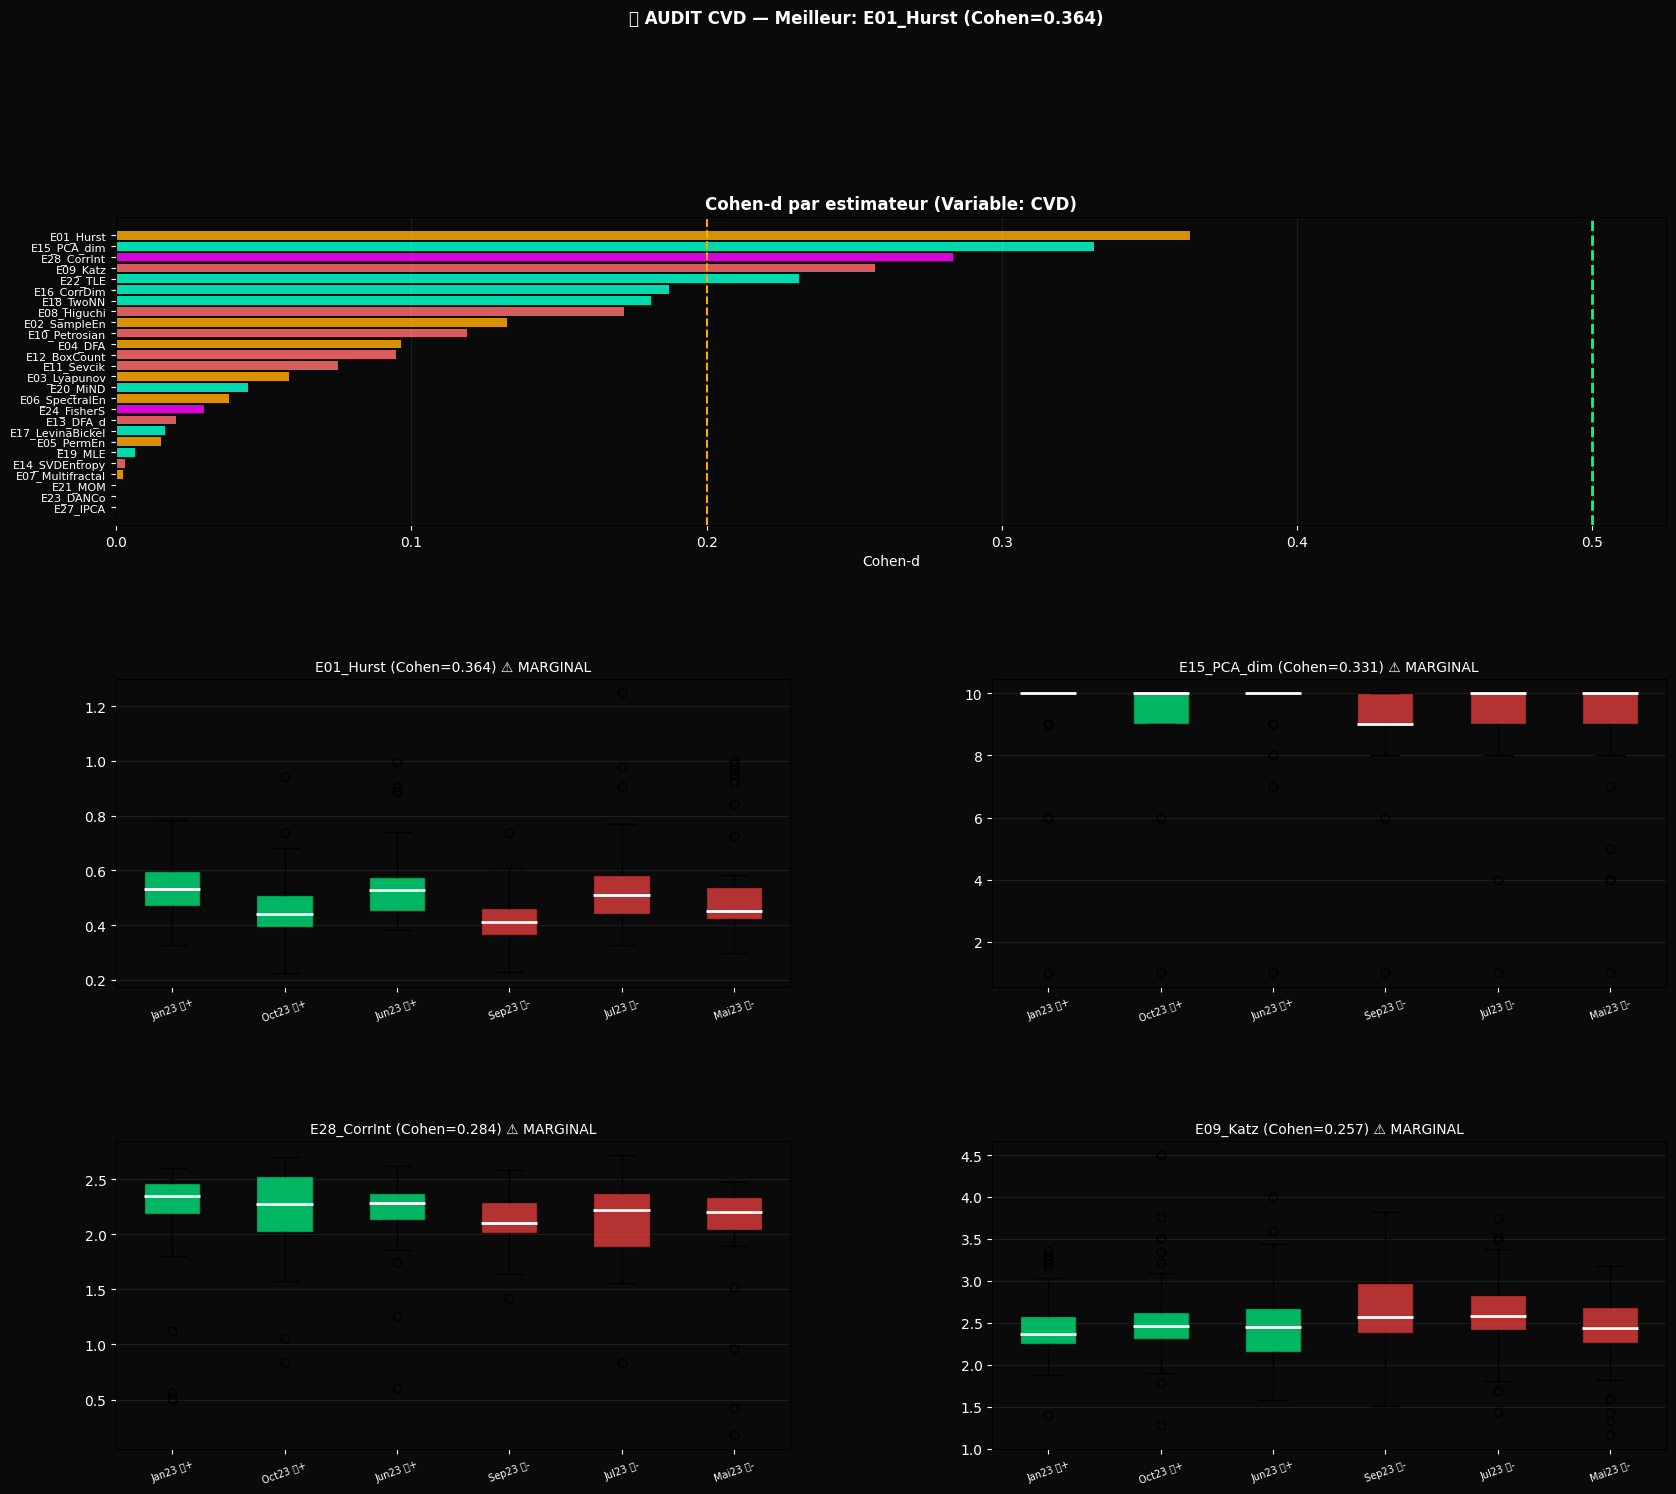

In [ ]:
# ==============================================================================
# 🔬 AUDIT MULTIVARIÉ — 27 Estimateurs (CVD / Open Interest)
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy import stats as scipy_stats
from scipy.signal import periodogram
import urllib.request, zipfile, io, os, warnings, time
warnings.filterwarnings('ignore')

# ==============================================================================
# 📦 INSTALLATION DES DÉPENDANCES
# ==============================================================================
import subprocess, sys
for lib, imp in [('antropy','antropy'), ('nolds','nolds'), ('scikit-dimension','skdim')]:
    try:
        __import__(imp)
    except ImportError:
        subprocess.check_call([sys.executable,'-m','pip','install',lib,'-q'],
                              stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
import antropy, nolds, skdim

# ==============================================================================
# 📥 MOTEUR D'INGESTION BINANCE FUTURES (CVD & OI)
# ==============================================================================
def download_and_read_zip(url, header_names=None):
    """Télécharge un ZIP en mémoire et le lit. Gère les headers des Futures."""
    try:
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=15) as response:
            with zipfile.ZipFile(io.BytesIO(response.read())) as z:
                csv_name = z.namelist()[0]
                with z.open(csv_name) as f:
                    if header_names:
                        return pd.read_csv(f, names=header_names, header=0)
                    else:
                        return pd.read_csv(f)
    except Exception:
        return None

def fetch_multivariate_month(symbol, year, month):
    kline_url = f"https://data.binance.vision/data/futures/um/monthly/klines/{symbol}/1h/{symbol}-1h-{year}-{month:02d}.zip"
    kline_cols = ['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_volume', 'count', 'taker_buy_volume', 'taker_buy_quote_volume', 'ignore']
    df_klines = download_and_read_zip(kline_url, header_names=kline_cols)
    if df_klines is None or df_klines.empty: return None

    df_klines['timestamp'] = pd.to_datetime(df_klines['open_time'], unit='ms')
    df_klines.set_index('timestamp', inplace=True)
    df_klines['buy_vol'] = df_klines['taker_buy_volume']
    df_klines['sell_vol'] = df_klines['volume'] - df_klines['taker_buy_volume']
    df_klines['delta_vol'] = df_klines['buy_vol'] - df_klines['sell_vol']
    df_klines['CVD'] = df_klines['delta_vol'].cumsum()

    num_days = pd.Period(f'{year}-{month:02d}').days_in_month
    oi_list = []

    # Récupération Open Interest Quotidien
    for day in range(1, num_days + 1):
        date_str = f"{year}-{month:02d}-{day:02d}"
        oi_url = f"https://data.binance.vision/data/futures/um/daily/openInterestHist/{symbol}/{symbol}-openInterestHist-{date_str}.zip"
        df_oi_day = download_and_read_zip(oi_url)
        if df_oi_day is not None and not df_oi_day.empty:
            df_oi_day['timestamp'] = pd.to_datetime(df_oi_day['timestamp'], unit='ms')
            df_oi_day.set_index('timestamp', inplace=True)
            oi_list.append(df_oi_day[['sumOpenInterestValue']].resample('1H').last())

    df_oi = pd.concat(oi_list) if oi_list else pd.DataFrame()
    df_final = df_klines[['close', 'volume', 'CVD']].copy()

    if not df_oi.empty:
        df_final = df_final.join(df_oi, how='left')
        df_final['sumOpenInterestValue'] = df_final['sumOpenInterestValue'].ffill()
        df_final.rename(columns={'sumOpenInterestValue': 'Open_Interest'}, inplace=True)
    else: df_final['Open_Interest'] = np.nan

    return df_final

def rolling_zscore(series, window=120):
    """Z-score glissant local (anti Lookahead bias)"""
    return (series - series.rolling(window).mean()) / (series.rolling(window).std() + 1e-8)

print("="*70)
print("  📊 TÉLÉCHARGEMENT DES DONNÉES (CVD & Open Interest) ...")
print("="*70)
MOIS_TEST = {
    'Jan23 🟢+': (2023, 1), 'Oct23 🟢+': (2023, 10), 'Jun23 🟢+': (2023, 6),
    'Sep23 🟡-': (2023, 9), 'Jul23 🟡-': (2023, 7),  'Mai23 🟡-': (2023, 5)
}

donnes = {}
for nom, (yr, mo) in MOIS_TEST.items():
    print(f"   📡 {nom}...")
    df = fetch_multivariate_month("BTCUSDT", yr, mo)
    if df is not None:
        donnes[nom] = {
            'lr_prix': np.diff(np.log(df['close'].values)),
            'cvd': rolling_zscore(pd.Series(np.diff(df['CVD'].values)), window=120).bfill().values,
            'oi': rolling_zscore(pd.Series(np.diff(df['Open_Interest'].values)), window=120).bfill().values
        }
        print(f"   ✅ {nom} ingéré avec succès.")

# ==============================================================================
# 🎯 SÉLECTION DE LA MATRICE DE PHASE À AUDITER
# ==============================================================================
# Options possibles : 'cvd', 'oi', 'lr_prix'
VARIABLE_TESTEE = 'cvd'
print(f"\n🚀 VARIABLE AUDITÉE : {VARIABLE_TESTEE.upper()}")

# ==============================================================================
# ⚙️ LES 27 ESTIMATEURS
# ==============================================================================
def safe(func, *args, **kwargs):
    try:
        r = func(*args, **kwargs); return float(r) if np.isfinite(float(r)) else np.nan
    except: return np.nan

def build_ps(x, emb=3, delay=1):
    n = len(x) - (emb-1)*delay
    if n < 10: return None
    return np.array([x[i:i+emb*delay:delay] for i in range(n)])

# ── Spectrale ──
def E01_Hurst(x): return safe(nolds.hurst_rs, x)
def E02_SampleEn(x):
    try: return float(antropy.sample_entropy(x[:500], order=2))
    except: return np.nan
def E03_Lyapunov(x):
    try: return float(nolds.lyap_r(x, emb_dim=3))
    except: return np.nan
def E04_DFA(x): return safe(nolds.dfa, x)
def E05_PermEn(x):
    try: return float(antropy.perm_entropy(x, order=5, normalize=True))
    except: return np.nan
def E06_SpectralEn(x):
    try:
        f, psd = periodogram(x, fs=1.0)
        psd = psd[1:]; psd_norm = psd / psd.sum()
        return float(-np.sum(psd_norm * np.log(psd_norm + 1e-12)))
    except: return np.nan
def E07_Multifractal(x):
    try:
        n = len(x); q_vals = np.array([-5,-3,-1,1,3,5]); hs = []
        for q in q_vals:
            scales = np.unique(np.logspace(1, np.log10(n//4), 8).astype(int))
            Fq = []
            for s in scales:
                segs = [x[i:i+s] for i in range(0, n-s, s)]
                if len(segs) < 2: continue
                rms = []
                for seg in segs:
                    fit = np.polyval(np.polyfit(range(len(seg)), seg, 1), range(len(seg)))
                    r = np.sqrt(np.mean((seg-fit)**2))
                    if r > 0: rms.append(r)
                if not rms: continue
                Fq.append(np.mean(np.array(rms)**q)**(1/q))
            if len(Fq) < 3: continue
            h, _ = np.polyfit(np.log(scales[:len(Fq)]), np.log(Fq), 1)
            hs.append(h)
        return float(np.max(hs) - np.min(hs)) if len(hs) >= 3 else np.nan
    except: return np.nan

# ── Saturation ──
def E08_Higuchi(x): return safe(antropy.higuchi_fd, x)
def E09_Katz(x): return safe(antropy.katz_fd, x)
def E10_Petrosian(x): return safe(antropy.petrosian_fd, x)
def E11_Sevcik(x):
    try:
        n = len(x); xn = (x - x.min()) / (x.max() - x.min() + 1e-12)
        tn = np.linspace(0, 1, n)
        L = np.sum(np.sqrt(np.diff(xn)**2 + np.diff(tn)**2))
        return float(1 + np.log(L) / np.log(2*(n-1)))
    except: return np.nan
def E12_BoxCount(x):
    try:
        xn = (x - x.min()) / (x.max() - x.min() + 1e-12)
        scales = [4,8,16,32,64,128]; counts = []
        for s in scales:
            if s >= len(x): continue
            hist, _ = np.histogram(xn, bins=np.linspace(0,1,s+1))
            counts.append(np.sum(hist > 0))
        if len(counts) < 3: return np.nan
        return float(-np.polyfit(np.log(scales[:len(counts)]), np.log(counts), 1)[0])
    except: return np.nan
def E13_DFA_d(x):
    h = safe(nolds.dfa, x); return float(2 - h) if not np.isnan(h) else np.nan
def E14_SVDEntropy(x):
    try: return float(antropy.svd_entropy(x, order=5, delay=1, normalize=True))
    except: return np.nan

# ── Transition ──
def E15_PCA_dim(x):
    try:
        X = build_ps(x, emb=10)
        if X is None: return np.nan
        pca = PCA().fit(X); cumvar = np.cumsum(pca.explained_variance_ratio_)
        return float(np.searchsorted(cumvar, 0.95) + 1)
    except: return np.nan
def E16_CorrDim(x):
    try: return float(nolds.corr_dim(x, emb_dim=3))
    except: return np.nan
def E17_LevinaBickel(x, k=10):
    try:
        X = build_ps(x, emb=3)
        if X is None or len(X) < k+2: return np.nan
        nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='brute').fit(X)
        d = np.maximum(nbrs.kneighbors(X)[0][:,1:], 1e-12)
        m = (k-1) / np.sum(np.log(d[:,-1:]/d[:,:-1]), axis=1); m = m[np.isfinite(m)]
        return float(np.median(m)) if len(m) > 0 else np.nan
    except: return np.nan
def E18_TwoNN(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.TwoNN().fit(X).dimension_) if X is not None and len(X) >= 5 else np.nan
    except: return np.nan
def E19_MLE(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.MLE().fit(X).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan
def E20_MiND(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.MiND_ML().fit(X).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan
def E21_MOM(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.MOM().fit(X).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan
def E22_TLE(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.TLE().fit(X).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan

# ── Divergence ──
def E23_DANCo(x):
    try:
        X = build_ps(x, emb=5); return float(skdim.id.DANCo().fit(X[:200]).dimension_) if X is not None and len(X) >= 20 else np.nan
    except: return np.nan
def E24_FisherS(x):
    try:
        X = build_ps(x, emb=5); return float(skdim.id.FisherS().fit(X[:200]).dimension_) if X is not None and len(X) >= 20 else np.nan
    except: return np.nan
def E26_GeoMle(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.GeoMle().fit(X[:300]).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan
def E27_lPCA(x):
    try:
        X = build_ps(x, emb=5); return float(skdim.id.lPCA().fit(X[:300]).dimension_) if X is not None and len(X) >= 20 else np.nan
    except: return np.nan
def E28_CorrInt(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.CorrInt().fit(X[:300]).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan

ESTIMATEURS = {
    'E01_Hurst': ('Spectrale', E01_Hurst), 'E02_SampleEn': ('Spectrale', E02_SampleEn), 'E03_Lyapunov': ('Spectrale', E03_Lyapunov),
    'E04_DFA': ('Spectrale', E04_DFA), 'E05_PermEn': ('Spectrale', E05_PermEn), 'E06_SpectralEn': ('Spectrale', E06_SpectralEn), 'E07_Multifractal': ('Spectrale', E07_Multifractal),
    'E08_Higuchi': ('Saturation', E08_Higuchi), 'E09_Katz': ('Saturation', E09_Katz), 'E10_Petrosian': ('Saturation', E10_Petrosian),
    'E11_Sevcik': ('Saturation', E11_Sevcik), 'E12_BoxCount': ('Saturation', E12_BoxCount), 'E13_DFA_d': ('Saturation', E13_DFA_d), 'E14_SVDEntropy': ('Saturation', E14_SVDEntropy),
    'E15_PCA_dim': ('Transition', E15_PCA_dim), 'E16_CorrDim': ('Transition', E16_CorrDim), 'E17_LevinaBickel': ('Transition', E17_LevinaBickel),
    'E18_TwoNN': ('Transition', E18_TwoNN), 'E19_MLE': ('Transition', E19_MLE), 'E20_MiND': ('Transition', E20_MiND),
    'E21_MOM': ('Transition', E21_MOM), 'E22_TLE': ('Transition', E22_TLE), 'E23_DANCo': ('Divergence', E23_DANCo),
    'E24_FisherS': ('Divergence', E24_FisherS), 'E26_GeoMle': ('Divergence', E26_GeoMle), 'E27_lPCA': ('Divergence', E27_lPCA), 'E28_CorrInt': ('Divergence', E28_CorrInt)
}

# ==============================================================================
# 🚀 CALCUL
# ==============================================================================
WINDOW, STRIDE = 120, 12
resultats = {}

for nom_est, (classe, func) in ESTIMATEURS.items():
    t0 = time.time()
    vals_par_mois = {}
    for nom_mois, data in donnes.items():
        signal = data[VARIABLE_TESTEE]
        vals = []
        for i in range(WINDOW, len(signal), STRIDE):
            v = func(signal[i-WINDOW:i])
            if isinstance(v, float) and np.isfinite(v):
                vals.append(v)
        vals_par_mois[nom_mois] = vals

    elapsed = time.time() - t0
    total = sum(len(v) for v in vals_par_mois.values())
    if total == 0:
        print(f"  {nom_est:<22} ({classe:<12}) ❌ ÉCHEC [{elapsed:.1f}s]"); continue

    resultats[nom_est] = {'classe': classe, 'vals': vals_par_mois}
    bons = [v for nm,vs in vals_par_mois.items() if '+' in nm for v in vs]
    mauvais = [v for nm,vs in vals_par_mois.items() if '-' in nm for v in vs]
    if bons and mauvais:
        cd = abs(np.median(bons)-np.median(mauvais)) / (np.std(bons+mauvais)+1e-12)
        sig = "✅" if cd > 0.3 else ("⚠️" if cd > 0.1 else "❌")
        print(f"  {nom_est:<22} ({classe:<12}) d̄={np.median(bons+mauvais):6.3f} Cohen={cd:.3f} {sig} [{elapsed:.1f}s]")

# ==============================================================================
# 📊 CLASSEMENT ET GRAPHIQUES
# ==============================================================================
analyse = []
for nom_est, data in resultats.items():
    bons = [v for nm,vs in data['vals'].items() if '+' in nm for v in vs]
    mauvais = [v for nm,vs in data['vals'].items() if '-' in nm for v in vs]
    if not bons or not mauvais: continue
    mb, mm = np.median(bons), np.median(mauvais)
    cohen  = abs(mb-mm) / (np.std(bons+mauvais)+1e-12)
    pval   = scipy_stats.mannwhitneyu(bons,mauvais,alternative='two-sided').pvalue if len(bons)>5 and len(mauvais)>5 else 1.0
    signal = "✅ FORT" if cohen>0.5 and pval<0.05 else ("⚠️ MARGINAL" if cohen>0.2 else "❌ BRUIT")
    analyse.append({'nom':nom_est,'classe':data['classe'],'mb':mb,'mm':mm,'cohen':cohen,'pval':pval,'signal':signal})

analyse_sorted = sorted(analyse, key=lambda x: x['cohen'], reverse=True)
print("\n" + "="*70)
print(f"  🏁 RÉSULTATS DE L'AUDIT SUR LA VARIABLE : {VARIABLE_TESTEE.upper()}")
print("="*70)
for i,a in enumerate(analyse_sorted):
    print(f"  {i+1:<2} {a['nom']:<20} {a['classe']:<12} d_bons={a['mb']:>6.3f} d_mauv={a['mm']:>6.3f} Cohen={a['cohen']:>5.3f} {a['signal']}")

fig = plt.figure(figsize=(20, 16)); fig.patch.set_facecolor('#0a0a0a')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.3)
CMAP = {'Spectrale':'#ffaa00','Saturation':'#ff6b6b','Transition':'#00ffcc','Divergence':'#ff00ff'}

ax1 = fig.add_subplot(gs[0,:]); ax1.set_facecolor('#0a0a0a')
ax1.set_title(f"Cohen-d par estimateur (Variable: {VARIABLE_TESTEE.upper()})", color='white', fontsize=12, fontweight='bold')
noms_plot = [a['nom'] for a in analyse_sorted]; cohens_plot = [a['cohen'] for a in analyse_sorted]
clrs_plot = [CMAP.get(a['classe'],'#fff') for a in analyse_sorted]
ax1.barh(range(len(noms_plot)), cohens_plot[::-1], color=list(reversed(clrs_plot)), alpha=0.85)
ax1.axvline(x=0.5, color='#00ff88', linestyle='--', linewidth=2)
ax1.axvline(x=0.2, color='#ffaa00', linestyle='--', linewidth=1.5)
ax1.set_yticks(range(len(noms_plot))); ax1.set_yticklabels(list(reversed(noms_plot)), color='white', fontsize=8)
ax1.set_xlabel("Cohen-d", color='white'); ax1.tick_params(colors='white'); ax1.grid(color='white', alpha=0.08, axis='x')

top4 = analyse_sorted[:4]
for idx, a in enumerate(top4):
    ax = fig.add_subplot(gs[1 + idx//2, idx%2]); ax.set_facecolor('#0a0a0a')
    ax.set_title(f"{a['nom']} (Cohen={a['cohen']:.3f}) {a['signal']}", color='white', fontsize=10)
    noms_mois = list(donnes.keys()); bp_data = [resultats[a['nom']]['vals'].get(nm,[np.nan]) for nm in noms_mois]
    clrs_box = ['#00ff88' if '+' in nm else '#ff4444' for nm in noms_mois]
    bp = ax.boxplot(bp_data, patch_artist=True, medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], clrs_box): patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticklabels(noms_mois, color='white', fontsize=7, rotation=20); ax.tick_params(colors='white')
    ax.grid(color='white', alpha=0.08, axis='y')

plt.suptitle(f"🔬 AUDIT {VARIABLE_TESTEE.upper()} — Meilleur: {analyse_sorted[0]['nom']} (Cohen={analyse_sorted[0]['cohen']:.3f})", color='white', fontsize=12, y=1.01, fontweight='bold')
plt.savefig(f"audit_multivarié_{VARIABLE_TESTEE}.png", dpi=120, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

  📊 TÉLÉCHARGEMENT DES DONNÉES (CVD & Open Interest) ...
   📡 Jan23 🟢+...
   ✅ Jan23 🟢+ ingéré avec succès.
   📡 Oct23 🟢+...
   ✅ Oct23 🟢+ ingéré avec succès.
   📡 Jun23 🟢+...
   ✅ Jun23 🟢+ ingéré avec succès.
   📡 Sep23 🟡-...
   ✅ Sep23 🟡- ingéré avec succès.
   📡 Jul23 🟡-...
   ✅ Jul23 🟡- ingéré avec succès.
   📡 Mai23 🟡-...
   ✅ Mai23 🟡- ingéré avec succès.

🚀 VARIABLE AUDITÉE : OI
  E01_Hurst              (Spectrale   ) ❌ ÉCHEC [0.4s]
  E02_SampleEn           (Spectrale   ) d̄= 0.000 Cohen=0.000 ❌ [0.0s]
  E03_Lyapunov           (Spectrale   ) ❌ ÉCHEC [0.0s]
  E04_DFA                (Spectrale   ) ❌ ÉCHEC [5.0s]
  E05_PermEn             (Spectrale   ) d̄= 0.000 Cohen=0.000 ❌ [0.0s]
  E06_SpectralEn         (Spectrale   ) ❌ ÉCHEC [0.1s]
  E07_Multifractal       (Spectrale   ) ❌ ÉCHEC [11.9s]
  E08_Higuchi            (Saturation  ) ❌ ÉCHEC [0.0s]
  E09_Katz               (Saturation  ) ❌ ÉCHEC [0.0s]
  E10_Petrosian          (Saturation  ) d̄= 1.000 Cohen=0.000 ❌ [0.0s]
  E11_Sevcik 

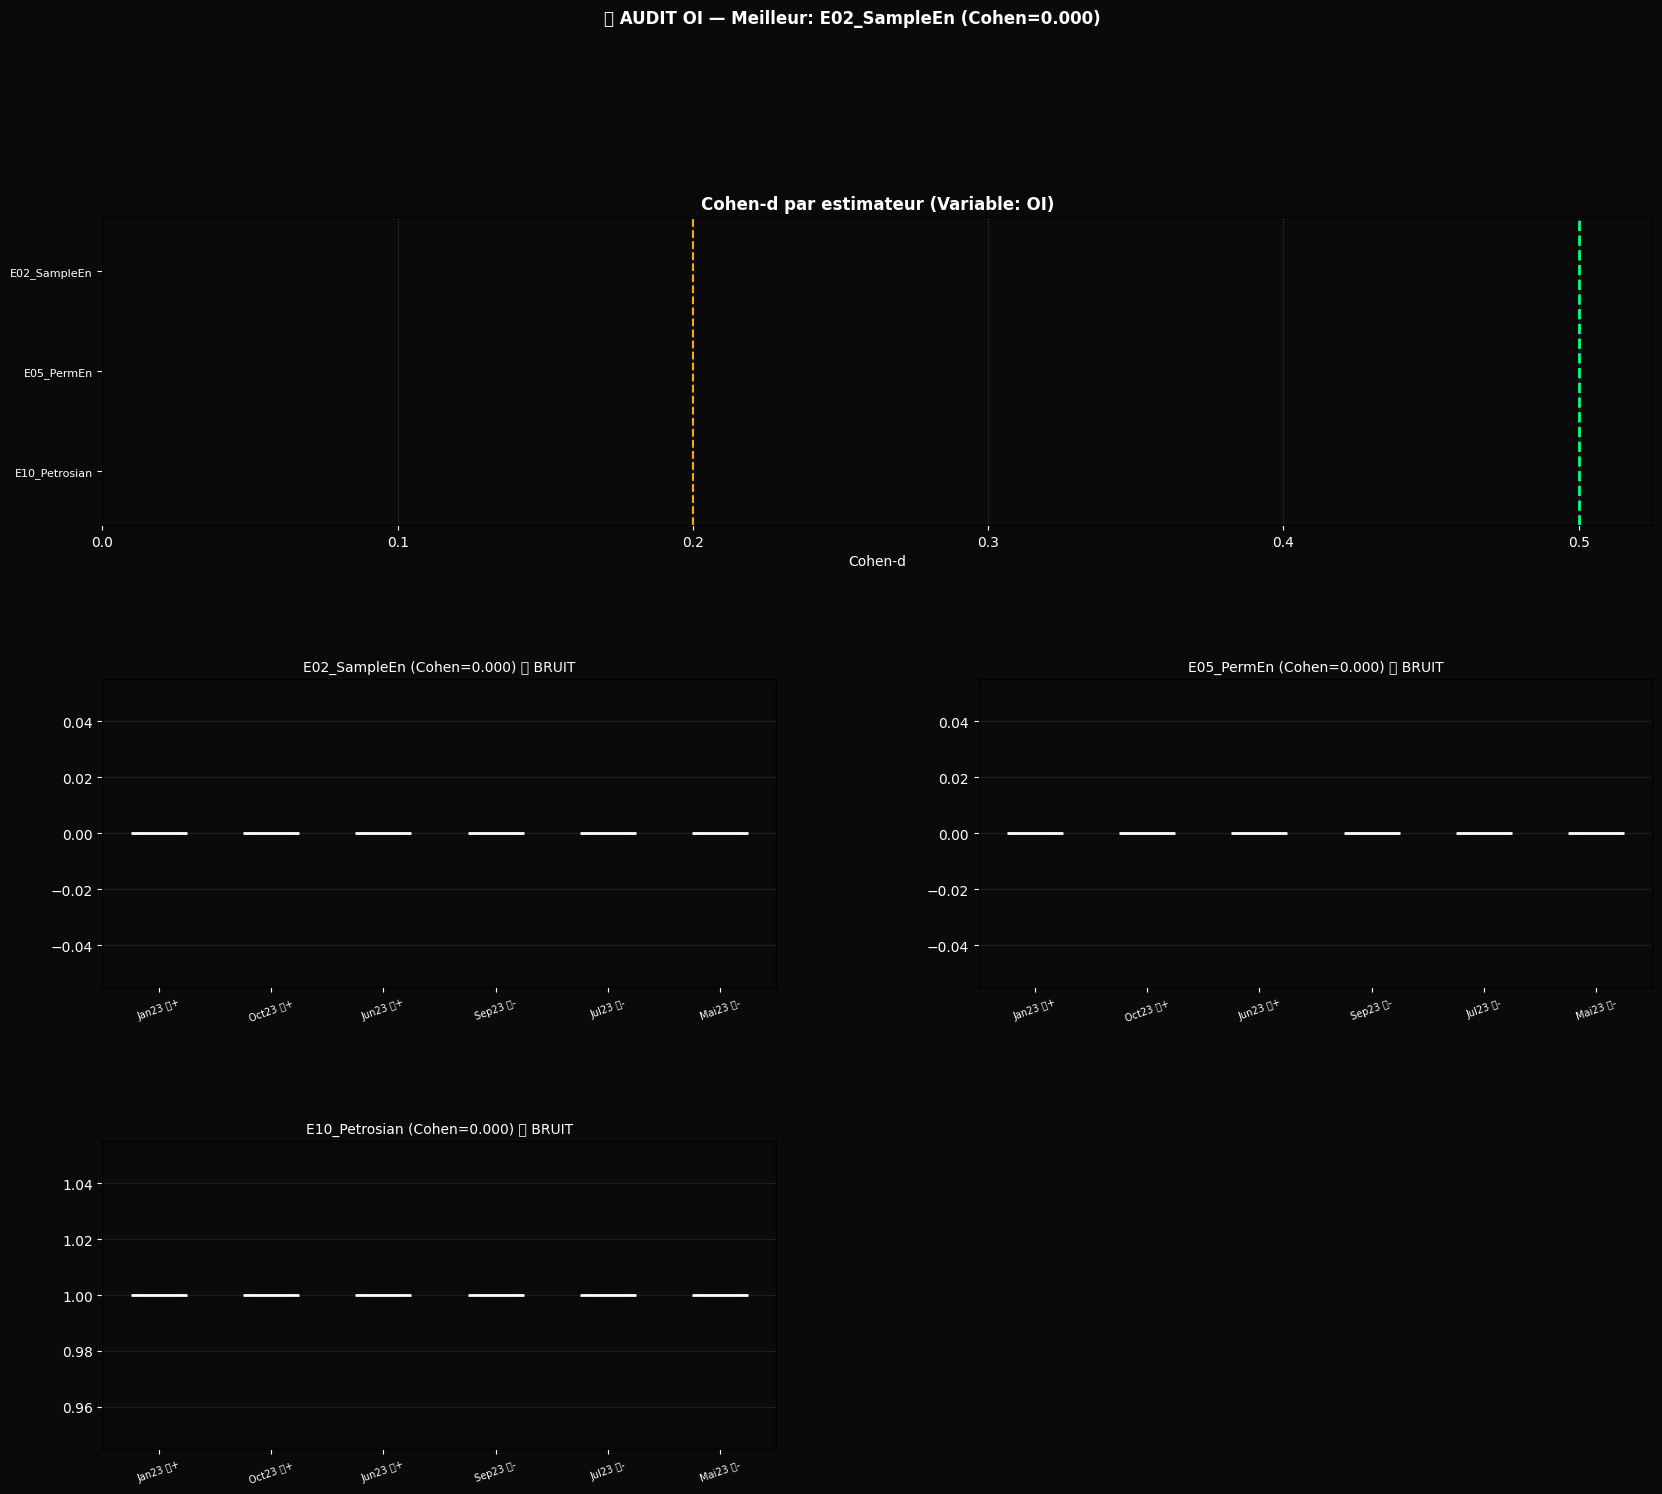

In [ ]:
# ==============================================================================
# 🔬 AUDIT MULTIVARIÉ — 27 Estimateurs sur OPEN INTEREST
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy import stats as scipy_stats
from scipy.signal import periodogram
import urllib.request, zipfile, io, os, warnings, time
warnings.filterwarnings('ignore')

import subprocess, sys
for lib, imp in [('antropy','antropy'), ('nolds','nolds'), ('scikit-dimension','skdim')]:
    try:
        __import__(imp)
    except ImportError:
        subprocess.check_call([sys.executable,'-m','pip','install',lib,'-q'],
                              stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
import antropy, nolds, skdim

def download_and_read_zip(url, header_names=None):
    try:
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=15) as response:
            with zipfile.ZipFile(io.BytesIO(response.read())) as z:
                csv_name = z.namelist()[0]
                with z.open(csv_name) as f:
                    if header_names: return pd.read_csv(f, names=header_names, header=0)
                    else: return pd.read_csv(f)
    except Exception: return None

def fetch_multivariate_month(symbol, year, month):
    kline_url = f"https://data.binance.vision/data/futures/um/monthly/klines/{symbol}/1h/{symbol}-1h-{year}-{month:02d}.zip"
    kline_cols = ['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_volume', 'count', 'taker_buy_volume', 'taker_buy_quote_volume', 'ignore']
    df_klines = download_and_read_zip(kline_url, header_names=kline_cols)
    if df_klines is None or df_klines.empty: return None

    df_klines['timestamp'] = pd.to_datetime(df_klines['open_time'], unit='ms')
    df_klines.set_index('timestamp', inplace=True)
    df_klines['buy_vol'] = df_klines['taker_buy_volume']
    df_klines['sell_vol'] = df_klines['volume'] - df_klines['taker_buy_volume']
    df_klines['delta_vol'] = df_klines['buy_vol'] - df_klines['sell_vol']
    df_klines['CVD'] = df_klines['delta_vol'].cumsum()

    num_days = pd.Period(f'{year}-{month:02d}').days_in_month
    oi_list = []

    for day in range(1, num_days + 1):
        date_str = f"{year}-{month:02d}-{day:02d}"
        oi_url = f"https://data.binance.vision/data/futures/um/daily/openInterestHist/{symbol}/{symbol}-openInterestHist-{date_str}.zip"
        df_oi_day = download_and_read_zip(oi_url)
        if df_oi_day is not None and not df_oi_day.empty:
            df_oi_day['timestamp'] = pd.to_datetime(df_oi_day['timestamp'], unit='ms')
            df_oi_day.set_index('timestamp', inplace=True)
            oi_list.append(df_oi_day[['sumOpenInterestValue']].resample('1H').last())

    df_oi = pd.concat(oi_list) if oi_list else pd.DataFrame()
    df_final = df_klines[['close', 'volume', 'CVD']].copy()

    if not df_oi.empty:
        df_final = df_final.join(df_oi, how='left')
        df_final['sumOpenInterestValue'] = df_final['sumOpenInterestValue'].ffill()
        df_final.rename(columns={'sumOpenInterestValue': 'Open_Interest'}, inplace=True)
    else: df_final['Open_Interest'] = np.nan

    return df_final

def rolling_zscore(series, window=120):
    return (series - series.rolling(window).mean()) / (series.rolling(window).std() + 1e-8)

print("="*70)
print("  📊 TÉLÉCHARGEMENT DES DONNÉES (CVD & Open Interest) ...")
print("="*70)
MOIS_TEST = {
    'Jan23 🟢+': (2023, 1), 'Oct23 🟢+': (2023, 10), 'Jun23 🟢+': (2023, 6),
    'Sep23 🟡-': (2023, 9), 'Jul23 🟡-': (2023, 7),  'Mai23 🟡-': (2023, 5)
}

donnes = {}
for nom, (yr, mo) in MOIS_TEST.items():
    print(f"   📡 {nom}...")
    df = fetch_multivariate_month("BTCUSDT", yr, mo)
    if df is not None:
        donnes[nom] = {
            'lr_prix': np.diff(np.log(df['close'].values)),
            'cvd': rolling_zscore(pd.Series(np.diff(df['CVD'].values)), window=120).bfill().values,
            'oi': rolling_zscore(pd.Series(np.diff(df['Open_Interest'].values)), window=120).bfill().values
        }
        print(f"   ✅ {nom} ingéré avec succès.")

# ==============================================================================
# 🎯 SÉLECTION : OPEN INTEREST
# ==============================================================================
VARIABLE_TESTEE = 'oi'
print(f"\n🚀 VARIABLE AUDITÉE : {VARIABLE_TESTEE.upper()}")

def safe(func, *args, **kwargs):
    try:
        r = func(*args, **kwargs); return float(r) if np.isfinite(float(r)) else np.nan
    except: return np.nan

def build_ps(x, emb=3, delay=1):
    n = len(x) - (emb-1)*delay
    if n < 10: return None
    return np.array([x[i:i+emb*delay:delay] for i in range(n)])

# ── Spectrale ──
def E01_Hurst(x): return safe(nolds.hurst_rs, x)
def E02_SampleEn(x):
    try: return float(antropy.sample_entropy(x[:500], order=2))
    except: return np.nan
def E03_Lyapunov(x):
    try: return float(nolds.lyap_r(x, emb_dim=3))
    except: return np.nan
def E04_DFA(x): return safe(nolds.dfa, x)
def E05_PermEn(x):
    try: return float(antropy.perm_entropy(x, order=5, normalize=True))
    except: return np.nan
def E06_SpectralEn(x):
    try:
        f, psd = periodogram(x, fs=1.0)
        psd = psd[1:]; psd_norm = psd / psd.sum()
        return float(-np.sum(psd_norm * np.log(psd_norm + 1e-12)))
    except: return np.nan
def E07_Multifractal(x):
    try:
        n = len(x); q_vals = np.array([-5,-3,-1,1,3,5]); hs = []
        for q in q_vals:
            scales = np.unique(np.logspace(1, np.log10(n//4), 8).astype(int))
            Fq = []
            for s in scales:
                segs = [x[i:i+s] for i in range(0, n-s, s)]
                if len(segs) < 2: continue
                rms = []
                for seg in segs:
                    fit = np.polyval(np.polyfit(range(len(seg)), seg, 1), range(len(seg)))
                    r = np.sqrt(np.mean((seg-fit)**2))
                    if r > 0: rms.append(r)
                if not rms: continue
                Fq.append(np.mean(np.array(rms)**q)**(1/q))
            if len(Fq) < 3: continue
            h, _ = np.polyfit(np.log(scales[:len(Fq)]), np.log(Fq), 1)
            hs.append(h)
        return float(np.max(hs) - np.min(hs)) if len(hs) >= 3 else np.nan
    except: return np.nan

# ── Saturation ──
def E08_Higuchi(x): return safe(antropy.higuchi_fd, x)
def E09_Katz(x): return safe(antropy.katz_fd, x)
def E10_Petrosian(x): return safe(antropy.petrosian_fd, x)
def E11_Sevcik(x):
    try:
        n = len(x); xn = (x - x.min()) / (x.max() - x.min() + 1e-12)
        tn = np.linspace(0, 1, n)
        L = np.sum(np.sqrt(np.diff(xn)**2 + np.diff(tn)**2))
        return float(1 + np.log(L) / np.log(2*(n-1)))
    except: return np.nan
def E12_BoxCount(x):
    try:
        xn = (x - x.min()) / (x.max() - x.min() + 1e-12)
        scales = [4,8,16,32,64,128]; counts = []
        for s in scales:
            if s >= len(x): continue
            hist, _ = np.histogram(xn, bins=np.linspace(0,1,s+1))
            counts.append(np.sum(hist > 0))
        if len(counts) < 3: return np.nan
        return float(-np.polyfit(np.log(scales[:len(counts)]), np.log(counts), 1)[0])
    except: return np.nan
def E13_DFA_d(x):
    h = safe(nolds.dfa, x); return float(2 - h) if not np.isnan(h) else np.nan
def E14_SVDEntropy(x):
    try: return float(antropy.svd_entropy(x, order=5, delay=1, normalize=True))
    except: return np.nan

# ── Transition ──
def E15_PCA_dim(x):
    try:
        X = build_ps(x, emb=10)
        if X is None: return np.nan
        pca = PCA().fit(X); cumvar = np.cumsum(pca.explained_variance_ratio_)
        return float(np.searchsorted(cumvar, 0.95) + 1)
    except: return np.nan
def E16_CorrDim(x):
    try: return float(nolds.corr_dim(x, emb_dim=3))
    except: return np.nan
def E17_LevinaBickel(x, k=10):
    try:
        X = build_ps(x, emb=3)
        if X is None or len(X) < k+2: return np.nan
        nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='brute').fit(X)
        d = np.maximum(nbrs.kneighbors(X)[0][:,1:], 1e-12)
        m = (k-1) / np.sum(np.log(d[:,-1:]/d[:,:-1]), axis=1); m = m[np.isfinite(m)]
        return float(np.median(m)) if len(m) > 0 else np.nan
    except: return np.nan
def E18_TwoNN(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.TwoNN().fit(X).dimension_) if X is not None and len(X) >= 5 else np.nan
    except: return np.nan
def E19_MLE(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.MLE().fit(X).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan
def E20_MiND(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.MiND_ML().fit(X).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan
def E21_MOM(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.MOM().fit(X).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan
def E22_TLE(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.TLE().fit(X).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan

# ── Divergence ──
def E23_DANCo(x):
    try:
        X = build_ps(x, emb=5); return float(skdim.id.DANCo().fit(X[:200]).dimension_) if X is not None and len(X) >= 20 else np.nan
    except: return np.nan
def E24_FisherS(x):
    try:
        X = build_ps(x, emb=5); return float(skdim.id.FisherS().fit(X[:200]).dimension_) if X is not None and len(X) >= 20 else np.nan
    except: return np.nan
def E26_GeoMle(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.GeoMle().fit(X[:300]).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan
def E27_lPCA(x):
    try:
        X = build_ps(x, emb=5); return float(skdim.id.lPCA().fit(X[:300]).dimension_) if X is not None and len(X) >= 20 else np.nan
    except: return np.nan
def E28_CorrInt(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.CorrInt().fit(X[:300]).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan

ESTIMATEURS = {
    'E01_Hurst': ('Spectrale', E01_Hurst), 'E02_SampleEn': ('Spectrale', E02_SampleEn), 'E03_Lyapunov': ('Spectrale', E03_Lyapunov),
    'E04_DFA': ('Spectrale', E04_DFA), 'E05_PermEn': ('Spectrale', E05_PermEn), 'E06_SpectralEn': ('Spectrale', E06_SpectralEn), 'E07_Multifractal': ('Spectrale', E07_Multifractal),
    'E08_Higuchi': ('Saturation', E08_Higuchi), 'E09_Katz': ('Saturation', E09_Katz), 'E10_Petrosian': ('Saturation', E10_Petrosian),
    'E11_Sevcik': ('Saturation', E11_Sevcik), 'E12_BoxCount': ('Saturation', E12_BoxCount), 'E13_DFA_d': ('Saturation', E13_DFA_d), 'E14_SVDEntropy': ('Saturation', E14_SVDEntropy),
    'E15_PCA_dim': ('Transition', E15_PCA_dim), 'E16_CorrDim': ('Transition', E16_CorrDim), 'E17_LevinaBickel': ('Transition', E17_LevinaBickel),
    'E18_TwoNN': ('Transition', E18_TwoNN), 'E19_MLE': ('Transition', E19_MLE), 'E20_MiND': ('Transition', E20_MiND),
    'E21_MOM': ('Transition', E21_MOM), 'E22_TLE': ('Transition', E22_TLE), 'E23_DANCo': ('Divergence', E23_DANCo),
    'E24_FisherS': ('Divergence', E24_FisherS), 'E26_GeoMle': ('Divergence', E26_GeoMle), 'E27_lPCA': ('Divergence', E27_lPCA), 'E28_CorrInt': ('Divergence', E28_CorrInt)
}

# ==============================================================================
# 🚀 CALCUL
# ==============================================================================
WINDOW, STRIDE = 120, 12
resultats = {}

for nom_est, (classe, func) in ESTIMATEURS.items():
    t0 = time.time()
    vals_par_mois = {}
    for nom_mois, data in donnes.items():
        signal = data[VARIABLE_TESTEE]
        vals = []
        for i in range(WINDOW, len(signal), STRIDE):
            v = func(signal[i-WINDOW:i])
            if isinstance(v, float) and np.isfinite(v): vals.append(v)
        vals_par_mois[nom_mois] = vals

    elapsed = time.time() - t0
    total = sum(len(v) for v in vals_par_mois.values())
    if total == 0:
        print(f"  {nom_est:<22} ({classe:<12}) ❌ ÉCHEC [{elapsed:.1f}s]"); continue

    resultats[nom_est] = {'classe': classe, 'vals': vals_par_mois}
    bons = [v for nm,vs in vals_par_mois.items() if '+' in nm for v in vs]
    mauvais = [v for nm,vs in vals_par_mois.items() if '-' in nm for v in vs]
    if bons and mauvais:
        cd = abs(np.median(bons)-np.median(mauvais)) / (np.std(bons+mauvais)+1e-12)
        sig = "✅" if cd > 0.3 else ("⚠️" if cd > 0.1 else "❌")
        print(f"  {nom_est:<22} ({classe:<12}) d̄={np.median(bons+mauvais):6.3f} Cohen={cd:.3f} {sig} [{elapsed:.1f}s]")

# ==============================================================================
# 📊 CLASSEMENT ET GRAPHIQUES
# ==============================================================================
analyse = []
for nom_est, data in resultats.items():
    bons = [v for nm,vs in data['vals'].items() if '+' in nm for v in vs]
    mauvais = [v for nm,vs in data['vals'].items() if '-' in nm for v in vs]
    if not bons or not mauvais: continue
    mb, mm = np.median(bons), np.median(mauvais)
    cohen  = abs(mb-mm) / (np.std(bons+mauvais)+1e-12)
    pval   = scipy_stats.mannwhitneyu(bons,mauvais,alternative='two-sided').pvalue if len(bons)>5 and len(mauvais)>5 else 1.0
    signal = "✅ FORT" if cohen>0.5 and pval<0.05 else ("⚠️ MARGINAL" if cohen>0.2 else "❌ BRUIT")
    analyse.append({'nom':nom_est,'classe':data['classe'],'mb':mb,'mm':mm,'cohen':cohen,'pval':pval,'signal':signal})

analyse_sorted = sorted(analyse, key=lambda x: x['cohen'], reverse=True)
print("\n" + "="*70)
print(f"  🏁 RÉSULTATS DE L'AUDIT SUR LA VARIABLE : {VARIABLE_TESTEE.upper()}")
print("="*70)
for i,a in enumerate(analyse_sorted):
    print(f"  {i+1:<2} {a['nom']:<20} {a['classe']:<12} d_bons={a['mb']:>6.3f} d_mauv={a['mm']:>6.3f} Cohen={a['cohen']:>5.3f} {a['signal']}")

fig = plt.figure(figsize=(20, 16)); fig.patch.set_facecolor('#0a0a0a')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.3)
CMAP = {'Spectrale':'#ffaa00','Saturation':'#ff6b6b','Transition':'#00ffcc','Divergence':'#ff00ff'}

ax1 = fig.add_subplot(gs[0,:]); ax1.set_facecolor('#0a0a0a')
ax1.set_title(f"Cohen-d par estimateur (Variable: {VARIABLE_TESTEE.upper()})", color='white', fontsize=12, fontweight='bold')
noms_plot = [a['nom'] for a in analyse_sorted]; cohens_plot = [a['cohen'] for a in analyse_sorted]
clrs_plot = [CMAP.get(a['classe'],'#fff') for a in analyse_sorted]
ax1.barh(range(len(noms_plot)), cohens_plot[::-1], color=list(reversed(clrs_plot)), alpha=0.85)
ax1.axvline(x=0.5, color='#00ff88', linestyle='--', linewidth=2)
ax1.axvline(x=0.2, color='#ffaa00', linestyle='--', linewidth=1.5)
ax1.set_yticks(range(len(noms_plot))); ax1.set_yticklabels(list(reversed(noms_plot)), color='white', fontsize=8)
ax1.set_xlabel("Cohen-d", color='white'); ax1.tick_params(colors='white'); ax1.grid(color='white', alpha=0.08, axis='x')

top4 = analyse_sorted[:4]
for idx, a in enumerate(top4):
    ax = fig.add_subplot(gs[1 + idx//2, idx%2]); ax.set_facecolor('#0a0a0a')
    ax.set_title(f"{a['nom']} (Cohen={a['cohen']:.3f}) {a['signal']}", color='white', fontsize=10)
    noms_mois = list(donnes.keys()); bp_data = [resultats[a['nom']]['vals'].get(nm,[np.nan]) for nm in noms_mois]
    clrs_box = ['#00ff88' if '+' in nm else '#ff4444' for nm in noms_mois]
    bp = ax.boxplot(bp_data, patch_artist=True, medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], clrs_box): patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticklabels(noms_mois, color='white', fontsize=7, rotation=20); ax.tick_params(colors='white')
    ax.grid(color='white', alpha=0.08, axis='y')

plt.suptitle(f"🔬 AUDIT {VARIABLE_TESTEE.upper()} — Meilleur: {analyse_sorted[0]['nom']} (Cohen={analyse_sorted[0]['cohen']:.3f})", color='white', fontsize=12, y=1.01, fontweight='bold')
plt.savefig(f"audit_multivarié_{VARIABLE_TESTEE}.png", dpi=120, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

  🌊 TÉLÉCHARGEMENT DES DONNÉES (TEST DE FLUX CVD) ...
   📡 Jan23 📈UP...
   ✅ Jan23 📈UP ingéré avec succès.
   📡 Oct23 📈UP...
   ✅ Oct23 📈UP ingéré avec succès.
   📡 Dec23 📈UP...
   ✅ Dec23 📈UP ingéré avec succès.
   📡 Aou23 📉DOWN...
   ✅ Aou23 📉DOWN ingéré avec succès.
   📡 Mai23 📉DOWN...
   ✅ Mai23 📉DOWN ingéré avec succès.
   📡 Jui23 📉DOWN...
   ✅ Jui23 📉DOWN ingéré avec succès.
  E01_Hurst              (Spectrale   ) d̄= 0.491 Cohen=0.127 ⚠️ [6.4s]
  E02_SampleEn           (Spectrale   ) d̄= 1.470 Cohen=0.170 ⚠️ [0.0s]
  E03_Lyapunov           (Spectrale   ) d̄= 0.001 Cohen=0.091 ❌ [7.7s]
  E04_DFA                (Spectrale   ) d̄= 0.632 Cohen=0.028 ❌ [7.0s]
  E05_PermEn             (Spectrale   ) d̄= 0.878 Cohen=0.006 ❌ [0.0s]
  E06_SpectralEn         (Spectrale   ) d̄= 3.705 Cohen=0.091 ❌ [0.1s]
  E07_Multifractal       (Spectrale   ) d̄= 0.537 Cohen=0.006 ❌ [12.1s]
  E08_Higuchi            (Saturation  ) d̄= 1.995 Cohen=0.086 ❌ [0.0s]
  E09_Katz               (Saturation  ) d̄= 2

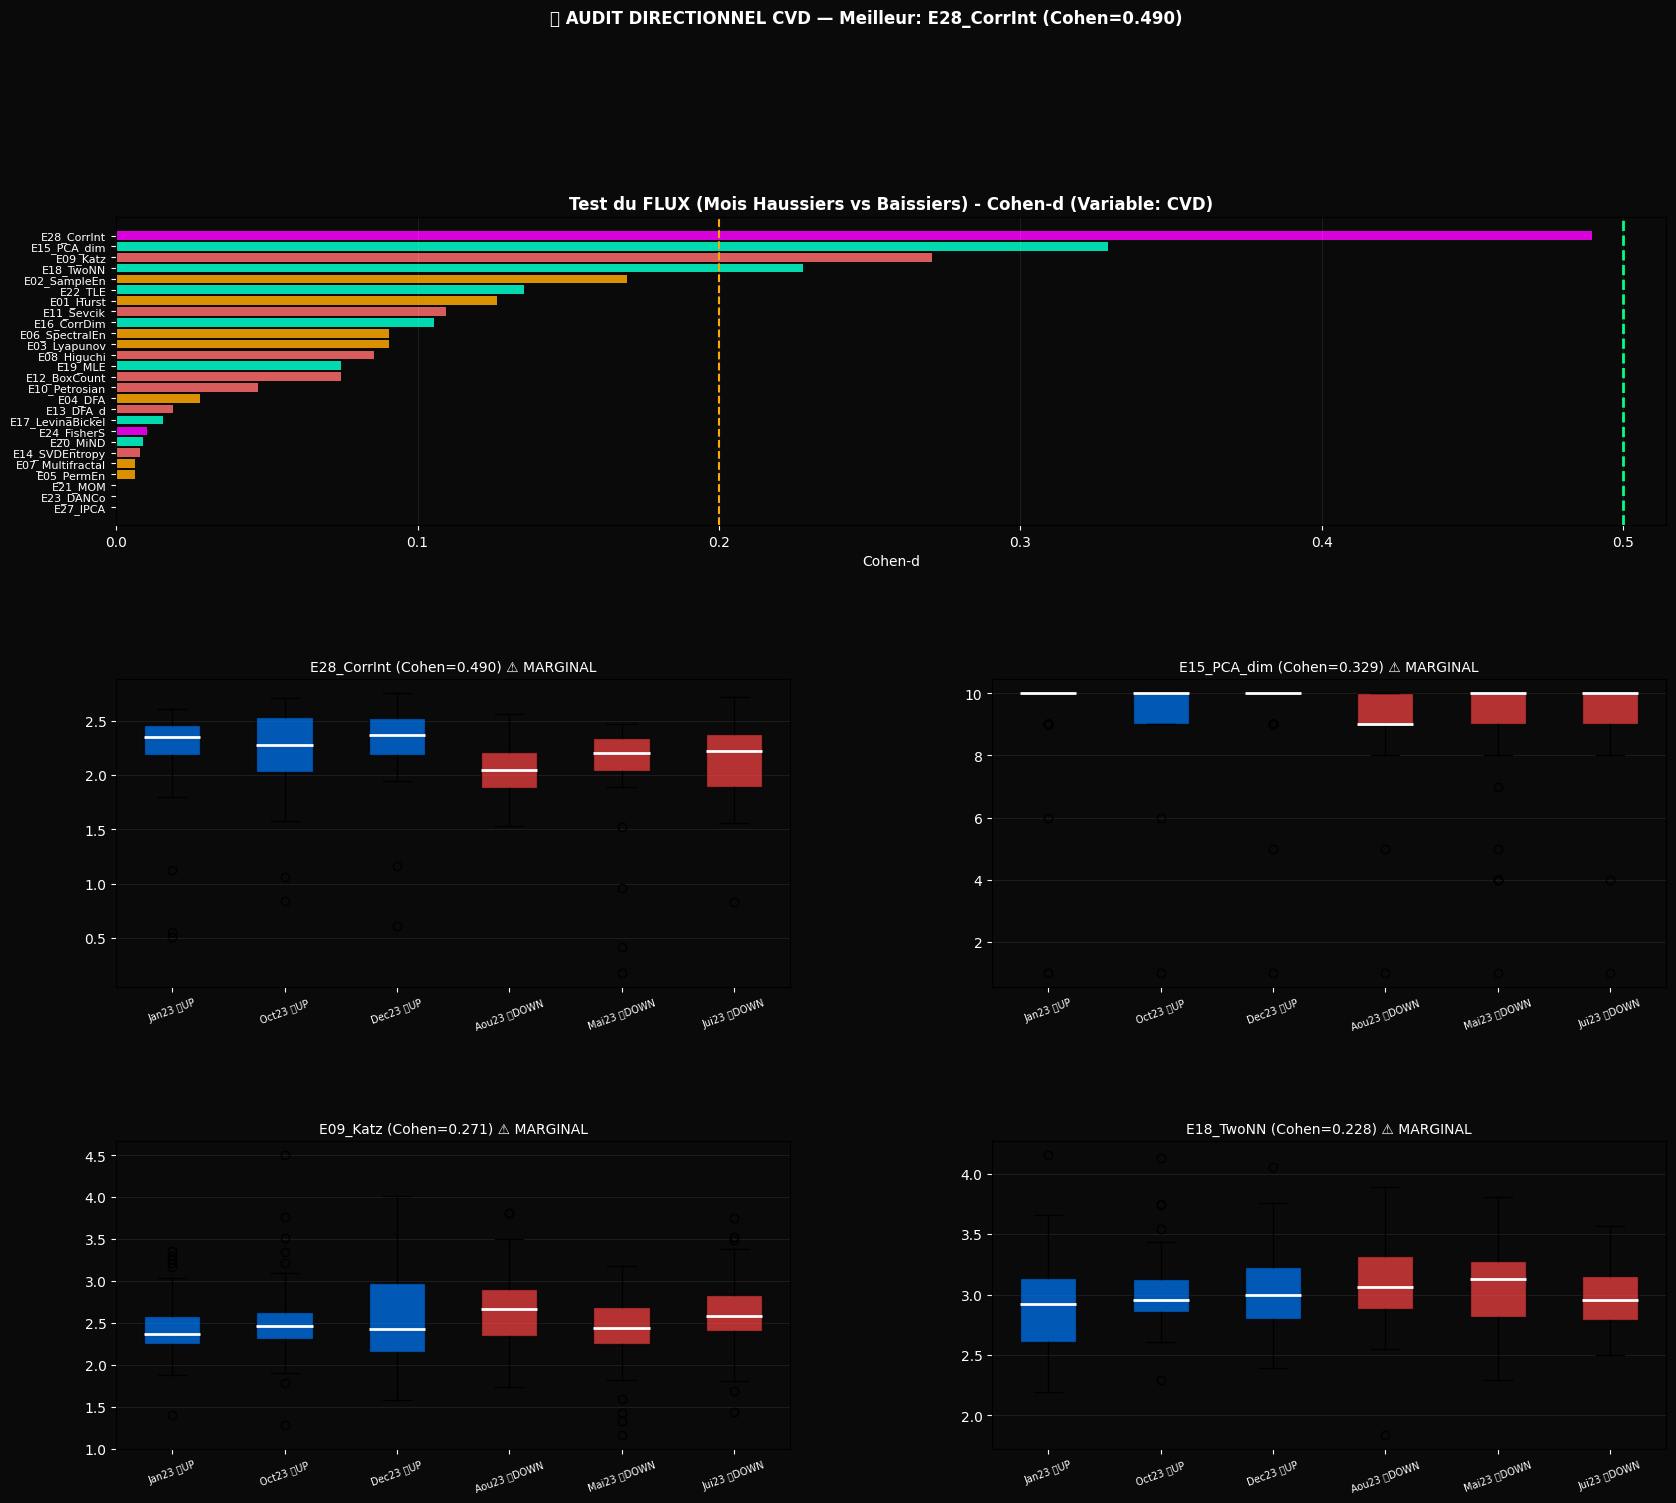

In [ ]:
# ==============================================================================
# 🌊 AUDIT DU FLUX : Le CVD est-il un indicateur Directionnel ?
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy import stats as scipy_stats
from scipy.signal import periodogram
import urllib.request, zipfile, io, os, warnings, time
warnings.filterwarnings('ignore')

import subprocess, sys
for lib, imp in [('antropy','antropy'), ('nolds','nolds'), ('scikit-dimension','skdim')]:
    try:
        __import__(imp)
    except ImportError:
        subprocess.check_call([sys.executable,'-m','pip','install',lib,'-q'],
                              stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
import antropy, nolds, skdim

def download_and_read_zip(url, header_names=None):
    try:
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=15) as response:
            with zipfile.ZipFile(io.BytesIO(response.read())) as z:
                csv_name = z.namelist()[0]
                with z.open(csv_name) as f:
                    if header_names: return pd.read_csv(f, names=header_names, header=0)
                    else: return pd.read_csv(f)
    except Exception: return None

def fetch_multivariate_month(symbol, year, month):
    kline_url = f"https://data.binance.vision/data/futures/um/monthly/klines/{symbol}/1h/{symbol}-1h-{year}-{month:02d}.zip"
    kline_cols = ['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_volume', 'count', 'taker_buy_volume', 'taker_buy_quote_volume', 'ignore']
    df_klines = download_and_read_zip(kline_url, header_names=kline_cols)
    if df_klines is None or df_klines.empty: return None

    df_klines['timestamp'] = pd.to_datetime(df_klines['open_time'], unit='ms')
    df_klines.set_index('timestamp', inplace=True)
    df_klines['buy_vol'] = df_klines['taker_buy_volume']
    df_klines['sell_vol'] = df_klines['volume'] - df_klines['taker_buy_volume']
    df_klines['CVD'] = (df_klines['buy_vol'] - df_klines['sell_vol']).cumsum()

    return df_klines[['close', 'volume', 'CVD']].copy()

def rolling_zscore(series, window=120):
    return (series - series.rolling(window).mean()) / (series.rolling(window).std() + 1e-8)

print("="*70)
print("  🌊 TÉLÉCHARGEMENT DES DONNÉES (TEST DE FLUX CVD) ...")
print("="*70)

# NOUVEAU DATASET : Mois Haussiers (UP) vs Mois Baissiers (DOWN)
MOIS_TEST = {
    'Jan23 📈UP': (2023, 1),    # BTC a fait +40%
    'Oct23 📈UP': (2023, 10),   # BTC a fait +28%
    'Dec23 📈UP': (2023, 12),   # BTC a fait +12%
    'Aou23 📉DOWN': (2023, 8),  # BTC a fait -11% (Gros crash)
    'Mai23 📉DOWN': (2023, 5),  # BTC a fait -7%
    'Jui23 📉DOWN': (2023, 7)   # BTC a fait -4%
}

donnes = {}
for nom, (yr, mo) in MOIS_TEST.items():
    print(f"   📡 {nom}...")
    df = fetch_multivariate_month("BTCUSDT", yr, mo)
    if df is not None:
        donnes[nom] = {
            'cvd': rolling_zscore(pd.Series(np.diff(df['CVD'].values)), window=120).bfill().values
        }
        print(f"   ✅ {nom} ingéré avec succès.")

# ==============================================================================
# 🎯 SÉLECTION : CVD
# ==============================================================================
VARIABLE_TESTEE = 'cvd'

def safe(func, *args, **kwargs):
    try:
        r = func(*args, **kwargs); return float(r) if np.isfinite(float(r)) else np.nan
    except: return np.nan

def build_ps(x, emb=3, delay=1):
    n = len(x) - (emb-1)*delay
    if n < 10: return None
    return np.array([x[i:i+emb*delay:delay] for i in range(n)])

# ── Spectrale ──
def E01_Hurst(x): return safe(nolds.hurst_rs, x)
def E02_SampleEn(x):
    try: return float(antropy.sample_entropy(x[:500], order=2))
    except: return np.nan
def E03_Lyapunov(x):
    try: return float(nolds.lyap_r(x, emb_dim=3))
    except: return np.nan
def E04_DFA(x): return safe(nolds.dfa, x)
def E05_PermEn(x):
    try: return float(antropy.perm_entropy(x, order=5, normalize=True))
    except: return np.nan
def E06_SpectralEn(x):
    try:
        f, psd = periodogram(x, fs=1.0)
        psd = psd[1:]; psd_norm = psd / psd.sum()
        return float(-np.sum(psd_norm * np.log(psd_norm + 1e-12)))
    except: return np.nan
def E07_Multifractal(x):
    try:
        n = len(x); q_vals = np.array([-5,-3,-1,1,3,5]); hs = []
        for q in q_vals:
            scales = np.unique(np.logspace(1, np.log10(n//4), 8).astype(int))
            Fq = []
            for s in scales:
                segs = [x[i:i+s] for i in range(0, n-s, s)]
                if len(segs) < 2: continue
                rms = []
                for seg in segs:
                    fit = np.polyval(np.polyfit(range(len(seg)), seg, 1), range(len(seg)))
                    r = np.sqrt(np.mean((seg-fit)**2))
                    if r > 0: rms.append(r)
                if not rms: continue
                Fq.append(np.mean(np.array(rms)**q)**(1/q))
            if len(Fq) < 3: continue
            h, _ = np.polyfit(np.log(scales[:len(Fq)]), np.log(Fq), 1)
            hs.append(h)
        return float(np.max(hs) - np.min(hs)) if len(hs) >= 3 else np.nan
    except: return np.nan

# ── Saturation ──
def E08_Higuchi(x): return safe(antropy.higuchi_fd, x)
def E09_Katz(x): return safe(antropy.katz_fd, x)
def E10_Petrosian(x): return safe(antropy.petrosian_fd, x)
def E11_Sevcik(x):
    try:
        n = len(x); xn = (x - x.min()) / (x.max() - x.min() + 1e-12)
        tn = np.linspace(0, 1, n)
        L = np.sum(np.sqrt(np.diff(xn)**2 + np.diff(tn)**2))
        return float(1 + np.log(L) / np.log(2*(n-1)))
    except: return np.nan
def E12_BoxCount(x):
    try:
        xn = (x - x.min()) / (x.max() - x.min() + 1e-12)
        scales = [4,8,16,32,64,128]; counts = []
        for s in scales:
            if s >= len(x): continue
            hist, _ = np.histogram(xn, bins=np.linspace(0,1,s+1))
            counts.append(np.sum(hist > 0))
        if len(counts) < 3: return np.nan
        return float(-np.polyfit(np.log(scales[:len(counts)]), np.log(counts), 1)[0])
    except: return np.nan
def E13_DFA_d(x):
    h = safe(nolds.dfa, x); return float(2 - h) if not np.isnan(h) else np.nan
def E14_SVDEntropy(x):
    try: return float(antropy.svd_entropy(x, order=5, delay=1, normalize=True))
    except: return np.nan

# ── Transition ──
def E15_PCA_dim(x):
    try:
        X = build_ps(x, emb=10)
        if X is None: return np.nan
        pca = PCA().fit(X); cumvar = np.cumsum(pca.explained_variance_ratio_)
        return float(np.searchsorted(cumvar, 0.95) + 1)
    except: return np.nan
def E16_CorrDim(x):
    try: return float(nolds.corr_dim(x, emb_dim=3))
    except: return np.nan
def E17_LevinaBickel(x, k=10):
    try:
        X = build_ps(x, emb=3)
        if X is None or len(X) < k+2: return np.nan
        nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='brute').fit(X)
        d = np.maximum(nbrs.kneighbors(X)[0][:,1:], 1e-12)
        m = (k-1) / np.sum(np.log(d[:,-1:]/d[:,:-1]), axis=1); m = m[np.isfinite(m)]
        return float(np.median(m)) if len(m) > 0 else np.nan
    except: return np.nan
def E18_TwoNN(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.TwoNN().fit(X).dimension_) if X is not None and len(X) >= 5 else np.nan
    except: return np.nan
def E19_MLE(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.MLE().fit(X).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan
def E20_MiND(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.MiND_ML().fit(X).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan
def E21_MOM(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.MOM().fit(X).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan
def E22_TLE(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.TLE().fit(X).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan

# ── Divergence ──
def E23_DANCo(x):
    try:
        X = build_ps(x, emb=5); return float(skdim.id.DANCo().fit(X[:200]).dimension_) if X is not None and len(X) >= 20 else np.nan
    except: return np.nan
def E24_FisherS(x):
    try:
        X = build_ps(x, emb=5); return float(skdim.id.FisherS().fit(X[:200]).dimension_) if X is not None and len(X) >= 20 else np.nan
    except: return np.nan
def E26_GeoMle(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.GeoMle().fit(X[:300]).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan
def E27_lPCA(x):
    try:
        X = build_ps(x, emb=5); return float(skdim.id.lPCA().fit(X[:300]).dimension_) if X is not None and len(X) >= 20 else np.nan
    except: return np.nan
def E28_CorrInt(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.CorrInt().fit(X[:300]).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan

ESTIMATEURS = {
    'E01_Hurst': ('Spectrale', E01_Hurst), 'E02_SampleEn': ('Spectrale', E02_SampleEn), 'E03_Lyapunov': ('Spectrale', E03_Lyapunov),
    'E04_DFA': ('Spectrale', E04_DFA), 'E05_PermEn': ('Spectrale', E05_PermEn), 'E06_SpectralEn': ('Spectrale', E06_SpectralEn), 'E07_Multifractal': ('Spectrale', E07_Multifractal),
    'E08_Higuchi': ('Saturation', E08_Higuchi), 'E09_Katz': ('Saturation', E09_Katz), 'E10_Petrosian': ('Saturation', E10_Petrosian),
    'E11_Sevcik': ('Saturation', E11_Sevcik), 'E12_BoxCount': ('Saturation', E12_BoxCount), 'E13_DFA_d': ('Saturation', E13_DFA_d), 'E14_SVDEntropy': ('Saturation', E14_SVDEntropy),
    'E15_PCA_dim': ('Transition', E15_PCA_dim), 'E16_CorrDim': ('Transition', E16_CorrDim), 'E17_LevinaBickel': ('Transition', E17_LevinaBickel),
    'E18_TwoNN': ('Transition', E18_TwoNN), 'E19_MLE': ('Transition', E19_MLE), 'E20_MiND': ('Transition', E20_MiND),
    'E21_MOM': ('Transition', E21_MOM), 'E22_TLE': ('Transition', E22_TLE), 'E23_DANCo': ('Divergence', E23_DANCo),
    'E24_FisherS': ('Divergence', E24_FisherS), 'E26_GeoMle': ('Divergence', E26_GeoMle), 'E27_lPCA': ('Divergence', E27_lPCA), 'E28_CorrInt': ('Divergence', E28_CorrInt)
}

# ==============================================================================
# 🚀 CALCUL
# ==============================================================================
WINDOW, STRIDE = 120, 12
resultats = {}

for nom_est, (classe, func) in ESTIMATEURS.items():
    t0 = time.time()
    vals_par_mois = {}
    for nom_mois, data in donnes.items():
        signal = data[VARIABLE_TESTEE]
        vals = []
        for i in range(WINDOW, len(signal), STRIDE):
            v = func(signal[i-WINDOW:i])
            if isinstance(v, float) and np.isfinite(v): vals.append(v)
        vals_par_mois[nom_mois] = vals

    elapsed = time.time() - t0
    total = sum(len(v) for v in vals_par_mois.values())
    if total == 0:
        print(f"  {nom_est:<22} ({classe:<12}) ❌ ÉCHEC [{elapsed:.1f}s]"); continue

    resultats[nom_est] = {'classe': classe, 'vals': vals_par_mois}
    # On compare maintenant UP (📈) vs DOWN (📉)
    bons = [v for nm,vs in vals_par_mois.items() if 'UP' in nm for v in vs]
    mauvais = [v for nm,vs in vals_par_mois.items() if 'DOWN' in nm for v in vs]

    if bons and mauvais:
        cd = abs(np.median(bons)-np.median(mauvais)) / (np.std(bons+mauvais)+1e-12)
        sig = "✅" if cd > 0.3 else ("⚠️" if cd > 0.1 else "❌")
        print(f"  {nom_est:<22} ({classe:<12}) d̄={np.median(bons+mauvais):6.3f} Cohen={cd:.3f} {sig} [{elapsed:.1f}s]")

# ==============================================================================
# 📊 CLASSEMENT ET GRAPHIQUES
# ==============================================================================
analyse = []
for nom_est, data in resultats.items():
    bons = [v for nm,vs in data['vals'].items() if 'UP' in nm for v in vs]
    mauvais = [v for nm,vs in data['vals'].items() if 'DOWN' in nm for v in vs]
    if not bons or not mauvais: continue
    mb, mm = np.median(bons), np.median(mauvais)
    cohen  = abs(mb-mm) / (np.std(bons+mauvais)+1e-12)
    pval   = scipy_stats.mannwhitneyu(bons,mauvais,alternative='two-sided').pvalue if len(bons)>5 and len(mauvais)>5 else 1.0
    signal = "✅ FORT" if cohen>0.5 and pval<0.05 else ("⚠️ MARGINAL" if cohen>0.2 else "❌ BRUIT")
    analyse.append({'nom':nom_est,'classe':data['classe'],'mb':mb,'mm':mm,'cohen':cohen,'pval':pval,'signal':signal})

analyse_sorted = sorted(analyse, key=lambda x: x['cohen'], reverse=True)
print("\n" + "="*70)
print(f"  🏁 TEST DE FLUX DIRECTIONNEL SUR LA VARIABLE : {VARIABLE_TESTEE.upper()}")
print("="*70)
for i,a in enumerate(analyse_sorted):
    print(f"  {i+1:<2} {a['nom']:<20} {a['classe']:<12} d_UP={a['mb']:>6.3f} d_DOWN={a['mm']:>6.3f} Cohen={a['cohen']:>5.3f} {a['signal']}")

fig = plt.figure(figsize=(20, 16)); fig.patch.set_facecolor('#0a0a0a')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.3)
CMAP = {'Spectrale':'#ffaa00','Saturation':'#ff6b6b','Transition':'#00ffcc','Divergence':'#ff00ff'}

ax1 = fig.add_subplot(gs[0,:]); ax1.set_facecolor('#0a0a0a')
ax1.set_title(f"Test du FLUX (Mois Haussiers vs Baissiers) - Cohen-d (Variable: {VARIABLE_TESTEE.upper()})", color='white', fontsize=12, fontweight='bold')
noms_plot = [a['nom'] for a in analyse_sorted]; cohens_plot = [a['cohen'] for a in analyse_sorted]
clrs_plot = [CMAP.get(a['classe'],'#fff') for a in analyse_sorted]
ax1.barh(range(len(noms_plot)), cohens_plot[::-1], color=list(reversed(clrs_plot)), alpha=0.85)
ax1.axvline(x=0.5, color='#00ff88', linestyle='--', linewidth=2)
ax1.axvline(x=0.2, color='#ffaa00', linestyle='--', linewidth=1.5)
ax1.set_yticks(range(len(noms_plot))); ax1.set_yticklabels(list(reversed(noms_plot)), color='white', fontsize=8)
ax1.set_xlabel("Cohen-d", color='white'); ax1.tick_params(colors='white'); ax1.grid(color='white', alpha=0.08, axis='x')

top4 = analyse_sorted[:4]
for idx, a in enumerate(top4):
    ax = fig.add_subplot(gs[1 + idx//2, idx%2]); ax.set_facecolor('#0a0a0a')
    ax.set_title(f"{a['nom']} (Cohen={a['cohen']:.3f}) {a['signal']}", color='white', fontsize=10)
    noms_mois = list(donnes.keys()); bp_data = [resultats[a['nom']]['vals'].get(nm,[np.nan]) for nm in noms_mois]

    # Bleu pour UP, Rouge pour DOWN
    clrs_box = ['#007BFF' if 'UP' in nm else '#ff4444' for nm in noms_mois]

    bp = ax.boxplot(bp_data, patch_artist=True, medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], clrs_box): patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticklabels(noms_mois, color='white', fontsize=7, rotation=20); ax.tick_params(colors='white')
    ax.grid(color='white', alpha=0.08, axis='y')

plt.suptitle(f"🌊 AUDIT DIRECTIONNEL CVD — Meilleur: {analyse_sorted[0]['nom']} (Cohen={analyse_sorted[0]['cohen']:.3f})", color='white', fontsize=12, y=1.01, fontweight='bold')
plt.savefig(f"audit_directionnel_{VARIABLE_TESTEE}.png", dpi=120, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

  🗜️ TÉLÉCHARGEMENT DES DONNÉES (TEST DE TENSION OI) ...
   📡 Jan23 💥PURGE...
   ✅ Jan23 💥PURGE ingéré (Shape: 743 heures)
   📡 Oct23 💥PURGE...
   ✅ Oct23 💥PURGE ingéré (Shape: 743 heures)
   📡 Aou23 💥PURGE...
   ✅ Aou23 💥PURGE ingéré (Shape: 743 heures)
   📡 Mai23 🗜️TENSION...
   ✅ Mai23 🗜️TENSION ingéré (Shape: 743 heures)
   📡 Jui23 🗜️TENSION...
   ✅ Jui23 🗜️TENSION ingéré (Shape: 743 heures)
   📡 Sep23 🗜️TENSION...
   ✅ Sep23 🗜️TENSION ingéré (Shape: 719 heures)
  E01_Hurst              (Spectrale   ) d̄= 0.620 Cohen=0.050 ❌ [5.4s]
  E02_SampleEn           (Spectrale   ) d̄= 1.289 Cohen=0.138 ⚠️ [0.0s]
  E03_Lyapunov           (Spectrale   ) d̄= 0.004 Cohen=0.016 ❌ [6.5s]
  E04_DFA                (Spectrale   ) d̄= 0.784 Cohen=0.041 ❌ [7.3s]
  E05_PermEn             (Spectrale   ) d̄= 0.859 Cohen=0.018 ❌ [0.0s]
  E06_SpectralEn         (Spectrale   ) d̄= 3.611 Cohen=0.079 ❌ [0.1s]
  E07_Multifractal       (Spectrale   ) d̄= 0.675 Cohen=0.012 ❌ [12.1s]
  E08_Higuchi            (Satu

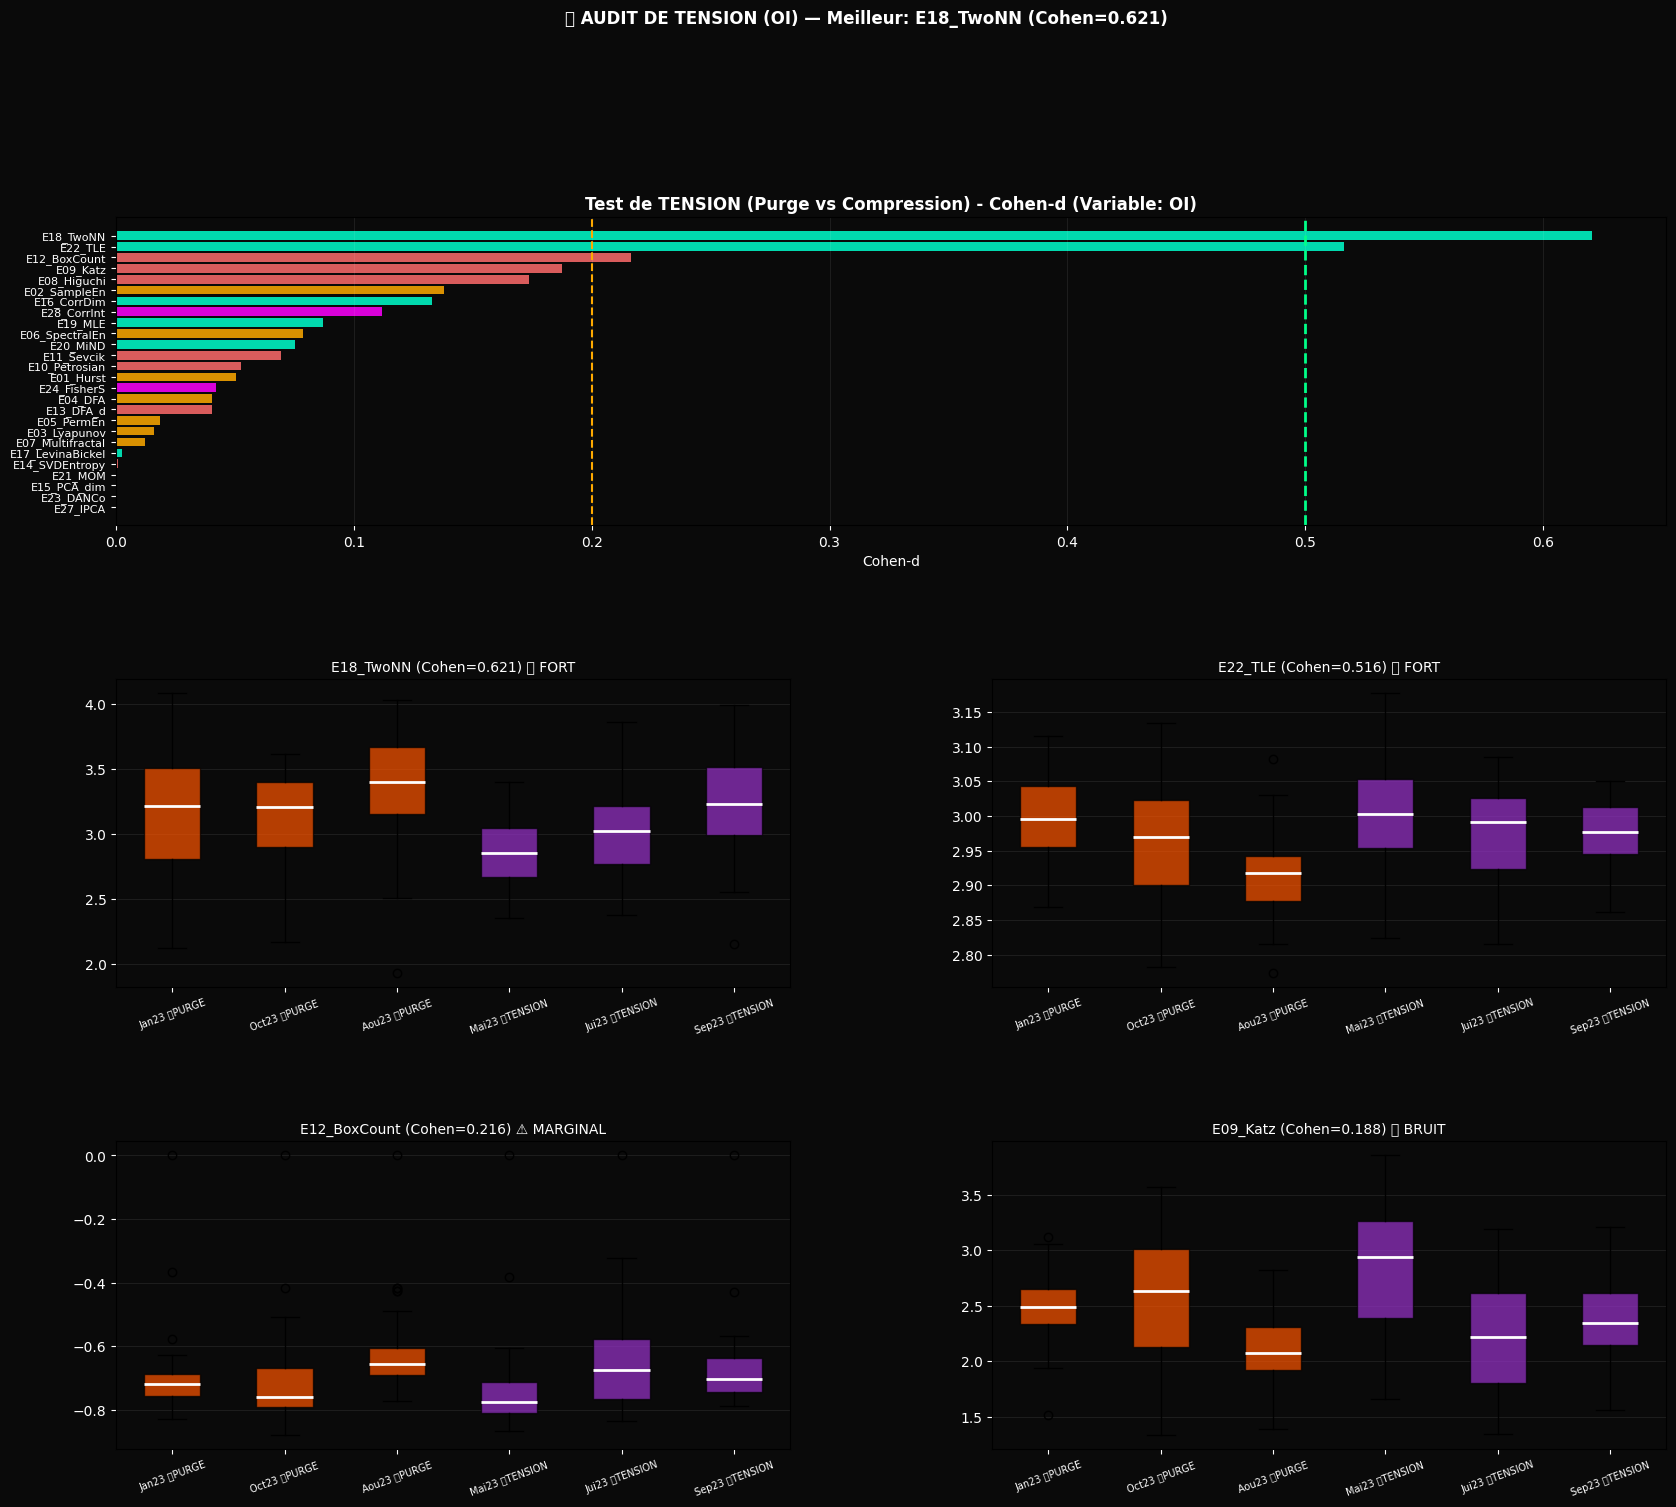

In [ ]:
# ==============================================================================
# 🗜️ AUDIT DE TENSION : L'Open Interest détecte-t-il la Compression vs Purge ?
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy import stats as scipy_stats
from scipy.signal import periodogram
import urllib.request, zipfile, io, os, warnings, time
warnings.filterwarnings('ignore')

import subprocess, sys
for lib, imp in [('antropy','antropy'), ('nolds','nolds'), ('scikit-dimension','skdim')]:
    try: __import__(imp)
    except ImportError: subprocess.check_call([sys.executable,'-m','pip','install',lib,'-q'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
import antropy, nolds, skdim

def download_and_read_zip(url, header_names=None):
    try:
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=15) as response:
            with zipfile.ZipFile(io.BytesIO(response.read())) as z:
                csv_name = z.namelist()[0]
                with z.open(csv_name) as f:
                    if header_names: return pd.read_csv(f, names=header_names, header=0)
                    else: return pd.read_csv(f)
    except Exception: return None

def fetch_oi_metrics_month(symbol, year, month):
    num_days = pd.Period(f'{year}-{month:02d}').days_in_month
    oi_list = []

    # NOUVEAU FIX : Utilisation du endpoint 'metrics' qui contient des datas très haute fréquence
    for day in range(1, num_days + 1):
        date_str = f"{year}-{month:02d}-{day:02d}"
        metrics_url = f"https://data.binance.vision/data/futures/um/daily/metrics/{symbol}/{symbol}-metrics-{date_str}.zip"
        df_metrics = download_and_read_zip(metrics_url)

        if df_metrics is not None and not df_metrics.empty:
            df_metrics['timestamp'] = pd.to_datetime(df_metrics['create_time'], format='ISO8601')
            df_metrics.set_index('timestamp', inplace=True)
            # On prend la moyenne de l'OI sur l'heure pour lisser le bruit
            oi_list.append(df_metrics[['sum_open_interest_value']].resample('1H').mean().ffill())

    if not oi_list: return None
    df_oi = pd.concat(oi_list)
    df_oi.rename(columns={'sum_open_interest_value': 'Open_Interest'}, inplace=True)
    return df_oi

def rolling_zscore(series, window=120):
    return (series - series.rolling(window).mean()) / (series.rolling(window).std() + 1e-8)

print("="*70)
print("  🗜️ TÉLÉCHARGEMENT DES DONNÉES (TEST DE TENSION OI) ...")
print("="*70)

# NOUVEAU DATASET : Mois d'Explosion/Purge vs Mois de Compression/Tension
MOIS_TEST = {
    'Jan23 💥PURGE': (2023, 1),    # Squeeze
    'Oct23 💥PURGE': (2023, 10),   # Breakout
    'Aou23 💥PURGE': (2023, 8),    # Crash
    'Mai23 🗜️TENSION': (2023, 5),  # Range serré
    'Jui23 🗜️TENSION': (2023, 7),  # Range serré
    'Sep23 🗜️TENSION': (2023, 9)   # Range serré pré-breakout
}

donnes = {}
for nom, (yr, mo) in MOIS_TEST.items():
    print(f"   📡 {nom}...")
    df_oi = fetch_oi_metrics_month("BTCUSDT", yr, mo)
    if df_oi is not None and not df_oi.empty:
        # On calcule le delta (variation horaire de l'OI) et on le standardise
        oi_delta = pd.Series(np.diff(df_oi['Open_Interest'].values))
        donnes[nom] = {'oi': rolling_zscore(oi_delta, window=120).bfill().values}
        print(f"   ✅ {nom} ingéré (Shape: {len(donnes[nom]['oi'])} heures)")
    else:
        print(f"   ❌ {nom} échoué.")

# ==============================================================================
# 🎯 SÉLECTION : OI
# ==============================================================================
VARIABLE_TESTEE = 'oi'

def safe(func, *args, **kwargs):
    try:
        r = func(*args, **kwargs); return float(r) if np.isfinite(float(r)) else np.nan
    except: return np.nan

def build_ps(x, emb=3, delay=1):
    n = len(x) - (emb-1)*delay
    if n < 10: return None
    return np.array([x[i:i+emb*delay:delay] for i in range(n)])

# ── Spectrale ──
def E01_Hurst(x): return safe(nolds.hurst_rs, x)
def E02_SampleEn(x):
    try: return float(antropy.sample_entropy(x[:500], order=2))
    except: return np.nan
def E03_Lyapunov(x):
    try: return float(nolds.lyap_r(x, emb_dim=3))
    except: return np.nan
def E04_DFA(x): return safe(nolds.dfa, x)
def E05_PermEn(x):
    try: return float(antropy.perm_entropy(x, order=5, normalize=True))
    except: return np.nan
def E06_SpectralEn(x):
    try:
        f, psd = periodogram(x, fs=1.0)
        psd = psd[1:]; psd_norm = psd / psd.sum()
        return float(-np.sum(psd_norm * np.log(psd_norm + 1e-12)))
    except: return np.nan
def E07_Multifractal(x):
    try:
        n = len(x); q_vals = np.array([-5,-3,-1,1,3,5]); hs = []
        for q in q_vals:
            scales = np.unique(np.logspace(1, np.log10(n//4), 8).astype(int))
            Fq = []
            for s in scales:
                segs = [x[i:i+s] for i in range(0, n-s, s)]
                if len(segs) < 2: continue
                rms = []
                for seg in segs:
                    fit = np.polyval(np.polyfit(range(len(seg)), seg, 1), range(len(seg)))
                    r = np.sqrt(np.mean((seg-fit)**2))
                    if r > 0: rms.append(r)
                if not rms: continue
                Fq.append(np.mean(np.array(rms)**q)**(1/q))
            if len(Fq) < 3: continue
            h, _ = np.polyfit(np.log(scales[:len(Fq)]), np.log(Fq), 1)
            hs.append(h)
        return float(np.max(hs) - np.min(hs)) if len(hs) >= 3 else np.nan
    except: return np.nan

# ── Saturation ──
def E08_Higuchi(x): return safe(antropy.higuchi_fd, x)
def E09_Katz(x): return safe(antropy.katz_fd, x)
def E10_Petrosian(x): return safe(antropy.petrosian_fd, x)
def E11_Sevcik(x):
    try:
        n = len(x); xn = (x - x.min()) / (x.max() - x.min() + 1e-12)
        tn = np.linspace(0, 1, n)
        L = np.sum(np.sqrt(np.diff(xn)**2 + np.diff(tn)**2))
        return float(1 + np.log(L) / np.log(2*(n-1)))
    except: return np.nan
def E12_BoxCount(x):
    try:
        xn = (x - x.min()) / (x.max() - x.min() + 1e-12)
        scales = [4,8,16,32,64,128]; counts = []
        for s in scales:
            if s >= len(x): continue
            hist, _ = np.histogram(xn, bins=np.linspace(0,1,s+1))
            counts.append(np.sum(hist > 0))
        if len(counts) < 3: return np.nan
        return float(-np.polyfit(np.log(scales[:len(counts)]), np.log(counts), 1)[0])
    except: return np.nan
def E13_DFA_d(x):
    h = safe(nolds.dfa, x); return float(2 - h) if not np.isnan(h) else np.nan
def E14_SVDEntropy(x):
    try: return float(antropy.svd_entropy(x, order=5, delay=1, normalize=True))
    except: return np.nan

# ── Transition ──
def E15_PCA_dim(x):
    try:
        X = build_ps(x, emb=10)
        if X is None: return np.nan
        pca = PCA().fit(X); cumvar = np.cumsum(pca.explained_variance_ratio_)
        return float(np.searchsorted(cumvar, 0.95) + 1)
    except: return np.nan
def E16_CorrDim(x):
    try: return float(nolds.corr_dim(x, emb_dim=3))
    except: return np.nan
def E17_LevinaBickel(x, k=10):
    try:
        X = build_ps(x, emb=3)
        if X is None or len(X) < k+2: return np.nan
        nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='brute').fit(X)
        d = np.maximum(nbrs.kneighbors(X)[0][:,1:], 1e-12)
        m = (k-1) / np.sum(np.log(d[:,-1:]/d[:,:-1]), axis=1); m = m[np.isfinite(m)]
        return float(np.median(m)) if len(m) > 0 else np.nan
    except: return np.nan
def E18_TwoNN(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.TwoNN().fit(X).dimension_) if X is not None and len(X) >= 5 else np.nan
    except: return np.nan
def E19_MLE(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.MLE().fit(X).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan
def E20_MiND(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.MiND_ML().fit(X).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan
def E21_MOM(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.MOM().fit(X).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan
def E22_TLE(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.TLE().fit(X).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan

# ── Divergence ──
def E23_DANCo(x):
    try:
        X = build_ps(x, emb=5); return float(skdim.id.DANCo().fit(X[:200]).dimension_) if X is not None and len(X) >= 20 else np.nan
    except: return np.nan
def E24_FisherS(x):
    try:
        X = build_ps(x, emb=5); return float(skdim.id.FisherS().fit(X[:200]).dimension_) if X is not None and len(X) >= 20 else np.nan
    except: return np.nan
def E26_GeoMle(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.GeoMle().fit(X[:300]).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan
def E27_lPCA(x):
    try:
        X = build_ps(x, emb=5); return float(skdim.id.lPCA().fit(X[:300]).dimension_) if X is not None and len(X) >= 20 else np.nan
    except: return np.nan
def E28_CorrInt(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.CorrInt().fit(X[:300]).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan

ESTIMATEURS = {
    'E01_Hurst': ('Spectrale', E01_Hurst), 'E02_SampleEn': ('Spectrale', E02_SampleEn), 'E03_Lyapunov': ('Spectrale', E03_Lyapunov),
    'E04_DFA': ('Spectrale', E04_DFA), 'E05_PermEn': ('Spectrale', E05_PermEn), 'E06_SpectralEn': ('Spectrale', E06_SpectralEn), 'E07_Multifractal': ('Spectrale', E07_Multifractal),
    'E08_Higuchi': ('Saturation', E08_Higuchi), 'E09_Katz': ('Saturation', E09_Katz), 'E10_Petrosian': ('Saturation', E10_Petrosian),
    'E11_Sevcik': ('Saturation', E11_Sevcik), 'E12_BoxCount': ('Saturation', E12_BoxCount), 'E13_DFA_d': ('Saturation', E13_DFA_d), 'E14_SVDEntropy': ('Saturation', E14_SVDEntropy),
    'E15_PCA_dim': ('Transition', E15_PCA_dim), 'E16_CorrDim': ('Transition', E16_CorrDim), 'E17_LevinaBickel': ('Transition', E17_LevinaBickel),
    'E18_TwoNN': ('Transition', E18_TwoNN), 'E19_MLE': ('Transition', E19_MLE), 'E20_MiND': ('Transition', E20_MiND),
    'E21_MOM': ('Transition', E21_MOM), 'E22_TLE': ('Transition', E22_TLE), 'E23_DANCo': ('Divergence', E23_DANCo),
    'E24_FisherS': ('Divergence', E24_FisherS), 'E26_GeoMle': ('Divergence', E26_GeoMle), 'E27_lPCA': ('Divergence', E27_lPCA), 'E28_CorrInt': ('Divergence', E28_CorrInt)
}

# ==============================================================================
# 🚀 CALCUL
# ==============================================================================
WINDOW, STRIDE = 120, 12
resultats = {}

for nom_est, (classe, func) in ESTIMATEURS.items():
    t0 = time.time()
    vals_par_mois = {}
    for nom_mois, data in donnes.items():
        signal = data[VARIABLE_TESTEE]
        vals = []
        for i in range(WINDOW, len(signal), STRIDE):
            v = func(signal[i-WINDOW:i])
            if isinstance(v, float) and np.isfinite(v): vals.append(v)
        vals_par_mois[nom_mois] = vals

    elapsed = time.time() - t0
    total = sum(len(v) for v in vals_par_mois.values())
    if total == 0:
        print(f"  {nom_est:<22} ({classe:<12}) ❌ ÉCHEC [{elapsed:.1f}s]"); continue

    resultats[nom_est] = {'classe': classe, 'vals': vals_par_mois}

    # NOUVELLE VÉRIFICATION : PURGE (💥) vs TENSION (🗜️)
    bons = [v for nm,vs in vals_par_mois.items() if 'PURGE' in nm for v in vs]
    mauvais = [v for nm,vs in vals_par_mois.items() if 'TENSION' in nm for v in vs]

    if bons and mauvais:
        cd = abs(np.median(bons)-np.median(mauvais)) / (np.std(bons+mauvais)+1e-12)
        sig = "✅" if cd > 0.3 else ("⚠️" if cd > 0.1 else "❌")
        print(f"  {nom_est:<22} ({classe:<12}) d̄={np.median(bons+mauvais):6.3f} Cohen={cd:.3f} {sig} [{elapsed:.1f}s]")

# ==============================================================================
# 📊 CLASSEMENT ET GRAPHIQUES
# ==============================================================================
analyse = []
for nom_est, data in resultats.items():
    bons = [v for nm,vs in data['vals'].items() if 'PURGE' in nm for v in vs]
    mauvais = [v for nm,vs in data['vals'].items() if 'TENSION' in nm for v in vs]
    if not bons or not mauvais: continue
    mb, mm = np.median(bons), np.median(mauvais)
    cohen  = abs(mb-mm) / (np.std(bons+mauvais)+1e-12)
    pval   = scipy_stats.mannwhitneyu(bons,mauvais,alternative='two-sided').pvalue if len(bons)>5 and len(mauvais)>5 else 1.0
    signal = "✅ FORT" if cohen>0.5 and pval<0.05 else ("⚠️ MARGINAL" if cohen>0.2 else "❌ BRUIT")
    analyse.append({'nom':nom_est,'classe':data['classe'],'mb':mb,'mm':mm,'cohen':cohen,'pval':pval,'signal':signal})

analyse_sorted = sorted(analyse, key=lambda x: x['cohen'], reverse=True)
print("\n" + "="*70)
print(f"  🏁 TEST D'ÉNERGIE POTENTIELLE SUR LA VARIABLE : {VARIABLE_TESTEE.upper()}")
print("="*70)
for i,a in enumerate(analyse_sorted):
    print(f"  {i+1:<2} {a['nom']:<20} {a['classe']:<12} d_PURGE={a['mb']:>6.3f} d_TENSION={a['mm']:>6.3f} Cohen={a['cohen']:>5.3f} {a['signal']}")

fig = plt.figure(figsize=(20, 16)); fig.patch.set_facecolor('#0a0a0a')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.3)
CMAP = {'Spectrale':'#ffaa00','Saturation':'#ff6b6b','Transition':'#00ffcc','Divergence':'#ff00ff'}

ax1 = fig.add_subplot(gs[0,:]); ax1.set_facecolor('#0a0a0a')
ax1.set_title(f"Test de TENSION (Purge vs Compression) - Cohen-d (Variable: {VARIABLE_TESTEE.upper()})", color='white', fontsize=12, fontweight='bold')
noms_plot = [a['nom'] for a in analyse_sorted]; cohens_plot = [a['cohen'] for a in analyse_sorted]
clrs_plot = [CMAP.get(a['classe'],'#fff') for a in analyse_sorted]
ax1.barh(range(len(noms_plot)), cohens_plot[::-1], color=list(reversed(clrs_plot)), alpha=0.85)
ax1.axvline(x=0.5, color='#00ff88', linestyle='--', linewidth=2)
ax1.axvline(x=0.2, color='#ffaa00', linestyle='--', linewidth=1.5)
ax1.set_yticks(range(len(noms_plot))); ax1.set_yticklabels(list(reversed(noms_plot)), color='white', fontsize=8)
ax1.set_xlabel("Cohen-d", color='white'); ax1.tick_params(colors='white'); ax1.grid(color='white', alpha=0.08, axis='x')

top4 = analyse_sorted[:4]
for idx, a in enumerate(top4):
    ax = fig.add_subplot(gs[1 + idx//2, idx%2]); ax.set_facecolor('#0a0a0a')
    ax.set_title(f"{a['nom']} (Cohen={a['cohen']:.3f}) {a['signal']}", color='white', fontsize=10)
    noms_mois = list(donnes.keys()); bp_data = [resultats[a['nom']]['vals'].get(nm,[np.nan]) for nm in noms_mois]

    # Orange Fluo pour PURGE, Violet pour TENSION
    clrs_box = ['#ff5500' if 'PURGE' in nm else '#9932CC' for nm in noms_mois]

    bp = ax.boxplot(bp_data, patch_artist=True, medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], clrs_box): patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticklabels(noms_mois, color='white', fontsize=7, rotation=20); ax.tick_params(colors='white')
    ax.grid(color='white', alpha=0.08, axis='y')

plt.suptitle(f"🗜️ AUDIT DE TENSION (OI) — Meilleur: {analyse_sorted[0]['nom']} (Cohen={analyse_sorted[0]['cohen']:.3f})", color='white', fontsize=12, y=1.01, fontweight='bold')
plt.savefig(f"audit_tension_{VARIABLE_TESTEE}.png", dpi=120, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

  ⚡ TÉLÉCHARGEMENT DES DONNÉES (TEST CINÉTIQUE VOLUME) ...
   📡 Jan23 💥EXPLOSION...
   ✅ Jan23 💥EXPLOSION ingéré avec succès.
   📡 Oct23 💥EXPLOSION...
   ✅ Oct23 💥EXPLOSION ingéré avec succès.
   📡 Aou23 💥EXPLOSION...
   ✅ Aou23 💥EXPLOSION ingéré avec succès.
   📡 Mai23 💤APATHIE...
   ✅ Mai23 💤APATHIE ingéré avec succès.
   📡 Jui23 💤APATHIE...
   ✅ Jui23 💤APATHIE ingéré avec succès.
   📡 Sep23 💤APATHIE...
   ✅ Sep23 💤APATHIE ingéré avec succès.
  E01_Hurst              (Spectrale   ) d̄= 0.697 Cohen=0.032 ❌ [3.7s]
  E02_SampleEn           (Spectrale   ) d̄= 0.694 Cohen=0.402 ✅ [0.0s]
  E03_Lyapunov           (Spectrale   ) d̄= 0.009 Cohen=0.206 ⚠️ [7.6s]
  E04_DFA                (Spectrale   ) d̄= 0.960 Cohen=0.118 ⚠️ [6.5s]
  E05_PermEn             (Spectrale   ) d̄= 0.845 Cohen=0.023 ❌ [0.0s]
  E06_SpectralEn         (Spectrale   ) d̄= 3.328 Cohen=0.403 ✅ [0.1s]
  E07_Multifractal       (Spectrale   ) d̄= 0.965 Cohen=0.016 ❌ [13.4s]
  E08_Higuchi            (Saturation  ) d̄= 1.801 C

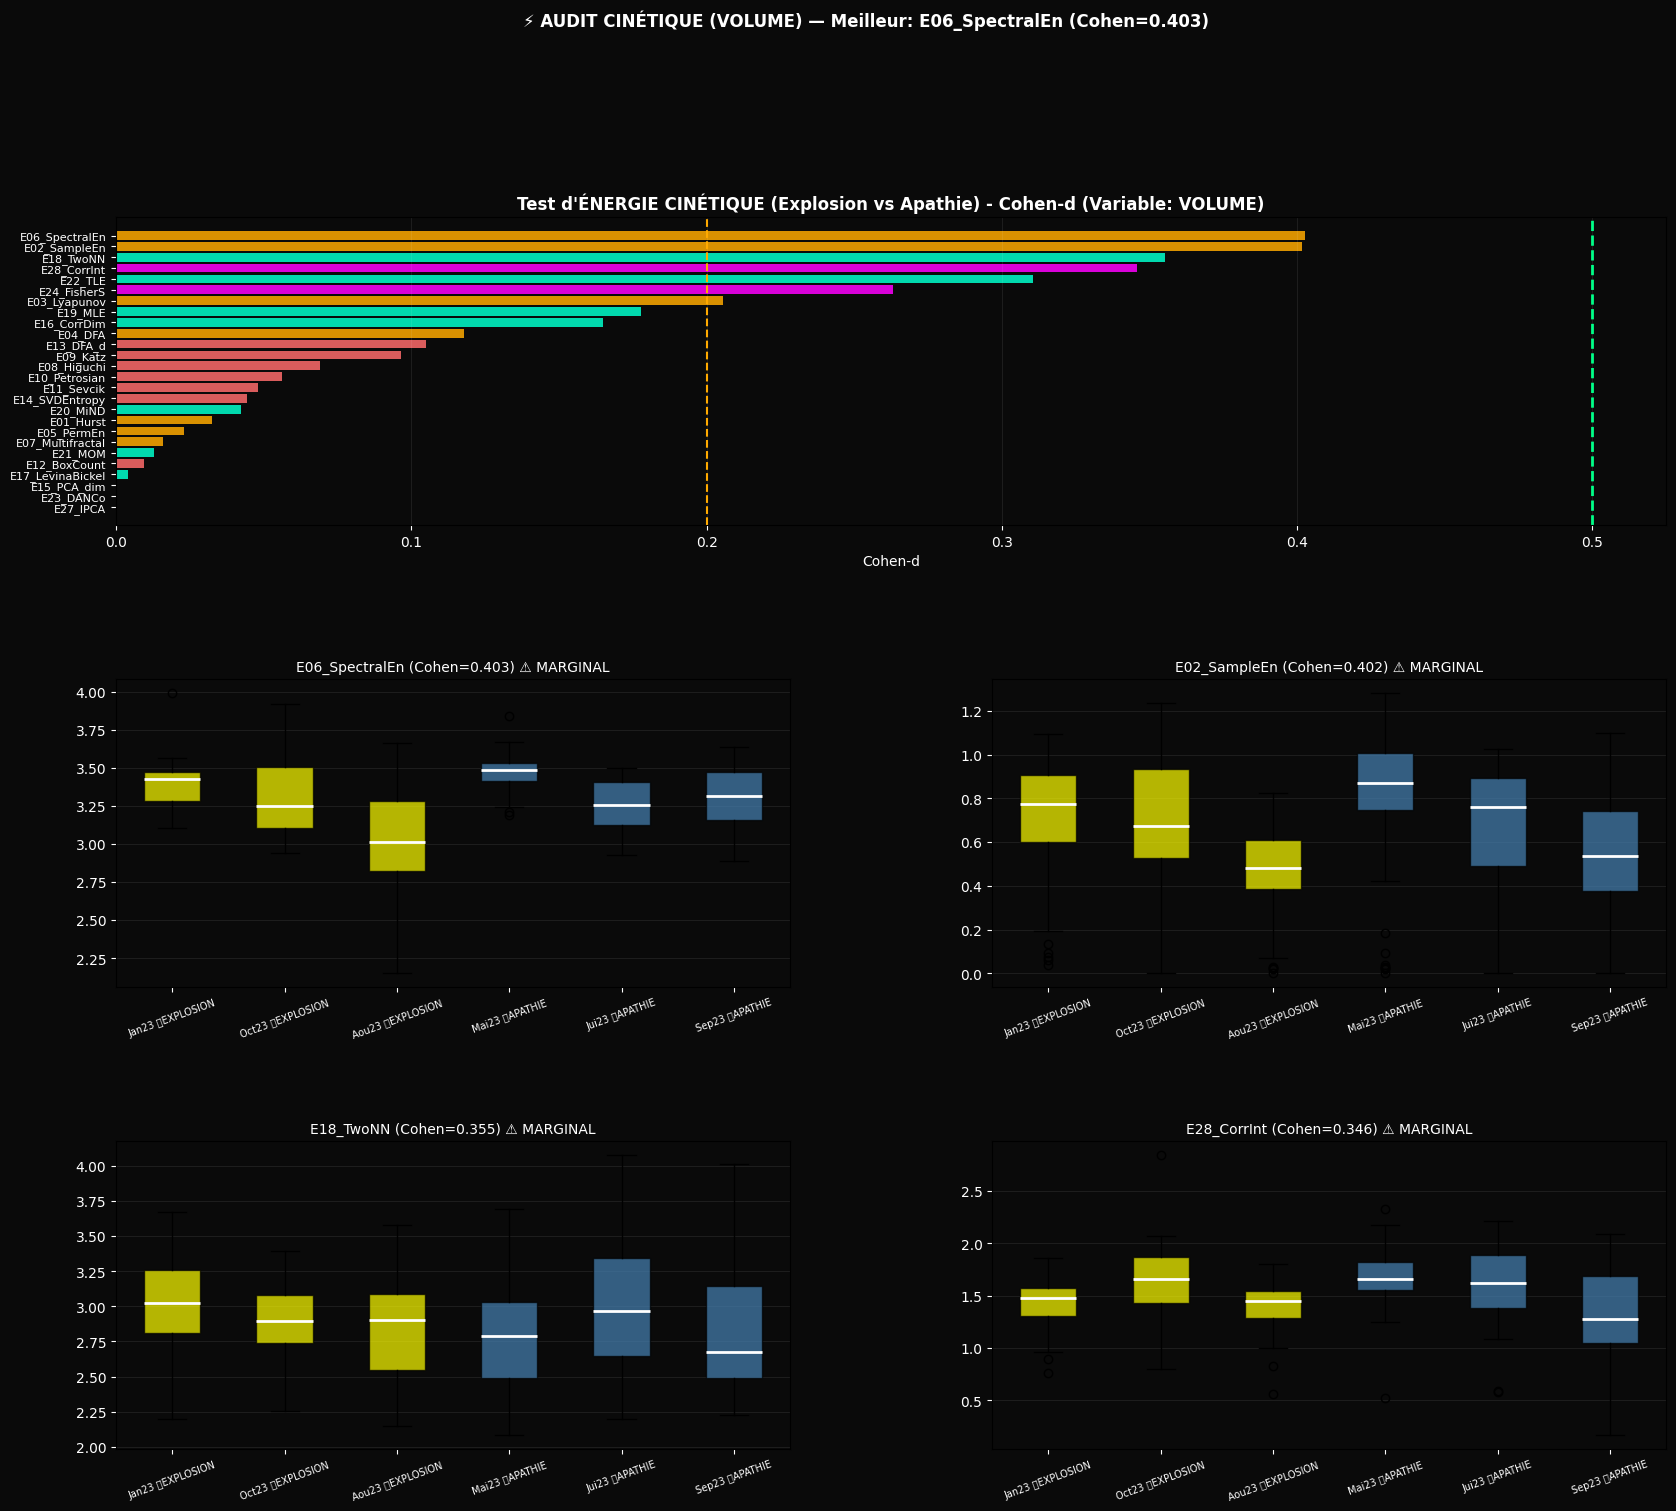

In [ ]:
# ==============================================================================
# ⚡ AUDIT CINÉTIQUE : Le Volume détecte-t-il l'Explosion vs l'Apathie ?
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy import stats as scipy_stats
from scipy.signal import periodogram
import urllib.request, zipfile, io, os, warnings, time
warnings.filterwarnings('ignore')

import subprocess, sys
for lib, imp in [('antropy','antropy'), ('nolds','nolds'), ('scikit-dimension','skdim')]:
    try: __import__(imp)
    except ImportError: subprocess.check_call([sys.executable,'-m','pip','install',lib,'-q'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
import antropy, nolds, skdim

def download_and_read_zip(url, header_names=None):
    try:
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=15) as response:
            with zipfile.ZipFile(io.BytesIO(response.read())) as z:
                csv_name = z.namelist()[0]
                with z.open(csv_name) as f:
                    if header_names: return pd.read_csv(f, names=header_names, header=0)
                    else: return pd.read_csv(f)
    except Exception: return None

def fetch_volume_month(symbol, year, month):
    kline_url = f"https://data.binance.vision/data/futures/um/monthly/klines/{symbol}/1h/{symbol}-1h-{year}-{month:02d}.zip"
    kline_cols = ['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_volume', 'count', 'taker_buy_volume', 'taker_buy_quote_volume', 'ignore']
    df_klines = download_and_read_zip(kline_url, header_names=kline_cols)
    if df_klines is None or df_klines.empty: return None

    df_klines['timestamp'] = pd.to_datetime(df_klines['open_time'], unit='ms')
    df_klines.set_index('timestamp', inplace=True)
    return df_klines[['volume']].copy()

def rolling_zscore(series, window=120):
    return (series - series.rolling(window).mean()) / (series.rolling(window).std() + 1e-8)

print("="*70)
print("  ⚡ TÉLÉCHARGEMENT DES DONNÉES (TEST CINÉTIQUE VOLUME) ...")
print("="*70)

# DATASET : Mois d'Explosion (Cinétique) vs Mois d'Apathie
MOIS_TEST = {
    'Jan23 💥EXPLOSION': (2023, 1),
    'Oct23 💥EXPLOSION': (2023, 10),
    'Aou23 💥EXPLOSION': (2023, 8),
    'Mai23 💤APATHIE': (2023, 5),
    'Jui23 💤APATHIE': (2023, 7),
    'Sep23 💤APATHIE': (2023, 9)
}

donnes = {}
for nom, (yr, mo) in MOIS_TEST.items():
    print(f"   📡 {nom}...")
    df = fetch_volume_month("BTCUSDT", yr, mo)
    if df is not None:
        # On standardise le volume (énergie cinétique pure)
        donnes[nom] = {'vol': rolling_zscore(df['volume'], window=120).bfill().values}
        print(f"   ✅ {nom} ingéré avec succès.")

# ==============================================================================
# 🎯 SÉLECTION : VOLUME
# ==============================================================================
VARIABLE_TESTEE = 'vol'

def safe(func, *args, **kwargs):
    try:
        r = func(*args, **kwargs); return float(r) if np.isfinite(float(r)) else np.nan
    except: return np.nan

def build_ps(x, emb=3, delay=1):
    n = len(x) - (emb-1)*delay
    if n < 10: return None
    return np.array([x[i:i+emb*delay:delay] for i in range(n)])

# ── Estimateurs ──
def E01_Hurst(x): return safe(nolds.hurst_rs, x)
def E02_SampleEn(x):
    try: return float(antropy.sample_entropy(x[:500], order=2))
    except: return np.nan
def E03_Lyapunov(x):
    try: return float(nolds.lyap_r(x, emb_dim=3))
    except: return np.nan
def E04_DFA(x): return safe(nolds.dfa, x)
def E05_PermEn(x):
    try: return float(antropy.perm_entropy(x, order=5, normalize=True))
    except: return np.nan
def E06_SpectralEn(x):
    try:
        f, psd = periodogram(x, fs=1.0)
        psd = psd[1:]; psd_norm = psd / psd.sum()
        return float(-np.sum(psd_norm * np.log(psd_norm + 1e-12)))
    except: return np.nan
def E07_Multifractal(x):
    try:
        n = len(x); q_vals = np.array([-5,-3,-1,1,3,5]); hs = []
        for q in q_vals:
            scales = np.unique(np.logspace(1, np.log10(n//4), 8).astype(int))
            Fq = []
            for s in scales:
                segs = [x[i:i+s] for i in range(0, n-s, s)]
                if len(segs) < 2: continue
                rms = []
                for seg in segs:
                    fit = np.polyval(np.polyfit(range(len(seg)), seg, 1), range(len(seg)))
                    r = np.sqrt(np.mean((seg-fit)**2))
                    if r > 0: rms.append(r)
                if not rms: continue
                Fq.append(np.mean(np.array(rms)**q)**(1/q))
            if len(Fq) < 3: continue
            h, _ = np.polyfit(np.log(scales[:len(Fq)]), np.log(Fq), 1)
            hs.append(h)
        return float(np.max(hs) - np.min(hs)) if len(hs) >= 3 else np.nan
    except: return np.nan

def E08_Higuchi(x): return safe(antropy.higuchi_fd, x)
def E09_Katz(x): return safe(antropy.katz_fd, x)
def E10_Petrosian(x): return safe(antropy.petrosian_fd, x)
def E11_Sevcik(x):
    try:
        n = len(x); xn = (x - x.min()) / (x.max() - x.min() + 1e-12)
        tn = np.linspace(0, 1, n)
        L = np.sum(np.sqrt(np.diff(xn)**2 + np.diff(tn)**2))
        return float(1 + np.log(L) / np.log(2*(n-1)))
    except: return np.nan
def E12_BoxCount(x):
    try:
        xn = (x - x.min()) / (x.max() - x.min() + 1e-12)
        scales = [4,8,16,32,64,128]; counts = []
        for s in scales:
            if s >= len(x): continue
            hist, _ = np.histogram(xn, bins=np.linspace(0,1,s+1))
            counts.append(np.sum(hist > 0))
        if len(counts) < 3: return np.nan
        return float(-np.polyfit(np.log(scales[:len(counts)]), np.log(counts), 1)[0])
    except: return np.nan
def E13_DFA_d(x):
    h = safe(nolds.dfa, x); return float(2 - h) if not np.isnan(h) else np.nan
def E14_SVDEntropy(x):
    try: return float(antropy.svd_entropy(x, order=5, delay=1, normalize=True))
    except: return np.nan

def E15_PCA_dim(x):
    try:
        X = build_ps(x, emb=10)
        if X is None: return np.nan
        pca = PCA().fit(X); cumvar = np.cumsum(pca.explained_variance_ratio_)
        return float(np.searchsorted(cumvar, 0.95) + 1)
    except: return np.nan
def E16_CorrDim(x):
    try: return float(nolds.corr_dim(x, emb_dim=3))
    except: return np.nan
def E17_LevinaBickel(x, k=10):
    try:
        X = build_ps(x, emb=3)
        if X is None or len(X) < k+2: return np.nan
        nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='brute').fit(X)
        d = np.maximum(nbrs.kneighbors(X)[0][:,1:], 1e-12)
        m = (k-1) / np.sum(np.log(d[:,-1:]/d[:,:-1]), axis=1); m = m[np.isfinite(m)]
        return float(np.median(m)) if len(m) > 0 else np.nan
    except: return np.nan
def E18_TwoNN(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.TwoNN().fit(X).dimension_) if X is not None and len(X) >= 5 else np.nan
    except: return np.nan
def E19_MLE(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.MLE().fit(X).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan
def E20_MiND(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.MiND_ML().fit(X).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan
def E21_MOM(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.MOM().fit(X).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan
def E22_TLE(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.TLE().fit(X).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan

def E23_DANCo(x):
    try:
        X = build_ps(x, emb=5); return float(skdim.id.DANCo().fit(X[:200]).dimension_) if X is not None and len(X) >= 20 else np.nan
    except: return np.nan
def E24_FisherS(x):
    try:
        X = build_ps(x, emb=5); return float(skdim.id.FisherS().fit(X[:200]).dimension_) if X is not None and len(X) >= 20 else np.nan
    except: return np.nan
def E26_GeoMle(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.GeoMle().fit(X[:300]).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan
def E27_lPCA(x):
    try:
        X = build_ps(x, emb=5); return float(skdim.id.lPCA().fit(X[:300]).dimension_) if X is not None and len(X) >= 20 else np.nan
    except: return np.nan
def E28_CorrInt(x):
    try:
        X = build_ps(x, emb=3); return float(skdim.id.CorrInt().fit(X[:300]).dimension_) if X is not None and len(X) >= 10 else np.nan
    except: return np.nan

ESTIMATEURS = {
    'E01_Hurst': ('Spectrale', E01_Hurst), 'E02_SampleEn': ('Spectrale', E02_SampleEn), 'E03_Lyapunov': ('Spectrale', E03_Lyapunov),
    'E04_DFA': ('Spectrale', E04_DFA), 'E05_PermEn': ('Spectrale', E05_PermEn), 'E06_SpectralEn': ('Spectrale', E06_SpectralEn), 'E07_Multifractal': ('Spectrale', E07_Multifractal),
    'E08_Higuchi': ('Saturation', E08_Higuchi), 'E09_Katz': ('Saturation', E09_Katz), 'E10_Petrosian': ('Saturation', E10_Petrosian),
    'E11_Sevcik': ('Saturation', E11_Sevcik), 'E12_BoxCount': ('Saturation', E12_BoxCount), 'E13_DFA_d': ('Saturation', E13_DFA_d), 'E14_SVDEntropy': ('Saturation', E14_SVDEntropy),
    'E15_PCA_dim': ('Transition', E15_PCA_dim), 'E16_CorrDim': ('Transition', E16_CorrDim), 'E17_LevinaBickel': ('Transition', E17_LevinaBickel),
    'E18_TwoNN': ('Transition', E18_TwoNN), 'E19_MLE': ('Transition', E19_MLE), 'E20_MiND': ('Transition', E20_MiND),
    'E21_MOM': ('Transition', E21_MOM), 'E22_TLE': ('Transition', E22_TLE), 'E23_DANCo': ('Divergence', E23_DANCo),
    'E24_FisherS': ('Divergence', E24_FisherS), 'E26_GeoMle': ('Divergence', E26_GeoMle), 'E27_lPCA': ('Divergence', E27_lPCA), 'E28_CorrInt': ('Divergence', E28_CorrInt)
}

# ==============================================================================
# 🚀 CALCUL
# ==============================================================================
WINDOW, STRIDE = 120, 12
resultats = {}

for nom_est, (classe, func) in ESTIMATEURS.items():
    t0 = time.time()
    vals_par_mois = {}
    for nom_mois, data in donnes.items():
        signal = data[VARIABLE_TESTEE]
        vals = []
        for i in range(WINDOW, len(signal), STRIDE):
            v = func(signal[i-WINDOW:i])
            if isinstance(v, float) and np.isfinite(v): vals.append(v)
        vals_par_mois[nom_mois] = vals

    elapsed = time.time() - t0
    total = sum(len(v) for v in vals_par_mois.values())
    if total == 0:
        print(f"  {nom_est:<22} ({classe:<12}) ❌ ÉCHEC [{elapsed:.1f}s]"); continue

    resultats[nom_est] = {'classe': classe, 'vals': vals_par_mois}

    # EXPLOSION (💥) vs APATHIE (💤)
    bons = [v for nm,vs in vals_par_mois.items() if 'EXPLOSION' in nm for v in vs]
    mauvais = [v for nm,vs in vals_par_mois.items() if 'APATHIE' in nm for v in vs]

    if bons and mauvais:
        cd = abs(np.median(bons)-np.median(mauvais)) / (np.std(bons+mauvais)+1e-12)
        sig = "✅" if cd > 0.3 else ("⚠️" if cd > 0.1 else "❌")
        print(f"  {nom_est:<22} ({classe:<12}) d̄={np.median(bons+mauvais):6.3f} Cohen={cd:.3f} {sig} [{elapsed:.1f}s]")

# ==============================================================================
# 📊 CLASSEMENT ET GRAPHIQUES
# ==============================================================================
analyse = []
for nom_est, data in resultats.items():
    bons = [v for nm,vs in data['vals'].items() if 'EXPLOSION' in nm for v in vs]
    mauvais = [v for nm,vs in data['vals'].items() if 'APATHIE' in nm for v in vs]
    if not bons or not mauvais: continue
    mb, mm = np.median(bons), np.median(mauvais)
    cohen  = abs(mb-mm) / (np.std(bons+mauvais)+1e-12)
    pval   = scipy_stats.mannwhitneyu(bons,mauvais,alternative='two-sided').pvalue if len(bons)>5 and len(mauvais)>5 else 1.0
    signal = "✅ FORT" if cohen>0.5 and pval<0.05 else ("⚠️ MARGINAL" if cohen>0.2 else "❌ BRUIT")
    analyse.append({'nom':nom_est,'classe':data['classe'],'mb':mb,'mm':mm,'cohen':cohen,'pval':pval,'signal':signal})

analyse_sorted = sorted(analyse, key=lambda x: x['cohen'], reverse=True)
print("\n" + "="*70)
print(f"  🏁 TEST D'ÉNERGIE CINÉTIQUE SUR LA VARIABLE : {VARIABLE_TESTEE.upper()}")
print("="*70)
for i,a in enumerate(analyse_sorted):
    print(f"  {i+1:<2} {a['nom']:<20} {a['classe']:<12} d_EXPLOSION={a['mb']:>6.3f} d_APATHIE={a['mm']:>6.3f} Cohen={a['cohen']:>5.3f} {a['signal']}")

fig = plt.figure(figsize=(20, 16)); fig.patch.set_facecolor('#0a0a0a')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.3)
CMAP = {'Spectrale':'#ffaa00','Saturation':'#ff6b6b','Transition':'#00ffcc','Divergence':'#ff00ff'}

ax1 = fig.add_subplot(gs[0,:]); ax1.set_facecolor('#0a0a0a')
ax1.set_title(f"Test d'ÉNERGIE CINÉTIQUE (Explosion vs Apathie) - Cohen-d (Variable: VOLUME)", color='white', fontsize=12, fontweight='bold')
noms_plot = [a['nom'] for a in analyse_sorted]; cohens_plot = [a['cohen'] for a in analyse_sorted]
clrs_plot = [CMAP.get(a['classe'],'#fff') for a in analyse_sorted]
ax1.barh(range(len(noms_plot)), cohens_plot[::-1], color=list(reversed(clrs_plot)), alpha=0.85)
ax1.axvline(x=0.5, color='#00ff88', linestyle='--', linewidth=2)
ax1.axvline(x=0.2, color='#ffaa00', linestyle='--', linewidth=1.5)
ax1.set_yticks(range(len(noms_plot))); ax1.set_yticklabels(list(reversed(noms_plot)), color='white', fontsize=8)
ax1.set_xlabel("Cohen-d", color='white'); ax1.tick_params(colors='white'); ax1.grid(color='white', alpha=0.08, axis='x')

top4 = analyse_sorted[:4]
for idx, a in enumerate(top4):
    ax = fig.add_subplot(gs[1 + idx//2, idx%2]); ax.set_facecolor('#0a0a0a')
    ax.set_title(f"{a['nom']} (Cohen={a['cohen']:.3f}) {a['signal']}", color='white', fontsize=10)
    noms_mois = list(donnes.keys()); bp_data = [resultats[a['nom']]['vals'].get(nm,[np.nan]) for nm in noms_mois]

    # Jaune explosif pour EXPLOSION, Gris bleuté pour APATHIE
    clrs_box = ['#FFFF00' if 'EXPLOSION' in nm else '#4682B4' for nm in noms_mois]

    bp = ax.boxplot(bp_data, patch_artist=True, medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], clrs_box): patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticklabels(noms_mois, color='white', fontsize=7, rotation=20); ax.tick_params(colors='white')
    ax.grid(color='white', alpha=0.08, axis='y')

plt.suptitle(f"⚡ AUDIT CINÉTIQUE (VOLUME) — Meilleur: {analyse_sorted[0]['nom']} (Cohen={analyse_sorted[0]['cohen']:.3f})", color='white', fontsize=12, y=1.01, fontweight='bold')
plt.savefig(f"audit_cinetique_volume.png", dpi=120, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

  🚀 LANCEMENT DE LA BATTERIE v8 (CAUSALITÉ ABSOLUE)


████████████████████████████████████████████████████████████████████████████████
  🔥 DÉBUT DU CYCLE D'ANALYSE POUR : PRIX
████████████████████████████████████████████████████████████████████████████████

📐 Calibration Nov+Déc 2021 (pour 2022-2023) [PRIX]...
   ⚙️  Calibration Nov+Déc 2021...
      E21_MOM         μ=1.6763  σ=0.0827
      E11_Sevcik      μ=1.5230  σ=0.0338
      E19_MLE         μ=3.0955  σ=0.1215
      E05_PermEn      μ=0.8858  σ=0.0122
      E24_FisherS     μ=5.0272  σ=0.2239

📐 Calibration Nov+Déc 2023 (pour 2024-2025) [PRIX]...
   ⚙️  Calibration Nov+Déc 2023...
      E21_MOM         μ=1.6140  σ=0.0839
      E11_Sevcik      μ=1.5198  σ=0.0397
      E19_MLE         μ=3.1479  σ=0.1105
      E05_PermEn      μ=0.8787  σ=0.0147
      E24_FisherS     μ=4.9272  σ=0.2201

----------------------------------------------------------------------
  📦 PRÉCOMPUTATION PRIX (2022-2025)...
------------------------------------------

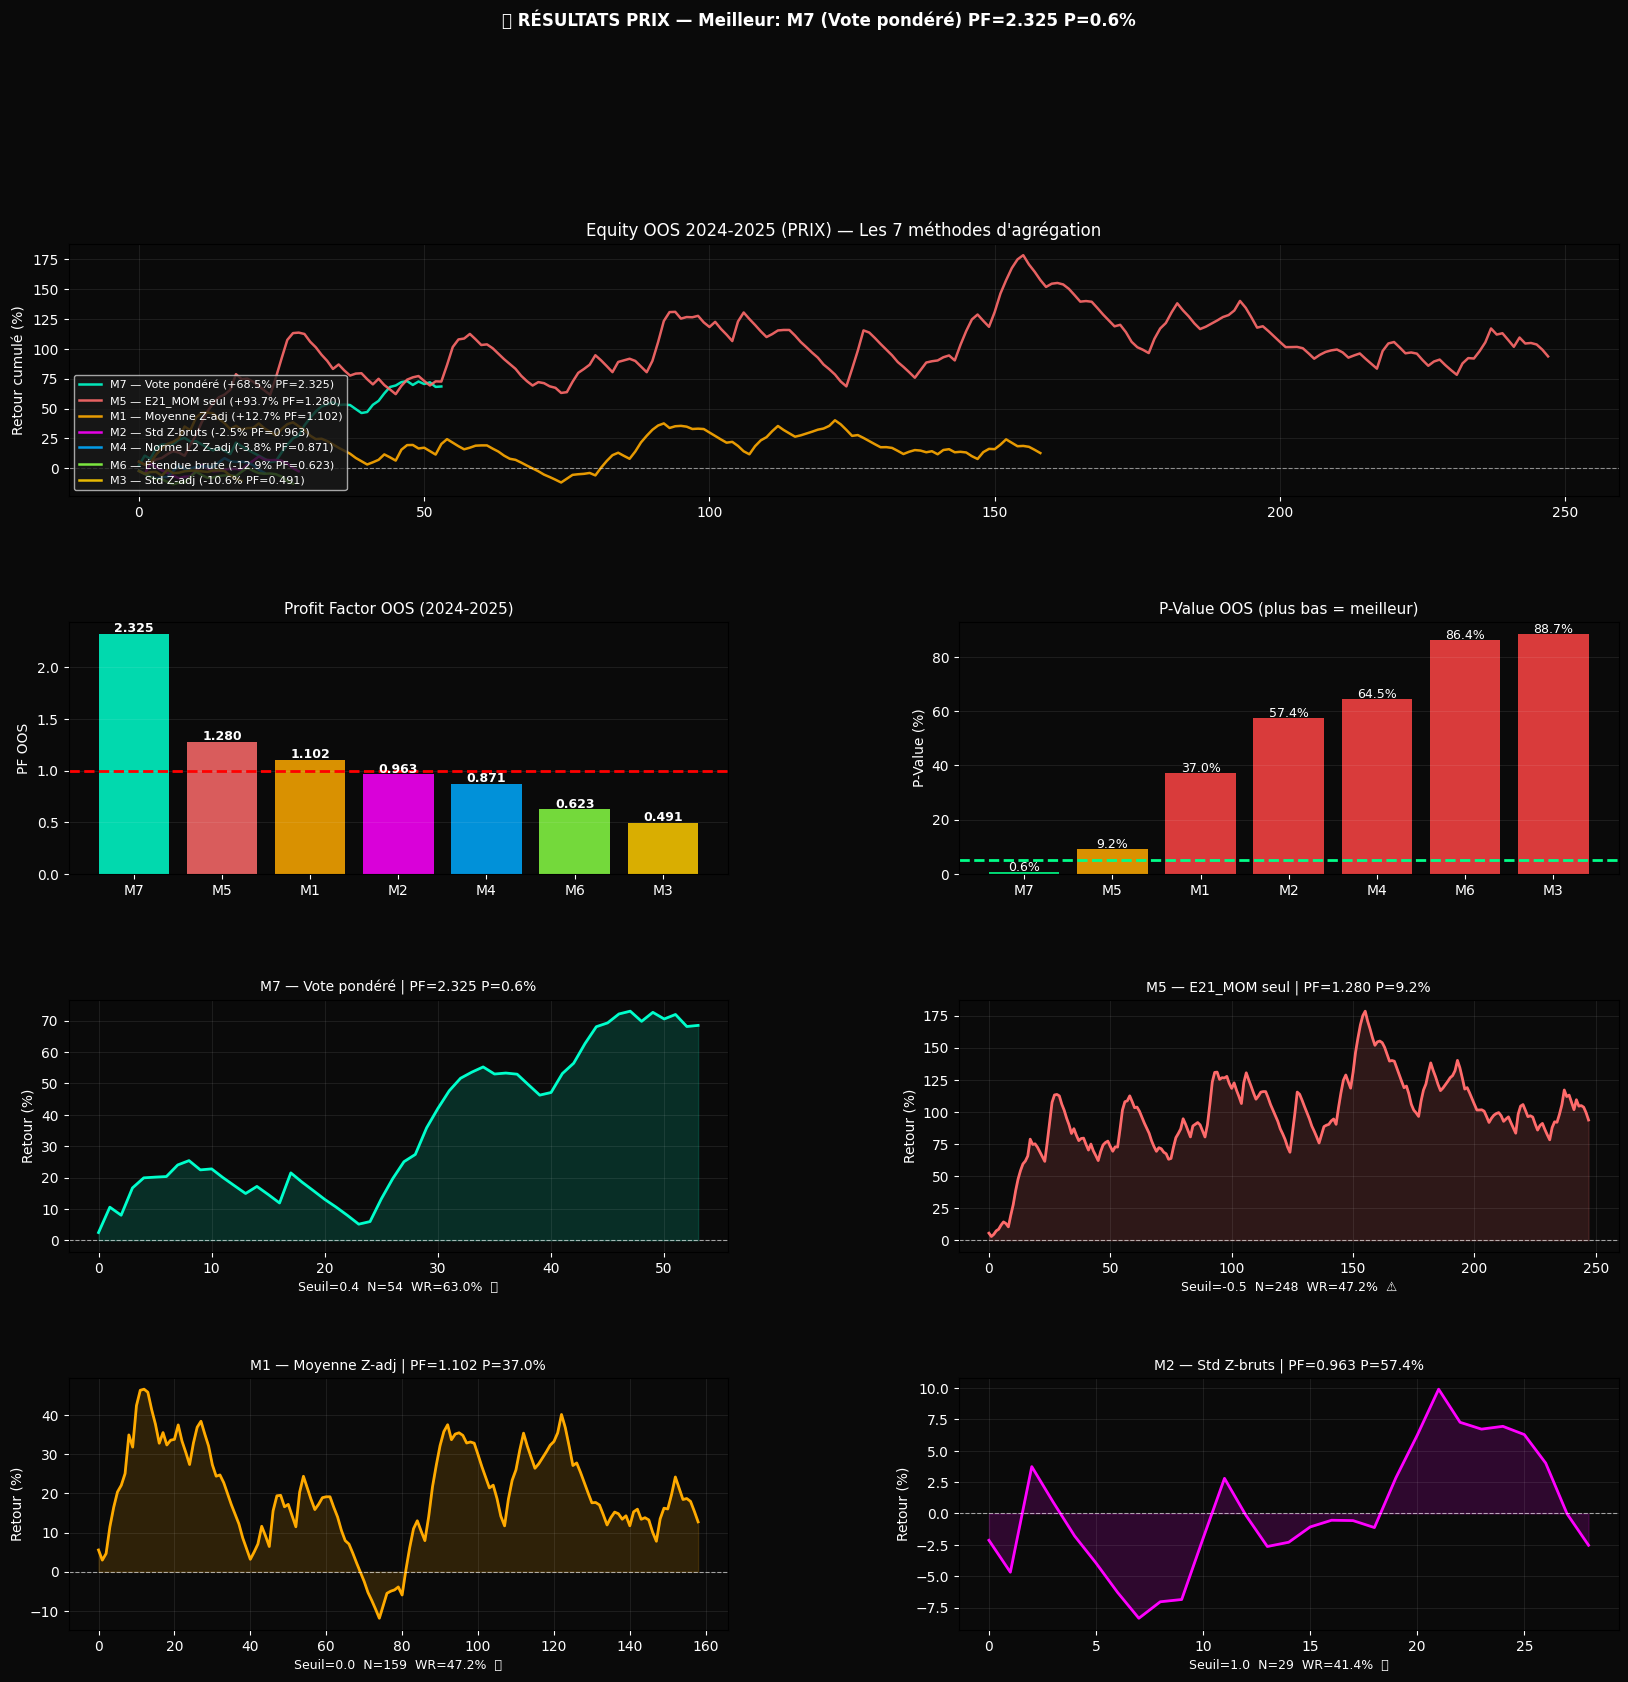



████████████████████████████████████████████████████████████████████████████████
  🔥 DÉBUT DU CYCLE D'ANALYSE POUR : CVD
████████████████████████████████████████████████████████████████████████████████

📐 Calibration Nov+Déc 2021 (pour 2022-2023) [CVD]...
   ⚙️  Calibration Nov+Déc 2021...
      E28_CorrInt     μ=2.3133  σ=0.1868
      E15_PCA_dim     μ=9.7500  σ=0.4330
      E09_Katz        μ=2.9798  σ=0.7568
      E18_TwoNN       μ=3.0887  σ=0.4338

📐 Calibration Nov+Déc 2023 (pour 2024-2025) [CVD]...
   ⚙️  Calibration Nov+Déc 2023...
      E28_CorrInt     μ=2.2700  σ=0.1428
      E15_PCA_dim     μ=9.7946  σ=0.4149
      E09_Katz        μ=2.6099  σ=0.4152
      E18_TwoNN       μ=2.9484  σ=0.3696

----------------------------------------------------------------------
  📦 PRÉCOMPUTATION CVD (2022-2025)...
----------------------------------------------------------------------
   ✅ 2022-01 🔴
   ✅ 2022-02 🟢
   ✅ 2022-03 🟢
   ✅ 2022-04 🔴
   ✅ 2022-05 🔴
   ✅ 2022-06 🔴
   ✅ 2022-07 🟢
   ✅

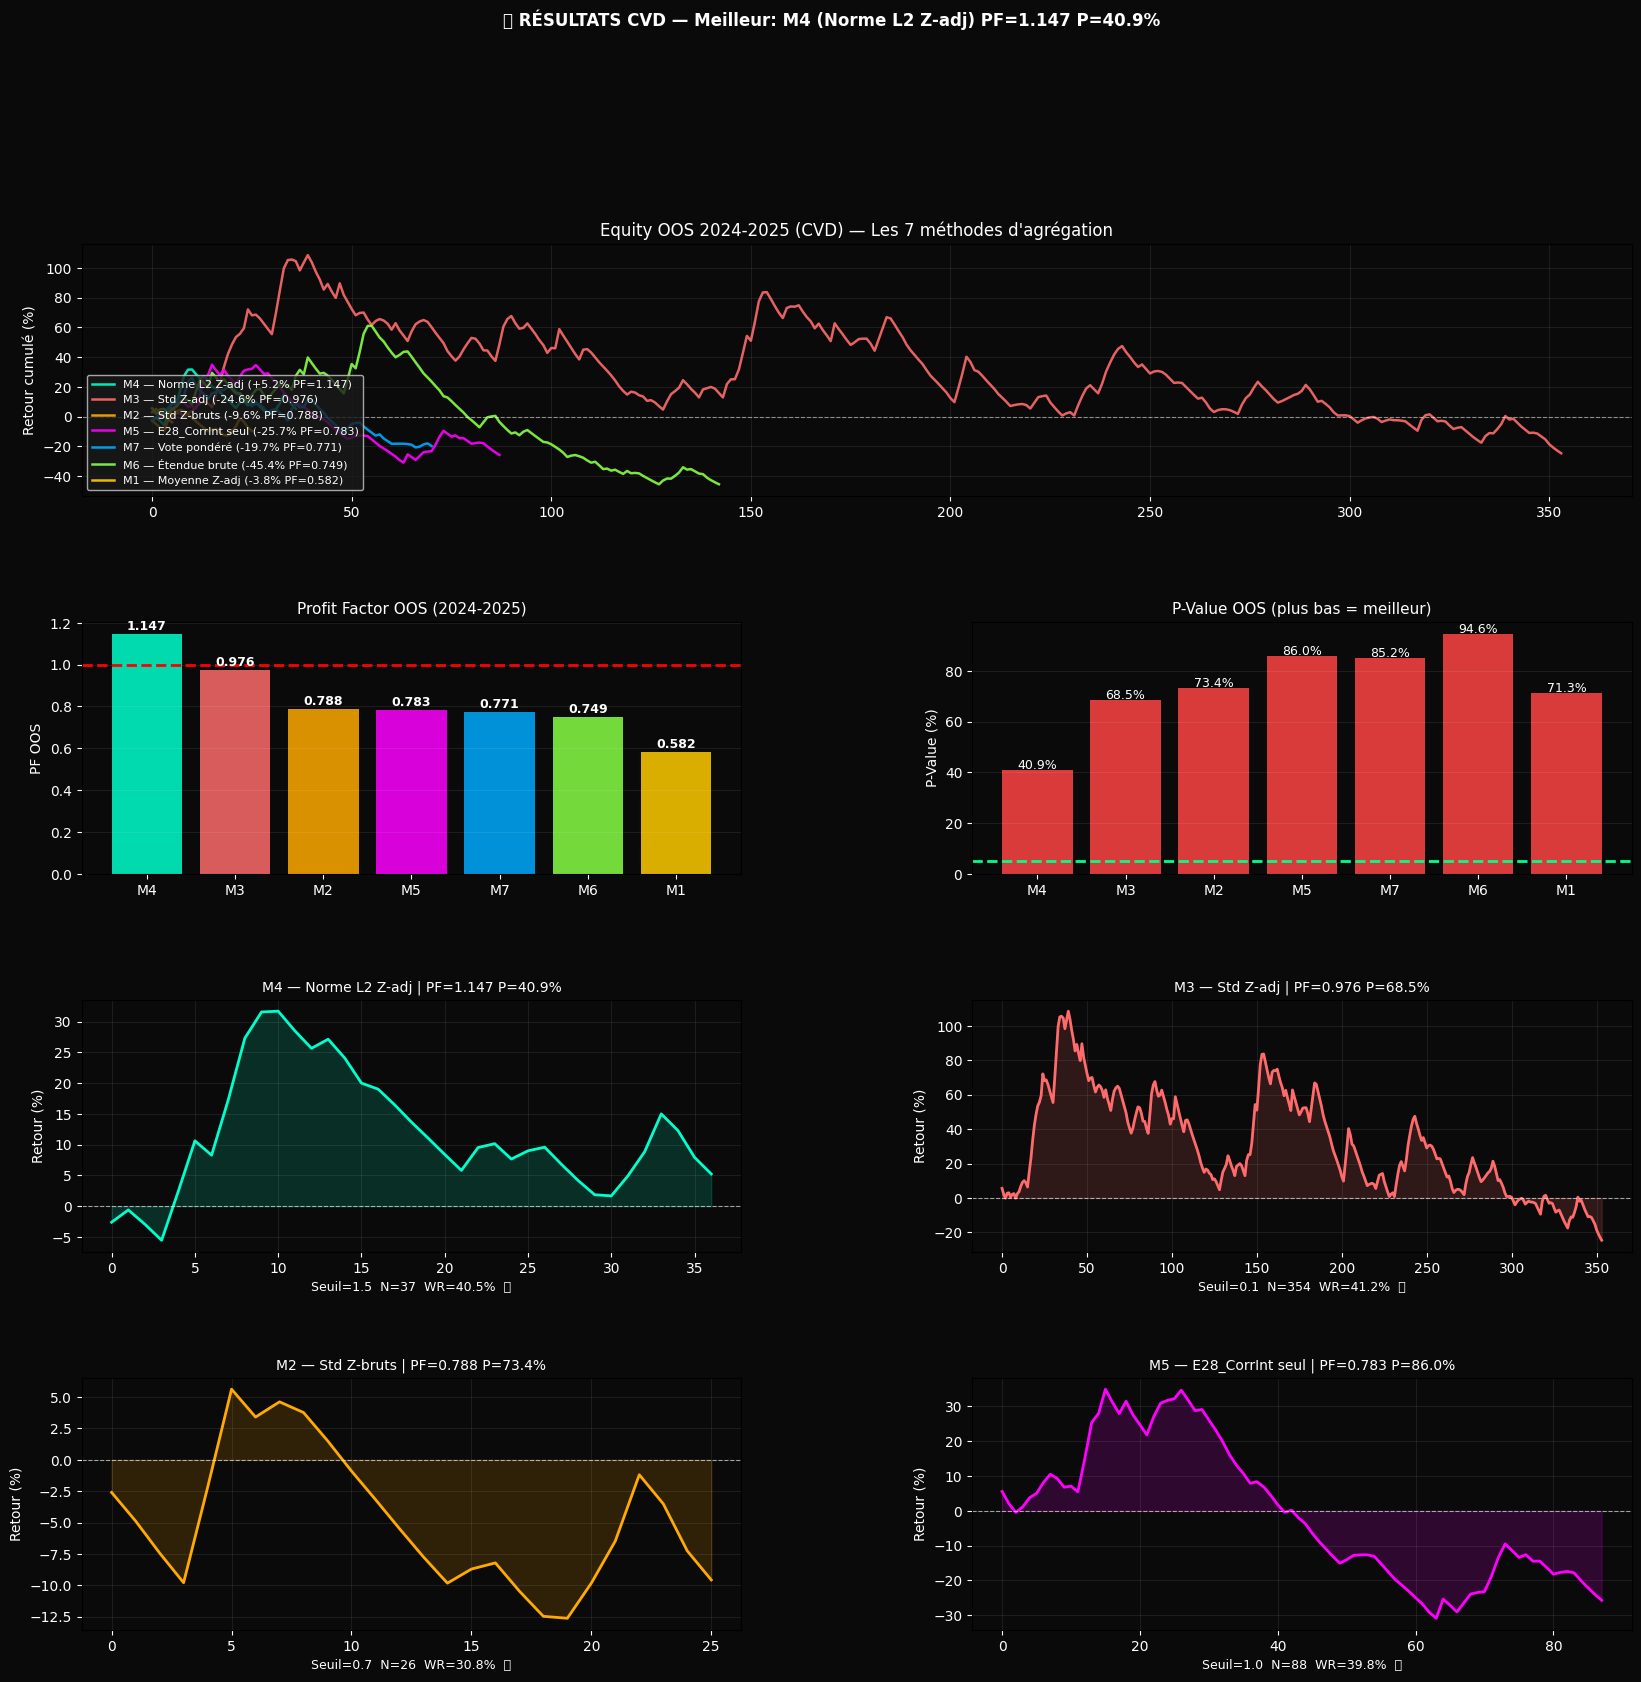



████████████████████████████████████████████████████████████████████████████████
  🔥 DÉBUT DU CYCLE D'ANALYSE POUR : OI
████████████████████████████████████████████████████████████████████████████████

📐 Calibration Nov+Déc 2021 (pour 2022-2023) [OI]...
   ⚙️  Calibration Nov+Déc 2021...
      E18_TwoNN       μ=3.0902  σ=0.4100
      E22_TLE         μ=3.0569  σ=0.0712
      E12_BoxCount    μ=-0.7437  σ=0.0895

📐 Calibration Nov+Déc 2023 (pour 2024-2025) [OI]...
   ⚙️  Calibration Nov+Déc 2023...
      E18_TwoNN       μ=3.0111  σ=0.3699
      E22_TLE         μ=2.9687  σ=0.0824
      E12_BoxCount    μ=-0.6580  σ=0.1968

----------------------------------------------------------------------
  📦 PRÉCOMPUTATION OI (2022-2025)...
----------------------------------------------------------------------
   ✅ 2022-01 🔴
   ✅ 2022-02 🟢
   ✅ 2022-03 🟢
   ✅ 2022-04 🔴
   ✅ 2022-05 🔴
   ✅ 2022-06 🔴
   ✅ 2022-07 🟢
   ✅ 2022-08 🔴
   ✅ 2022-09 🟡
   ✅ 2022-10 🟢
   ✅ 2022-11 🔴
   ✅ 2022-12 🟡
   ✅ 2023-01 

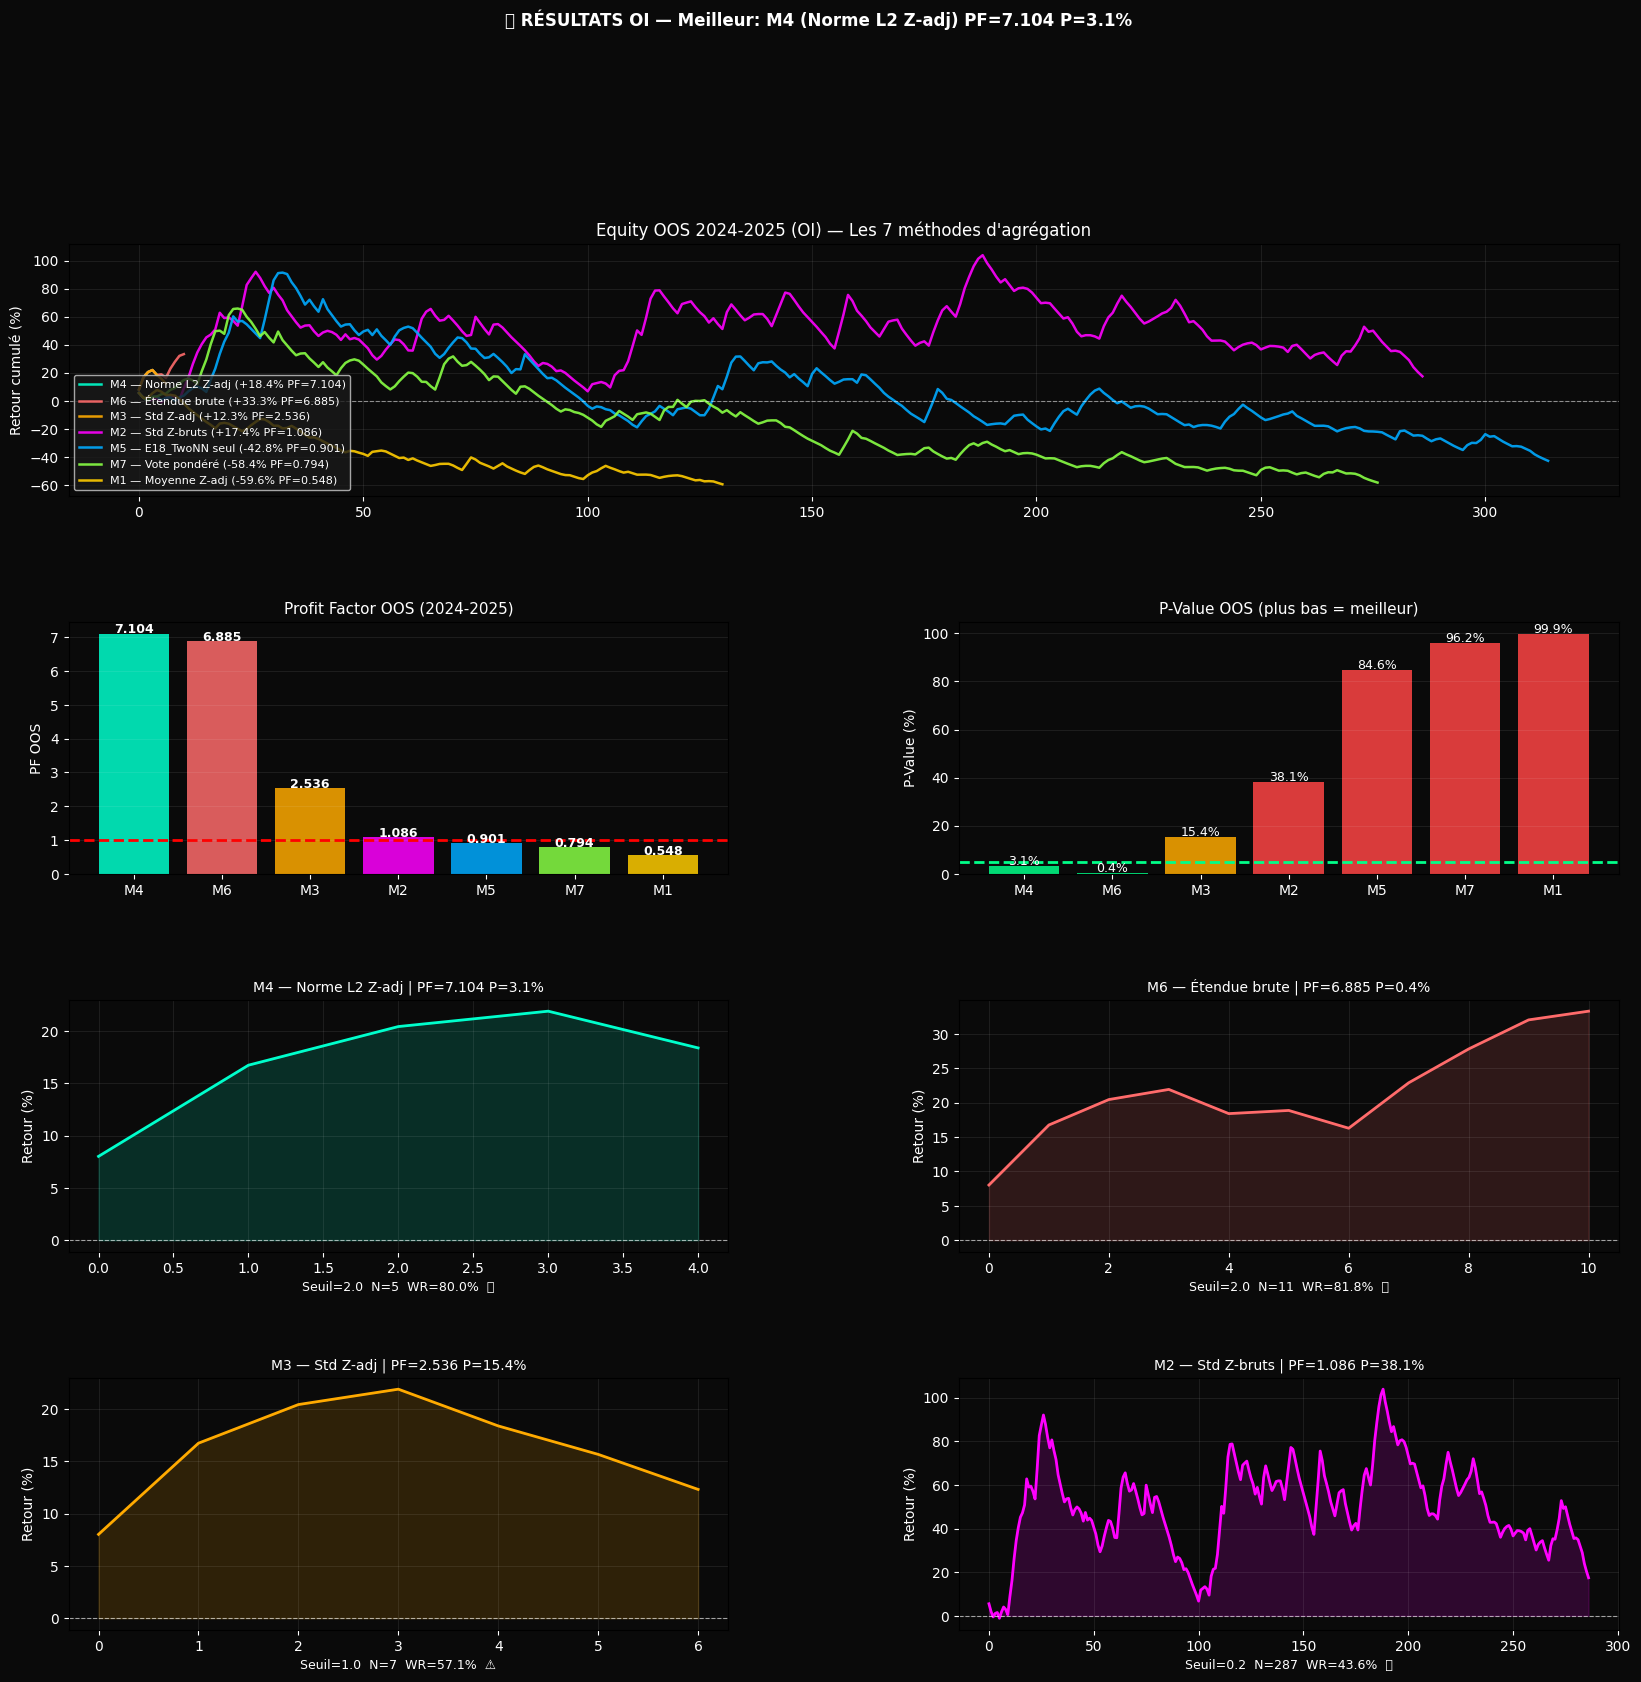



████████████████████████████████████████████████████████████████████████████████
  🔥 DÉBUT DU CYCLE D'ANALYSE POUR : VOLUME
████████████████████████████████████████████████████████████████████████████████

📐 Calibration Nov+Déc 2021 (pour 2022-2023) [VOLUME]...
   ⚙️  Calibration Nov+Déc 2021...
      E06_SpectralEn  μ=3.4681  σ=0.1156
      E02_SampleEn    μ=1.1572  σ=0.3100
      E18_TwoNN       μ=2.9253  σ=0.3899
      E28_CorrInt     μ=1.8325  σ=0.2836

📐 Calibration Nov+Déc 2023 (pour 2024-2025) [VOLUME]...
   ⚙️  Calibration Nov+Déc 2023...
      E06_SpectralEn  μ=3.3878  σ=0.1687
      E02_SampleEn    μ=0.8454  σ=0.2608
      E18_TwoNN       μ=2.8971  σ=0.3499
      E28_CorrInt     μ=1.6016  σ=0.2882

----------------------------------------------------------------------
  📦 PRÉCOMPUTATION VOLUME (2022-2025)...
----------------------------------------------------------------------
   ✅ 2022-01 🔴
   ✅ 2022-02 🟢
   ✅ 2022-03 🟢
   ✅ 2022-04 🔴
   ✅ 2022-05 🔴
   ✅ 2022-06 🔴
   ✅ 20

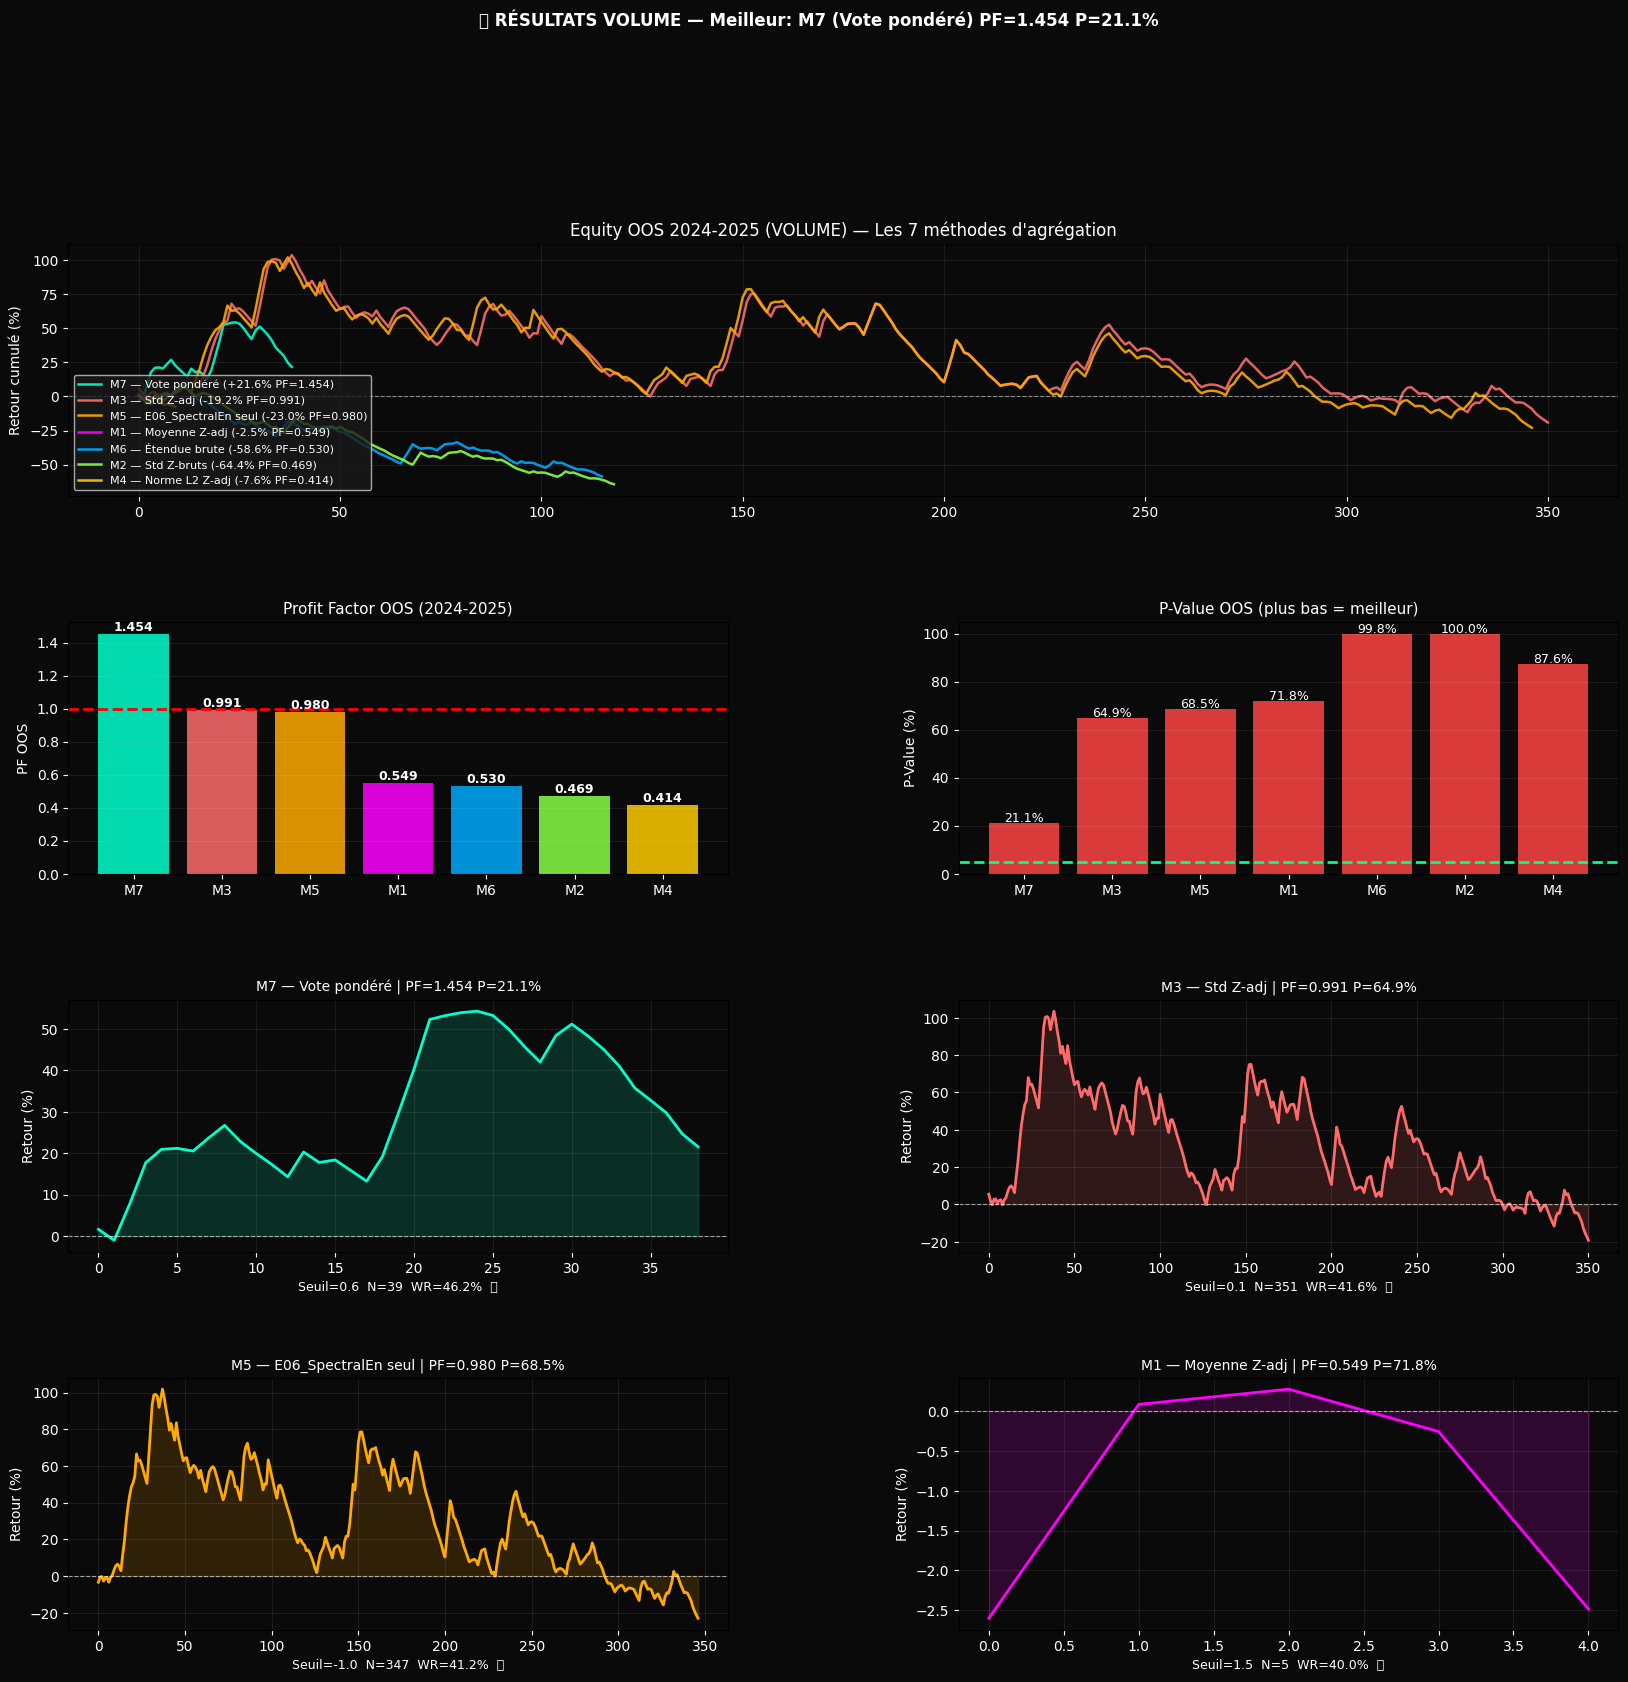


  ✅ TOUS LES TESTS SONT TERMINÉS ! REGARDEZ LES IMAGES SAUVEGARDÉES.


In [ ]:
# ==============================================================================
# === CELLULE 2 (MASTER AUTOMATISÉE - ZÉRO LOOKAHEAD BIAS) ===
# 🧪 COMPARAISON 7 MÉTHODES D'AGRÉGATION SUR PRIX, CVD, OI, VOLUME
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from scipy import stats as scipy_stats
from scipy.signal import periodogram
import urllib.request, zipfile, io, os, warnings, time
warnings.filterwarnings('ignore')

import subprocess, sys
for lib, imp in [('antropy','antropy'), ('nolds','nolds'), ('scikit-dimension','skdim')]:
    try: __import__(imp)
    except ImportError: subprocess.check_call([sys.executable,'-m','pip','install',lib,'-q'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
import antropy, nolds, skdim

print("=" * 80)
print("  🚀 LANCEMENT DE LA BATTERIE v8 (CAUSALITÉ ABSOLUE)")
print("=" * 80)

# ==============================================================================
# ⚙️ CONFIG BACKTEST
# ==============================================================================
SL_FIXED, TP_FIXED, MAXHOLD = -0.020, 0.080, 72
FEES     = 0.001
WINDOW   = 120
STRIDE   = 6
N_DONCH  = 96
NOMS12   = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

# ==============================================================================
# ⚙️ MOTEUR D'INGESTION UNIVERSEL (0% LOOKAHEAD BIAS)
# ==============================================================================
def download_and_read_zip(url, header_names=None):
    try:
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=10) as response:
            with zipfile.ZipFile(io.BytesIO(response.read())) as z:
                csv_name = z.namelist()[0]
                with z.open(csv_name) as f:
                    if header_names: return pd.read_csv(f, names=header_names, header=0)
                    else: return pd.read_csv(f)
    except Exception: return None

def load_month_data(m, var_name):
    year, month = m.split('-')
    kline_url = f"https://data.binance.vision/data/futures/um/monthly/klines/BTCUSDT/1h/BTCUSDT-1h-{year}-{month}.zip"
    kline_cols = ['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_volume', 'count', 'taker_buy_volume', 'taker_buy_quote_volume', 'ignore']
    df = download_and_read_zip(kline_url, header_names=kline_cols)
    if df is None or df.empty: return None

    df['timestamp'] = pd.to_datetime(df['open_time'], unit='ms')
    df.set_index('timestamp', inplace=True)

    # ⚠️ Les signaux retournés sont BRUTS. La standardisation se fera localement plus tard.
    if var_name == "PRIX":
        sig = np.diff(np.log(df['close'].values))
    elif var_name == "CVD":
        df['buy_vol'] = df['taker_buy_volume']
        df['sell_vol'] = df['volume'] - df['taker_buy_volume']
        sig = np.diff((df['buy_vol'] - df['sell_vol']).cumsum().values)
    elif var_name == "VOLUME":
        sig = df['volume'].values[1:]
    elif var_name == "OI":
        num_days = pd.Period(m).days_in_month
        oi_list = []
        for day in range(1, num_days + 1):
            date_str = f"{year}-{month}-{day:02d}"
            metrics_url = f"https://data.binance.vision/data/futures/um/daily/metrics/BTCUSDT/BTCUSDT-metrics-{date_str}.zip"
            df_m = download_and_read_zip(metrics_url)
            if df_m is not None and not df_m.empty:
                df_m['timestamp'] = pd.to_datetime(df_m['create_time'], format='ISO8601')
                df_m.set_index('timestamp', inplace=True)
                oi_list.append(df_m[['sum_open_interest_value']].resample('1H').mean().ffill())
        if not oi_list: return None
        df_oi = pd.concat(oi_list)
        df_oi = df_oi[~df_oi.index.duplicated(keep='last')]
        df = df.join(df_oi, how='left')
        df['sum_open_interest_value'] = df['sum_open_interest_value'].ffill().bfill()
        sig = np.diff(df['sum_open_interest_value'].values)

    return {'signal': sig, 'close': df['close'].values, 'high': df['high'].values, 'low': df['low'].values}

# ==============================================================================
# ⚙️ TOUS LES ESTIMATEURS (Z-SCORE LOCAL INTÉGRÉ = CAUSALITÉ ABSOLUE)
# ==============================================================================
def local_z(x):
    """Z-score calculé UNIQUEMENT sur la fenêtre glissante [i-120:i]. Zéro lookahead."""
    return (x - np.mean(x)) / (np.std(x) + 1e-8)

def build_ps(x, emb=3, delay=1):
    n=len(x)-(emb-1)*delay
    if n<10: return None
    return np.array([x[i:i+emb*delay:delay] for i in range(n)])

def E21_MOM(x):
    try: X=build_ps(local_z(x),emb=3); return float(skdim.id.MOM().fit(X).dimension_) if X is not None and len(X)>=10 else np.nan
    except: return np.nan
def E11_Sevcik(x):
    try: x_z=local_z(x); n=len(x_z); xn=(x_z-x_z.min())/(x_z.max()-x_z.min()+1e-12); L=np.sum(np.sqrt(np.diff(xn)**2+np.diff(np.linspace(0,1,n))**2)); return float(1+np.log(L)/np.log(2*(n-1)))
    except: return np.nan
def E19_MLE(x):
    try: X=build_ps(local_z(x),emb=3); return float(skdim.id.MLE().fit(X).dimension_) if X is not None and len(X)>=10 else np.nan
    except: return np.nan
def E05_PermEn(x):
    try: return float(antropy.perm_entropy(local_z(x),order=5,normalize=True))
    except: return np.nan
def E24_FisherS(x):
    try: X=build_ps(local_z(x),emb=5); return float(skdim.id.FisherS().fit(X[:200]).dimension_) if X is not None and len(X)>=20 else np.nan
    except: return np.nan
def E28_CorrInt(x):
    try: X=build_ps(local_z(x),emb=3); return float(skdim.id.CorrInt().fit(X[:300]).dimension_) if X is not None and len(X)>=10 else np.nan
    except: return np.nan
def E15_PCA_dim(x):
    try: X=build_ps(local_z(x),emb=10); pca=PCA().fit(X); return float(np.searchsorted(np.cumsum(pca.explained_variance_ratio_), 0.95)+1) if X is not None else np.nan
    except: return np.nan
def E09_Katz(x):
    try: return float(antropy.katz_fd(local_z(x))) if len(x)>10 else np.nan
    except: return np.nan
def E18_TwoNN(x):
    try: X=build_ps(local_z(x),emb=3); return float(skdim.id.TwoNN().fit(X).dimension_) if X is not None and len(X)>=5 else np.nan
    except: return np.nan
def E22_TLE(x):
    try: X=build_ps(local_z(x),emb=3); return float(skdim.id.TLE().fit(X).dimension_) if X is not None and len(X)>=10 else np.nan
    except: return np.nan
def E12_BoxCount(x):
    try: x_z=local_z(x); xn=(x_z-x_z.min())/(x_z.max()-x_z.min()+1e-12); scales=[4,8,16,32,64,128]; counts=[np.sum(np.histogram(xn, bins=np.linspace(0,1,s+1))[0]>0) for s in scales if s<len(x)]; return float(-np.polyfit(np.log(scales[:len(counts)]), np.log(counts), 1)[0]) if len(counts)>=3 else np.nan
    except: return np.nan
def E06_SpectralEn(x):
    try: f, psd = periodogram(local_z(x), fs=1.0); psd = psd[1:]; psd_norm = psd / psd.sum(); return float(-np.sum(psd_norm * np.log(psd_norm + 1e-12)))
    except: return np.nan
def E02_SampleEn(x):
    try: return float(antropy.sample_entropy(local_z(x)[:500], order=2))
    except: return np.nan

# ==============================================================================
# ⚙️ FONCTIONS DE BACKTEST ET D'AGRÉGATION
# ==============================================================================
def calibrer(lr_series, ancres_dict, nom_periode=""):
    print(f"   ⚙️  Calibration {nom_periode}...")
    stats = {}
    for nom, cfg in ancres_dict.items():
        vals=[cfg['func'](lr_series[i-WINDOW:i]) for i in range(WINDOW,len(lr_series),STRIDE)]
        vals=[v for v in vals if np.isfinite(v)]
        if vals:
            stats[nom]={'mu':np.mean(vals),'sigma':np.std(vals)+1e-10}
            print(f"      {nom:<15} μ={stats[nom]['mu']:.4f}  σ={stats[nom]['sigma']:.4f}")
        else:
            print(f"      {nom:<15} ❌")
    return stats

def compute_zscores(lr_window, calib_stats, ancres_dict):
    z_bruts, z_adjs, poids = [], [], []
    for nom, cfg in ancres_dict.items():
        v = cfg['func'](lr_window)
        if not np.isfinite(v) or nom not in calib_stats: continue
        z_brut = (v - calib_stats[nom]['mu']) / calib_stats[nom]['sigma']
        z_bruts.append(z_brut); z_adjs.append(z_brut * cfg['dir']); poids.append(cfg['poids'])
    return np.array(z_bruts), np.array(z_adjs), np.array(poids)

def agreger_7methodes(z_bruts, z_adjs, poids, ancres_dict):
    if len(z_bruts) < len(ancres_dict)-1: return {f'M{i}': np.nan for i in range(1,8)}
    return {
        'M1': np.average(z_adjs, weights=poids),
        'M2': np.std(z_bruts * poids),
        'M3': np.std(z_adjs * poids),
        'M4': np.sqrt(np.sum((z_adjs * poids)**2)),
        'M5': z_adjs[0] if len(z_adjs) > 0 else np.nan,
        'M6': np.max(z_bruts * poids) - np.min(z_bruts * poids),
        'M7': np.average(np.sign(z_adjs), weights=poids)
    }

def donchian(prix, high, low, N=N_DONCH):
    return prix>pd.Series(high).shift(1).rolling(N).max().values, prix<pd.Series(low).shift(1).rolling(N).min().values

def backtest(long_raw, short_raw, mask, prix):
    lf=long_raw&mask; sf=short_raw&mask
    sl=np.roll(lf.astype(int),1); sl[0]=0
    ss=np.roll(sf.astype(int),1); ss[0]=0
    dl=np.diff(sl,prepend=0)==1; ds=np.diff(ss,prepend=0)==1
    trades=[]
    for i in range(len(prix)):
        d='long' if dl[i] else('short' if ds[i] else None)
        if d is None: continue
        ep=prix[i]; xp=None
        for j in range(i+1,min(i+MAXHOLD,len(prix))):
            r=(prix[j]-ep)/ep if d=='long' else(ep-prix[j])/ep
            if r<=SL_FIXED or r>=TP_FIXED: xp=prix[j]; break
        if xp is None: xp=prix[min(i+MAXHOLD-1,len(prix)-1)]
        trades.append(((xp-ep)/ep if d=='long' else(ep-xp)/ep)-FEES)
    return np.array(trades)

def kpis(t):
    if len(t)==0: return dict(n=0,ret=0,wr=0,pf=0,dd=0)
    eq=np.cumprod(1+t); g,l=t[t>0],t[t<0]
    return dict(n=len(t),ret=(eq[-1]-1)*100,wr=np.mean(t>0)*100,
                pf=np.sum(g)/abs(np.sum(l)) if len(l)>0 and abs(np.sum(l))>0 else np.inf,
                dd=np.min(eq/np.maximum.accumulate(eq)-1)*100)

def pval(t,n=6000):
    if len(t)==0: return 100.
    return np.mean(np.array([np.prod(1+np.random.choice(t,size=len(t),replace=True))-1 for _ in range(n)])<0)*100


# ==============================================================================
# 🔄 LA GRANDE BOUCLE DES 4 FORCES
# ==============================================================================
VARIABLES_A_TESTER = ["PRIX", "CVD", "OI", "VOLUME"]

for var_name in VARIABLES_A_TESTER:
    print("\n\n" + "█"*80)
    print(f"  🔥 DÉBUT DU CYCLE D'ANALYSE POUR : {var_name}")
    print("█"*80)

    if var_name == "PRIX":
        ANCRES = {'E21_MOM':{'func':E21_MOM,'poids':0.828,'dir':+1}, 'E11_Sevcik':{'func':E11_Sevcik,'poids':0.567,'dir':-1}, 'E19_MLE':{'func':E19_MLE,'poids':0.539,'dir':-1}, 'E05_PermEn':{'func':E05_PermEn,'poids':0.526,'dir':-1}, 'E24_FisherS':{'func':E24_FisherS,'poids':0.521,'dir':-1}}
    elif var_name == "CVD":
        ANCRES = {'E28_CorrInt':{'func':E28_CorrInt,'poids':0.490,'dir':+1}, 'E15_PCA_dim':{'func':E15_PCA_dim,'poids':0.329,'dir':+1}, 'E09_Katz':{'func':E09_Katz,'poids':0.271,'dir':-1}, 'E18_TwoNN':{'func':E18_TwoNN,'poids':0.228,'dir':-1}}
    elif var_name == "OI":
        ANCRES = {'E18_TwoNN':{'func':E18_TwoNN,'poids':0.621,'dir':+1}, 'E22_TLE':{'func':E22_TLE,'poids':0.516,'dir':-1}, 'E12_BoxCount':{'func':E12_BoxCount,'poids':0.216,'dir':+1}}
    elif var_name == "VOLUME":
        ANCRES = {'E06_SpectralEn':{'func':E06_SpectralEn,'poids':0.403,'dir':-1}, 'E02_SampleEn':{'func':E02_SampleEn,'poids':0.402,'dir':-1}, 'E18_TwoNN':{'func':E18_TwoNN,'poids':0.355,'dir':+1}, 'E28_CorrInt':{'func':E28_CorrInt,'poids':0.346,'dir':-1}}

    METHODES_INFO = {
        'M1': ('Moyenne Z-adj',      [-1.5,-1.0,-0.5, 0.0, 0.3, 0.5, 0.7, 1.0, 1.5]),
        'M2': ('Std Z-bruts',        [ 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0, 1.3]),
        'M3': ('Std Z-adj',          [ 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0, 1.3]),
        'M4': ('Norme L2 Z-adj',     [ 0.3, 0.5, 0.7, 1.0, 1.3, 1.5, 2.0, 2.5]),
        'M5': (f"{list(ANCRES.keys())[0]} seul", [-1.5,-1.0,-0.5, 0.0, 0.3, 0.5, 0.7, 1.0, 1.5]),
        'M6': ('Étendue brute',      [ 0.5, 0.7, 1.0, 1.3, 1.5, 2.0, 2.5, 3.0]),
        'M7': ('Vote pondéré',       [-1.0,-0.5, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0]),
    }

    print(f"\n📐 Calibration Nov+Déc 2021 (pour 2022-2023) [{var_name}]...")
    d1 = load_month_data('2021-11', var_name); d2 = load_month_data('2021-12', var_name)
    if d1 and d2: CS1 = calibrer(np.concatenate([d1['signal'], d2['signal']]), ANCRES, "Nov+Déc 2021")
    else: CS1 = {}

    print(f"\n📐 Calibration Nov+Déc 2023 (pour 2024-2025) [{var_name}]...")
    d3 = load_month_data('2023-11', var_name); d4 = load_month_data('2023-12', var_name)
    if d3 and d4: CS2 = calibrer(np.concatenate([d3['signal'], d4['signal']]), ANCRES, "Nov+Déc 2023")
    else: CS2 = {}

    print("\n" + "-"*70)
    print(f"  📦 PRÉCOMPUTATION {var_name} (2022-2025)...")
    print("-"*70)

    ALL_MOIS = [f'{a}-{m:02d}' for a in range(2022,2026) for m in range(1,13)]
    mois_zscores = {}

    for mois in ALL_MOIS:
        annee = int(mois[:4]); calib_stats = CS1 if annee in [2022,2023] else CS2
        df_m = load_month_data(mois, var_name)
        if df_m is None: continue

        prix = df_m['close'][1:]
        n = len(df_m['signal'])
        long_raw, short_raw = donchian(prix, df_m['high'][1:], df_m['low'][1:])
        signals = {k: np.full(n, np.nan) for k in METHODES_INFO}

        for i in range(WINDOW, n, STRIDE):
            zb, za, pw = compute_zscores(df_m['signal'][i-WINDOW:i], calib_stats, ANCRES)
            agg = agreger_7methodes(zb, za, pw, ANCRES)
            for k, v in agg.items(): signals[k][i:i+STRIDE] = v

        for k in signals:
            signals[k] = pd.Series(signals[k]).interpolate('linear').bfill().ffill().rolling(6, min_periods=1).mean().values

        bh = (prix[-1]-prix[0])/prix[0]*100
        reg = "🟢" if bh>5 else("🔴" if bh<-5 else"🟡")
        mois_zscores[mois] = {'prix': prix, 'long': long_raw, 'short': short_raw, 'signals': signals}
        print(f"   ✅ {mois} {reg}")

    print("\n" + "-"*70)
    print(f"  🔍 GRID SEARCH + OOS ({var_name})")
    print("-"*70)

    mois_cal = [f'{a}-{m:02d}' for a in [2022,2023] for m in range(1,13)]
    mois_oos = [f'{a}-{m:02d}' for a in [2024,2025] for m in range(1,13)]
    resultats_methodes = {}

    for methode, (nom_long, seuils) in METHODES_INFO.items():
        best_seuil, best_pf = seuils[0], -np.inf
        for seuil in seuils:
            t_all = []
            for mois in mois_cal:
                if mois not in mois_zscores: continue
                d = mois_zscores[mois]
                t_all.extend(backtest(d['long'], d['short'], d['signals'][methode] > seuil, d['prix']).tolist())
            k = kpis(np.array(t_all))
            if k['pf'] > best_pf: best_pf=k['pf']; best_seuil=seuil

        t_oos_all = []
        for mois in mois_oos:
            if mois not in mois_zscores: continue
            d = mois_zscores[mois]
            t_oos_all.extend(backtest(d['long'], d['short'], d['signals'][methode] > best_seuil, d['prix']).tolist())
        arr_oos = np.array(t_oos_all)
        k_oos, pv_oos = kpis(arr_oos), pval(arr_oos, n=8000)

        verd_oos = "✅ FORT" if pv_oos<5 else("⚠️ MRG" if pv_oos<20 else"❌ BRUIT")
        print(f"  [{methode}] {nom_long:<15} | Seuil={best_seuil:>4} | OOS Ret={k_oos['ret']:>+7.1f}% PF={k_oos['pf']:>5.3f} P={pv_oos:>4.1f}% {verd_oos}")

        resultats_methodes[methode] = {'nom': nom_long, 'seuil': best_seuil, 'oos': k_oos, 'pv_oos': pv_oos, 'trades_oos': arr_oos}

    ranking = sorted(resultats_methodes.items(), key=lambda x: x[1]['oos']['pf'], reverse=True)

    # ==============================================================================
    # 📈 VISUALISATION PAR VARIABLE
    # ==============================================================================
    fig = plt.figure(figsize=(20, 18))
    fig.patch.set_facecolor('#0a0a0a')
    gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.35)
    COLORS_M = ['#00ffcc','#ff6b6b','#ffaa00','#ff00ff','#00aaff','#88ff44','#ffcc00']

    ax1 = fig.add_subplot(gs[0,:]); ax1.set_facecolor('#0a0a0a')
    ax1.set_title(f"Equity OOS 2024-2025 ({var_name}) — Les 7 méthodes d'agrégation", color='white', fontsize=12)
    for (m,r), color in zip(ranking, COLORS_M):
        t=r['trades_oos']
        if len(t)>0:
            ax1.plot((np.cumprod(1+t)-1)*100, color=color, linewidth=1.8, label=f"{m} — {r['nom']} ({r['oos']['ret']:+.1f}% PF={r['oos']['pf']:.3f})", alpha=0.9)
    ax1.axhline(y=0,color='white',linestyle='--',linewidth=0.8,alpha=0.5)
    ax1.set_ylabel("Retour cumulé (%)",color='white'); ax1.tick_params(colors='white'); ax1.legend(facecolor='#1a1a1a',labelcolor='white',fontsize=8,loc='lower left'); ax1.grid(color='white',alpha=0.08)

    ax2 = fig.add_subplot(gs[1,0]); ax2.set_facecolor('#0a0a0a')
    ax2.set_title("Profit Factor OOS (2024-2025)", color='white', fontsize=11)
    ms=[m for m,_ in ranking]; pfs_=[r['oos']['pf'] for _,r in ranking]
    ax2.bar(range(7), pfs_, color=[COLORS_M[i] for i in range(7)], alpha=0.85); ax2.axhline(y=1.0,color='red',linestyle='--',linewidth=2)
    for i,(m_,pf_) in enumerate(zip(ms,pfs_)): ax2.text(i,pf_+0.02,f"{pf_:.3f}",ha='center',color='white',fontsize=9,fontweight='bold')
    ax2.set_xticks(range(7)); ax2.set_xticklabels(ms,color='white',fontsize=10); ax2.set_ylabel("PF OOS",color='white'); ax2.tick_params(colors='white'); ax2.grid(color='white',alpha=0.08,axis='y')

    ax3 = fig.add_subplot(gs[1,1]); ax3.set_facecolor('#0a0a0a')
    ax3.set_title("P-Value OOS (plus bas = meilleur)", color='white', fontsize=11)
    pvs_=[r['pv_oos'] for _,r in ranking]
    ax3.bar(range(7), pvs_, color=['#00ff88' if pv<5 else('#ffaa00' if pv<20 else '#ff4444') for pv in pvs_], alpha=0.85); ax3.axhline(y=5,color='#00ff88',linestyle='--',linewidth=2)
    for i,(m_,pv_) in enumerate(zip(ms,pvs_)): ax3.text(i,pv_+0.5,f"{pv_:.1f}%",ha='center',color='white',fontsize=9)
    ax3.set_xticks(range(7)); ax3.set_xticklabels(ms,color='white',fontsize=10); ax3.set_ylabel("P-Value (%)",color='white'); ax3.tick_params(colors='white'); ax3.grid(color='white',alpha=0.08,axis='y')

    for idx, (m, r) in enumerate(ranking[:4]):
        ax = fig.add_subplot(gs[2+idx//2, idx%2]); ax.set_facecolor('#0a0a0a')
        k=r['oos']; pv=r['pv_oos']
        ax.set_title(f"{m} — {r['nom']} | PF={k['pf']:.3f} P={pv:.1f}%", color='white', fontsize=10)
        t=r['trades_oos']
        if len(t)>0:
            eq=(np.cumprod(1+t)-1)*100
            ax.plot(eq, color=COLORS_M[idx], linewidth=2); ax.fill_between(range(len(eq)), eq, 0, color=COLORS_M[idx], alpha=0.15)
        ax.axhline(y=0,color='white',linestyle='--',linewidth=0.8,alpha=0.6); ax.set_ylabel("Retour (%)",color='white'); ax.tick_params(colors='white'); ax.grid(color='white',alpha=0.08)
        verd="✅" if pv<5 else("⚠️" if pv<20 else"❌")
        ax.set_xlabel(f"Seuil={r['seuil']}  N={k['n']}  WR={k['wr']:.1f}%  {verd}", color='white', fontsize=9)

    best_m, best_r = ranking[0]
    plt.suptitle(f"🧪 RÉSULTATS {var_name} — Meilleur: {best_m} ({best_r['nom']}) PF={best_r['oos']['pf']:.3f} P={best_r['pv_oos']:.1f}%", color='white', fontsize=12, y=1.01, fontweight='bold')
    plt.savefig(f"comparaison_7methodes_{var_name}.png", dpi=120, bbox_inches='tight', facecolor='#0a0a0a')
    plt.show()

print("\n" + "="*80)
print("  ✅ TOUS LES TESTS SONT TERMINÉS ! REGARDEZ LES IMAGES SAUVEGARDÉES.")
print("="*80)

  🌌 LANCEMENT DE L'APPROCHE B : L'ATTRACTEUR 4D MULTIVARIÉ

📐 Calibration Nov+Déc 2021 (pour 2022-2023) [MATRICE 4D]...
   ⚙️  Calibration Nov+Déc 2021...
      E21_MOM_4D      μ=2.2191  σ=0.1283
      E19_MLE_4D      μ=5.2785  σ=0.1736
      E18_TwoNN_4D    μ=6.4775  σ=0.6294
      E15_PCA_dim_4D  μ=5.9732  σ=0.1871
      E28_CorrInt_4D  μ=3.1272  σ=0.3350

📐 Calibration Nov+Déc 2023 (pour 2024-2025) [MATRICE 4D]...
   ⚙️  Calibration Nov+Déc 2023...
      E21_MOM_4D      μ=2.1881  σ=0.1290
      E19_MLE_4D      μ=4.8778  σ=0.3332
      E18_TwoNN_4D    μ=6.1473  σ=0.7701
      E15_PCA_dim_4D  μ=5.8973  σ=0.3035
      E28_CorrInt_4D  μ=2.5833  σ=0.4491

----------------------------------------------------------------------
  📦 PRÉCOMPUTATION DE L'ESPACE 4D (2022-2025)...
----------------------------------------------------------------------
   ✅ 2022-01 🔴
   ✅ 2022-02 🟢
   ✅ 2022-03 🟢
   ✅ 2022-04 🔴
   ✅ 2022-05 🔴
   ✅ 2022-06 🔴
   ✅ 2022-07 🟢
   ✅ 2022-08 🔴
   ✅ 2022-09 🟡
   ✅ 2022-10

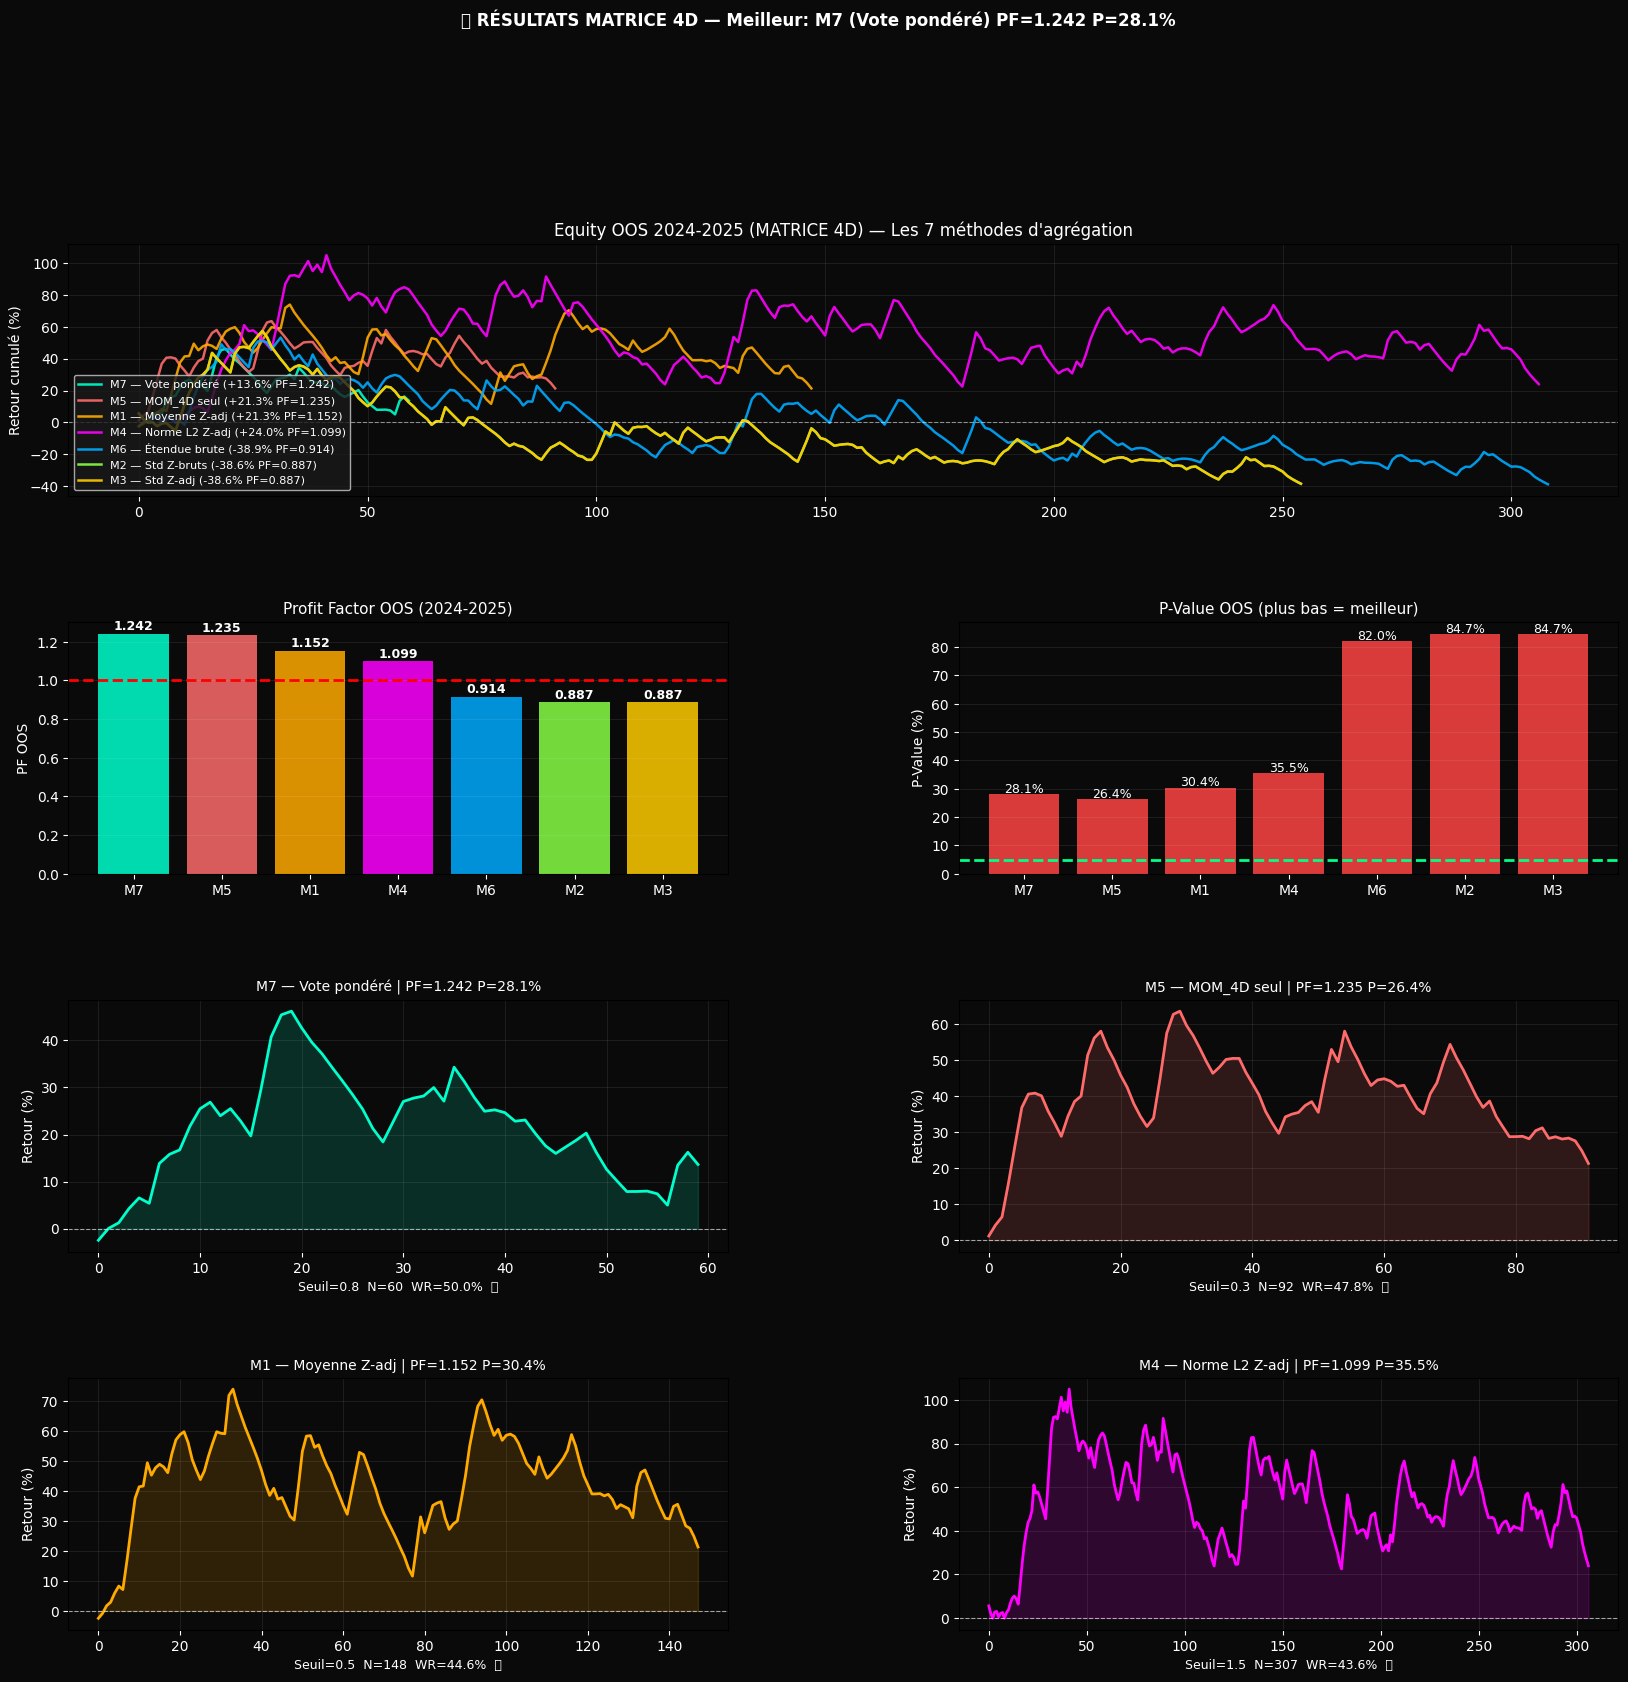


  ✅ TEST MULTIVARIÉ TERMINÉ ! REGARDEZ L'IMAGE SAUVEGARDÉE.


In [ ]:
# ==============================================================================
# === CELLULE 3 (OPTION B : L'ESPACE DES PHASES 4D MULTIVARIÉ) ===
# 🧪 DIMENSION INTRINSÈQUE DU NUAGE [PRIX + CVD + OI + VOLUME]
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
import urllib.request, zipfile, io, os, warnings
warnings.filterwarnings('ignore')

import subprocess, sys
for lib, imp in [('scikit-dimension','skdim')]:
    try: __import__(imp)
    except ImportError: subprocess.check_call([sys.executable,'-m','pip','install',lib,'-q'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
import skdim

print("=" * 80)
print("  🌌 LANCEMENT DE L'APPROCHE B : L'ATTRACTEUR 4D MULTIVARIÉ")
print("=" * 80)

# ==============================================================================
# ⚙️ CONFIG BACKTEST
# ==============================================================================
SL_FIXED, TP_FIXED, MAXHOLD = -0.020, 0.080, 72
FEES     = 0.001
WINDOW   = 120
STRIDE   = 6
N_DONCH  = 96

# ==============================================================================
# ⚙️ MOTEUR D'INGESTION MATRICE 4D (ZÉRO LOOKAHEAD BIAS)
# ==============================================================================
def download_and_read_zip(url, header_names=None):
    try:
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=10) as response:
            with zipfile.ZipFile(io.BytesIO(response.read())) as z:
                csv_name = z.namelist()[0]
                with z.open(csv_name) as f:
                    if header_names: return pd.read_csv(f, names=header_names, header=0)
                    else: return pd.read_csv(f)
    except Exception: return None

def load_month_4D(m):
    year, month = m.split('-')
    kline_url = f"https://data.binance.vision/data/futures/um/monthly/klines/BTCUSDT/1h/BTCUSDT-1h-{year}-{month}.zip"
    kline_cols = ['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_volume', 'count', 'taker_buy_volume', 'taker_buy_quote_volume', 'ignore']
    df = download_and_read_zip(kline_url, header_names=kline_cols)
    if df is None or df.empty: return None
    df['timestamp'] = pd.to_datetime(df['open_time'], unit='ms')
    df.set_index('timestamp', inplace=True)

    num_days = pd.Period(m).days_in_month
    oi_list = []
    for day in range(1, num_days + 1):
        date_str = f"{year}-{month}-{day:02d}"
        metrics_url = f"https://data.binance.vision/data/futures/um/daily/metrics/BTCUSDT/BTCUSDT-metrics-{date_str}.zip"
        df_m = download_and_read_zip(metrics_url)
        if df_m is not None and not df_m.empty:
            df_m['timestamp'] = pd.to_datetime(df_m['create_time'], format='ISO8601')
            df_m.set_index('timestamp', inplace=True)
            oi_list.append(df_m[['sum_open_interest_value']].resample('1H').mean().ffill())

    if oi_list:
        df_oi = pd.concat(oi_list)
        df_oi = df_oi[~df_oi.index.duplicated(keep='last')]
        df = df.join(df_oi, how='left')
        df['sum_open_interest_value'] = df['sum_open_interest_value'].ffill().bfill()
        oi_val = df['sum_open_interest_value'].values
    else: oi_val = np.zeros(len(df))

    df['buy_vol'] = df['taker_buy_volume']
    df['sell_vol'] = df['volume'] - df['taker_buy_volume']

    X_4D = np.column_stack([
        np.diff(np.log(df['close'].values)),
        np.diff((df['buy_vol'] - df['sell_vol']).cumsum().values),
        np.diff(oi_val),
        df['volume'].values[1:]
    ])

    return {'signal': X_4D, 'close': df['close'].values, 'high': df['high'].values, 'low': df['low'].values}

# ==============================================================================
# ⚙️ ALGORITHMES GÉOMÉTRIQUES MULTIVARIÉS
# ==============================================================================
def local_z_4D(X):
    return (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-8)

def build_ps_4D(X, emb=2, delay=1):
    n, n_features = X.shape
    n_samples = n - (emb - 1) * delay
    if n_samples < 10: return None
    X_emb = np.zeros((n_samples, n_features * emb))
    for e in range(emb): X_emb[:, e*n_features : (e+1)*n_features] = X[e*delay : e*delay+n_samples]
    return X_emb

def E21_MOM_4D(X):
    try: X_emb=build_ps_4D(local_z_4D(X)); return float(skdim.id.MOM().fit(X_emb).dimension_) if X_emb is not None and len(X_emb)>=10 else np.nan
    except: return np.nan
def E19_MLE_4D(X):
    try: X_emb=build_ps_4D(local_z_4D(X)); return float(skdim.id.MLE().fit(X_emb).dimension_) if X_emb is not None and len(X_emb)>=10 else np.nan
    except: return np.nan
def E18_TwoNN_4D(X):
    try: X_emb=build_ps_4D(local_z_4D(X)); return float(skdim.id.TwoNN().fit(X_emb).dimension_) if X_emb is not None and len(X_emb)>=5 else np.nan
    except: return np.nan
def E15_PCA_dim_4D(X):
    try: X_emb=build_ps_4D(local_z_4D(X)); pca=PCA().fit(X_emb); return float(np.searchsorted(np.cumsum(pca.explained_variance_ratio_), 0.95)+1) if X_emb is not None else np.nan
    except: return np.nan
def E28_CorrInt_4D(X):
    try: X_emb=build_ps_4D(local_z_4D(X)); return float(skdim.id.CorrInt().fit(X_emb).dimension_) if X_emb is not None and len(X_emb)>=10 else np.nan
    except: return np.nan

ANCRES_4D = {
    'E21_MOM_4D':     {'func': E21_MOM_4D,     'poids': 1.0, 'dir': +1},
    'E19_MLE_4D':     {'func': E19_MLE_4D,     'poids': 1.0, 'dir': +1},
    'E18_TwoNN_4D':   {'func': E18_TwoNN_4D,   'poids': 1.0, 'dir': +1},
    'E15_PCA_dim_4D': {'func': E15_PCA_dim_4D, 'poids': 1.0, 'dir': +1},
    'E28_CorrInt_4D': {'func': E28_CorrInt_4D, 'poids': 1.0, 'dir': +1}
}

METHODES_INFO = {
    'M1': ('Moyenne Z-adj',      [-1.5,-1.0,-0.5, 0.0, 0.3, 0.5, 0.7, 1.0, 1.5]),
    'M2': ('Std Z-bruts',        [ 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0, 1.3]),
    'M3': ('Std Z-adj',          [ 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0, 1.3]),
    'M4': ('Norme L2 Z-adj',     [ 0.3, 0.5, 0.7, 1.0, 1.3, 1.5, 2.0, 2.5]),
    'M5': ('MOM_4D seul',        [-1.5,-1.0,-0.5, 0.0, 0.3, 0.5, 0.7, 1.0, 1.5]),
    'M6': ('Étendue brute',      [ 0.5, 0.7, 1.0, 1.3, 1.5, 2.0, 2.5, 3.0]),
    'M7': ('Vote pondéré',       [-1.0,-0.5, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0]),
}

# ==============================================================================
# ⚙️ MOTEUR D'AGRÉGATION ET BACKTEST (BOUCLES SIMPLIFIÉES ANTI-BUG)
# ==============================================================================
def calibrer(matrice_4d, ancres_dict, nom_periode=""):
    print(f"   ⚙️  Calibration {nom_periode}...")
    stats = {}
    for nom, cfg in ancres_dict.items():
        vals = []
        for i in range(WINDOW, len(matrice_4d), STRIDE):
            fenetre = matrice_4d[i-WINDOW : i, :]
            valeur = cfg['func'](fenetre)
            if np.isfinite(valeur):
                vals.append(valeur)

        if len(vals) > 0:
            mu = np.mean(vals)
            sigma = np.std(vals) + 1e-10
            stats[nom] = {'mu': mu, 'sigma': sigma}
            print(f"      {nom:<15} μ={mu:.4f}  σ={sigma:.4f}")
        else:
            print(f"      {nom:<15} ❌")
    return stats

def compute_zscores(mat_window, calib_stats, ancres_dict):
    z_bruts, z_adjs, poids = [], [], []
    for nom, cfg in ancres_dict.items():
        v = cfg['func'](mat_window)
        if not np.isfinite(v) or nom not in calib_stats: continue
        z_brut = (v - calib_stats[nom]['mu']) / calib_stats[nom]['sigma']
        z_bruts.append(z_brut); z_adjs.append(z_brut * cfg['dir']); poids.append(cfg['poids'])
    return np.array(z_bruts), np.array(z_adjs), np.array(poids)

def agreger_7methodes(zb, za, pw, ancres_dict):
    if len(zb) < len(ancres_dict)-1: return {f'M{i}': np.nan for i in range(1,8)}
    return {
        'M1': np.average(za, weights=pw), 'M2': np.std(zb * pw), 'M3': np.std(za * pw),
        'M4': np.sqrt(np.sum((za * pw)**2)), 'M5': za[0] if len(za)>0 else np.nan,
        'M6': np.max(zb * pw) - np.min(zb * pw), 'M7': np.average(np.sign(za), weights=pw)
    }

def donchian(prix, high, low, N=N_DONCH):
    return prix>pd.Series(high).shift(1).rolling(N).max().values, prix<pd.Series(low).shift(1).rolling(N).min().values

def backtest(long_raw, short_raw, mask, prix):
    lf=long_raw&mask; sf=short_raw&mask
    sl=np.roll(lf.astype(int),1); sl[0]=0
    ss=np.roll(sf.astype(int),1); ss[0]=0
    dl=np.diff(sl,prepend=0)==1; ds=np.diff(ss,prepend=0)==1
    trades=[]
    for i in range(len(prix)):
        d='long' if dl[i] else('short' if ds[i] else None)
        if d is None: continue
        ep=prix[i]; xp=None
        for j in range(i+1,min(i+MAXHOLD,len(prix))):
            r=(prix[j]-ep)/ep if d=='long' else(ep-prix[j])/ep
            if r<=SL_FIXED or r>=TP_FIXED: xp=prix[j]; break
        if xp is None: xp=prix[min(i+MAXHOLD-1,len(prix)-1)]
        trades.append(((xp-ep)/ep if d=='long' else(ep-xp)/ep)-FEES)
    return np.array(trades)

def kpis(t):
    if len(t)==0: return dict(n=0,ret=0,wr=0,pf=0,dd=0)
    eq=np.cumprod(1+t); g,l=t[t>0],t[t<0]
    return dict(n=len(t),ret=(eq[-1]-1)*100,wr=np.mean(t>0)*100,pf=np.sum(g)/abs(np.sum(l)) if len(l)>0 and abs(np.sum(l))>0 else np.inf,dd=np.min(eq/np.maximum.accumulate(eq)-1)*100)
def pval(t,n=4000):
    if len(t)==0: return 100.
    return np.mean(np.array([np.prod(1+np.random.choice(t,size=len(t),replace=True))-1 for _ in range(n)])<0)*100

# ==============================================================================
# 🔄 EXÉCUTION DU NUAGE 4D
# ==============================================================================
print(f"\n📐 Calibration Nov+Déc 2021 (pour 2022-2023) [MATRICE 4D]...")
d1 = load_month_4D('2021-11'); d2 = load_month_4D('2021-12')
if d1 and d2: CS1 = calibrer(np.vstack([d1['signal'], d2['signal']]), ANCRES_4D, "Nov+Déc 2021")
else: CS1 = {}

print(f"\n📐 Calibration Nov+Déc 2023 (pour 2024-2025) [MATRICE 4D]...")
d3 = load_month_4D('2023-11'); d4 = load_month_4D('2023-12')
if d3 and d4: CS2 = calibrer(np.vstack([d3['signal'], d4['signal']]), ANCRES_4D, "Nov+Déc 2023")
else: CS2 = {}

print("\n" + "-"*70); print("  📦 PRÉCOMPUTATION DE L'ESPACE 4D (2022-2025)..."); print("-"*70)
ALL_MOIS = [f'{a}-{m:02d}' for a in range(2022,2026) for m in range(1,13)]
mois_zscores = {}

for mois in ALL_MOIS:
    annee = int(mois[:4]); calib_stats = CS1 if annee in [2022,2023] else CS2
    df_m = load_month_4D(mois)
    if df_m is None: continue

    prix = df_m['close'][1:]
    n = len(df_m['signal'])
    long_raw, short_raw = donchian(prix, df_m['high'][1:], df_m['low'][1:])
    signals = {k: np.full(n, np.nan) for k in METHODES_INFO}

    for i in range(WINDOW, n, STRIDE):
        zb, za, pw = compute_zscores(df_m['signal'][i-WINDOW:i, :], calib_stats, ANCRES_4D)
        agg = agreger_7methodes(zb, za, pw, ANCRES_4D)
        for k, v in agg.items(): signals[k][i:i+STRIDE] = v

    for k in signals: signals[k] = pd.Series(signals[k]).interpolate('linear').bfill().ffill().rolling(6, min_periods=1).mean().values

    bh = (prix[-1]-prix[0])/prix[0]*100
    reg = "🟢" if bh>5 else("🔴" if bh<-5 else"🟡")
    mois_zscores[mois] = {'prix': prix, 'long': long_raw, 'short': short_raw, 'signals': signals}
    print(f"   ✅ {mois} {reg}")

print("\n" + "-"*70); print(f"  🔍 GRID SEARCH + OOS (MATRICE 4D)"); print("-"*70)
mois_cal = [f'{a}-{m:02d}' for a in [2022,2023] for m in range(1,13)]
mois_oos = [f'{a}-{m:02d}' for a in [2024,2025] for m in range(1,13)]
resultats_methodes = {}

for methode, (nom_long, seuils) in METHODES_INFO.items():
    best_seuil, best_pf = seuils[0], -np.inf
    for seuil in seuils:
        t_all = []
        for mois in mois_cal:
            if mois not in mois_zscores: continue
            d = mois_zscores[mois]
            t_all.extend(backtest(d['long'], d['short'], d['signals'][methode] > seuil, d['prix']).tolist())
        k = kpis(np.array(t_all))
        if k['pf'] > best_pf: best_pf=k['pf']; best_seuil=seuil

    t_oos_all = []
    for mois in mois_oos:
        if mois not in mois_zscores: continue
        d = mois_zscores[mois]
        t_oos_all.extend(backtest(d['long'], d['short'], d['signals'][methode] > best_seuil, d['prix']).tolist())
    arr_oos = np.array(t_oos_all)
    k_oos, pv_oos = kpis(arr_oos), pval(arr_oos, n=8000)

    verd_oos = "✅ FORT" if pv_oos<5 else("⚠️ MRG" if pv_oos<20 else"❌ BRUIT")
    print(f"  [{methode}] {nom_long:<15} | Seuil={best_seuil:>4} | OOS Ret={k_oos['ret']:>+7.1f}% PF={k_oos['pf']:>5.3f} P={pv_oos:>4.1f}% {verd_oos}")
    resultats_methodes[methode] = {'nom': nom_long, 'seuil': best_seuil, 'oos': k_oos, 'pv_oos': pv_oos, 'trades_oos': arr_oos}

ranking = sorted(resultats_methodes.items(), key=lambda x: x[1]['oos']['pf'], reverse=True)

# ==============================================================================
# 📈 VISUALISATION MATRICE 4D
# ==============================================================================
fig = plt.figure(figsize=(20, 18))
fig.patch.set_facecolor('#0a0a0a')
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.35)
COLORS_M = ['#00ffcc','#ff6b6b','#ffaa00','#ff00ff','#00aaff','#88ff44','#ffcc00']

ax1 = fig.add_subplot(gs[0,:]); ax1.set_facecolor('#0a0a0a')
ax1.set_title(f"Equity OOS 2024-2025 (MATRICE 4D) — Les 7 méthodes d'agrégation", color='white', fontsize=12)
for (m,r), color in zip(ranking, COLORS_M):
    t=r['trades_oos']
    if len(t)>0: ax1.plot((np.cumprod(1+t)-1)*100, color=color, linewidth=1.8, label=f"{m} — {r['nom']} ({r['oos']['ret']:+.1f}% PF={r['oos']['pf']:.3f})", alpha=0.9)
ax1.axhline(y=0,color='white',linestyle='--',linewidth=0.8,alpha=0.5); ax1.set_ylabel("Retour cumulé (%)",color='white'); ax1.tick_params(colors='white'); ax1.legend(facecolor='#1a1a1a',labelcolor='white',fontsize=8,loc='lower left'); ax1.grid(color='white',alpha=0.08)

ax2 = fig.add_subplot(gs[1,0]); ax2.set_facecolor('#0a0a0a')
ax2.set_title("Profit Factor OOS (2024-2025)", color='white', fontsize=11)
ms=[m for m,_ in ranking]; pfs_=[r['oos']['pf'] for _,r in ranking]
ax2.bar(range(7), pfs_, color=[COLORS_M[i] for i in range(7)], alpha=0.85); ax2.axhline(y=1.0,color='red',linestyle='--',linewidth=2)
for i,(m_,pf_) in enumerate(zip(ms,pfs_)): ax2.text(i,pf_+0.02,f"{pf_:.3f}",ha='center',color='white',fontsize=9,fontweight='bold')
ax2.set_xticks(range(7)); ax2.set_xticklabels(ms,color='white',fontsize=10); ax2.set_ylabel("PF OOS",color='white'); ax2.tick_params(colors='white'); ax2.grid(color='white',alpha=0.08,axis='y')

ax3 = fig.add_subplot(gs[1,1]); ax3.set_facecolor('#0a0a0a')
ax3.set_title("P-Value OOS (plus bas = meilleur)", color='white', fontsize=11)
pvs_=[r['pv_oos'] for _,r in ranking]
ax3.bar(range(7), pvs_, color=['#00ff88' if pv<5 else('#ffaa00' if pv<20 else '#ff4444') for pv in pvs_], alpha=0.85); ax3.axhline(y=5,color='#00ff88',linestyle='--',linewidth=2)
for i,(m_,pv_) in enumerate(zip(ms,pvs_)): ax3.text(i,pv_+0.5,f"{pv_:.1f}%",ha='center',color='white',fontsize=9)
ax3.set_xticks(range(7)); ax3.set_xticklabels(ms,color='white',fontsize=10); ax3.set_ylabel("P-Value (%)",color='white'); ax3.tick_params(colors='white'); ax3.grid(color='white',alpha=0.08,axis='y')

for idx, (m, r) in enumerate(ranking[:4]):
    ax = fig.add_subplot(gs[2+idx//2, idx%2]); ax.set_facecolor('#0a0a0a')
    k=r['oos']; pv=r['pv_oos']
    ax.set_title(f"{m} — {r['nom']} | PF={k['pf']:.3f} P={pv:.1f}%", color='white', fontsize=10)
    t=r['trades_oos']
    if len(t)>0:
        eq=(np.cumprod(1+t)-1)*100
        ax.plot(eq, color=COLORS_M[idx], linewidth=2); ax.fill_between(range(len(eq)), eq, 0, color=COLORS_M[idx], alpha=0.15)
    ax.axhline(y=0,color='white',linestyle='--',linewidth=0.8,alpha=0.6); ax.set_ylabel("Retour (%)",color='white'); ax.tick_params(colors='white'); ax.grid(color='white',alpha=0.08)
    verd="✅" if pv<5 else("⚠️" if pv<20 else"❌")
    ax.set_xlabel(f"Seuil={r['seuil']}  N={k['n']}  WR={k['wr']:.1f}%  {verd}", color='white', fontsize=9)

best_m, best_r = ranking[0]
plt.suptitle(f"🌌 RÉSULTATS MATRICE 4D — Meilleur: {best_m} ({best_r['nom']}) PF={best_r['oos']['pf']:.3f} P={best_r['pv_oos']:.1f}%", color='white', fontsize=12, y=1.01, fontweight='bold')
plt.savefig(f"comparaison_4D_multivarie.png", dpi=120, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

print("\n" + "="*80)
print("  ✅ TEST MULTIVARIÉ TERMINÉ ! REGARDEZ L'IMAGE SAUVEGARDÉE.")
print("="*80)

In [ ]:
# ==============================================================================
# === CELLULE SUPER-AUDIT v11 : LA MATRICE 4x5 (OHLCV + OI INTÉGRAL) ===
# 🧪 Test Croisé Exhaustif 4x5 | Volatilité de Parkinson ajoutée | Holm 540-tests
# ==============================================================================

import numpy as np
import pandas as pd
import urllib.request, zipfile, io, os, warnings, time, sys, subprocess
from scipy.stats import mannwhitneyu
from scipy.signal import periodogram
from sklearn.decomposition import PCA
from numpy.lib.stride_tricks import as_strided
warnings.filterwarnings('ignore')

# Vérification et installation des librairies
for lib, imp in [('scikit-dimension', 'skdim'), ('antropy', 'antropy'), ('nolds', 'nolds'), ('statsmodels', 'statsmodels')]:
    try: __import__(imp)
    except ImportError: subprocess.check_call([sys.executable, '-m', 'pip', 'install', lib, '-q'])

import skdim, antropy, nolds
from statsmodels.stats.multitest import multipletests

print("=" * 85)
print("  🧠 LANCEMENT DE LA MATRICE CROISÉE v11 (20 TESTS EXHAUSTIFS)")
print("  ⏱️  ATTENTION : Durée estimée : 50-70 min (540 combinaisons)")
print("=" * 85)

# ==============================================================================
# ⚙️ MOTEUR MATHÉMATIQUE ULTRA-RAPIDE
# ==============================================================================
def local_z(x):
    x_clip = np.clip(x, np.percentile(x, 1), np.percentile(x, 99))
    return (x_clip - np.mean(x_clip)) / (np.std(x_clip) + 1e-8)

def build_ps(x, emb=3, delay=1):
    n = len(x) - (emb - 1) * delay
    if n < 10: return None
    shape = (n, emb)
    strides = (x.strides[0], x.strides[0] * delay)
    return as_strided(x, shape=shape, strides=strides).copy()

# ==============================================================================
# ⚙️ 27 ESTIMATEURS DE COMPLEXITÉ
# ==============================================================================
def E01_Hurst(x):
    try: return float(nolds.hurst_rs(local_z(x)))
    except: return np.nan
def E02_SampleEn(x):
    try: return float(antropy.sample_entropy(local_z(x)[:500], order=2))
    except: return np.nan
def E03_Lyapunov(x):
    try: return float(nolds.lyap_r(local_z(x)))
    except: return np.nan
def E04_DFA(x):
    try: return float(nolds.dfa(local_z(x)))
    except: return np.nan
def E05_PermEn(x):
    try: return float(antropy.perm_entropy(local_z(x), order=5, normalize=True))
    except: return np.nan
def E06_SpectralEn(x):
    try: f, psd = periodogram(local_z(x), fs=1.0); psd = psd[1:]; psd_norm = psd / psd.sum(); return float(-np.sum(psd_norm * np.log(psd_norm + 1e-12)))
    except: return np.nan
def E07_SVDEn(x):
    try: return float(antropy.svd_entropy(local_z(x), order=3, delay=1, normalize=True))
    except: return np.nan
def E08_AppEn(x):
    try: return float(antropy.app_entropy(local_z(x)[:500], order=2))
    except: return np.nan
def E09_Katz(x):
    try: return float(antropy.katz_fd(local_z(x)))
    except: return np.nan
def E10_Higuchi(x):
    try: return float(antropy.higuchi_fd(local_z(x)))
    except: return np.nan
def E11_Sevcik(x):
    try: x_z=local_z(x); n=len(x_z); xn=(x_z-x_z.min())/(x_z.max()-x_z.min()+1e-12); L=np.sum(np.sqrt(np.diff(xn)**2+np.diff(np.linspace(0,1,n))**2)); return float(1+np.log(L)/np.log(2*(n-1)))
    except: return np.nan
def E12_BoxCount(x):
    try: x_z=local_z(x); xn=(x_z-x_z.min())/(x_z.max()-x_z.min()+1e-12); scales=[4,8,16,32,64]; counts=[np.sum(np.histogram(xn, bins=np.linspace(0,1,s+1))[0]>0) for s in scales]; return float(-np.polyfit(np.log(scales), np.log(counts), 1)[0])
    except: return np.nan
def E13_CorrDim(x):
    try: return float(nolds.corr_dim(local_z(x), emb_dim=3))
    except: return np.nan
def E14_LempelZiv(x):
    try: x_z=local_z(x); b=(x_z>np.median(x_z)).astype(str); s="".join(b); return float(antropy.lziv_complexity(s, normalize=True))
    except: return np.nan
def E15_PCA_dim(x):
    try: X=build_ps(local_z(x),emb=10); pca=PCA().fit(X); return float(np.searchsorted(np.cumsum(pca.explained_variance_ratio_), 0.95)+1) if X is not None else np.nan
    except: return np.nan
def E16_MADA(x):
    try: X=build_ps(local_z(x)); return float(skdim.id.MADA().fit(X).dimension_) if X is not None else np.nan
    except: return np.nan
def E17_MiND_ML(x):
    try: X=build_ps(local_z(x)); return float(skdim.id.MiND_ML().fit(X).dimension_) if X is not None else np.nan
    except: return np.nan
def E18_TwoNN(x):
    try: X=build_ps(local_z(x)); return float(skdim.id.TwoNN().fit(X).dimension_) if X is not None else np.nan
    except: return np.nan
def E19_MLE(x):
    try: X=build_ps(local_z(x)); return float(skdim.id.MLE().fit(X).dimension_) if X is not None else np.nan
    except: return np.nan
def E20_DANCo(x):
    try: X=build_ps(local_z(x)); return float(skdim.id.DANCo().fit(X).dimension_) if X is not None else np.nan
    except: return np.nan
def E21_MOM(x):
    try: X=build_ps(local_z(x)); return float(skdim.id.MOM().fit(X).dimension_) if X is not None else np.nan
    except: return np.nan
def E22_TLE(x):
    try: X=build_ps(local_z(x)); return float(skdim.id.TLE().fit(X).dimension_) if X is not None else np.nan
    except: return np.nan
def E23_KNN(x):
    try: X=build_ps(local_z(x)); return float(skdim.id.KNN().fit(X).dimension_) if X is not None else np.nan
    except: return np.nan
def E24_FisherS(x):
    try: X=build_ps(local_z(x)); return float(skdim.id.FisherS().fit(X).dimension_) if X is not None else np.nan
    except: return np.nan
def E25_ESS(x):
    try: X=build_ps(local_z(x)); return float(skdim.id.ESS().fit(X).dimension_) if X is not None else np.nan
    except: return np.nan
def E26_CD(x):
    try: X=build_ps(local_z(x)); return float(skdim.id.CD().fit(X).dimension_) if X is not None else np.nan
    except: return np.nan
def E28_CorrInt(x):
    try: X=build_ps(local_z(x)); return float(skdim.id.CorrInt().fit(X).dimension_) if X is not None else np.nan
    except: return np.nan

ALL_ESTIMATORS = {k: v for k, v in locals().items() if k.startswith('E') and callable(v)}

# ==============================================================================
# ⚙️ MOTEUR D'INGESTION (CACHE + TRANSFORMATIONS STABILISÉES + FULL SANITY)
# ==============================================================================
_data_cache = {}

def download_and_read_zip(url, header_names=None):
    try:
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=10) as response:
            with zipfile.ZipFile(io.BytesIO(response.read())) as z:
                csv_name = z.namelist()[0]
                with z.open(csv_name) as f:
                    if header_names: return pd.read_csv(f, names=header_names, header=0)
                    else: return pd.read_csv(f)
    except Exception: return None

def load_data_transformed(mois):
    global _data_cache
    if mois in _data_cache: return _data_cache[mois]

    year, m = mois.split('-')
    kline_url = f"https://data.binance.vision/data/futures/um/monthly/klines/BTCUSDT/1h/BTCUSDT-1h-{year}-{m}.zip"
    cols = ['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_volume', 'count', 'taker_buy_volume', 'taker_buy_quote_volume', 'ignore']
    df = download_and_read_zip(kline_url, header_names=cols)
    if df is None or df.empty: return None
    df['timestamp'] = pd.to_datetime(df['open_time'], unit='ms')
    df.set_index('timestamp', inplace=True)

    num_days = pd.Period(mois).days_in_month
    oi_list = []
    for day in range(1, num_days + 1):
        metrics_url = f"https://data.binance.vision/data/futures/um/daily/metrics/BTCUSDT/BTCUSDT-metrics-{year}-{m}-{day:02d}.zip"
        df_m = download_and_read_zip(metrics_url)
        if df_m is not None and not df_m.empty:
            df_m['timestamp'] = pd.to_datetime(df_m['create_time'], format='ISO8601')
            df_m.set_index('timestamp', inplace=True)
            oi_list.append(df_m[['sum_open_interest_value']])

    if oi_list:
        df_oi = pd.concat(oi_list)
        df_oi = df_oi[~df_oi.index.duplicated(keep='last')]
        df_oi = df_oi.resample('1H').last()
        df = df.join(df_oi, how='left')
        df['sum_open_interest_value'] = df['sum_open_interest_value'].interpolate(method='linear').ffill().bfill()
        oi_val = df['sum_open_interest_value'].values
    else: oi_val = np.ones(len(df))

    df['buy_vol'] = df['taker_buy_volume']
    df['sell_vol'] = df['volume'] - df['taker_buy_volume']

    # === TRANSFORMATIONS 5 CANAUX ===
    sig_prix = np.diff(np.log(df['close'].values))
    sig_volat = np.log(df['high'].values[1:] / (df['low'].values[1:] + 1e-8)) # 5e Canal Intra-horaire

    oi_series = pd.Series(oi_val)
    sig_oi = ((oi_series - oi_series.rolling(120, min_periods=30).mean()) / (oi_series.rolling(120, min_periods=30).std() + 1e-8)).bfill().values[1:]

    vol_ma20 = pd.Series(df['volume']).rolling(20, min_periods=1).mean().values
    sig_vol = np.log1p(df['volume'].values[1:] / (vol_ma20[1:] + 1e-8))

    flow = (df['buy_vol'].values[1:] - df['sell_vol'].values[1:]) / (df['volume'].values[1:] + 1e-8)
    sig_cvd = pd.Series(flow).rolling(6, min_periods=1).mean().values

    signals = {
        'PRIX': sig_prix,
        'OI': sig_oi,
        'VOLUME': sig_vol,
        'CVD': sig_cvd,
        'VOLATILITE': sig_volat
    }

    # 🔍 FULL SANITY CHECK RESTAURÉ
    print(f"   [Sanity Check] Données pour {mois}")
    for name, sig in signals.items():
        zero_pct = 100 * np.sum(sig == 0) / len(sig)
        print(f"      {name:<10}: mean={np.mean(sig):>8.4f}, std={np.std(sig):>8.4f}, zeros={zero_pct:>5.1f}%, min={np.min(sig):>8.4f}, max={np.max(sig):>8.4f}")

    _data_cache[mois] = signals
    return signals

# ==============================================================================
# 🎯 SCÉNARIOS HYBRIDES OPTIMISÉS
# ==============================================================================
QUESTIONS = {
    "NIVEAU 1 (Régime Structuré vs Chaotique)": {
        "mois_A": ["2023-01", "2023-10", "2024-02"],
        "mois_B": ["2023-05", "2023-08", "2023-09"]
    },
    "NIVEAU 2 (Tension : Purge vs Compression)": {
        "mois_A": ["2022-05", "2022-11", "2024-04"],
        "mois_B": ["2023-05", "2023-07", "2024-06"]
    },
    "NIVEAU 3 (Cinétique : Explosion vs Apathie)": {
        "mois_A": ["2022-05", "2022-11", "2024-03"],
        "mois_B": ["2022-12", "2023-08", "2023-09"]
    },
    "NIVEAU 4 (Direction : UP vs DOWN)": {
        "mois_A": ["2023-01", "2023-10", "2024-02"],
        "mois_B": ["2023-08", "2024-04", "2024-08"]
    }
}

ALL_VARIABLES = ['PRIX', 'OI', 'VOLUME', 'CVD', 'VOLATILITE']

# ==============================================================================
# 🚀 MOTEUR STATISTIQUE ET STRUCTURES D'AGRÉGATION
# ==============================================================================
MATRIX_SUMMARY = {}
ALL_TESTS = []

for q_name, q_params in QUESTIONS.items():
    print(f"\n{'█'*90}\n  {q_name}\n{'█'*90}")

    print(f"📡 Récupération Groupe A : {q_params['mois_A']}")
    raw_A = [load_data_transformed(m) for m in q_params['mois_A']]
    raw_A = [d for d in raw_A if d is not None]

    print(f"📡 Récupération Groupe B : {q_params['mois_B']}")
    raw_B = [load_data_transformed(m) for m in q_params['mois_B']]
    raw_B = [d for d in raw_B if d is not None]

    if not raw_A or not raw_B:
        continue

    for var_name in ALL_VARIABLES:
        print(f"\n   ➤ TEST SUR LA VARIABLE : {var_name}")

        data_A = [d[var_name] for d in raw_A]
        data_B = [d[var_name] for d in raw_B]

        results = []

        for nom, func in ALL_ESTIMATORS.items():
            vals_A, vals_B = [], []
            for m_data in data_A:
                vals_A += [func(m_data[i-120:i]) for i in range(120, len(m_data), 12)]
            for m_data in data_B:
                vals_B += [func(m_data[i-120:i]) for i in range(120, len(m_data), 12)]

            vA_clean = [v for v in vals_A if np.isfinite(v)]
            vB_clean = [v for v in vals_B if np.isfinite(v)]

            if len(vA_clean) > 10 and len(vB_clean) > 10:
                stat, pval = mannwhitneyu(vA_clean, vB_clean, alternative='two-sided')
                n1, n2 = len(vA_clean), len(vB_clean)
                mean_diff = np.mean(vA_clean) - np.mean(vB_clean)
                pooled_std = np.sqrt(((n1-1)*np.var(vA_clean) + (n2-1)*np.var(vB_clean)) / (n1+n2-2))
                cohen_d = abs(mean_diff / pooled_std) if pooled_std > 0 else 0

                results.append({
                    'nom': nom, 'cohen': cohen_d, 'pval': pval,
                    'muA': np.mean(vA_clean), 'muB': np.mean(vB_clean)
                })

        # Holm Local (par cellule) pour l'affichage en direct
        if results:
            pvals = [r['pval'] for r in results]
            try:
                _, pvals_corr, _, _ = multipletests(pvals, method='holm')
                for i, r in enumerate(results): r['pval_corr'] = pvals_corr[i]
            except Exception:
                for r in results: r['pval_corr'] = r['pval']

        # Enregistrement pour le Holm Global et la Matrice
        for r in results:
            ALL_TESTS.append({'q_name': q_name, 'var_name': var_name, **r})

        max_cohen = max([r['cohen'] for r in results]) if results else 0
        if q_name not in MATRIX_SUMMARY: MATRIX_SUMMARY[q_name] = {}
        MATRIX_SUMMARY[q_name][var_name] = max_cohen

        results.sort(key=lambda x: x['cohen'], reverse=True)

        print(f"      {'Estimateur':<15} | {'Cohen-d':<7} | {'P-Val Brut':<10} | {'P-Val (L)':<10} | {'Verdict Local'}")
        print("      " + "-" * 75)

        for r in results[:5]:
            verdict = "✅ FORT" if r['cohen'] > 0.5 and r.get('pval_corr', r['pval']) < 0.05 else ("⚠️ " if r['cohen'] > 0.3 else "❌ ")
            print(f"      {r['nom']:<15} | {r['cohen']:.3f}   | {r['pval']:.3e} | {r.get('pval_corr', r['pval']):.3e} | {verdict}")

# ==============================================================================
# 📊 SYNTHÈSE GLOBALE ET MATRICE
# ==============================================================================
print(f"\n\n{'═'*95}")
print(f"  📊 MATRICE COHEN-D MAXIMUM (La Diagonale de Vérité)")
print(f"{'═'*95}")
print(f"  {'Question':>30} | {'PRIX':>8} | {'OI':>8} | {'VOLUME':>8} | {'CVD':>8} | {'VOLATILITE':>10}")
print(f"  {'─'*30}-+-{'─'*8}-+-{'─'*8}-+-{'─'*8}-+-{'─'*8}-+-{'─'*10}")
for q_name, row in MATRIX_SUMMARY.items():
    short = q_name.split(' (')[1].rstrip(')')[:30]
    print(f"  {short:>30} | {row.get('PRIX',0):.3f}   | {row.get('OI',0):.3f}   | {row.get('VOLUME',0):.3f}   | {row.get('CVD',0):.3f}   | {row.get('VOLATILITE',0):.3f}")
print(f"{'═'*95}")

# Holm Global sur les 540 tests
pvals_global = [t['pval'] for t in ALL_TESTS]
try:
    _, pvals_global_corr, _, _ = multipletests(pvals_global, method='holm')
    for i, t in enumerate(ALL_TESTS): t['pval_global_corr'] = pvals_global_corr[i]
except:
    for t in ALL_TESTS: t['pval_global_corr'] = t['pval']

ALL_TESTS.sort(key=lambda x: x['cohen'], reverse=True)

print(f"\n{'═'*95}")
print(f"  🏆 TOP 15 GLOBAL (Immunisés contre la correction Holm de 540 Tests)")
print(f"{'═'*95}")
print(f"  {'Niveau':<10} | {'Variable':<10} | {'Estimateur':<15} | {'Cohen-d':<7} | {'P-Val Globale':<15} | {'Verdict'}")
print("  " + "-" * 93)
for t in ALL_TESTS[:15]:
    short_q = "Niveau " + t['q_name'].split()[1]
    verdict = "🔒 BLINDÉ" if t['cohen'] > 0.5 and t['pval_global_corr'] < 0.05 else "⚠️"
    print(f"  {short_q:<10} | {t['var_name']:<10} | {t['nom']:<15} | {t['cohen']:.3f}   | {t['pval_global_corr']:.3e}     | {verdict}")
print(f"{'═'*95}")

  🧠 LANCEMENT DE LA MATRICE CROISÉE v11 (20 TESTS EXHAUSTIFS)
  ⏱️  ATTENTION : Durée estimée : 50-70 min (540 combinaisons)

██████████████████████████████████████████████████████████████████████████████████████████
  NIVEAU 1 (Régime Structuré vs Chaotique)
██████████████████████████████████████████████████████████████████████████████████████████
📡 Récupération Groupe A : ['2023-01', '2023-10', '2024-02']
   [Sanity Check] Données pour 2023-01
      PRIX      : mean=  0.0005, std=  0.0049, zeros=  0.1%, min= -0.0285, max=  0.0479
      OI        : mean=  0.3907, std=  1.3724, zeros=  0.0%, min= -3.4058, max=  4.6148
      VOLUME    : mean=  0.6487, std=  0.3601, zeros=  0.0%, min=  0.1283, max=  1.9477
      CVD       : mean=  0.0004, std=  0.0297, zeros=  0.0%, min= -0.1010, max=  0.2046
      VOLATILITE: mean=  0.0064, std=  0.0064, zeros=  0.0%, min=  0.0003, max=  0.0803
   [Sanity Check] Données pour 2023-10
      PRIX      : mean=  0.0003, std=  0.0044, zeros=  0.0%, min= -0.02